## versi rentals.csv + rental_logs.csv

In [ ]:
# ============================================================
# versi rentals.csv + rental_logs.csv
# ============================================================

import pandas as pd
import numpy as np
import joblib
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.experimental import enable_halving_search_cv
from sklearn.model_selection import HalvingGridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.feature_selection import chi2, mutual_info_classif
from scipy.stats import pearsonr

# Models & Pipelines
from sklearn.pipeline import Pipeline, make_pipeline
from imblearn.over_sampling import SMOTE
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.utils.class_weight import compute_class_weight

# ------------------------------------------------------------
# 1. LOAD DATA
# ------------------------------------------------------------
rentals = pd.read_csv('rentals.csv')
logs = pd.read_csv('rental_logs.csv')

# Standarisasi nama kolom ke huruf kecil
rentals.columns = rentals.columns.str.lower()
logs.columns = logs.columns.str.lower()

if 'komentar' not in rentals.columns:
    raise ValueError("Kolom 'komentar' tidak ditemukan di rentals.csv")

print("rentals.csv")
print(rentals.head())
print("\nlogs.csv")
print(logs.head())

# ------------------------------------------------------------
# 2. LABELING & LOG MERGING
# ------------------------------------------------------------
# Bersihkan format teks (ubah ke huruf kecil dan hapus spasi berlebih)
rentals['komentar'] = rentals['komentar'].astype(str).str.lower().str.strip()

# Definisikan nilai-nilai yang dianggap "kosong" / tidak ada komentar
empty_values = ["", "nan", "na", "null", "-", "0", "tidak ada", "none"]

# Jika isi komentar TIDAK ada di dalam empty_values, berarti ada indikasi pelanggaran (label 1)
rentals['label'] = (~rentals['komentar'].isin(empty_values)).astype(int)

# Menggabungkan logs ke rentals (membuat fitur: jumlah edit & editor unik)
logs['rental_id'] = logs['rental_id'].astype(int)
edit_count = logs.groupby('rental_id').size().reset_index(name='edit_count')
unique_editors = logs.groupby('rental_id')['email'].nunique().reset_index(name='unique_editors')

df = rentals.merge(edit_count, left_on='id', right_on='rental_id', how='left')
df = df.merge(unique_editors, left_on='id', right_on='rental_id', how='left')

# Isi nilai kosong dengan 0 untuk penyewaan yang tidak memiliki log
df['edit_count'] = df['edit_count'].fillna(0)
df['unique_editors'] = df['unique_editors'].fillna(0)

# ------------------------------------------------------------
# 3. FEATURE ENGINEERING & PREPARATION
# ------------------------------------------------------------
# Mengisi nilai kosong pada fitur kategorikal dan numerik
df['metode_pembayaran'] = df['metode_pembayaran'].fillna('Others')
if 'metode_lain' in df.columns:
    df['metode_lain'] = df['metode_lain'].fillna('')

df['lama_menginap'] = df['lama_menginap'].fillna(0)

cat_cols = ['tower', 'status_kewarganegaraan', 'metode_pembayaran', 'jenis_sewa']
numeric_cols = ['lama_menginap', 'edit_count', 'unique_editors']

# Daftar seluruh fitur relevan yang akan digunakan
feature_cols = cat_cols + numeric_cols

# Pastikan data kategorikal berupa string
for c in cat_cols:
    df[c] = df[c].astype(str)

X = df[feature_cols].copy()
y = df['label']

# ------------------------------------------------------------
# 4. TRAIN-TEST SPLIT
# ------------------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, stratify=y, test_size=0.2, random_state=42
)

# Menghitung bobot kelas (class weights) karena data tidak seimbang
classes = np.array([0, 1])
weights = compute_class_weight(class_weight='balanced', classes=classes, y=y_train)
class_weights = {0: weights[0], 1: weights[1]}
print(f"\nBobot Kelas (Class weights): {class_weights}")

# ------------------------------------------------------------
# 4B. ENCODING MENCEGAH DATA LEAKAGE
# ------------------------------------------------------------
label_encoders = {}

for c in cat_cols:
    le = LabelEncoder()
    # Fit & Transform pada data latih
    X_train[c] = le.fit_transform(X_train[c])

    # Tangani unseen labels pada data uji (cegah error saat deployment)
    X_test[c] = X_test[c].map(lambda s: s if s in le.classes_ else 'Unknown')
    if 'Unknown' not in le.classes_:
        le.classes_ = np.append(le.classes_, 'Unknown')

    X_test[c] = le.transform(X_test[c])
    label_encoders[c] = le

# ------------------------------------------------------------
# 5. FEATURE EVALUATION
# ------------------------------------------------------------
print("\n=== Evaluasi Korelasi Fitur ===")
# Catatan: Pemodelan menggunakan seluruh kolom relevan yang tersedia dengan
# spesifik encoding (tidak otomatis menyeleksi sebagian/membuang fitur).
# Pengujian ini sekadar untuk analisis signifikansi.

chi_vals, _ = chi2(X_train, y_train)
mi_vals = mutual_info_classif(X_train, y_train)
pearson_vals = [abs(pearsonr(X_train[col], y_train)[0]) for col in X_train.columns]

fs_df = pd.DataFrame({
    'Fitur': X_train.columns,
    'Chi2': chi_vals,
    'MutualInfo': mi_vals,
    'Pearson': pearson_vals
}).sort_values(by='MutualInfo', ascending=False)

print(fs_df)

# ------------------------------------------------------------
# 6. Fungsi Evaluasi
# ------------------------------------------------------------
def evaluate(name, model):
    y_pred = model.predict(X_test)
    print(f"\n===== {name} =====")
    print("Classification Report:")
    print(classification_report(y_test, y_pred, digits=4))

    cm = confusion_matrix(y_test, y_pred)

    # --------------------------------------------------------
    # Confusion Matrix (Text Base)
    # --------------------------------------------------------
    print("Confusion Matrix (Text):")
    print("                Predicted")
    print("               0       1")
    print("          -----------------")
    print(f"True   0 | {cm[0][0]:6d}  {cm[0][1]:6d}")
    print(f"       1 | {cm[1][0]:6d}  {cm[1][1]:6d}")
    print("          -----------------\n")

    # --------------------------------------------------------
    # Confusion Matrix (Gambar / Visualisasi)
    # --------------------------------------------------------
    # plt.figure(figsize=(5, 4))
    # sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
    #             xticklabels=['0 (Aman)', '1 (Melanggar)'],
    #             yticklabels=['0 (Aman)', '1 (Melanggar)'])
    #
    # plt.title(f'Confusion Matrix - {name}')
    # plt.xlabel('Predicted Label')
    # plt.ylabel('True Label')
    # plt.tight_layout()
    # plt.show()

# ------------------------------------------------------------
# 7. LATIH SEMUA MODEL & HYPERPARAMETER TUNING
# ------------------------------------------------------------
models = {}
print("\nMemulai proses Hyperparameter Tuning untuk semua model. Ini mungkin memakan waktu...\n")

# Penanganan SMOTE khusus untuk KNN
sm = SMOTE(random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train, y_train)

# --- 1. Decision Tree ---
print(">> Tuning Decision Tree...")
param_dt = {
    'max_depth': [5, 10, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'class_weight': ['balanced']
}
grid_dt = GridSearchCV(DecisionTreeClassifier(random_state=42), param_grid=param_dt, scoring='recall', cv=3, n_jobs=-1, verbose=0)
grid_dt.fit(X_train, y_train)
models["Decision Tree (Tuned)"] = grid_dt.best_estimator_
print("Parameter Terbaik (DT):", grid_dt.best_params_)

# --- 2. Random Forest ---
print("\n>> Tuning Random Forest...")
param_rf = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'class_weight': ['balanced']
}
grid_rf = GridSearchCV(RandomForestClassifier(random_state=42), param_grid=param_rf, scoring='recall', cv=3, n_jobs=-1, verbose=0)
grid_rf.fit(X_train, y_train)
models["Random Forest (Tuned)"] = grid_rf.best_estimator_
print("Parameter Terbaik (RF):", grid_rf.best_params_)

# --- 3. KNN (dengan SMOTE) ---
print("\n>> Tuning KNN (SMOTE)...")
param_knn = {
    'n_neighbors': [3, 5, 7],
    'weights': ['uniform', 'distance']
}
grid_knn = GridSearchCV(KNeighborsClassifier(), param_grid=param_knn, scoring='recall', cv=3, n_jobs=-1, verbose=0)
grid_knn.fit(X_train_res, y_train_res) # Latih dengan data yang sudah di-resample
models["KNN (SMOTE Tuned)"] = grid_knn.best_estimator_
print("Parameter Terbaik (KNN):", grid_knn.best_params_)

# --- 4. SVM (HalvingGridSearchCV) ---
print("\n>> Tuning SVM Optimasi...")
pipe_svm = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC(random_state=42, class_weight='balanced'))
])
param_svm = {
    'svm__C': [0.1, 1, 10],
    'svm__gamma': ['scale', 0.01, 0.1],
    'svm__kernel': ['rbf']
}
halving_svm = HalvingGridSearchCV(pipe_svm, param_grid=param_svm, scoring='recall', cv=2, factor=2, n_jobs=-1, verbose=0)
halving_svm.fit(X_train, y_train)
models["SVM Optimasi (Tuned)"] = halving_svm.best_estimator_
print("Parameter Terbaik (SVM):", halving_svm.best_params_)

# --- 5. XGBoost ---
print("\n>> Tuning XGBoost...")
pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
param_xgb = {
    'n_estimators': [100, 200],
    'max_depth': [3, 6],
    'learning_rate': [0.01, 0.1, 0.3],
    'subsample': [0.8, 1.0],
    'scale_pos_weight': [pos_weight]
}
grid_xgb = GridSearchCV(XGBClassifier(eval_metric='logloss'), param_grid=param_xgb, scoring='recall', cv=3, n_jobs=-1, verbose=0)
grid_xgb.fit(X_train, y_train)
models["XGBoost (Tuned)"] = grid_xgb.best_estimator_
print("Parameter Terbaik (XGB):", grid_xgb.best_params_)

# --- Evaluasi Semua Model ---
for name, model in models.items():
    evaluate(name, model)


rentals.csv
   id           nama               nik status_pasutri tower  lantai    unit  \
0   1   Vina Pratama   227680402501652             ya     C       1  C-0111   
1   2  Indah Saputra  7593586857022021  belum menikah     C      15  C-1524   
2   3  Indah Hartono  2370884095724861             ya     B       8  B-0836   
3   4   Wira Permata  5354259618773210             ya     C      17  C-1712   
4   5   Rizky Wijaya  5413982250789516  belum menikah     B       9  B-0934   

  status_kewarganegaraan jenis_sewa metode_pembayaran metode_lain  \
0                    WNI   mingguan       Kartu Debit         NaN   
1                    WNI     harian       Kartu Debit         NaN   
2                    WNA   mingguan              Cash     Voucher   
3                    WNI   mingguan              Cash         NaN   
4                    WNI    bulanan              QRIS         NaN   

  tanggal_checkin waktu_checkin tanggal_checkout waktu_checkout  \
0      2024-07-23         06:48

## ✨ **versi rentals.csv + rental_logs.csv + violations.csv + users.csv + agents.csv + unit.csv** (table users dan agent belum dijadikan 1)

In [3]:
import pandas as pd
import numpy as np
import joblib
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.experimental import enable_halving_search_cv  # Dibutuhkan untuk HalvingGridSearchCV
from sklearn.model_selection import HalvingGridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.feature_selection import chi2, mutual_info_classif
from scipy.stats import pearsonr

# Models & Pipelines
from sklearn.pipeline import Pipeline, make_pipeline
from imblearn.over_sampling import SMOTE
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.utils.class_weight import compute_class_weight

# ------------------------------------------------------------
# 1. LOAD DATA
# ------------------------------------------------------------
rentals = pd.read_csv('rentals.csv')
logs = pd.read_csv('rental_logs.csv')
agents = pd.read_csv('agents.csv')
units = pd.read_csv('units.csv')
users = pd.read_csv('users.csv')
violations = pd.read_csv('violations.csv')

# Standarisasi nama kolom ke huruf kecil
rentals.columns = rentals.columns.str.lower()
logs.columns = logs.columns.str.lower()

if 'komentar' not in rentals.columns:
    raise ValueError("Kolom 'komentar' tidak ditemukan di rentals.csv")

print("rentals.csv")
print(rentals.head())
print("\nlogs.csv")
print(logs.head())

# ------------------------------------------------------------
# 2. LABELING & LOG MERGING
# ------------------------------------------------------------
# Merge logs into rentals (feature: edit_count & unique editors)
logs['rental_id'] = logs['rental_id'].astype(int)
edit_count = logs.groupby('rental_id').size().reset_index(name='edit_count')
unique_editors = logs.groupby('rental_id')['email'].nunique().reset_index(name='unique_editors')

df = rentals.merge(edit_count, left_on='id', right_on='rental_id', how='left')
df = df.merge(unique_editors, left_on='id', right_on='rental_id', how='left')

df['edit_count'] = df['edit_count'].fillna(0)
df['unique_editors'] = df['unique_editors'].fillna(0)

# Labeling Target: has_violation -> label
violation_keywords = [
    'alat suntik', 'kondom', 'kerusakan', 'kebisingan', 'alkohol', 'narkoba',
    'kekerasan', 'ancaman', 'merokok', 'kebersihan', 'tamu', 'menyewakan',
    'transit', 'lalai'
]

df['komentar'] = df['komentar'].astype(str).str.lower()
df['label'] = df['komentar'].apply(lambda x: int(any(k in x for k in violation_keywords)))

# ------------------------------------------------------------
# 3. FEATURE ENGINEERING & PREPARATION
# ------------------------------------------------------------
# Mengisi nilai kosong pada fitur kategorikal dan numerik
df['metode_pembayaran'] = df['metode_pembayaran'].fillna('Others')
if 'metode_lain' in df.columns:
    df['metode_lain'] = df['metode_lain'].fillna('')

df['lama_menginap'] = df['lama_menginap'].fillna(0)

cat_cols = ['tower', 'status_kewarganegaraan', 'metode_pembayaran', 'jenis_sewa']
numeric_cols = ['lantai', 'lama_menginap', 'edit_count', 'unique_editors']

# Daftar seluruh fitur relevan yang akan digunakan
feature_cols = cat_cols + numeric_cols

# Pastikan data kategorikal berupa string
for c in cat_cols:
    df[c] = df[c].astype(str)

X = df[feature_cols].copy()
y = df['label']

# ------------------------------------------------------------
# 4. TRAIN-TEST SPLIT
# ------------------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, stratify=y, test_size=0.2, random_state=42
)

# Menghitung bobot kelas (class weights) karena data tidak seimbang
classes = np.array([0, 1])
weights = compute_class_weight(class_weight='balanced', classes=classes, y=y_train)
class_weights = {0: weights[0], 1: weights[1]}
print(f"\nBobot Kelas (Class weights): {class_weights}")

# ------------------------------------------------------------
# 4B. ENCODING MENCEGAH DATA LEAKAGE
# ------------------------------------------------------------
label_encoders = {}

for c in cat_cols:
    le = LabelEncoder()
    # Fit & Transform pada data latih
    X_train[c] = le.fit_transform(X_train[c])

    # Tangani unseen labels pada data uji (cegah error saat deployment)
    X_test[c] = X_test[c].map(lambda s: s if s in le.classes_ else 'Unknown')
    if 'Unknown' not in le.classes_:
        le.classes_ = np.append(le.classes_, 'Unknown')

    X_test[c] = le.transform(X_test[c])
    label_encoders[c] = le

# ------------------------------------------------------------
# 5. FEATURE EVALUATION
# ------------------------------------------------------------
print("\n=== Evaluasi Korelasi Fitur ===")
# Catatan: Pemodelan menggunakan seluruh kolom relevan yang tersedia dengan
# spesifik encoding (tidak otomatis menyeleksi sebagian/membuang fitur).
# Pengujian ini sekadar untuk analisis signifikansi.

chi_vals, _ = chi2(X_train, y_train)
mi_vals = mutual_info_classif(X_train, y_train)
pearson_vals = [abs(pearsonr(X_train[col], y_train)[0]) for col in X_train.columns]

fs_df = pd.DataFrame({
    'Fitur': X_train.columns,
    'Chi2': chi_vals,
    'MutualInfo': mi_vals,
    'Pearson': pearson_vals
}).sort_values(by='MutualInfo', ascending=False)

print(fs_df)

# ------------------------------------------------------------
# 6. Fungsi Evaluasi
# ------------------------------------------------------------
def evaluate(name, model):
    y_pred = model.predict(X_test)
    print(f"\n===== {name} =====")
    print("Classification Report:")
    print(classification_report(y_test, y_pred, digits=4))

    cm = confusion_matrix(y_test, y_pred)

    # --------------------------------------------------------
    # Confusion Matrix (Text Base)
    # --------------------------------------------------------
    print("Confusion Matrix (Text):")
    print("                Predicted")
    print("               0       1")
    print("          -----------------")
    print(f"True   0 | {cm[0][0]:6d}  {cm[0][1]:6d}")
    print(f"       1 | {cm[1][0]:6d}  {cm[1][1]:6d}")
    print("          -----------------\n")

    # --------------------------------------------------------
    # Confusion Matrix (Gambar / Visualisasi)
    # --------------------------------------------------------
    # plt.figure(figsize=(5, 4))
    # sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
    #             xticklabels=['0 (Aman)', '1 (Melanggar)'],
    #             yticklabels=['0 (Aman)', '1 (Melanggar)'])
    #
    # plt.title(f'Confusion Matrix - {name}')
    # plt.xlabel('Predicted Label')
    # plt.ylabel('True Label')
    # plt.tight_layout()
    # plt.show()

# ------------------------------------------------------------
# 7. LATIH SEMUA MODEL & HYPERPARAMETER TUNING
# ------------------------------------------------------------
models = {}
print("\nMemulai proses Hyperparameter Tuning untuk semua model. Ini mungkin memakan waktu...\n")

# Penanganan SMOTE khusus untuk KNN
sm = SMOTE(random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train, y_train)

# --- 1. Decision Tree ---
print(">> Tuning Decision Tree...")
param_dt = {
    'max_depth': [5, 10, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'class_weight': ['balanced']
}
grid_dt = GridSearchCV(DecisionTreeClassifier(random_state=42), param_grid=param_dt, scoring='recall', cv=3, n_jobs=-1, verbose=0)
grid_dt.fit(X_train, y_train)
models["Decision Tree (Tuned)"] = grid_dt.best_estimator_
print("Parameter Terbaik (DT):", grid_dt.best_params_)

# --- 2. Random Forest ---
print("\n>> Tuning Random Forest...")
param_rf = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'class_weight': ['balanced']
}
grid_rf = GridSearchCV(RandomForestClassifier(random_state=42), param_grid=param_rf, scoring='recall', cv=3, n_jobs=-1, verbose=0)
grid_rf.fit(X_train, y_train)
models["Random Forest (Tuned)"] = grid_rf.best_estimator_
print("Parameter Terbaik (RF):", grid_rf.best_params_)

# --- 3. KNN (dengan SMOTE) ---
print("\n>> Tuning KNN (SMOTE)...")
param_knn = {
    'n_neighbors': [3, 5, 7],
    'weights': ['uniform', 'distance']
}
grid_knn = GridSearchCV(KNeighborsClassifier(), param_grid=param_knn, scoring='recall', cv=3, n_jobs=-1, verbose=0)
grid_knn.fit(X_train_res, y_train_res)  # Latih dengan data yang sudah di-resample
models["KNN (SMOTE Tuned)"] = grid_knn.best_estimator_
print("Parameter Terbaik (KNN):", grid_knn.best_params_)

# --- 4. SVM (HalvingGridSearchCV) ---
print("\n>> Tuning SVM Optimasi...")
pipe_svm = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC(random_state=42, class_weight='balanced'))
])
param_svm = {
    'svm__C': [0.1, 1, 10],
    'svm__gamma': ['scale', 0.01, 0.1],
    'svm__kernel': ['rbf']
}
halving_svm = HalvingGridSearchCV(pipe_svm, param_grid=param_svm, scoring='recall', cv=2, factor=2, n_jobs=-1, verbose=0)
halving_svm.fit(X_train, y_train)
models["SVM Optimasi (Tuned)"] = halving_svm.best_estimator_
print("Parameter Terbaik (SVM):", halving_svm.best_params_)

# --- 5. XGBoost ---
print("\n>> Tuning XGBoost...")
pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
param_xgb = {
    'n_estimators': [100, 200],
    'max_depth': [3, 6],
    'learning_rate': [0.01, 0.1, 0.3],
    'subsample': [0.8, 1.0],
    'scale_pos_weight': [pos_weight]
}
grid_xgb = GridSearchCV(XGBClassifier(use_label_encoder=False, eval_metric='logloss'), param_grid=param_xgb, scoring='recall', cv=3, n_jobs=-1, verbose=0)
grid_xgb.fit(X_train, y_train)
models["XGBoost (Tuned)"] = grid_xgb.best_estimator_
print("Parameter Terbaik (XGB):", grid_xgb.best_params_)

# --- Evaluasi Semua Model ---
for name, model in models.items():
    evaluate(name, model)


rentals.csv
   id            nama               nik status_pasutri tower  lantai  unit  \
0   1  Nama Penyewa 1  3200000000000001  Belum Menikah     A       1    13   
1   2  Nama Penyewa 2  3200000000000002        Menikah     D       3     4   
2   3  Nama Penyewa 3  3200000000000003  Belum Menikah     B      18     2   
3   4  Nama Penyewa 4  3200000000000004  Belum Menikah     B      11     7   
4   5  Nama Penyewa 5  3200000000000005        Menikah     A      14     6   

  status_kewarganegaraan jenis_sewa metode_pembayaran  metode_lain  \
0                    WNI    Bulanan              Cash          NaN   
1                    WNA    Bulanan              Cash          NaN   
2                    WNA   Mingguan              QRIS          NaN   
3                    WNI     Harian              QRIS          NaN   
4                    WNA    Bulanan          Transfer          NaN   

  tanggal_checkin waktu_checkin tanggal_checkout waktu_checkout  \
0      2024-01-22      18:00:00

/tmp/ipykernel_5100/1987556958.py:135: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  pearson_vals = [abs(pearsonr(X_train[col], y_train)[0]) for col in X_train.columns]


Parameter Terbaik (DT): {'class_weight': 'balanced', 'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 2}

>> Tuning Random Forest...
Parameter Terbaik (RF): {'class_weight': 'balanced', 'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}

>> Tuning KNN (SMOTE)...
Parameter Terbaik (KNN): {'n_neighbors': 7, 'weights': 'distance'}

>> Tuning SVM Optimasi...
Parameter Terbaik (SVM): {'svm__C': 1, 'svm__gamma': 0.01, 'svm__kernel': 'rbf'}

>> Tuning XGBoost...


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [06:42:40] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Parameter Terbaik (XGB): {'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 100, 'scale_pos_weight': np.float64(9.025062656641603), 'subsample': 1.0}

===== Decision Tree (Tuned) =====
Classification Report:
              precision    recall  f1-score   support

           0     0.9054    0.5475    0.6824      1801
           1     0.1054    0.4824    0.1730       199

    accuracy                         0.5410      2000
   macro avg     0.5054    0.5149    0.4277      2000
weighted avg     0.8258    0.5410    0.6317      2000

Confusion Matrix (Text):
                Predicted
               0       1
          -----------------
True   0 |    986     815
       1 |    103      96
          -----------------


===== Random Forest (Tuned) =====
Classification Report:
              precision    recall  f1-score   support

           0     0.8985    0.6635    0.7633      1801
           1     0.0955    0.3216    0.1473       199

    accuracy                         0.6295      2000

**REVISI**


In [8]:

import pandas as pd
import numpy as np
import joblib
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_curve

from imblearn.combine import SMOTETomek
from xgboost import XGBClassifier

# ------------------------------------------------------------
# 1. LOAD DATA
# ------------------------------------------------------------
rentals    = pd.read_csv('rentals.csv')
logs       = pd.read_csv('rental_logs.csv')
agents     = pd.read_csv('agents.csv')
units      = pd.read_csv('units.csv')
users      = pd.read_csv('users.csv')
violations = pd.read_csv('violations.csv')

# Standarisasi nama kolom ke huruf kecil
rentals.columns = rentals.columns.str.lower()
logs.columns = logs.columns.str.lower()

if 'komentar' not in rentals.columns:
    raise ValueError("Kolom 'komentar' tidak ditemukan di rentals.csv")

print("rentals.csv")
print(rentals.head())
print("\nlogs.csv")
print(logs.head())

# ------------------------------------------------------------
# 2. LABELING & LOG MERGING
# ------------------------------------------------------------
# Menggabungkan logs ke rentals (membuat fitur: jumlah edit & editor unik)
logs['rental_id'] = logs['rental_id'].astype(int)
edit_count = logs.groupby('rental_id').size().reset_index(name='edit_count')
unique_editors = logs.groupby('rental_id')['email'].nunique().reset_index(name='unique_editors')

df = rentals.merge(edit_count, left_on='id', right_on='rental_id', how='left')
df = df.merge(unique_editors, left_on='id', right_on='rental_id', how='left')

# Isi nilai kosong dengan 0 untuk penyewaan yang tidak memiliki log
df['edit_count'] = df['edit_count'].fillna(0)
df['unique_editors'] = df['unique_editors'].fillna(0)

# Labeling Target: has_violation -> label
violation_keywords = [
    'alat suntik', 'kondom', 'kerusakan', 'kebisingan', 'alkohol', 'narkoba',
    'kekerasan', 'ancaman', 'merokok', 'kebersihan', 'tamu', 'menyewakan',
    'transit', 'lalai'
]

df['komentar'] = df['komentar'].astype(str).str.lower()
df['label'] = df['komentar'].apply(lambda x: int(any(k in x for k in violation_keywords)))

# ------------------------------------------------------------
# 3. FEATURE ENGINEERING & PREPARATION
# ------------------------------------------------------------
# Mengisi nilai kosong pada fitur kategorikal dan numerik
df['metode_pembayaran'] = df['metode_pembayaran'].fillna('Others')
if 'metode_lain' in df.columns:
    df['metode_lain'] = df['metode_lain'].fillna('')

df['lama_menginap'] = df['lama_menginap'].fillna(0)

cat_cols = ['tower', 'status_kewarganegaraan', 'metode_pembayaran', 'jenis_sewa']
numeric_cols = ['lantai', 'lama_menginap', 'edit_count', 'unique_editors']

# Daftar seluruh fitur relevan yang akan digunakan
feature_cols = cat_cols + numeric_cols

# Pastikan data kategorikal berupa string
for c in cat_cols:
    df[c] = df[c].astype(str)

X = df[feature_cols].copy()
y = df['label']

# ------------------------------------------------------------
# 4. TRAIN-TEST SPLIT
# ------------------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, stratify=y, test_size=0.2, random_state=42
)

# ------------------------------------------------------------
# 4B. ENCODING MENCEGAH DATA LEAKAGE
# ------------------------------------------------------------
# Simpan semua LabelEncoder ke dalam dictionary agar bisa di-export
label_encoders = {}

for c in cat_cols:
    le = LabelEncoder()
    # Fit & Transform pada data latih
    X_train[c] = le.fit_transform(X_train[c])

    # Tangani unseen labels pada data uji (ubah jadi 'Unknown' jika tidak pernah dilihat di X_train)
    X_test[c] = X_test[c].map(lambda s: s if s in le.classes_ else 'Unknown')
    if 'Unknown' not in le.classes_:
        le.classes_ = np.append(le.classes_, 'Unknown')

    X_test[c] = le.transform(X_test[c])
    label_encoders[c] = le

# ------------------------------------------------------------
# 5. RESAMPLING (SMOTETomek)
# ------------------------------------------------------------
print("\n=== Proses Resampling (SMOTETomek) ===")
smk = SMOTETomek(random_state=42)
X_res, y_res = smk.fit_resample(X_train, y_train)
print(f"Distribusi kelas sebelum resampling: \n{y_train.value_counts()}")
print(f"Distribusi kelas setelah resampling: \n{y_res.value_counts()}")

# ------------------------------------------------------------
# 6. TRAIN XGBOOST MODEL
# ------------------------------------------------------------
print("\n>> Melatih Final Model XGBoost...")
pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

model = XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.9,
    colsample_bytree=0.8,
    scale_pos_weight=pos_weight,
    eval_metric='logloss',
    random_state=42
)

model.fit(X_res, y_res)

# ------------------------------------------------------------
# 7. THRESHOLD TUNING (F1-Score)
# ------------------------------------------------------------
print("\n=== Proses Threshold Tuning ===")
y_prob = model.predict_proba(X_test)[:, 1]

# Cari threshold terbaik berdasarkan metrik F1
prec, rec, thresh = precision_recall_curve(y_test, y_prob)
f1 = 2 * prec * rec / (prec + rec + 1e-9)
best_t = thresh[np.argmax(f1)]

print(f"-> Threshold Terbaik (Berdasarkan F1): {best_t:.4f}")

# Terapkan threshold terbaik untuk prediksi akhir
y_pred = (y_prob >= best_t).astype(int)

# ------------------------------------------------------------
# 8. EVALUATION
# ------------------------------------------------------------
print("\n===== FINAL MODEL CLASSIFICATION REPORT =====")
print(classification_report(y_test, y_pred, digits=4))

cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix (Text):")
print("                Predicted")
print("               0       1")
print("          -----------------")
print(f"True   0 | {cm[0][0]:6d}  {cm[0][1]:6d}")
print(f"       1 | {cm[1][0]:6d}  {cm[1][1]:6d}")
print("          -----------------\n")

# Output Confusion Matrix berupa visualisasi
# plt.figure(figsize=(4, 3))
# sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
# plt.title('Balanced XGBoost Confusion Matrix')
# plt.xlabel("Label Prediksi")
# plt.ylabel("Label Asli")
# plt.show()


rentals.csv
   id            nama               nik status_pasutri tower  lantai  unit  \
0   1  Nama Penyewa 1  3200000000000001  Belum Menikah     A       1    13   
1   2  Nama Penyewa 2  3200000000000002        Menikah     D       3     4   
2   3  Nama Penyewa 3  3200000000000003  Belum Menikah     B      18     2   
3   4  Nama Penyewa 4  3200000000000004  Belum Menikah     B      11     7   
4   5  Nama Penyewa 5  3200000000000005        Menikah     A      14     6   

  status_kewarganegaraan jenis_sewa metode_pembayaran  metode_lain  \
0                    WNI    Bulanan              Cash          NaN   
1                    WNA    Bulanan              Cash          NaN   
2                    WNA   Mingguan              QRIS          NaN   
3                    WNI     Harian              QRIS          NaN   
4                    WNA    Bulanan          Transfer          NaN   

  tanggal_checkin waktu_checkin tanggal_checkout waktu_checkout  \
0      2024-01-22      18:00:00



REVISI 2



In [9]:
import pandas as pd
import numpy as np
import joblib
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_curve, precision_score
from imblearn.combine import SMOTETomek

# Models & Pipelines
from sklearn.pipeline import make_pipeline
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier

# ------------------------------------------------------------
# 1. LOAD DATA
# ------------------------------------------------------------
rentals = pd.read_csv('rentals.csv')
logs = pd.read_csv('rental_logs.csv')

# Standarisasi nama kolom ke huruf kecil
rentals.columns = rentals.columns.str.lower()
logs.columns = logs.columns.str.lower()

if 'komentar' not in rentals.columns:
    raise ValueError("Kolom 'komentar' tidak ditemukan di rentals.csv")

print("rentals.csv")
print(rentals.head())
print("\nlogs.csv")
print(logs.head())

# ------------------------------------------------------------
# 2. LABELING & LOG MERGING
# ------------------------------------------------------------
# Menggabungkan logs ke rentals (membuat fitur: jumlah edit & editor unik)
logs['rental_id'] = logs['rental_id'].astype(int)
edit_count = logs.groupby('rental_id').size().reset_index(name='edit_count')
unique_editors = logs.groupby('rental_id')['email'].nunique().reset_index(name='unique_editors')

df = rentals.merge(edit_count, left_on='id', right_on='rental_id', how='left')
df = df.merge(unique_editors, left_on='id', right_on='rental_id', how='left')

# Isi nilai kosong dengan 0 untuk penyewaan yang tidak memiliki log
df['edit_count'] = df['edit_count'].fillna(0)
df['unique_editors'] = df['unique_editors'].fillna(0)

# Labeling Target: has_violation -> label
violation_keywords = [
    'alat suntik', 'kondom', 'kerusakan', 'kebisingan', 'alkohol', 'narkoba',
    'kekerasan', 'ancaman', 'merokok', 'kebersihan', 'tamu', 'menyewakan',
    'transit', 'lalai'
]

# Bersihkan format teks dan berikan label
df['komentar'] = df['komentar'].astype(str).str.lower().str.strip()
df['label'] = df['komentar'].apply(lambda x: int(any(k in x for k in violation_keywords)))

# ------------------------------------------------------------
# 3. FEATURE ENGINEERING & PREPARATION
# ------------------------------------------------------------
# Mengisi nilai kosong pada fitur kategorikal dan numerik
df['metode_pembayaran'] = df['metode_pembayaran'].fillna('Others')
df['lama_menginap'] = df['lama_menginap'].fillna(0)

cat_cols = ['tower', 'status_kewarganegaraan', 'metode_pembayaran', 'jenis_sewa']
numeric_cols = ['lantai', 'lama_menginap', 'edit_count', 'unique_editors']

# Daftar seluruh fitur relevan yang akan digunakan (Tanpa membuang fitur)
feature_cols = cat_cols + numeric_cols

# Pastikan data kategorikal berupa string
for c in cat_cols:
    df[c] = df[c].astype(str)

X = df[feature_cols].copy()
y = df['label']

# ------------------------------------------------------------
# 4. TRAIN-TEST SPLIT
# ------------------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, stratify=y, test_size=0.2, random_state=42
)

# ------------------------------------------------------------
# 4B. ENCODING MENCEGAH DATA LEAKAGE
# ------------------------------------------------------------
# Simpan semua LabelEncoder ke dalam dictionary agar bisa di-export
label_encoders = {}

for c in cat_cols:
    le = LabelEncoder()
    # Fit & Transform hanya pada data latih
    X_train[c] = le.fit_transform(X_train[c])

    # Tangani unseen labels pada data uji (ubah jadi 'Unknown' jika tidak pernah dilihat di X_train)
    X_test[c] = X_test[c].map(lambda s: s if s in le.classes_ else 'Unknown')
    if 'Unknown' not in le.classes_:
        le.classes_ = np.append(le.classes_, 'Unknown')

    X_test[c] = le.transform(X_test[c])
    label_encoders[c] = le

# ------------------------------------------------------------
# 5. RESAMPLING (SMOTETomek)
# ------------------------------------------------------------
print("\n=== Proses Resampling (SMOTETomek) ===")
smk = SMOTETomek(random_state=42)
X_res, y_res = smk.fit_resample(X_train, y_train)
print(f"Distribusi kelas sebelum resampling: \n{y_train.value_counts()}")
print(f"Distribusi kelas setelah resampling: \n{y_res.value_counts()}")

# ------------------------------------------------------------
# 6. FUNGSI EVALUASI & THRESHOLD TUNING (BALANCED PRECISION)
# ------------------------------------------------------------
def best_threshold(y_true, y_prob):
    """Mencari threshold probabilitas terbaik berdasarkan F1/Balanced Precision."""
    prec, rec, thresh = precision_recall_curve(y_true, y_prob)

    best_bal = 0
    best_t = 0.5

    for t in thresh:
        y_pred = (y_prob >= t).astype(int)
        p0 = precision_score(y_true, y_pred, pos_label=0, zero_division=0)
        p1 = precision_score(y_true, y_pred, pos_label=1, zero_division=0)
        bal = (p0 + p1) / 2

        if bal > best_bal:
            best_bal = bal
            best_t = t

    return best_t


def evaluate(name, model):
    y_pred = model.predict(X_test)
    print(f"\n===== {name} =====")
    print("Classification Report:")
    print(classification_report(y_test, y_pred, digits=4))

    cm = confusion_matrix(y_test, y_pred)

    # --------------------------------------------------------
    # Confusion Matrix (Text Base)
    # --------------------------------------------------------
    print("Confusion Matrix (Text):")
    print("                Predicted")
    print("               0       1")
    print("          -----------------")
    print(f"True   0 | {cm[0][0]:6d}  {cm[0][1]:6d}")
    print(f"       1 | {cm[1][0]:6d}  {cm[1][1]:6d}")
    print("          -----------------\n")

    # Hitung nilai threshold jika model mendukung predict_proba
    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test)[:, 1]
        t = best_threshold(y_test, y_prob)
        print(f"-> Best Threshold Calculated: {t:.4f}")
    else:
        t = 0.5 # Default fallback
        print(f"-> Default Threshold Used: {t:.4f}")

    return t

# ------------------------------------------------------------
# 7. LATIH SEMUA MODEL
# ------------------------------------------------------------
models = {}
best_thresholds = {}

print("\nMemulai proses pelatihan untuk semua model...\n")

# --- 1. Decision Tree ---
print(">> Melatih Decision Tree...")
dt = DecisionTreeClassifier(class_weight='balanced', max_depth=5, random_state=42)
dt.fit(X_res, y_res)
models["Decision Tree"] = dt
best_thresholds["Decision Tree"] = evaluate("Decision Tree", dt) # Posisi Argumen Diperbaiki

# --- 2. Random Forest ---
print(">> Melatih Random Forest...")
rf = RandomForestClassifier(class_weight='balanced', n_estimators=200, max_depth=8, random_state=42)
rf.fit(X_res, y_res)
models["Random Forest"] = rf
best_thresholds["Random Forest"] = evaluate("Random Forest", rf) # Posisi Argumen Diperbaiki

# --- 3. KNN (SMOTETomek) ---
print(">> Melatih KNN...")
knn = KNeighborsClassifier(n_neighbors=7, weights='distance')
knn.fit(X_res, y_res)
models["KNN (SMOTETomek)"] = knn
best_thresholds["KNN (SMOTETomek)"] = evaluate("KNN (SMOTETomek)", knn) # Posisi Argumen Diperbaiki

# --- 4. SVM (RBF) ---
print(">> Melatih SVM (RBF)...")
svm = make_pipeline(
    StandardScaler(),
    SVC(kernel='rbf', probability=True, class_weight='balanced', random_state=42)
)
svm.fit(X_res, y_res)
models["SVM (RBF)"] = svm
best_thresholds["SVM (RBF)"] = evaluate("SVM (RBF)", svm) # Posisi Argumen Diperbaiki

# --- 5. XGBoost ---
print(">> Melatih XGBoost...")
pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
xgb = XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.9,
    colsample_bytree=0.8,
    scale_pos_weight=pos_weight,
    eval_metric='logloss',
    random_state=42
)
xgb.fit(X_res, y_res)
models["XGBoost"] = xgb
best_thresholds["XGBoost"] = evaluate("XGBoost", xgb) # Posisi Argumen Diperbaiki

rentals.csv
   id            nama               nik status_pasutri tower  lantai  unit  \
0   1  Nama Penyewa 1  3200000000000001  Belum Menikah     A       1    13   
1   2  Nama Penyewa 2  3200000000000002        Menikah     D       3     4   
2   3  Nama Penyewa 3  3200000000000003  Belum Menikah     B      18     2   
3   4  Nama Penyewa 4  3200000000000004  Belum Menikah     B      11     7   
4   5  Nama Penyewa 5  3200000000000005        Menikah     A      14     6   

  status_kewarganegaraan jenis_sewa metode_pembayaran  metode_lain  \
0                    WNI    Bulanan              Cash          NaN   
1                    WNA    Bulanan              Cash          NaN   
2                    WNA   Mingguan              QRIS          NaN   
3                    WNI     Harian              QRIS          NaN   
4                    WNA    Bulanan          Transfer          NaN   

  tanggal_checkin waktu_checkin tanggal_checkout waktu_checkout  \
0      2024-01-22      18:00:00

REVISI 3


In [11]:
# ============================================================
# DETEKSI PENYEWA BERPOTENSI MELANGGAR (All Features)
# Balanced Precision & Data Leakage Prevention
# ============================================================

import pandas as pd
import numpy as np
import joblib
import seaborn as sns
import matplotlib.pyplot as plt
import warnings

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    precision_score,
    classification_report,
    confusion_matrix,
    precision_recall_curve
)
from imblearn.combine import SMOTETomek

# Models & Pipelines
from sklearn.pipeline import make_pipeline
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier

warnings.filterwarnings("ignore")

# ------------------------------------------------------------
# 1. LOAD DATA
# ------------------------------------------------------------
rentals    = pd.read_csv('rentals.csv')
logs       = pd.read_csv('rental_logs.csv')
agents     = pd.read_csv('agents.csv')
units      = pd.read_csv('units.csv')
users      = pd.read_csv('users.csv')
violations = pd.read_csv('violations.csv')

# Standarisasi nama kolom ke huruf kecil untuk semua dataframe
for frame in [rentals, logs, agents, units, users, violations]:
    frame.columns = frame.columns.str.lower()

if 'komentar' not in rentals.columns:
    rentals['komentar'] = ''

print("rentals.csv")
print(rentals.head())

# ------------------------------------------------------------
# 2. LABELING & LOG MERGING
# ------------------------------------------------------------
# Menggabungkan logs ke rentals (membuat fitur: jumlah edit & editor unik)
if 'rental_id' in logs.columns:
    logs['rental_id'] = logs['rental_id'].astype(int)
    edit_count = logs.groupby('rental_id').size().reset_index(name='edit_count')
    unique_editors = logs.groupby('rental_id')['email'].nunique().reset_index(name='unique_editors')

    df = rentals.merge(edit_count, left_on='id', right_on='rental_id', how='left')
    df = df.merge(unique_editors, left_on='id', right_on='rental_id', how='left')

    df['edit_count'] = df['edit_count'].fillna(0)
    df['unique_editors'] = df['unique_editors'].fillna(0)
else:
    raise ValueError("Kolom 'rental_id' tidak ditemukan di rental_logs.csv")

# Bersihkan format teks komentar
df['komentar'] = df['komentar'].astype(str).str.lower().str.strip()
empty_values = ["", "nan", "na", "null", "-", "0", "tidak ada", "none", " "]

# Definisi keyword pelanggaran
violation_keywords = [
    'alat suntik', 'kondom', 'kerusakan', 'kebisingan', 'alkohol', 'narkoba',
    'kekerasan', 'ancaman', 'merokok', 'kebersihan', 'tamu', 'menyewakan',
    'transit', 'lalai'
]

# a. Flag pelanggaran dari teks komentar
df['has_violation_text'] = df['komentar'].apply(
    lambda x: int(any(k in x for k in violation_keywords)) if x not in empty_values else 0
)

# b. Flag pelanggaran dari tabel violations
if 'rental_id' in violations.columns:
    violation_ids = set(violations['rental_id'].astype(int).tolist())
    df['has_violation_flag'] = df['id'].astype(int).isin(violation_ids).astype(int)
else:
    df['has_violation_flag'] = 0

# Final Target (Label): 1 jika ada indikasi di komentar ATAU terdata di tabel violations
df['label'] = ((df['has_violation_text'] == 1) | (df['has_violation_flag'] == 1)).astype(int)

# ------------------------------------------------------------
# 3. FEATURE ENGINEERING & PREPARATION
# ------------------------------------------------------------
# 3a. Join users untuk menentukan peran admin (is_admin_agent)
if 'email_agent' in df.columns and 'email' in users.columns:
    users_small = users[['email', 'role']].drop_duplicates()
    df = df.merge(users_small, left_on='email_agent', right_on='email', how='left', suffixes=('', '_user'))
    df['role'] = df['role'].fillna('unknown')

    admin_roles = ['ketua agen', 'p3srs', 'pkj']
    df['is_admin_agent'] = df['role'].str.lower().isin(admin_roles).astype(int)
else:
    df['is_admin_agent'] = 0

# 3b. Feature risk per agent
if 'email_agent' in df.columns:
    agent_risk = df.groupby('email_agent')['label'].mean().reset_index()
    agent_risk.rename(columns={'label': 'agent_risk'}, inplace=True)
    df = df.merge(agent_risk, on='email_agent', how='left')
    df['agent_risk'] = df['agent_risk'].fillna(0)
else:
    df['agent_risk'] = 0.0

# 3c. Feature risk per unit
if all(col in df.columns for col in ['tower', 'lantai', 'unit']):
    df['unit_key'] = df['tower'].astype(str) + '-' + df['lantai'].astype(str) + '-' + df['unit'].astype(str)
    unit_risk = df.groupby('unit_key')['label'].mean().reset_index()
    unit_risk.rename(columns={'label': 'unit_risk'}, inplace=True)
    df = df.merge(unit_risk, on='unit_key', how='left')
    df['unit_risk'] = df['unit_risk'].fillna(0)
else:
    df['unit_risk'] = 0.0

# 3d. Parse waktu checkout
if 'waktu_checkout' in df.columns:
    df['waktu_checkout_dt'] = pd.to_datetime(df['waktu_checkout'], errors='coerce')
    df['checkout_hour'] = df['waktu_checkout_dt'].dt.hour.fillna(0).astype(int)
else:
    df['checkout_hour'] = 0

# 3e. Pengisian nilai kosong dasar
df['metode_pembayaran'] = df.get('metode_pembayaran', 'Others').fillna('Others')
df['jenis_sewa'] = df.get('jenis_sewa', 'Unknown').fillna('Unknown')
df['status_kewarganegaraan'] = df.get('status_kewarganegaraan', 'Unknown').fillna('Unknown')
df['lama_menginap'] = df.get('lama_menginap', 0).fillna(0)

# Daftar kategori dan numerik relevan
cat_cols = [c for c in ['tower', 'status_kewarganegaraan', 'metode_pembayaran', 'jenis_sewa'] if c in df.columns]
numeric_cols = [c for c in ['lantai', 'lama_menginap', 'edit_count', 'unique_editors', 'is_admin_agent', 'agent_risk', 'unit_risk', 'checkout_hour'] if c in df.columns]

feature_cols = cat_cols + numeric_cols

for c in cat_cols:
    df[c] = df[c].astype(str)

X = df[feature_cols].copy()
y = df['label']

print("\n=== Distribusi Final Label ===")
print(y.value_counts())
print(f"Proporsi pelanggaran: {y.mean():.4f}")

if len(y.unique()) < 2:
    raise ValueError("Data masih hanya 1 kelas! Periksa kembali sumber labeling.")

# ------------------------------------------------------------
# 4. TRAIN-TEST SPLIT
# ------------------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, stratify=y, test_size=0.2, random_state=42
)

# ------------------------------------------------------------
# 4B. ENCODING MENCEGAH DATA LEAKAGE
# ------------------------------------------------------------
label_encoders = {}

for c in cat_cols:
    le = LabelEncoder()
    # Fit & Transform hanya pada data latih
    X_train[c] = le.fit_transform(X_train[c])

    # Tangani unseen labels pada data uji
    X_test[c] = X_test[c].map(lambda s: s if s in le.classes_ else 'Unknown')
    if 'Unknown' not in le.classes_:
        le.classes_ = np.append(le.classes_, 'Unknown')

    X_test[c] = le.transform(X_test[c])
    label_encoders[c] = le

# ------------------------------------------------------------
# 5. RESAMPLING (SMOTETomek)
# ------------------------------------------------------------
print("\n=== Proses Resampling (SMOTETomek) ===")
smk = SMOTETomek(random_state=42)
X_train_res, y_train_res = smk.fit_resample(X_train, y_train)

print(f"Distribusi kelas setelah resampling: \n{y_train_res.value_counts()}")

# ------------------------------------------------------------
# 6. FUNGSI EVALUASI & THRESHOLD TUNING (BALANCED PRECISION)
# ------------------------------------------------------------
def best_threshold(y_true, y_prob):
    """Mencari threshold probabilitas terbaik berdasarkan F1/Balanced Precision."""
    prec, rec, thresh = precision_recall_curve(y_true, y_prob)

    best_bal = 0
    best_t = 0.5

    for t in thresh:
        y_pred = (y_prob >= t).astype(int)
        p0 = precision_score(y_true, y_pred, pos_label=0, zero_division=0)
        p1 = precision_score(y_true, y_pred, pos_label=1, zero_division=0)
        bal = (p0 + p1) / 2

        if bal > best_bal:
            best_bal = bal
            best_t = t

    return best_t

def evaluate(name, model):
    y_pred = model.predict(X_test)
    print(f"\n===== {name} =====")
    print("Classification Report:")
    print(classification_report(y_test, y_pred, digits=4))

    cm = confusion_matrix(y_test, y_pred)

    # --------------------------------------------------------
    # Confusion Matrix (Text Base)
    # --------------------------------------------------------
    print("Confusion Matrix (Text):")
    print("                Predicted")
    print("               0       1")
    print("          -----------------")
    print(f"True   0 | {cm[0][0]:6d}  {cm[0][1]:6d}")
    print(f"       1 | {cm[1][0]:6d}  {cm[1][1]:6d}")
    print("          -----------------\n")

    # Hitung nilai threshold jika model mendukung predict_proba
    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test)[:, 1]
        t = best_threshold(y_test, y_prob)
        print(f"-> Best Threshold Calculated: {t:.4f}")
    else:
        t = 0.5 # Default fallback
        print(f"-> Default Threshold Used: {t:.4f}")

    return t

# ------------------------------------------------------------
# 7. LATIH SEMUA MODEL
# ------------------------------------------------------------
models = {}
best_thresholds = {}

print("\nMemulai proses pelatihan untuk semua model...\n")

# --- 1. Decision Tree ---
print(">> Melatih Decision Tree...")
dt = DecisionTreeClassifier(class_weight='balanced', max_depth=5, random_state=42)
dt.fit(X_train_res, y_train_res)
models["Decision Tree"] = dt
best_thresholds["Decision Tree"] = evaluate("Decision Tree", dt) # Urutan Diperbaiki

# --- 2. Random Forest ---
print(">> Melatih Random Forest...")
rf = RandomForestClassifier(class_weight='balanced', n_estimators=200, max_depth=8, random_state=42)
rf.fit(X_train_res, y_train_res)
models["Random Forest"] = rf
best_thresholds["Random Forest"] = evaluate("Random Forest", rf) # Urutan Diperbaiki

# --- 3. KNN (SMOTETomek) ---
print(">> Melatih KNN...")
knn = make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=7, weights='distance'))
knn.fit(X_train_res, y_train_res)
models["KNN (SMOTETomek)"] = knn
best_thresholds["KNN (SMOTETomek)"] = evaluate("KNN (SMOTETomek)", knn) # Urutan Diperbaiki

# --- 4. SVM (RBF) ---
print(">> Melatih SVM (RBF)...")
svm = make_pipeline(
    StandardScaler(),
    SVC(kernel='rbf', probability=True, class_weight='balanced', random_state=42)
)
svm.fit(X_train_res, y_train_res)
models["SVM (RBF)"] = svm
best_thresholds["SVM (RBF)"] = evaluate("SVM (RBF)", svm) # Urutan Diperbaiki

# --- 5. XGBoost ---
print(">> Melatih XGBoost...")
pos_weight = (y_train == 0).sum() / max(1, (y_train == 1).sum())
xgb = XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.9,
    colsample_bytree=0.8,
    scale_pos_weight=pos_weight,
    eval_metric='logloss',
    random_state=42
)
xgb.fit(X_train_res, y_train_res)
models["XGBoost"] = xgb
best_thresholds["XGBoost"] = evaluate("XGBoost", xgb)

rentals.csv
   id            nama               nik status_pasutri tower  lantai  unit  \
0   1  Nama Penyewa 1  3200000000000001  Belum Menikah     A       1    13   
1   2  Nama Penyewa 2  3200000000000002        Menikah     D       3     4   
2   3  Nama Penyewa 3  3200000000000003  Belum Menikah     B      18     2   
3   4  Nama Penyewa 4  3200000000000004  Belum Menikah     B      11     7   
4   5  Nama Penyewa 5  3200000000000005        Menikah     A      14     6   

  status_kewarganegaraan jenis_sewa metode_pembayaran  metode_lain  \
0                    WNI    Bulanan              Cash          NaN   
1                    WNA    Bulanan              Cash          NaN   
2                    WNA   Mingguan              QRIS          NaN   
3                    WNI     Harian              QRIS          NaN   
4                    WNA    Bulanan          Transfer          NaN   

  tanggal_checkin waktu_checkin tanggal_checkout waktu_checkout  \
0      2024-01-22      18:00:00

DATA SEED

In [12]:
# ============================================================
# DATA SEED
# ============================================================

import pandas as pd
import numpy as np
import joblib
import seaborn as sns
import matplotlib.pyplot as plt
import warnings

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.feature_selection import SelectKBest, chi2, mutual_info_classif
from scipy.stats import pearsonr

from imblearn.over_sampling import RandomOverSampler

# Models & Pipelines
from sklearn.pipeline import make_pipeline
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier

warnings.filterwarnings("ignore")

# ------------------------------------------------------------
# 1. LOAD DATA
# ------------------------------------------------------------
rentals    = pd.read_csv('rentals.csv')
logs       = pd.read_csv('rental_logs.csv')
units      = pd.read_csv('units.csv')
users      = pd.read_csv('users.csv')
violations = pd.read_csv('violations.csv')

# Standarisasi nama kolom ke huruf kecil
rentals.columns = rentals.columns.str.lower()

if 'komentar' not in rentals.columns:
    raise ValueError("Kolom 'komentar' tidak ditemukan di rentals.csv")

print("rentals.csv")
print(rentals.head())

# ------------------------------------------------------------
# 2. LABELING
# ------------------------------------------------------------
rentals['komentar'] = rentals['komentar'].astype(str).str.lower().str.strip()

empty_values = ["", "nan", "na", "null", "-", "0", "tidak ada", "none", " "]

rentals['label'] = (~rentals['komentar'].isin(empty_values)).astype(int)

print("\n=== Distribusi Label Setelah FIX ===")
print(rentals['label'].value_counts())
print(f"Proporsi pelanggaran: {rentals['label'].mean():.4f}")

# ------------------------------------------------------------
# 3. FEATURE ENGINEERING & PREPARATION
# ------------------------------------------------------------
required_cols = ['jenis_sewa', 'metode_pembayaran', 'waktu_checkout']
for col in required_cols:
    if col not in rentals.columns:
        raise ValueError(f"Kolom '{col}' tidak ditemukan")

# Parse waktu checkout
rentals['waktu_checkout_dt'] = pd.to_datetime(rentals['waktu_checkout'], errors='coerce')
rentals['checkout_hour'] = rentals['waktu_checkout_dt'].dt.hour.fillna(0).astype(int)

cat_cols = ['jenis_sewa', 'metode_pembayaran']
numeric_cols = ['checkout_hour']

# Daftar seluruh fitur relevan yang akan digunakan (Tanpa membuang fitur)
feature_cols = cat_cols + numeric_cols

# Pastikan data kategorikal berupa string
for c in cat_cols:
    rentals[c] = rentals[c].astype(str)

X = rentals[feature_cols].copy()
y = rentals['label']

# ------------------------------------------------------------
# 4. TRAIN-TEST SPLIT
# ------------------------------------------------------------
if len(y.unique()) < 2:
    raise ValueError("Data masih hanya 1 kelas! Periksa kembali kolom komentar.")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, stratify=y, test_size=0.2, random_state=42
)

print("\nDistribusi TRAIN:")
print(y_train.value_counts())
print("\nDistribusi TEST:")
print(y_test.value_counts())

# ------------------------------------------------------------
# 4B. ENCODING MENCEGAH DATA LEAKAGE
# ------------------------------------------------------------
# Simpan semua LabelEncoder ke dalam dictionary agar bisa di-export
label_encoders = {}

for c in cat_cols:
    le = LabelEncoder()
    # Fit & Transform hanya pada data latih
    X_train[c] = le.fit_transform(X_train[c])

    # Tangani unseen labels pada data uji (ubah jadi 'Unknown' jika tidak pernah dilihat di X_train)
    X_test[c] = X_test[c].map(lambda s: s if s in le.classes_ else 'Unknown')
    if 'Unknown' not in le.classes_:
        le.classes_ = np.append(le.classes_, 'Unknown')

    X_test[c] = le.transform(X_test[c])
    label_encoders[c] = le

# ------------------------------------------------------------
# 5. FEATURE EVALUATION (Chi-square, Pearson, MI)
# ------------------------------------------------------------
print("\n=== Evaluasi Korelasi Fitur ===")
# Catatan: Pemodelan menggunakan seluruh kolom relevan yang tersedia dengan
# spesifik encoding (tidak otomatis menyeleksi sebagian/membuang fitur).
# Pengujian ini sekadar untuk analisis signifikansi fitur.

chi2_selector = SelectKBest(score_func=chi2, k='all')
chi2_selector.fit(X_train, y_train)
chi2_scores = chi2_selector.scores_

train_df = X_train.copy()
train_df['label'] = y_train
pearson_scores = train_df.corr(method='pearson')['label'].drop('label').abs().values

mi_selector = SelectKBest(score_func=mutual_info_classif, k='all')
mi_selector.fit(X_train, y_train)
mi_scores = mi_selector.scores_

fs_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Chi-Square': chi2_scores,
    'Pearson (Abs)': pearson_scores,
    'Mutual Info': mi_scores
})

# Normalisasi skor
scaler = MinMaxScaler()
fs_df[['Chi2_Norm', 'Pearson_Norm', 'MI_Norm']] = scaler.fit_transform(
    fs_df[['Chi-Square', 'Pearson (Abs)', 'Mutual Info']]
)
fs_df['Total_Score'] = fs_df[['Chi2_Norm', 'Pearson_Norm', 'MI_Norm']].mean(axis=1)
fs_df = fs_df.sort_values(by='Total_Score', ascending=False).reset_index(drop=True)

print(fs_df[['Feature', 'Chi-Square', 'Pearson (Abs)', 'Mutual Info', 'Total_Score']])

# ------------------------------------------------------------
# 6. RESAMPLING (RandomOverSampler)
# ------------------------------------------------------------
print("\n=== Proses Resampling (Oversampling) ===")
ros = RandomOverSampler(random_state=42)
X_train_res, y_train_res = ros.fit_resample(X_train, y_train)

print(f"Distribusi kelas setelah Oversampling:\n{y_train_res.value_counts()}")

# ------------------------------------------------------------
# 7. FUNGSI EVALUASI
# ------------------------------------------------------------
def evaluate(name, model, X_eval=X_test):
    y_pred = model.predict(X_eval)

    print(f"\n===== {name} =====")
    print("Classification Report:")
    print(classification_report(y_test, y_pred, digits=4))

    cm = confusion_matrix(y_test, y_pred)

    print("Confusion Matrix (Text):")
    print("                Predicted")
    print("               0       1")
    print("          -----------------")
    print(f"True   0 | {cm[0][0]:6d}  {cm[0][1]:6d}")
    print(f"       1 | {cm[1][0]:6d}  {cm[1][1]:6d}")
    print("          -----------------\n")

    # # Output Confusion Matrix berupa visualisasi
    # plt.figure(figsize=(4, 3))
    # sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    # plt.title(f'Confusion Matrix: {name}')
    # plt.xlabel('Label Prediksi')
    # plt.ylabel('Label Asli')
    # plt.show()

# ------------------------------------------------------------
# 8. LATIH SEMUA MODEL
# ------------------------------------------------------------
models = {}

print("\nMemulai proses pelatihan untuk semua model...\n")

# --- 1. Decision Tree ---
print(">> Melatih Decision Tree...")
dt = DecisionTreeClassifier(max_depth=5, class_weight='balanced', random_state=42)
dt.fit(X_train_res, y_train_res)
models["Decision Tree"] = dt

# --- 2. Random Forest ---
print(">> Melatih Random Forest...")
rf = RandomForestClassifier(n_estimators=200, max_depth=8, class_weight='balanced', random_state=42)
rf.fit(X_train_res, y_train_res)
models["Random Forest"] = rf

# --- 3. KNN ---
print(">> Melatih KNN...")
knn = make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=7))
knn.fit(X_train_res, y_train_res)
models["KNN"] = knn

# --- 4. SVM (RBF) ---
print(">> Melatih SVM (RBF)...")
svm = make_pipeline(
    StandardScaler(),
    SVC(kernel='rbf', probability=True, class_weight='balanced', random_state=42)
)
svm.fit(X_train_res, y_train_res)
models["SVM RBF"] = svm

# --- 5. XGBoost ---
print(">> Melatih XGBoost...")
pos_weight = (y_train == 0).sum() / max(1, (y_train == 1).sum())
xgb = XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    scale_pos_weight=pos_weight,
    eval_metric='logloss',
    random_state=42
)
xgb.fit(X_train_res, y_train_res)
models["XGBoost"] = xgb

# ------------------------------------------------------------
# 9. EVALUASI SEMUA MODEL
# ------------------------------------------------------------
for name, model in models.items():
    evaluate(name, model)

# ------------------------------------------------------------
# 10. EKSPORT MODEL TERBAIK & LABEL ENCODERS
# ------------------------------------------------------------
print("\n=== Proses Export Model ===")

# Anda dapat menyesuaikan indeks string ini ke model yang paling stabil performanya
target_model_name = "XGBoost"

export_package = {
    'model': models[target_model_name],
    'label_encoders': label_encoders,
    'feature_cols': feature_cols
}

filename = 'final_model_advanced_features.pkl'
joblib.dump(export_package, filename)
print(f"Sukses! Final Model ({target_model_name}) beserta komponennya telah disimpan sebagai file: {filename}")

rentals.csv
   id                nama               nik status_pasutri  \
0   1        Faith Barton  5178954204070908        Menikah   
1   2      Edmund Pfeffer  3219671108856742        Menikah   
2   3        Oscar Hansen  3582831012052287  Belum Menikah   
3   4  Nathan Barton-Bode  3534442910807991  Belum Menikah   
4   5       Richard Sauer  3396683107706646        Menikah   

  status_kewarganegaraan jenis_sewa unit_number metode_pembayaran metode_lain  \
0                    WNI   Mingguan      C-1-13              Cash         NaN   
1                    WNA     Harian       D-5-2      Kartu Kredit         NaN   
2                    WNI    Bulanan     B-25-17              QRIS         NaN   
3                    WNI    Bulanan       A-2-8            Others       gopay   
4                    WNI     Harian      A-21-9       Kartu Debit         NaN   

  tanggal_checkin waktu_checkin tanggal_checkout waktu_checkout  \
0      2024-06-20      20:22:00       2024-07-04       07:46:

REVISI DATA SEED

In [13]:
# ============================================================
# DATA SEED (Cost-Sensitive Learning / Imbalanced Handling)
# ============================================================

import pandas as pd
import numpy as np
import joblib
import seaborn as sns
import matplotlib.pyplot as plt
import warnings

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.feature_selection import SelectKBest, chi2, mutual_info_classif

# Models & Pipelines
from sklearn.pipeline import make_pipeline
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier

warnings.filterwarnings("ignore")

# ------------------------------------------------------------
# 1. LOAD DATA
# ------------------------------------------------------------
rentals    = pd.read_csv('rentals.csv')
logs       = pd.read_csv('rental_logs.csv')
units      = pd.read_csv('units.csv')
users      = pd.read_csv('users.csv')
violations = pd.read_csv('violations.csv')

# Standarisasi nama kolom ke huruf kecil
rentals.columns = rentals.columns.str.lower()

if 'komentar' not in rentals.columns:
    raise ValueError("Kolom 'komentar' tidak ditemukan di rentals.csv")

print("rentals.csv")
print(rentals.head())

# ------------------------------------------------------------
# 2. LABELING
# ------------------------------------------------------------
# Bersihkan format teks (ubah ke huruf kecil dan hapus spasi berlebih)
rentals['komentar'] = rentals['komentar'].astype(str).str.lower().str.strip()

empty_values = ["", "nan", "na", "null", "-", "0", "tidak ada", "none", " "]

# Jika isi komentar TIDAK ada di dalam empty_values, berarti ada indikasi pelanggaran (label 1)
rentals['label'] = (~rentals['komentar'].isin(empty_values)).astype(int)

print("\n=== Distribusi Label Setelah FIX ===")
print(rentals['label'].value_counts())
print(f"Proporsi pelanggaran: {rentals['label'].mean():.4f}")

# ------------------------------------------------------------
# 3. FEATURE ENGINEERING & PREPARATION
# ------------------------------------------------------------
required_cols = ['jenis_sewa', 'metode_pembayaran', 'waktu_checkout']
for col in required_cols:
    if col not in rentals.columns:
        raise ValueError(f"Kolom '{col}' tidak ditemukan")

# Parse waktu checkout
rentals['waktu_checkout_dt'] = pd.to_datetime(rentals['waktu_checkout'], errors='coerce')
rentals['checkout_hour'] = rentals['waktu_checkout_dt'].dt.hour.fillna(0).astype(int)

cat_cols = ['jenis_sewa', 'metode_pembayaran']
numeric_cols = ['checkout_hour']

# Daftar seluruh fitur relevan yang akan digunakan (Tanpa membuang fitur)
feature_cols = cat_cols + numeric_cols

# Pastikan data kategorikal berupa string sebelum di-encode
for c in cat_cols:
    rentals[c] = rentals[c].astype(str)

X = rentals[feature_cols].copy()
y = rentals['label']

# ------------------------------------------------------------
# 4. TRAIN-TEST SPLIT
# ------------------------------------------------------------
if len(y.unique()) < 2:
    raise ValueError("Data masih hanya 1 kelas! Periksa kembali kolom komentar.")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, stratify=y, test_size=0.2, random_state=42
)

print("\nDistribusi TRAIN:")
print(y_train.value_counts())
print("\nDistribusi TEST:")
print(y_test.value_counts())

# ------------------------------------------------------------
# 4B. ENCODING MENCEGAH DATA LEAKAGE
# ------------------------------------------------------------
# Simpan semua LabelEncoder ke dalam dictionary agar bisa di-export
label_encoders = {}

for c in cat_cols:
    le = LabelEncoder()
    # Fit & Transform hanya pada data latih
    X_train[c] = le.fit_transform(X_train[c])

    # Tangani unseen labels pada data uji (ubah jadi 'Unknown' jika tidak pernah dilihat di X_train)
    X_test[c] = X_test[c].map(lambda s: s if s in le.classes_ else 'Unknown')
    if 'Unknown' not in le.classes_:
        le.classes_ = np.append(le.classes_, 'Unknown')

    X_test[c] = le.transform(X_test[c])
    label_encoders[c] = le

# ------------------------------------------------------------
# 5. FEATURE EVALUATION (Chi-square, Pearson, MI)
# ------------------------------------------------------------
print("\n=== Evaluasi Signifikansi Fitur ===")
# Catatan: Pemodelan menggunakan seluruh kolom relevan yang tersedia dengan spesifik
# encoding (tidak otomatis membuang fitur). Pengujian ini untuk analisis signifikansi.

chi2_selector = SelectKBest(score_func=chi2, k='all')
chi2_selector.fit(X_train, y_train)
chi2_scores = chi2_selector.scores_

train_df = X_train.copy()
train_df['label'] = y_train
pearson_scores = train_df.corr(method='pearson')['label'].drop('label').abs().values

mi_selector = SelectKBest(score_func=mutual_info_classif, k='all')
mi_selector.fit(X_train, y_train)
mi_scores = mi_selector.scores_

fs_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Chi-Square': chi2_scores,
    'Pearson (Abs)': pearson_scores,
    'Mutual Info': mi_scores
})

# Normalisasi skor agar bisa dibandingkan
scaler = MinMaxScaler()
fs_df[['Chi2_Norm', 'Pearson_Norm', 'MI_Norm']] = scaler.fit_transform(
    fs_df[['Chi-Square', 'Pearson (Abs)', 'Mutual Info']]
)
fs_df['Total_Score'] = fs_df[['Chi2_Norm', 'Pearson_Norm', 'MI_Norm']].mean(axis=1)
fs_df = fs_df.sort_values(by='Total_Score', ascending=False).reset_index(drop=True)

print(fs_df[['Feature', 'Chi-Square', 'Pearson (Abs)', 'Mutual Info', 'Total_Score']])

# ------------------------------------------------------------
# 6. FUNGSI EVALUASI
# ------------------------------------------------------------
def evaluate(name, model, X_eval=X_test):
    y_pred = model.predict(X_eval)

    print(f"\n===== {name} =====")
    print("Classification Report:")
    print(classification_report(y_test, y_pred, digits=4))

    cm = confusion_matrix(y_test, y_pred)

    print("Confusion Matrix (Text):")
    print("                Predicted")
    print("               0       1")
    print("          -----------------")
    print(f"True   0 | {cm[0][0]:6d}  {cm[0][1]:6d}")
    print(f"       1 | {cm[1][0]:6d}  {cm[1][1]:6d}")
    print("          -----------------\n")

    # # Output Confusion Matrix berupa visualisasi
    # plt.figure(figsize=(4, 3))
    # sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    # plt.title(f'Confusion Matrix: {name}')
    # plt.xlabel('Label Prediksi')
    # plt.ylabel('Label Asli')
    # plt.show()

# ------------------------------------------------------------
# 7. LATIH SEMUA MODEL (DENGAN COST-SENSITIVE LEARNING)
# ------------------------------------------------------------
models = {}

print("\nMemulai proses pelatihan untuk semua model...\n")

# --- 1. Decision Tree ---
print(">> Melatih Decision Tree...")
dt = DecisionTreeClassifier(max_depth=5, class_weight='balanced', random_state=42)
dt.fit(X_train, y_train)
models["Decision Tree"] = dt

# --- 2. Random Forest ---
print(">> Melatih Random Forest...")
rf = RandomForestClassifier(n_estimators=200, max_depth=6, class_weight='balanced_subsample', random_state=42)
rf.fit(X_train, y_train)
models["Random Forest"] = rf

# --- 3. KNN ---
# KNN tidak memiliki fitur class_weight bawaan, kita gunakan pembobotan jarak
print(">> Melatih KNN...")
knn = make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=5, weights='distance'))
knn.fit(X_train, y_train)
models["KNN"] = knn

# --- 4. SVM (RBF) ---
print(">> Melatih SVM (RBF)...")
svm = make_pipeline(
    StandardScaler(),
    SVC(kernel='rbf', probability=True, class_weight='balanced', random_state=42)
)
svm.fit(X_train, y_train)
models["SVM RBF"] = svm

# --- 5. XGBoost ---
print(">> Melatih XGBoost...")
pos_weight = (y_train == 0).sum() / max(1, (y_train == 1).sum())
xgb = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    scale_pos_weight=pos_weight,
    eval_metric='logloss',
    random_state=42
)
xgb.fit(X_train, y_train)
models["XGBoost"] = xgb

# ------------------------------------------------------------
# 8. EVALUASI SEMUA MODEL
# ------------------------------------------------------------
for name, model in models.items():
    evaluate(name, model)

# ------------------------------------------------------------
# 9. EKSPORT MODEL TERBAIK & LABEL ENCODERS
# ------------------------------------------------------------
print("\n=== Proses Export Model ===")

# Anda dapat menyesuaikan indeks string ini dengan model yang performanya paling seimbang
target_model_name = "XGBoost"

export_package = {
    'model': models[target_model_name],
    'label_encoders': label_encoders,
    'feature_cols': feature_cols
}

filename = 'final_model_cost_sensitive.pkl'
joblib.dump(export_package, filename)
print(f"Sukses! Final Model ({target_model_name}) beserta komponennya telah disimpan sebagai file: {filename}")

rentals.csv
   id                nama               nik status_pasutri  \
0   1        Faith Barton  5178954204070908        Menikah   
1   2      Edmund Pfeffer  3219671108856742        Menikah   
2   3        Oscar Hansen  3582831012052287  Belum Menikah   
3   4  Nathan Barton-Bode  3534442910807991  Belum Menikah   
4   5       Richard Sauer  3396683107706646        Menikah   

  status_kewarganegaraan jenis_sewa unit_number metode_pembayaran metode_lain  \
0                    WNI   Mingguan      C-1-13              Cash         NaN   
1                    WNA     Harian       D-5-2      Kartu Kredit         NaN   
2                    WNI    Bulanan     B-25-17              QRIS         NaN   
3                    WNI    Bulanan       A-2-8            Others       gopay   
4                    WNI     Harian      A-21-9       Kartu Debit         NaN   

  tanggal_checkin waktu_checkin tanggal_checkout waktu_checkout  \
0      2024-06-20      20:22:00       2024-07-04       07:46:

REVISI 2

In [14]:
# ============================================================
# DATA SEED (REVISI IMBALANCED HANDLING - Custom Weights)
# ============================================================

import pandas as pd
import numpy as np
import joblib
import seaborn as sns
import matplotlib.pyplot as plt
import warnings

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.feature_selection import SelectKBest, chi2, mutual_info_classif

# Models & Pipelines
from sklearn.pipeline import make_pipeline
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier

warnings.filterwarnings("ignore")

# ------------------------------------------------------------
# 1. LOAD DATA
# ------------------------------------------------------------
rentals    = pd.read_csv('rentals.csv')
logs       = pd.read_csv('rental_logs.csv')
units      = pd.read_csv('units.csv')
users      = pd.read_csv('users.csv')
violations = pd.read_csv('violations.csv')

# Standarisasi nama kolom ke huruf kecil
rentals.columns = rentals.columns.str.lower()

if 'komentar' not in rentals.columns:
    raise ValueError("Kolom 'komentar' tidak ditemukan di rentals.csv")

print("rentals.csv")
print(rentals.head())
print("\nlogs.csv")
print(logs.head())
print("\nunits.csv")
print(units.head())
print("\nusers.csv")
print(users.head())
print("\nviolations.csv")
print(violations.head())

# ------------------------------------------------------------
# 2. LABELING
# ------------------------------------------------------------
# Bersihkan format teks (ubah ke huruf kecil dan hapus spasi berlebih)
rentals['komentar'] = rentals['komentar'].astype(str).str.lower().str.strip()

empty_values = ["", "nan", "na", "null", "-", "0", "tidak ada", "none", " "]

# Jika isi komentar TIDAK ada di dalam empty_values, berarti ada indikasi pelanggaran (label 1)
rentals['label'] = (~rentals['komentar'].isin(empty_values)).astype(int)

print("\n=== Distribusi Label Setelah FIX ===")
print(rentals['label'].value_counts())
print(f"Proporsi pelanggaran: {rentals['label'].mean():.4f}")

# ------------------------------------------------------------
# 3. FEATURE ENGINEERING & PREPARATION
# ------------------------------------------------------------
required_cols = ['jenis_sewa', 'metode_pembayaran', 'waktu_checkout']
for col in required_cols:
    if col not in rentals.columns:
        raise ValueError(f"Kolom '{col}' tidak ditemukan")

# Parse waktu checkout
rentals['waktu_checkout_dt'] = pd.to_datetime(rentals['waktu_checkout'], errors='coerce')
rentals['checkout_hour'] = rentals['waktu_checkout_dt'].dt.hour.fillna(0).astype(int)

cat_cols = ['jenis_sewa', 'metode_pembayaran']
numeric_cols = ['checkout_hour']

# Daftar seluruh fitur relevan yang akan digunakan (Tanpa membuang fitur)
feature_cols = cat_cols + numeric_cols

# Pastikan data kategorikal berupa string sebelum di-encode
for c in cat_cols:
    rentals[c] = rentals[c].astype(str)

X = rentals[feature_cols].copy()
y = rentals['label']

# ------------------------------------------------------------
# 4. TRAIN-TEST SPLIT
# ------------------------------------------------------------
if len(y.unique()) < 2:
    raise ValueError("Data masih hanya 1 kelas! Periksa kembali kolom komentar.")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, stratify=y, test_size=0.2, random_state=42
)

print("\nDistribusi TRAIN:")
print(y_train.value_counts())

# ------------------------------------------------------------
# 4B. ENCODING MENCEGAH DATA LEAKAGE
# ------------------------------------------------------------
# Simpan semua LabelEncoder ke dalam dictionary agar bisa di-export
label_encoders = {}

for c in cat_cols:
    le = LabelEncoder()
    # Fit & Transform hanya pada data latih
    X_train[c] = le.fit_transform(X_train[c])

    # Tangani unseen labels pada data uji (ubah jadi 'Unknown' jika tidak pernah dilihat di X_train)
    X_test[c] = X_test[c].map(lambda s: s if s in le.classes_ else 'Unknown')
    if 'Unknown' not in le.classes_:
        le.classes_ = np.append(le.classes_, 'Unknown')

    X_test[c] = le.transform(X_test[c])
    label_encoders[c] = le

# ------------------------------------------------------------
# 5. FEATURE EVALUATION (Chi-square, Pearson, MI)
# ------------------------------------------------------------
print("\n=== Evaluasi Signifikansi Fitur ===")
# Catatan: Pemodelan menggunakan seluruh kolom relevan yang tersedia dengan spesifik
# encoding (tidak otomatis membuang fitur). Pengujian ini untuk keperluan analisis data.

chi2_selector = SelectKBest(score_func=chi2, k='all')
chi2_selector.fit(X_train, y_train)
chi2_scores = chi2_selector.scores_

train_df = X_train.copy()
train_df['label'] = y_train
pearson_scores = train_df.corr(method='pearson')['label'].drop('label').abs().values

mi_selector = SelectKBest(score_func=mutual_info_classif, k='all')
mi_selector.fit(X_train, y_train)
mi_scores = mi_selector.scores_

fs_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Chi-Square': chi2_scores,
    'Pearson (Abs)': pearson_scores,
    'Mutual Info': mi_scores
})

# Normalisasi skor agar bisa dibandingkan
scaler = MinMaxScaler()
fs_df[['Chi2_Norm', 'Pearson_Norm', 'MI_Norm']] = scaler.fit_transform(
    fs_df[['Chi-Square', 'Pearson (Abs)', 'Mutual Info']]
)
fs_df['Total_Score'] = fs_df[['Chi2_Norm', 'Pearson_Norm', 'MI_Norm']].mean(axis=1)
fs_df = fs_df.sort_values(by='Total_Score', ascending=False).reset_index(drop=True)

print(fs_df[['Feature', 'Chi-Square', 'Pearson (Abs)', 'Mutual Info', 'Total_Score']])

# ------------------------------------------------------------
# 6. FUNGSI EVALUASI
# ------------------------------------------------------------
def evaluate(name, model, X_eval=X_test):
    y_pred = model.predict(X_eval)

    print(f"\n===== {name} =====")
    print("Classification Report:")
    print(classification_report(y_test, y_pred, digits=4))

    cm = confusion_matrix(y_test, y_pred)

    print("Confusion Matrix (Text):")
    print("                Predicted")
    print("               0       1")
    print("          -----------------")
    print(f"True   0 | {cm[0][0]:6d}  {cm[0][1]:6d}")
    print(f"       1 | {cm[1][0]:6d}  {cm[1][1]:6d}")
    print("          -----------------\n")

    # # Output Confusion Matrix berupa visualisasi
    # plt.figure(figsize=(4, 3))
    # sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    # plt.title(f'Confusion Matrix: {name}')
    # plt.xlabel('Label Prediksi')
    # plt.ylabel('Label Asli')
    # plt.show()

# ------------------------------------------------------------
# 7. LATIH SEMUA MODEL (REVISI: CUSTOM WEIGHTS)
# ------------------------------------------------------------
models = {}

print("\nMemulai proses pelatihan untuk semua model dengan Custom Weights...\n")

# Kita atur bobot manual: Kelas 0 bobotnya 1, Kelas 1 bobotnya 4
# (Artinya AI diminta 4x lebih waspada terhadap pelanggaran)
custom_weight = {0: 1, 1: 4}

# --- 1. Decision Tree ---
print(">> Melatih Decision Tree...")
dt = DecisionTreeClassifier(max_depth=5, class_weight=custom_weight, random_state=42)
dt.fit(X_train, y_train)
models["Decision Tree"] = dt

# --- 2. Random Forest ---
print(">> Melatih Random Forest...")
rf = RandomForestClassifier(n_estimators=200, max_depth=6, class_weight=custom_weight, random_state=42)
rf.fit(X_train, y_train)
models["Random Forest"] = rf

# --- 3. KNN ---
print(">> Melatih KNN...")
# KNN tidak memiliki fitur class_weight, kita gunakan pembobotan jarak
knn = make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=5, weights='distance'))
knn.fit(X_train, y_train)
models["KNN"] = knn

# --- 4. SVM (RBF) ---
print(">> Melatih SVM (RBF)...")
svm = make_pipeline(
    StandardScaler(),
    SVC(kernel='rbf', probability=True, class_weight=custom_weight, random_state=42)
)
svm.fit(X_train, y_train)
models["SVM RBF"] = svm

# --- 5. XGBoost ---
print(">> Melatih XGBoost...")
xgb = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    scale_pos_weight=4,
    eval_metric='logloss',
    random_state=42
)
xgb.fit(X_train, y_train)
models["XGBoost"] = xgb

# ------------------------------------------------------------
# 8. EVALUASI SEMUA MODEL
# ------------------------------------------------------------
for name, model in models.items():
    evaluate(name, model)

# ------------------------------------------------------------
# 9. EKSPORT MODEL TERBAIK & LABEL ENCODERS
# ------------------------------------------------------------
print("\n=== Proses Export Model ===")

# Anda dapat mengganti indeks string di bawah ini sesuai dengan model yang paling seimbang hasilnya
target_model_name = "XGBoost"

export_package = {
    'model': models[target_model_name],
    'label_encoders': label_encoders,
    'feature_cols': feature_cols
}

filename = 'final_model_custom_weights.pkl'
joblib.dump(export_package, filename)
print(f"Sukses! Final Model ({target_model_name}) beserta komponennya telah disimpan sebagai file: {filename}")

rentals.csv
   id                nama               nik status_pasutri  \
0   1        Faith Barton  5178954204070908        Menikah   
1   2      Edmund Pfeffer  3219671108856742        Menikah   
2   3        Oscar Hansen  3582831012052287  Belum Menikah   
3   4  Nathan Barton-Bode  3534442910807991  Belum Menikah   
4   5       Richard Sauer  3396683107706646        Menikah   

  status_kewarganegaraan jenis_sewa unit_number metode_pembayaran metode_lain  \
0                    WNI   Mingguan      C-1-13              Cash         NaN   
1                    WNA     Harian       D-5-2      Kartu Kredit         NaN   
2                    WNI    Bulanan     B-25-17              QRIS         NaN   
3                    WNI    Bulanan       A-2-8            Others       gopay   
4                    WNI     Harian      A-21-9       Kartu Debit         NaN   

  tanggal_checkin waktu_checkin tanggal_checkout waktu_checkout  \
0      2024-06-20      20:22:00       2024-07-04       07:46:

BEST MODEL (hanya rentals data)

In [15]:
# ============================================================
# DATA SEED (REVISI PENAMBAHAN FITUR BARU & FIX ERROR)
# ============================================================

import pandas as pd
import numpy as np
import joblib
import seaborn as sns
import matplotlib.pyplot as plt
import warnings

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.feature_selection import SelectKBest, chi2, mutual_info_classif

# Models & Pipelines
from sklearn.pipeline import make_pipeline
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier

warnings.filterwarnings("ignore")

# ------------------------------------------------------------
# 1. LOAD DATA
# ------------------------------------------------------------
rentals    = pd.read_csv('rentals.csv')
# logs       = pd.read_csv('rental_logs.csv')
# units      = pd.read_csv('units.csv')
# users      = pd.read_csv('users.csv')
# violations = pd.read_csv('violations.csv')

# Standarisasi nama kolom ke huruf kecil
rentals.columns = rentals.columns.str.lower()
logs.columns = logs.columns.str.lower()
units.columns = units.columns.str.lower()
users.columns = users.columns.str.lower()
violations.columns = violations.columns.str.lower()

if 'komentar' not in rentals.columns:
    raise ValueError("Kolom 'komentar' tidak ditemukan di rentals.csv")

print("rentals.csv")
print(rentals.head())
# print("\nlogs.csv")
# print(logs.head())
# print("\nunits.csv")
# print(units.head())
# print("\nusers.csv")
# print(users.head())
# print("\nviolations.csv")
# print(violations.head())

# ------------------------------------------------------------
# 2. LABELING
# ------------------------------------------------------------
# Bersihkan format teks (ubah ke huruf kecil dan hapus spasi berlebih)
rentals['komentar'] = rentals['komentar'].astype(str).str.lower().str.strip()

empty_values = ["", "nan", "na", "null", "-", "0", "tidak ada", "none", " "]

# Jika isi komentar TIDAK ada di dalam empty_values, berarti ada indikasi pelanggaran (label 1)
rentals['label'] = (~rentals['komentar'].isin(empty_values)).astype(int)

print("\n=== Distribusi Label Setelah FIX ===")
print(rentals['label'].value_counts())
print(f"Proporsi pelanggaran: {rentals['label'].mean():.4f}")

# ------------------------------------------------------------
# 3. FEATURE ENGINEERING & PREPARATION
# ------------------------------------------------------------
# Parse waktu checkout
rentals['waktu_checkout_dt'] = pd.to_datetime(rentals['waktu_checkout'], errors='coerce')
rentals['checkout_hour'] = rentals['waktu_checkout_dt'].dt.hour.fillna(0).astype(int)

# Parse waktu checkin
rentals['waktu_checkin_dt'] = pd.to_datetime(rentals['waktu_checkin'], errors='coerce')
rentals['checkin_hour'] = rentals['waktu_checkin_dt'].dt.hour.fillna(0).astype(int)

# Pastikan lama_menginap berupa angka (Fitur Baru)
rentals['lama_menginap'] = pd.to_numeric(rentals['lama_menginap'], errors='coerce').fillna(0)

# Kategori yang akan di-encode (Tambah status_pasutri & status_kewarganegaraan)
cat_cols = ['jenis_sewa', 'metode_pembayaran', 'status_pasutri', 'status_kewarganegaraan']
numeric_cols = ['checkout_hour', 'checkin_hour', 'lama_menginap']

# Daftar seluruh fitur relevan yang akan digunakan (Tanpa membuang fitur)
feature_cols = cat_cols + numeric_cols

# Pastikan data kategorikal berupa string sebelum di-encode
for c in cat_cols:
    rentals[c] = rentals[c].fillna('Unknown').astype(str)

X = rentals[feature_cols].copy()
y = rentals['label']

# ------------------------------------------------------------
# 4. TRAIN-TEST SPLIT
# ------------------------------------------------------------
if len(y.unique()) < 2:
    raise ValueError("Data masih hanya 1 kelas! Periksa kembali kolom komentar.")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, stratify=y, test_size=0.2, random_state=42
)

print("\nDistribusi TRAIN:")
print(y_train.value_counts())

# ------------------------------------------------------------
# 4B. ENCODING MENCEGAH DATA LEAKAGE
# ------------------------------------------------------------
# Simpan semua LabelEncoder ke dalam dictionary agar bisa di-export
label_encoders = {}

for c in cat_cols:
    le = LabelEncoder()
    # Fit & Transform hanya pada data latih
    X_train[c] = le.fit_transform(X_train[c])

    # Tangani unseen labels pada data uji (ubah jadi 'Unknown' jika tidak pernah dilihat di X_train)
    X_test[c] = X_test[c].map(lambda s: s if s in le.classes_ else 'Unknown')
    if 'Unknown' not in le.classes_:
        le.classes_ = np.append(le.classes_, 'Unknown')

    X_test[c] = le.transform(X_test[c])
    label_encoders[c] = le

# ------------------------------------------------------------
# 5. FEATURE EVALUATION (Chi-square, Pearson, MI)
# ------------------------------------------------------------
print("\n=== Evaluasi Signifikansi Fitur ===")
# Catatan: Pemodelan menggunakan seluruh kolom relevan yang tersedia dengan spesifik
# encoding (tidak otomatis membuang fitur). Pengujian ini untuk keperluan analisis.

chi2_selector = SelectKBest(score_func=chi2, k='all')
chi2_selector.fit(X_train, y_train)
chi2_scores = chi2_selector.scores_

train_df = X_train.copy()
train_df['label'] = y_train
pearson_scores = train_df.corr(method='pearson')['label'].drop('label').abs().values

mi_selector = SelectKBest(score_func=mutual_info_classif, k='all')
mi_selector.fit(X_train, y_train)
mi_scores = mi_selector.scores_

fs_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Chi-Square': chi2_scores,
    'Pearson (Abs)': pearson_scores,
    'Mutual Info': mi_scores
})

# Normalisasi skor agar bisa dibandingkan
scaler = MinMaxScaler()
fs_df[['Chi2_Norm', 'Pearson_Norm', 'MI_Norm']] = scaler.fit_transform(
    fs_df[['Chi-Square', 'Pearson (Abs)', 'Mutual Info']]
)
fs_df['Total_Score'] = fs_df[['Chi2_Norm', 'Pearson_Norm', 'MI_Norm']].mean(axis=1)
fs_df = fs_df.sort_values(by='Total_Score', ascending=False).reset_index(drop=True)

print(fs_df[['Feature', 'Chi-Square', 'Pearson (Abs)', 'Mutual Info', 'Total_Score']])

# ------------------------------------------------------------
# 6. FUNGSI EVALUASI
# ------------------------------------------------------------
def evaluate(name, model, X_eval=X_test):
    y_pred = model.predict(X_eval)

    print(f"\n===== {name} =====")
    print("Classification Report:")
    print(classification_report(y_test, y_pred, digits=4))

    cm = confusion_matrix(y_test, y_pred)

    print("Confusion Matrix (Text):")
    print("                Predicted")
    print("               0       1")
    print("          -----------------")
    print(f"True   0 | {cm[0][0]:6d}  {cm[0][1]:6d}")
    print(f"       1 | {cm[1][0]:6d}  {cm[1][1]:6d}")
    print("          -----------------\n")

    # # Output Confusion Matrix berupa visualisasi
    # plt.figure(figsize=(4, 3))
    # sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    # plt.title(f'Confusion Matrix: {name}')
    # plt.xlabel('Label Prediksi')
    # plt.ylabel('Label Asli')
    # plt.show()

# ------------------------------------------------------------
# 7. LATIH SEMUA MODEL (DENGAN CUSTOM WEIGHTS)
# ------------------------------------------------------------
models = {}

print("\nMemulai proses pelatihan untuk semua model dengan Custom Weights...\n")

# Kita atur bobot manual: Kelas 0 bobotnya 1, Kelas 1 bobotnya 4
# (Artinya AI diminta 4x lebih waspada terhadap pelanggaran)
custom_weight = {0: 1, 1: 4}

# --- 1. Decision Tree ---
print(">> Melatih Decision Tree...")
models["Decision Tree"] = DecisionTreeClassifier(max_depth=6, class_weight=custom_weight, random_state=42)

# --- 2. Random Forest ---
print(">> Melatih Random Forest...")
models["Random Forest"] = RandomForestClassifier(n_estimators=200, max_depth=7, class_weight=custom_weight, random_state=42)

# --- 3. KNN ---
print(">> Melatih KNN...")
# KNN tidak memiliki fitur class_weight, menggunakan pembobotan jarak
models["KNN"] = make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=5, weights='distance'))

# --- 4. SVM (RBF) ---
print(">> Melatih SVM (RBF)...")
models["SVM RBF"] = make_pipeline(StandardScaler(), SVC(kernel='rbf', probability=True, class_weight=custom_weight, random_state=42))

# --- 5. XGBoost ---
print(">> Melatih XGBoost...")
models["XGBoost"] = XGBClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.05,
    scale_pos_weight=4,
    eval_metric='logloss',
    random_state=42
)

# ------------------------------------------------------------
# 8. EVALUASI SEMUA MODEL
# ------------------------------------------------------------
for name, model in models.items():
    model.fit(X_train, y_train)
    evaluate(name, model)



rentals.csv
   id                nama               nik status_pasutri  \
0   1        Faith Barton  5178954204070908        Menikah   
1   2      Edmund Pfeffer  3219671108856742        Menikah   
2   3        Oscar Hansen  3582831012052287  Belum Menikah   
3   4  Nathan Barton-Bode  3534442910807991  Belum Menikah   
4   5       Richard Sauer  3396683107706646        Menikah   

  status_kewarganegaraan jenis_sewa unit_number metode_pembayaran metode_lain  \
0                    WNI   Mingguan      C-1-13              Cash         NaN   
1                    WNA     Harian       D-5-2      Kartu Kredit         NaN   
2                    WNI    Bulanan     B-25-17              QRIS         NaN   
3                    WNI    Bulanan       A-2-8            Others       gopay   
4                    WNI     Harian      A-21-9       Kartu Debit         NaN   

  tanggal_checkin waktu_checkin tanggal_checkout waktu_checkout  \
0      2024-06-20      20:22:00       2024-07-04       07:46:

VERSI DENGAN UNIT TABLE (BEST MODEL 2)

In [ ]:
# ============================================================
# DATA SEED (VERSI FINAL: MERGE UNIT + N_SELECT EKSPLISIT)
# ============================================================

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.pipeline import make_pipeline
from sklearn.feature_selection import SelectKBest, chi2, mutual_info_classif

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier

# ------------------------------------------------------------
# 1. LOAD DATA & PENGGABUNGAN
# ------------------------------------------------------------
rentals    = pd.read_csv('rentals.csv')
logs       = pd.read_csv('rental_logs.csv')
units      = pd.read_csv('units.csv')
users      = pd.read_csv('users.csv')
violations = pd.read_csv('violations.csv')

rentals.columns = rentals.columns.str.lower()
units.columns = units.columns.str.lower()

if 'komentar' not in rentals.columns:
    raise ValueError("Kolom 'komentar' tidak ditemukan di rentals.csv")

print("rentals.csv")
print(rentals.head())
print("logs.csv")
print(logs.head())
print("units.csv")
print(units.head())
print("users.csv")
print(users.head())
print("violations.csv")
print(violations.head())

# === PROSES VLOOKUP / MERGE ===
# Kita timpa kembali ke variabel 'rentals' agar penamaan konsisten dengan kode lama
rentals = pd.merge(rentals, units[['unit_number', 'tower', 'lantai']], on='unit_number', how='left')

# ------------------------------------------------------------
# 2. LABELING
# ------------------------------------------------------------
rentals['komentar'] = rentals['komentar'].astype(str).str.lower().str.strip()
empty_values = ["", "nan", "na", "null", "-", "0", "tidak ada", "none", " "]
rentals['label'] = (~rentals['komentar'].isin(empty_values)).astype(int)

# ------------------------------------------------------------
# 3. FEATURE ENGINEERING
# ------------------------------------------------------------
# Parse waktu checkout
rentals['waktu_checkout_dt'] = pd.to_datetime(rentals['waktu_checkout'], errors='coerce')
rentals['checkout_hour'] = rentals['waktu_checkout_dt'].dt.hour.fillna(0).astype(int)

# Parse waktu checkin
rentals['waktu_checkin_dt'] = pd.to_datetime(rentals['waktu_checkin'], errors='coerce')
rentals['checkin_hour'] = rentals['waktu_checkin_dt'].dt.hour.fillna(0).astype(int)

# Pastikan lama_menginap & lantai berupa angka (Fitur Baru)
rentals['lama_menginap'] = pd.to_numeric(rentals['lama_menginap'], errors='coerce').fillna(0)
rentals['lantai'] = pd.to_numeric(rentals['lantai'], errors='coerce').fillna(0)

# Kategori yang akan di-encode (Tambah status_pasutri, status_kewarganegaraan, tower)
cat_cols = ['jenis_sewa', 'metode_pembayaran', 'status_pasutri', 'status_kewarganegaraan', 'tower']
for c in cat_cols:
    # Jika ada data kosong, isi dengan 'Unknown'
    rentals[c] = rentals[c].fillna('Unknown').astype(str)
    le = LabelEncoder()
    rentals[c] = le.fit_transform(rentals[c])

# Gabungkan semua fitur
numeric_cols = ['checkout_hour', 'checkin_hour', 'lama_menginap', 'lantai']
feature_cols = cat_cols + numeric_cols

X = rentals[feature_cols].copy()
y = rentals['label']

# ------------------------------------------------------------
# 4. TRAIN-TEST SPLIT
# ------------------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, stratify=y, test_size=0.2, random_state=42
)

# ------------------------------------------------------------
# 5. FEATURE SELECTION
# ------------------------------------------------------------
print("\n=== Proses Feature Selection ===")
chi2_selector = SelectKBest(score_func=chi2, k='all')
chi2_selector.fit(X_train, y_train)

train_df = X_train.copy()
train_df['label'] = y_train
pearson_scores = train_df.corr(method='pearson')['label'].drop('label').abs().values

mi_selector = SelectKBest(score_func=mutual_info_classif, k='all')
mi_selector.fit(X_train, y_train)

fs_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Chi-Square': chi2_selector.scores_,
    'Pearson (Abs)': pearson_scores,
    'Mutual Info': mi_selector.scores_
})

scaler = MinMaxScaler()
fs_df[['Chi2_Norm', 'Pearson_Norm', 'MI_Norm']] = scaler.fit_transform(
    fs_df[['Chi-Square', 'Pearson (Abs)', 'Mutual Info']]
)
fs_df['Total_Score'] = fs_df[['Chi2_Norm', 'Pearson_Norm', 'MI_Norm']].mean(axis=1)
fs_df = fs_df.sort_values(by='Total_Score', ascending=False).reset_index(drop=True)

# JUMLAH FITUR
n_select = 7
selected_features = fs_df['Feature'].head(n_select).tolist()
print(f"\n-> Fitur yang dipilih ({n_select} terbaik): {selected_features}")

X_train = X_train[selected_features]
X_test = X_test[selected_features]

# ------------------------------------------------------------
# 6. Fungsi Evaluasi
# ------------------------------------------------------------
def evaluate(name, model):
    y_pred = model.predict(X_test)
    print(f"\n===== {name} =====")
    print("Classification Report:")
    print(classification_report(y_test, y_pred, digits=4))
    cm = confusion_matrix(y_test, y_pred)
    print("Confusion Matrix (Text):")
    print("                Predicted")
    print("               0       1")
    print("          -----------------")
    print(f"True   0 | {cm[0][0]:6d}  {cm[0][1]:6d}")
    print(f"       1 | {cm[1][0]:6d}  {cm[1][1]:6d}")
    print("          -----------------\n")

# ------------------------------------------------------------
# 7. Latih Semua Model (DENGAN CUSTOM WEIGHTS)
# ------------------------------------------------------------
models = {}
custom_weight = {0: 1, 1: 4}

models["Decision Tree"] = DecisionTreeClassifier(max_depth=6, class_weight=custom_weight, random_state=42)
models["Random Forest"] = RandomForestClassifier(n_estimators=200, max_depth=7, class_weight=custom_weight, random_state=42)
models["KNN"] = make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=5, weights='distance'))
models["SVM RBF"] = make_pipeline(StandardScaler(), SVC(kernel='rbf', probability=True, class_weight=custom_weight, random_state=42))
models["XGBoost"] = XGBClassifier(n_estimators=200, max_depth=5, learning_rate=0.05, scale_pos_weight=4, eval_metric='logloss', random_state=42)

# Latih dan Evaluasi
for name, model in models.items():
    model.fit(X_train, y_train)
    evaluate(name, model)

rentals.csv
   id                nama               nik status_pasutri  \
0   1        Faith Barton  5178954204070908        Menikah   
1   2      Edmund Pfeffer  3219671108856742        Menikah   
2   3        Oscar Hansen  3582831012052287  Belum Menikah   
3   4  Nathan Barton-Bode  3534442910807991  Belum Menikah   
4   5       Richard Sauer  3396683107706646        Menikah   

  status_kewarganegaraan jenis_sewa unit_number metode_pembayaran metode_lain  \
0                    WNI   Mingguan      C-1-13              Cash         NaN   
1                    WNA     Harian       D-5-2      Kartu Kredit         NaN   
2                    WNI    Bulanan     B-25-17              QRIS         NaN   
3                    WNI    Bulanan       A-2-8            Others       gopay   
4                    WNI     Harian      A-21-9       Kartu Debit         NaN   

  tanggal_checkin waktu_checkin tanggal_checkout waktu_checkout  \
0      2024-06-20      20:22:00       2024-07-04       07:46:

/tmp/ipykernel_3999/3749411096.py:61: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  rentals['waktu_checkout_dt'] = pd.to_datetime(rentals['waktu_checkout'], errors='coerce')
/tmp/ipykernel_3999/3749411096.py:65: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  rentals['waktu_checkin_dt'] = pd.to_datetime(rentals['waktu_checkin'], errors='coerce')



-> Fitur yang dipilih (7 terbaik): ['lama_menginap', 'checkin_hour', 'checkout_hour', 'jenis_sewa', 'tower', 'status_kewarganegaraan', 'lantai']

===== Decision Tree =====
Classification Report:
              precision    recall  f1-score   support

           0     0.9983    0.9816    0.9899      1849
           1     0.8111    0.9799    0.8875       149

    accuracy                         0.9815      1998
   macro avg     0.9047    0.9807    0.9387      1998
weighted avg     0.9844    0.9815    0.9823      1998

Confusion Matrix (Text):
                Predicted
               0       1
          -----------------
True   0 |   1815      34
       1 |      3     146
          -----------------


===== Random Forest =====
Classification Report:
              precision    recall  f1-score   support

           0     1.0000    0.9816    0.9907      1849
           1     0.8142    1.0000    0.8976       149

    accuracy                         0.9830      1998
   macro avg     0.9071 

**BEST MODEL - VERSI PENYESUAIAN JUMLAH FITUR**

DATA SEED (TANPA TUNING)

rentals.csv
   id                nama               nik status_pasutri  \
0   1        Faith Barton  5178954204070908        Menikah   
1   2      Edmund Pfeffer  3219671108856742        Menikah   
2   3        Oscar Hansen  3582831012052287  Belum Menikah   
3   4  Nathan Barton-Bode  3534442910807991  Belum Menikah   
4   5       Richard Sauer  3396683107706646        Menikah   

  status_kewarganegaraan jenis_sewa unit_number metode_pembayaran metode_lain  \
0                    WNI   Mingguan      C-1-13              Cash         NaN   
1                    WNA     Harian       D-5-2      Kartu Kredit         NaN   
2                    WNI    Bulanan     B-25-17              QRIS         NaN   
3                    WNI    Bulanan       A-2-8            Others       gopay   
4                    WNI     Harian      A-21-9       Kartu Debit         NaN   

  tanggal_checkin waktu_checkin tanggal_checkout waktu_checkout  \
0      2024-06-20      20:22:00       2024-07-04       07:46:

/tmp/ipykernel_3382/994572986.py:73: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_eda, x='label', palette='Set2', ax=ax)


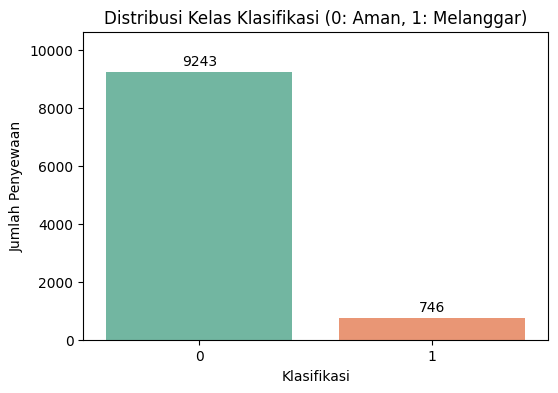

/tmp/ipykernel_3382/994572986.py:100: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_eda['checkin_hour_num'] = pd.to_datetime(df_eda['waktu_checkin'], errors='coerce').dt.hour.fillna(0)
/tmp/ipykernel_3382/994572986.py:101: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_eda['checkout_hour_num'] = pd.to_datetime(df_eda['waktu_checkout'], errors='coerce').dt.hour.fillna(0)



[3] Rata-rata Pelanggaran Berdasarkan Seluruh Kategori:

--- Tingkat Pelanggaran Berdasarkan status_pasutri ---
status_pasutri
Menikah          0.076
Belum Menikah    0.073
Name: label, dtype: float64

--- Tingkat Pelanggaran Berdasarkan status_kewarganegaraan ---
status_kewarganegaraan
WNA    0.078
WNI    0.072
Name: label, dtype: float64

--- Tingkat Pelanggaran Berdasarkan jenis_sewa ---
jenis_sewa
Harian      0.232
Bulanan     0.000
Mingguan    0.000
Name: label, dtype: float64

--- Tingkat Pelanggaran Berdasarkan metode_pembayaran ---
metode_pembayaran
Others          0.081
QRIS            0.075
Cash            0.075
Kartu Debit     0.074
Kartu Kredit    0.069
Name: label, dtype: float64

[4] Korelasi Antar Fitur:


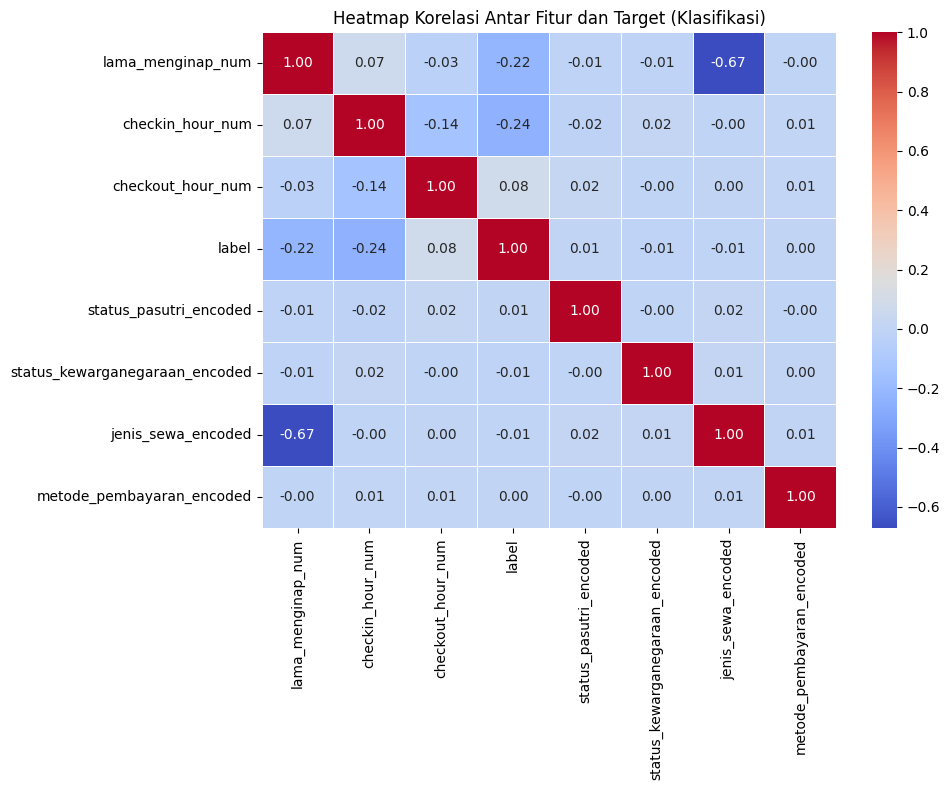


[5] Visualisasi Pola Penyewaan (Dikaitkan dengan Klasifikasi):


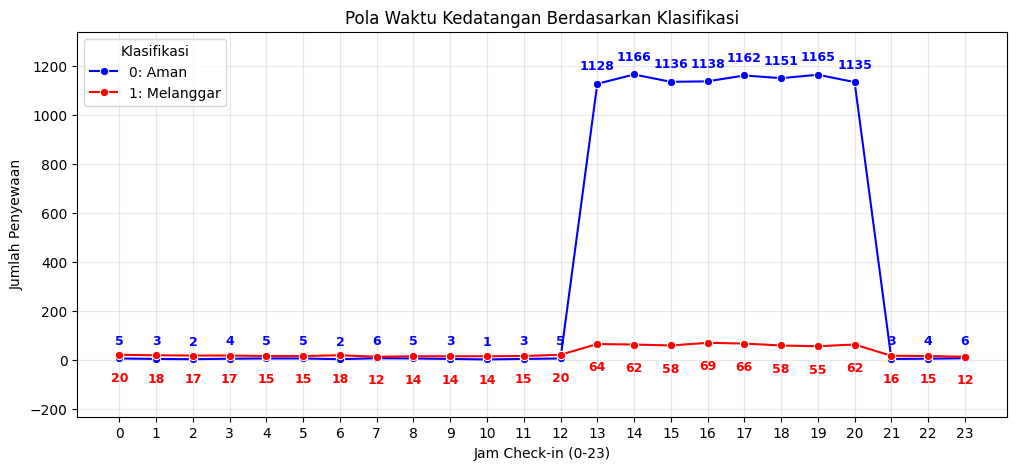

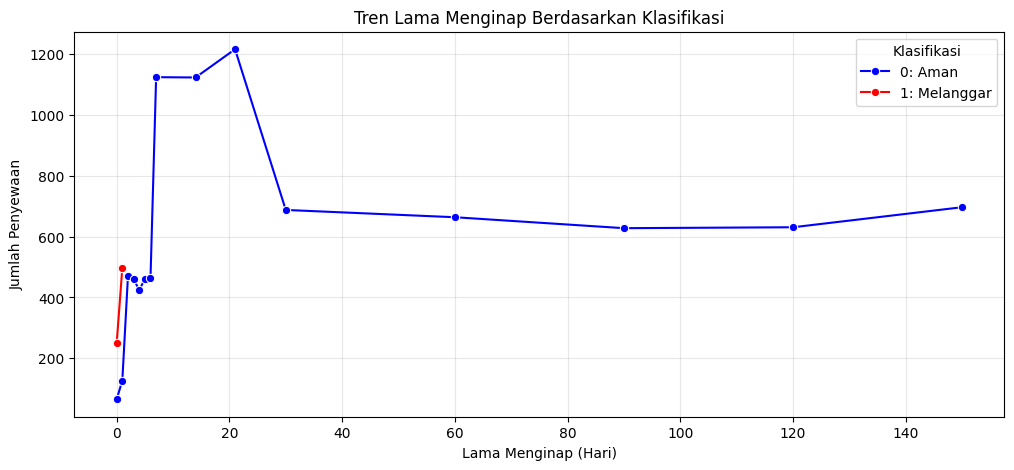

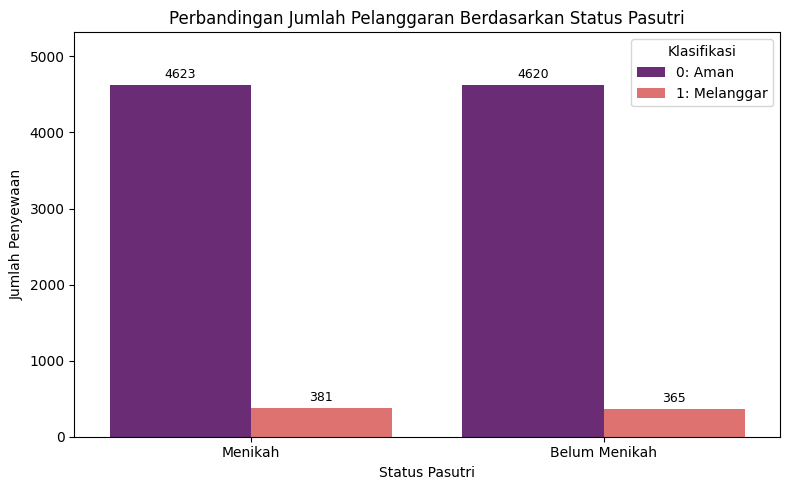

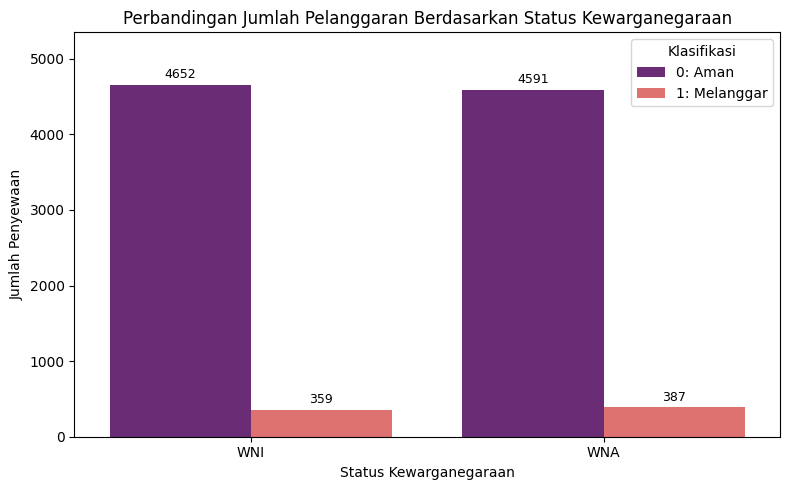

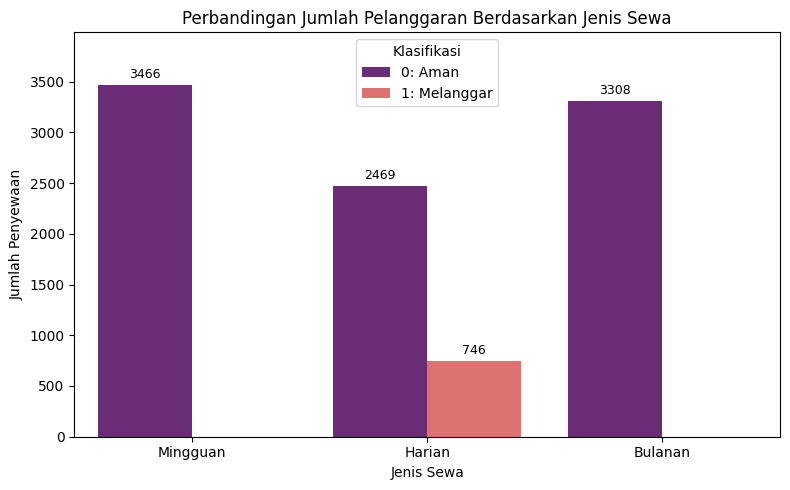

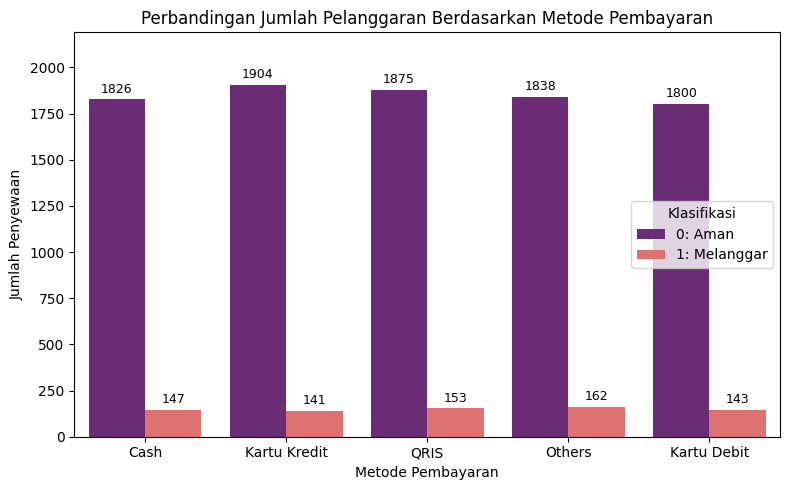


[5b] Visualisasi Metode Pembayaran 'Others' (metode_lain):


/tmp/ipykernel_3382/994572986.py:208: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


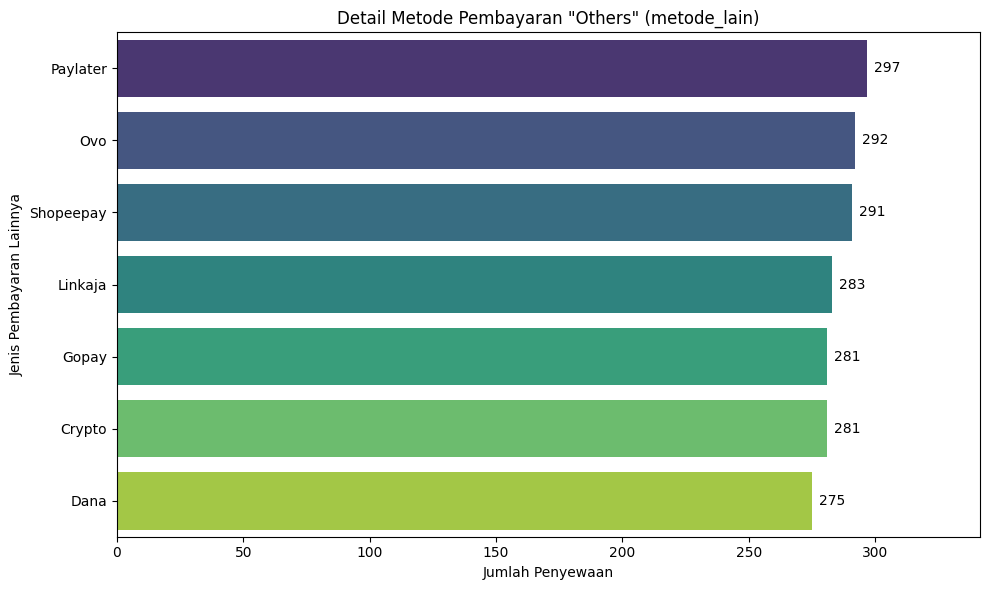

/tmp/ipykernel_3382/994572986.py:242: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  rentals['waktu_checkout_dt'] = pd.to_datetime(rentals['waktu_checkout'], errors='coerce')
/tmp/ipykernel_3382/994572986.py:245: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  rentals['waktu_checkin_dt'] = pd.to_datetime(rentals['waktu_checkin'], errors='coerce')



=== Proses Feature Selection ===

-> Fitur yang dipilih (4 terbaik): ['lama_menginap', 'checkin_hour', 'checkout_hour', 'jenis_sewa']

===== Decision Tree =====
Classification Report:
              precision    recall  f1-score   support

           0     1.0000    0.9822    0.9910      1849
           1     0.8187    1.0000    0.9003       149

    accuracy                         0.9835      1998
   macro avg     0.9093    0.9911    0.9456      1998
weighted avg     0.9865    0.9835    0.9842      1998

Confusion Matrix (Text):
                Predicted
               0       1
          -----------------
True   0 |   1816      33
       1 |      0     149
          -----------------


===== Random Forest =====
Classification Report:
              precision    recall  f1-score   support

           0     1.0000    0.9822    0.9910      1849
           1     0.8187    1.0000    0.9003       149

    accuracy                         0.9835      1998
   macro avg     0.9093    0.9911  

In [ ]:
# ============================================================
# DATA SEED (TANPA TUNING)
# ============================================================

import pandas as pd
import numpy as np
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.pipeline import make_pipeline
from sklearn.feature_selection import SelectKBest, chi2, mutual_info_classif

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier

import matplotlib.pyplot as plt
import seaborn as sns

# ------------------------------------------------------------
# 1. LOAD DATA
# ------------------------------------------------------------
rentals    = pd.read_csv('rentals.csv')
logs       = pd.read_csv('rental_logs.csv')
units      = pd.read_csv('units.csv')
users      = pd.read_csv('users.csv')
violations = pd.read_csv('violations.csv')

rentals.columns = rentals.columns.str.lower()

if 'komentar' not in rentals.columns:
    raise ValueError("Kolom 'komentar' tidak ditemukan di rentals.csv")

print("rentals.csv")
print(rentals.head())
print("logs.csv")
print(logs.head())
print("units.csv")
print(units.head())
print("users.csv")
print(users.head())
print("violations.csv")
print(violations.head())

# ------------------------------------------------------------
# 2. LABELING
# ------------------------------------------------------------
rentals['komentar'] = rentals['komentar'].astype(str).str.lower().str.strip()
empty_values = ["", "nan", "na", "null", "-", "0", "tidak ada", "none", " "]
rentals['label'] = (~rentals['komentar'].isin(empty_values)).astype(int)


# ============================================================
# EXPLORATORY DATA ANALYSIS (EDA)
# ============================================================
print("\n" + "="*50)
print("=== EXPLORATORY DATA ANALYSIS (EDA) ===")
print("="*50)

df_eda = rentals.copy()

print("\n[1] Statistik Deskriptif:")
print(df_eda.describe(include='all'))

print("\n[2] Distribusi Kelas Target (0: Aman, 1: Melanggar):")
print(df_eda['label'].value_counts())

fig, ax = plt.subplots(figsize=(6, 4))
sns.countplot(data=df_eda, x='label', palette='Set2', ax=ax)
plt.title('Distribusi Kelas Klasifikasi (0: Aman, 1: Melanggar)')
plt.xlabel('Klasifikasi')
plt.ylabel('Jumlah Penyewaan')

y_max = df_eda['label'].value_counts().max()
plt.ylim(0, y_max * 1.15)

for p in ax.patches:
    if p.get_height() > 0:
        ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='baseline', fontsize=10, color='black', xytext=(0, 5),
                    textcoords='offset points')
plt.show()

kolom_dikecualikan = ['id', 'nama', 'nik', 'unit_number', 'tanggal_checkin', 'waktu_checkin',
                      'tanggal_checkout', 'waktu_checkout', 'komentar', 'user_email', 'diedit_oleh', 'created_at', 'metode_lain', 'classification']

semua_kategori = [col for col in df_eda.select_dtypes(include=['object', 'category']).columns if col not in kolom_dikecualikan]

print("\n[3] Rata-rata Pelanggaran Berdasarkan Seluruh Kategori:")
for col in semua_kategori:
    if col in df_eda.columns:
        print(f"\n--- Tingkat Pelanggaran Berdasarkan {col} ---")
        print(df_eda.groupby(col)['label'].mean().sort_values(ascending=False).round(3))

df_eda['lama_menginap_num'] = pd.to_numeric(df_eda['lama_menginap'], errors='coerce').fillna(0)
df_eda['checkin_hour_num'] = pd.to_datetime(df_eda['waktu_checkin'], errors='coerce').dt.hour.fillna(0)
df_eda['checkout_hour_num'] = pd.to_datetime(df_eda['waktu_checkout'], errors='coerce').dt.hour.fillna(0)

le_eda = LabelEncoder()
for c in semua_kategori:
    if c in df_eda.columns:
        df_eda[c + '_encoded'] = le_eda.fit_transform(df_eda[c].astype(str))

print("\n[4] Korelasi Antar Fitur:")
kolom_korelasi = ['lama_menginap_num', 'checkin_hour_num', 'checkout_hour_num', 'label']
kolom_korelasi += [c + '_encoded' for c in semua_kategori if c + '_encoded' in df_eda.columns]

corr_matrix = df_eda[kolom_korelasi].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Heatmap Korelasi Antar Fitur dan Target (Klasifikasi)')
plt.tight_layout()
plt.show()

print("\n[5] Visualisasi Pola Penyewaan (Dikaitkan dengan Klasifikasi):")

custom_line_palette = {0: 'blue', 1: 'red'}
custom_labels = ['0: Aman', '1: Melanggar']

fig, ax1 = plt.subplots(figsize=(12, 5))
waktu_df = df_eda.groupby(['checkin_hour_num', 'label']).size().reset_index(name='jumlah')

sns.lineplot(data=waktu_df, x='checkin_hour_num', y='jumlah', hue='label', marker='o', palette=custom_line_palette, ax=ax1)

plt.title('Pola Waktu Kedatangan Berdasarkan Klasifikasi')
plt.xlabel('Jam Check-in (0-23)')
plt.ylabel('Jumlah Penyewaan')
plt.xticks(range(0, 24))
plt.grid(True, alpha=0.3)

y_max_line = waktu_df['jumlah'].max()
plt.ylim(-y_max_line * 0.20, y_max_line * 1.15)

handles, _ = ax1.get_legend_handles_labels()
plt.legend(handles=handles, labels=custom_labels, title='Klasifikasi')

for l in waktu_df['label'].unique():
    sub = waktu_df[waktu_df['label'] == l]
    warna_teks = custom_line_palette[l]

    for x, y in zip(sub['checkin_hour_num'], sub['jumlah']):
        y_offset = 8 if l == 0 else -12
        va_align = 'bottom' if l == 0 else 'top'
        plt.annotate(f'{int(y)}', (x, y), textcoords="offset points", xytext=(0, y_offset),
                     ha='center', va=va_align, fontsize=9, color=warna_teks, fontweight='bold')
plt.show()

fig, ax2 = plt.subplots(figsize=(12, 5))
lama_df = df_eda.groupby(['lama_menginap_num', 'label']).size().reset_index(name='jumlah')

sns.lineplot(data=lama_df, x='lama_menginap_num', y='jumlah', hue='label', marker='o', palette=custom_line_palette, ax=ax2)

plt.title('Tren Lama Menginap Berdasarkan Klasifikasi')
plt.xlabel('Lama Menginap (Hari)')
plt.ylabel('Jumlah Penyewaan')
plt.grid(True, alpha=0.3)

handles2, _ = ax2.get_legend_handles_labels()
plt.legend(handles=handles2, labels=custom_labels, title='Klasifikasi')
plt.show()

for col in semua_kategori:
    if col in df_eda.columns:
        fig, ax = plt.subplots(figsize=(8, 5))
        sns.countplot(data=df_eda, x=col, hue='label', palette='magma', ax=ax)

        judul_kolom = col.replace('_', ' ').title()
        plt.title(f'Perbandingan Jumlah Pelanggaran Berdasarkan {judul_kolom}')
        plt.xlabel(judul_kolom)
        plt.ylabel('Jumlah Penyewaan')
        plt.xticks(rotation=0)

        handles_bar, _ = ax.get_legend_handles_labels()
        plt.legend(handles=handles_bar, labels=custom_labels, title='Klasifikasi')

        y_max_bar = df_eda.groupby([col, 'label']).size().max()
        plt.ylim(0, y_max_bar * 1.15)

        for p in ax.patches:
            if p.get_height() > 0:
                ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                            ha='center', va='baseline', fontsize=9, color='black', xytext=(0, 5),
                            textcoords='offset points')
        plt.tight_layout()
        plt.show()


print("\n[5b] Visualisasi Metode Pembayaran 'Others' (metode_lain):")

# Memastikan kolom 'metode_lain' berbentuk string dan membersihkan spasi/nilai kosong
df_eda['metode_lain'] = df_eda['metode_lain'].astype(str).str.strip().str.title()
empty_lain = ["", "Nan", "Na", "Null", "-", "0", "None"]

# Filter hanya baris yang memiliki nilai di 'metode_lain'
df_others = df_eda[~df_eda['metode_lain'].isin(empty_lain)]

if not df_others.empty:
    fig, ax = plt.subplots(figsize=(10, 6))

    # Menghitung frekuensi masing-masing metode pembayaran lain
    order_others = df_others['metode_lain'].value_counts().index

    sns.countplot(
        data=df_others,
        y='metode_lain',
        order=order_others,
        palette='viridis',
        ax=ax
    )

    plt.title('Detail Metode Pembayaran "Others" (metode_lain)')
    plt.xlabel('Jumlah Penyewaan')
    plt.ylabel('Jenis Pembayaran Lainnya')

    # Menambahkan anotasi angka di sebelah setiap bar
    for p in ax.patches:
        width = p.get_width()
        if width > 0:
            ax.annotate(f'{int(width)}',
                        (width, p.get_y() + p.get_height() / 2.),
                        ha='left', va='center', fontsize=10, color='black',
                        xytext=(5, 0), textcoords='offset points')

    # Perlebar batas x-axis sedikit agar angka anotasi tidak terpotong
    x_max = df_others['metode_lain'].value_counts().max()
    plt.xlim(0, x_max * 1.15)

    plt.tight_layout()
    plt.show()
else:
    print("Tidak ada data metode pembayaran 'Others' yang valid untuk ditampilkan.")


# ------------------------------------------------------------
# 3. FEATURE ENGINEERING & PREPARATION
# ------------------------------------------------------------
rentals['waktu_checkout_dt'] = pd.to_datetime(rentals['waktu_checkout'], errors='coerce')
rentals['checkout_hour'] = rentals['waktu_checkout_dt'].dt.hour.fillna(0).astype(int)

rentals['waktu_checkin_dt'] = pd.to_datetime(rentals['waktu_checkin'], errors='coerce')
rentals['checkin_hour'] = rentals['waktu_checkin_dt'].dt.hour.fillna(0).astype(int)

rentals['lama_menginap'] = pd.to_numeric(rentals['lama_menginap'], errors='coerce').fillna(0)

cat_cols = ['jenis_sewa', 'metode_pembayaran', 'status_pasutri', 'status_kewarganegaraan']
for c in cat_cols:
    rentals[c] = rentals[c].fillna('Unknown').astype(str)

numeric_cols = ['checkout_hour', 'checkin_hour', 'lama_menginap']
feature_cols = cat_cols + numeric_cols

X = rentals[feature_cols].copy()
y = rentals['label']

# ------------------------------------------------------------
# 4. TRAIN-TEST SPLIT
# ------------------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, stratify=y, test_size=0.2, random_state=42
)

# ------------------------------------------------------------
# 4B. ENCODING MENCEGAH DATA LEAKAGE
# ------------------------------------------------------------
label_encoders = {}

for c in cat_cols:
    le = LabelEncoder()
    X_train[c] = le.fit_transform(X_train[c])

    X_test[c] = X_test[c].map(lambda s: s if s in le.classes_ else 'Unknown')
    if 'Unknown' not in le.classes_:
        le.classes_ = np.append(le.classes_, 'Unknown')

    X_test[c] = le.transform(X_test[c])

    label_encoders[c] = le

# ------------------------------------------------------------
# 5. FEATURE SELECTION
# ------------------------------------------------------------
print("\n=== Proses Feature Selection ===")
chi2_selector = SelectKBest(score_func=chi2, k='all')
chi2_selector.fit(X_train, y_train)

train_df = X_train.copy()
train_df['label'] = y_train
pearson_scores = train_df.corr(method='pearson')['label'].drop('label').abs().values

mi_selector = SelectKBest(score_func=mutual_info_classif, k='all')
mi_selector.fit(X_train, y_train)

fs_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Chi-Square': chi2_selector.scores_,
    'Pearson (Abs)': pearson_scores,
    'Mutual Info': mi_selector.scores_
})

scaler = MinMaxScaler()
fs_df[['Chi2_Norm', 'Pearson_Norm', 'MI_Norm']] = scaler.fit_transform(
    fs_df[['Chi-Square', 'Pearson (Abs)', 'Mutual Info']]
)
fs_df['Total_Score'] = fs_df[['Chi2_Norm', 'Pearson_Norm', 'MI_Norm']].mean(axis=1)
fs_df = fs_df.sort_values(by='Total_Score', ascending=False).reset_index(drop=True)

# Jumlah Fitur
n_select = 4
selected_features = fs_df['Feature'].head(n_select).tolist()
print(f"\n-> Fitur yang dipilih ({n_select} terbaik): {selected_features}")

X_train = X_train[selected_features]
X_test = X_test[selected_features]

# ------------------------------------------------------------
# 6. Fungsi Evaluasi
# ------------------------------------------------------------
def evaluate(name, model):
    y_pred = model.predict(X_test)
    print(f"\n===== {name} =====")
    print("Classification Report:")
    print(classification_report(y_test, y_pred, digits=4))
    cm = confusion_matrix(y_test, y_pred)
    print("Confusion Matrix (Text):")
    print("                Predicted")
    print("               0       1")
    print("          -----------------")
    print(f"True   0 | {cm[0][0]:6d}  {cm[0][1]:6d}")
    print(f"       1 | {cm[1][0]:6d}  {cm[1][1]:6d}")
    print("          -----------------\n")

# ------------------------------------------------------------
# 7. Latih Semua Model (TANPA TUNING)
# ------------------------------------------------------------
models = {}
custom_weight = {0: 1, 1: 4}

# Model menggunakan pengaturan tetap
models["Decision Tree"] = DecisionTreeClassifier(max_depth=6, class_weight=custom_weight, random_state=42)
models["Random Forest"] = RandomForestClassifier(n_estimators=200, max_depth=7, class_weight=custom_weight, random_state=42)
models["KNN"] = make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=5, weights='distance'))
models["SVM RBF"] = make_pipeline(StandardScaler(), SVC(kernel='rbf', probability=True, class_weight=custom_weight, random_state=42))
models["XGBoost"] = XGBClassifier(n_estimators=200, max_depth=5, learning_rate=0.05, scale_pos_weight=4, eval_metric='logloss', random_state=42)

for name, model in models.items():
    model.fit(X_train, y_train)
    evaluate(name, model)

# ------------------------------------------------------------
# 8. Eksport Model Terbaik & Label Encoders
# ------------------------------------------------------------
print("\n=== Proses Export Model ===")

export_package = {
    'model': models["Random Forest"],
    'label_encoders': label_encoders,
    'selected_features': selected_features
}

filename = 'model_random_forest.pkl'
joblib.dump(export_package, filename)
print(f"Sukses! Model dan Label Encoders telah disimpan sebagai file: {filename}")

DATA SEED (DENGAN TUNING)

renatls.csv
   id                nama               nik status_pasutri  \
0   1        Faith Barton  5178954204070908        Menikah   
1   2      Edmund Pfeffer  3219671108856742        Menikah   
2   3        Oscar Hansen  3582831012052287  Belum Menikah   
3   4  Nathan Barton-Bode  3534442910807991  Belum Menikah   
4   5       Richard Sauer  3396683107706646        Menikah   

  status_kewarganegaraan jenis_sewa unit_number metode_pembayaran metode_lain  \
0                    WNI   Mingguan      C-1-13              Cash         NaN   
1                    WNA     Harian       D-5-2      Kartu Kredit         NaN   
2                    WNI    Bulanan     B-25-17              QRIS         NaN   
3                    WNI    Bulanan       A-2-8            Others       gopay   
4                    WNI     Harian      A-21-9       Kartu Debit         NaN   

  tanggal_checkin waktu_checkin tanggal_checkout waktu_checkout  \
0      2024-06-20      20:22:00       2024-07-04       07:46:

/tmp/ipykernel_3382/3979709149.py:69: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_eda, x='label', palette='Set2', ax=ax)


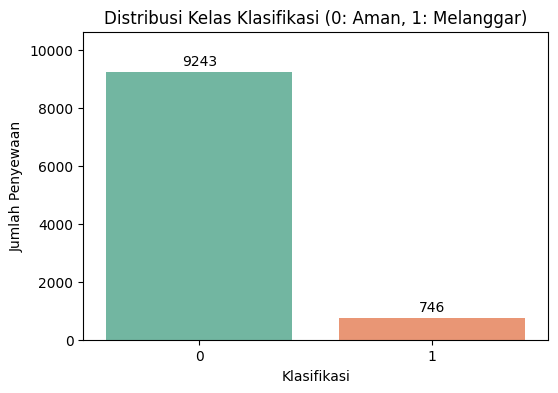

/tmp/ipykernel_3382/3979709149.py:96: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_eda['checkin_hour_num'] = pd.to_datetime(df_eda['waktu_checkin'], errors='coerce').dt.hour.fillna(0)
/tmp/ipykernel_3382/3979709149.py:97: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_eda['checkout_hour_num'] = pd.to_datetime(df_eda['waktu_checkout'], errors='coerce').dt.hour.fillna(0)



[3] Rata-rata Pelanggaran Berdasarkan Seluruh Kategori:

--- Tingkat Pelanggaran Berdasarkan status_pasutri ---
status_pasutri
Menikah          0.076
Belum Menikah    0.073
Name: label, dtype: float64

--- Tingkat Pelanggaran Berdasarkan status_kewarganegaraan ---
status_kewarganegaraan
WNA    0.078
WNI    0.072
Name: label, dtype: float64

--- Tingkat Pelanggaran Berdasarkan jenis_sewa ---
jenis_sewa
Harian      0.232
Bulanan     0.000
Mingguan    0.000
Name: label, dtype: float64

--- Tingkat Pelanggaran Berdasarkan metode_pembayaran ---
metode_pembayaran
Others          0.081
QRIS            0.075
Cash            0.075
Kartu Debit     0.074
Kartu Kredit    0.069
Name: label, dtype: float64

[4] Korelasi Antar Fitur:


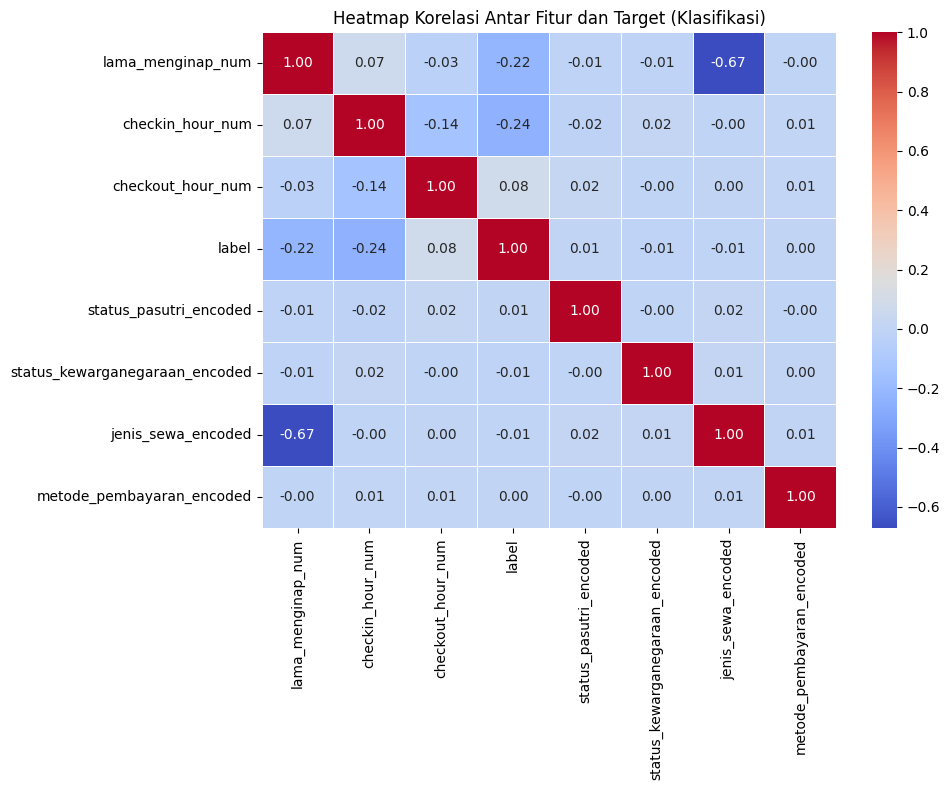


[5] Visualisasi Pola Penyewaan (Dikaitkan dengan Klasifikasi):


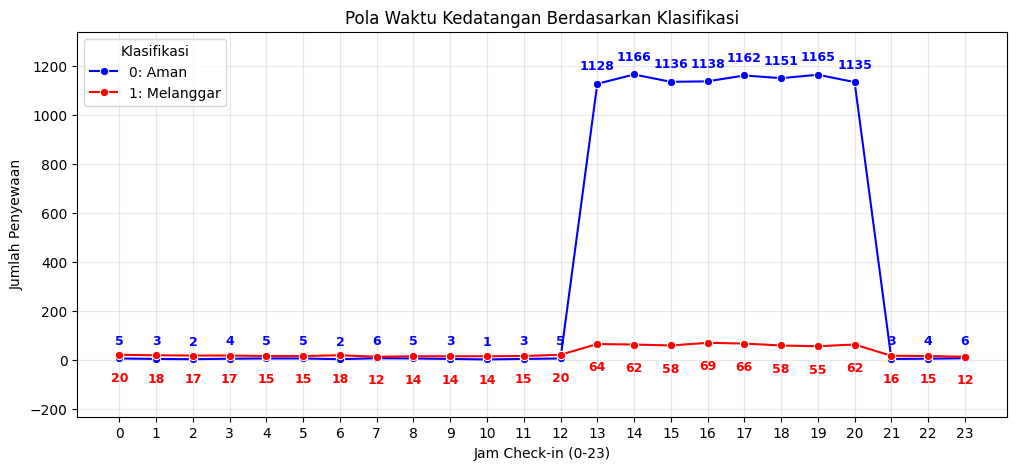

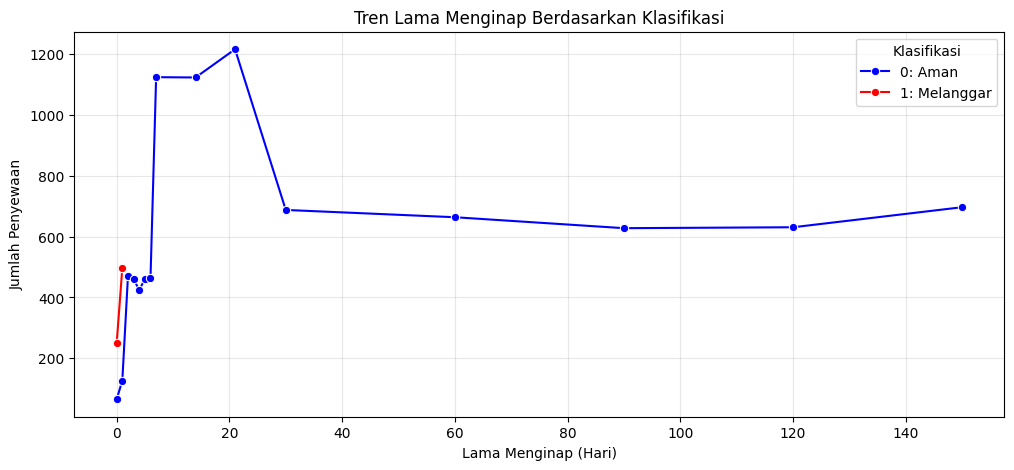

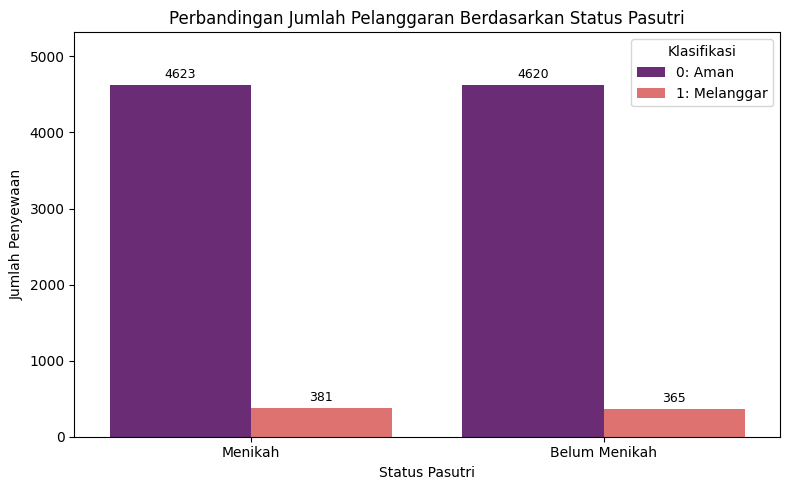

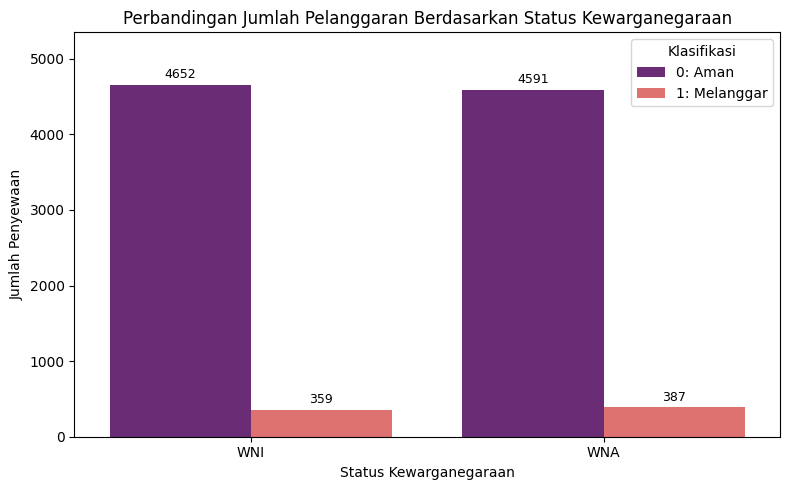

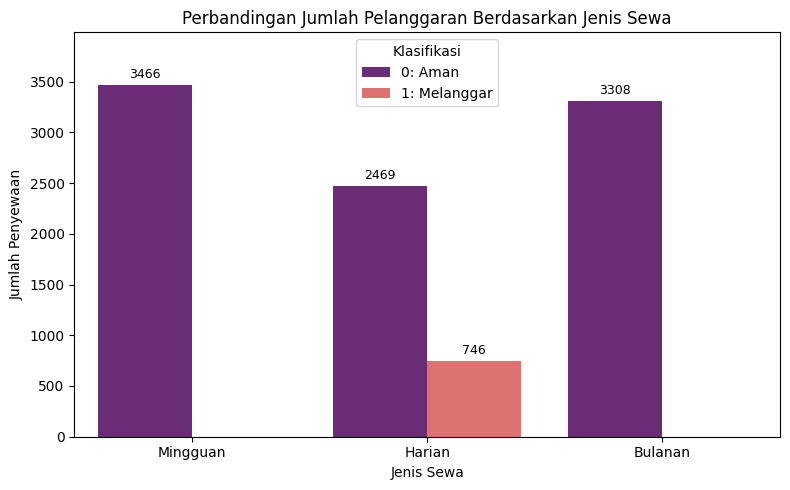

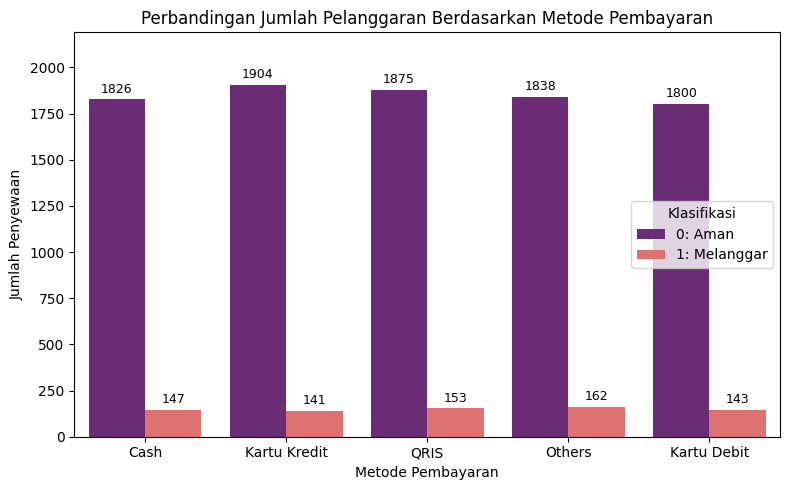


[5b] Visualisasi Metode Pembayaran 'Others' (metode_lain):


/tmp/ipykernel_3382/3979709149.py:204: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


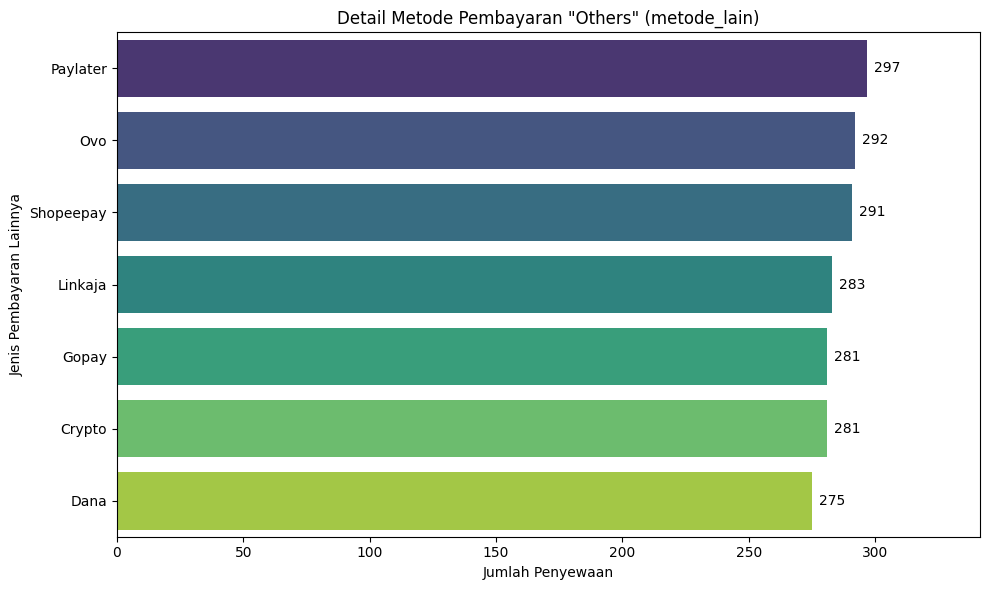

/tmp/ipykernel_3382/3979709149.py:238: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  rentals['waktu_checkout_dt'] = pd.to_datetime(rentals['waktu_checkout'], errors='coerce')
/tmp/ipykernel_3382/3979709149.py:242: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  rentals['waktu_checkin_dt'] = pd.to_datetime(rentals['waktu_checkin'], errors='coerce')



=== Proses Feature Selection ===

-> Fitur yang dipilih (4 terbaik): ['lama_menginap', 'checkin_hour', 'checkout_hour', 'jenis_sewa']

Memulai proses Hyperparameter Tuning untuk semua model. Ini mungkin memakan waktu...

>> Tuning Decision Tree...
>> Tuning Random Forest...
>> Tuning KNN...
>> Tuning SVM...
>> Tuning XGBoost...

===== Decision Tree (Tuned) =====
Classification Report:
              precision    recall  f1-score   support

           0     1.0000    0.9816    0.9907      1849
           1     0.8142    1.0000    0.8976       149

    accuracy                         0.9830      1998
   macro avg     0.9071    0.9908    0.9442      1998
weighted avg     0.9861    0.9830    0.9838      1998

Confusion Matrix (Text):
                Predicted
               0       1
          -----------------
True   0 |   1815      34
       1 |      0     149
          -----------------


===== Random Forest (Tuned) =====
Classification Report:
              precision    recall  f1-sco

In [ ]:
# ============================================================
# DATA SEED + Tunning
# ============================================================

import pandas as pd
import numpy as np
import joblib

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.pipeline import make_pipeline
from sklearn.feature_selection import SelectKBest, chi2, mutual_info_classif

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier

# ------------------------------------------------------------
# 1. LOAD DATA
# ------------------------------------------------------------
rentals   = pd.read_csv('rentals.csv')
logs      = pd.read_csv('rental_logs.csv')
units     = pd.read_csv('units.csv')
users     = pd.read_csv('users.csv')
violations= pd.read_csv('violations.csv')

rentals.columns = rentals.columns.str.lower()

if 'komentar' not in rentals.columns:
    raise ValueError("Kolom 'komentar' tidak ditemukan di rentals.csv")

print("renatls.csv")
print(rentals.head())
print("logs.csv")
print(logs.head())
print("units.csv")
print(units.head())
print("users.csv")
print(users.head())
print("violations.csv")
print(violations.head())

# ------------------------------------------------------------
# 2. LABELING
# ------------------------------------------------------------
rentals['komentar'] = rentals['komentar'].astype(str).str.lower().str.strip()
empty_values = ["", "nan", "na", "null", "-", "0", "tidak ada", "none", " "]
rentals['label'] = (~rentals['komentar'].isin(empty_values)).astype(int)

# ============================================================
# EXPLORATORY DATA ANALYSIS (EDA)
# ============================================================
print("\n" + "="*50)
print("=== EXPLORATORY DATA ANALYSIS (EDA) ===")
print("="*50)

df_eda = rentals.copy()

print("\n[1] Statistik Deskriptif:")
print(df_eda.describe(include='all'))

print("\n[2] Distribusi Kelas Target (0: Aman, 1: Melanggar):")
print(df_eda['label'].value_counts())

fig, ax = plt.subplots(figsize=(6, 4))
sns.countplot(data=df_eda, x='label', palette='Set2', ax=ax)
plt.title('Distribusi Kelas Klasifikasi (0: Aman, 1: Melanggar)')
plt.xlabel('Klasifikasi')
plt.ylabel('Jumlah Penyewaan')

y_max = df_eda['label'].value_counts().max()
plt.ylim(0, y_max * 1.15)

for p in ax.patches:
    if p.get_height() > 0:
        ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='baseline', fontsize=10, color='black', xytext=(0, 5),
                    textcoords='offset points')
plt.show()

kolom_dikecualikan = ['id', 'nama', 'nik', 'unit_number', 'tanggal_checkin', 'waktu_checkin',
                      'tanggal_checkout', 'waktu_checkout', 'komentar', 'user_email', 'diedit_oleh', 'created_at', 'metode_lain', 'classification']

semua_kategori = [col for col in df_eda.select_dtypes(include=['object', 'category']).columns if col not in kolom_dikecualikan]

print("\n[3] Rata-rata Pelanggaran Berdasarkan Seluruh Kategori:")
for col in semua_kategori:
    if col in df_eda.columns:
        print(f"\n--- Tingkat Pelanggaran Berdasarkan {col} ---")
        print(df_eda.groupby(col)['label'].mean().sort_values(ascending=False).round(3))

df_eda['lama_menginap_num'] = pd.to_numeric(df_eda['lama_menginap'], errors='coerce').fillna(0)
df_eda['checkin_hour_num'] = pd.to_datetime(df_eda['waktu_checkin'], errors='coerce').dt.hour.fillna(0)
df_eda['checkout_hour_num'] = pd.to_datetime(df_eda['waktu_checkout'], errors='coerce').dt.hour.fillna(0)

le_eda = LabelEncoder()
for c in semua_kategori:
    if c in df_eda.columns:
        df_eda[c + '_encoded'] = le_eda.fit_transform(df_eda[c].astype(str))

print("\n[4] Korelasi Antar Fitur:")
kolom_korelasi = ['lama_menginap_num', 'checkin_hour_num', 'checkout_hour_num', 'label']
kolom_korelasi += [c + '_encoded' for c in semua_kategori if c + '_encoded' in df_eda.columns]

corr_matrix = df_eda[kolom_korelasi].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Heatmap Korelasi Antar Fitur dan Target (Klasifikasi)')
plt.tight_layout()
plt.show()

print("\n[5] Visualisasi Pola Penyewaan (Dikaitkan dengan Klasifikasi):")

custom_line_palette = {0: 'blue', 1: 'red'}
custom_labels = ['0: Aman', '1: Melanggar']

fig, ax1 = plt.subplots(figsize=(12, 5))
waktu_df = df_eda.groupby(['checkin_hour_num', 'label']).size().reset_index(name='jumlah')

sns.lineplot(data=waktu_df, x='checkin_hour_num', y='jumlah', hue='label', marker='o', palette=custom_line_palette, ax=ax1)

plt.title('Pola Waktu Kedatangan Berdasarkan Klasifikasi')
plt.xlabel('Jam Check-in (0-23)')
plt.ylabel('Jumlah Penyewaan')
plt.xticks(range(0, 24))
plt.grid(True, alpha=0.3)

y_max_line = waktu_df['jumlah'].max()
plt.ylim(-y_max_line * 0.20, y_max_line * 1.15)

handles, _ = ax1.get_legend_handles_labels()
plt.legend(handles=handles, labels=custom_labels, title='Klasifikasi')

for l in waktu_df['label'].unique():
    sub = waktu_df[waktu_df['label'] == l]
    warna_teks = custom_line_palette[l]

    for x, y in zip(sub['checkin_hour_num'], sub['jumlah']):
        y_offset = 8 if l == 0 else -12
        va_align = 'bottom' if l == 0 else 'top'
        plt.annotate(f'{int(y)}', (x, y), textcoords="offset points", xytext=(0, y_offset),
                     ha='center', va=va_align, fontsize=9, color=warna_teks, fontweight='bold')
plt.show()

fig, ax2 = plt.subplots(figsize=(12, 5))
lama_df = df_eda.groupby(['lama_menginap_num', 'label']).size().reset_index(name='jumlah')

sns.lineplot(data=lama_df, x='lama_menginap_num', y='jumlah', hue='label', marker='o', palette=custom_line_palette, ax=ax2)

plt.title('Tren Lama Menginap Berdasarkan Klasifikasi')
plt.xlabel('Lama Menginap (Hari)')
plt.ylabel('Jumlah Penyewaan')
plt.grid(True, alpha=0.3)

handles2, _ = ax2.get_legend_handles_labels()
plt.legend(handles=handles2, labels=custom_labels, title='Klasifikasi')
plt.show()

for col in semua_kategori:
    if col in df_eda.columns:
        fig, ax = plt.subplots(figsize=(8, 5))
        sns.countplot(data=df_eda, x=col, hue='label', palette='magma', ax=ax)

        judul_kolom = col.replace('_', ' ').title()
        plt.title(f'Perbandingan Jumlah Pelanggaran Berdasarkan {judul_kolom}')
        plt.xlabel(judul_kolom)
        plt.ylabel('Jumlah Penyewaan')
        plt.xticks(rotation=0)

        handles_bar, _ = ax.get_legend_handles_labels()
        plt.legend(handles=handles_bar, labels=custom_labels, title='Klasifikasi')

        y_max_bar = df_eda.groupby([col, 'label']).size().max()
        plt.ylim(0, y_max_bar * 1.15)

        for p in ax.patches:
            if p.get_height() > 0:
                ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                            ha='center', va='baseline', fontsize=9, color='black', xytext=(0, 5),
                            textcoords='offset points')
        plt.tight_layout()
        plt.show()


print("\n[5b] Visualisasi Metode Pembayaran 'Others' (metode_lain):")

# Memastikan kolom 'metode_lain' berbentuk string dan membersihkan spasi/nilai kosong
df_eda['metode_lain'] = df_eda['metode_lain'].astype(str).str.strip().str.title()
empty_lain = ["", "Nan", "Na", "Null", "-", "0", "None"]

# Filter hanya baris yang memiliki nilai di 'metode_lain'
df_others = df_eda[~df_eda['metode_lain'].isin(empty_lain)]

if not df_others.empty:
    fig, ax = plt.subplots(figsize=(10, 6))

    # Menghitung frekuensi masing-masing metode pembayaran lain
    order_others = df_others['metode_lain'].value_counts().index

    sns.countplot(
        data=df_others,
        y='metode_lain',
        order=order_others,
        palette='viridis',
        ax=ax
    )

    plt.title('Detail Metode Pembayaran "Others" (metode_lain)')
    plt.xlabel('Jumlah Penyewaan')
    plt.ylabel('Jenis Pembayaran Lainnya')

    # Menambahkan anotasi angka di sebelah setiap bar
    for p in ax.patches:
        width = p.get_width()
        if width > 0:
            ax.annotate(f'{int(width)}',
                        (width, p.get_y() + p.get_height() / 2.),
                        ha='left', va='center', fontsize=10, color='black',
                        xytext=(5, 0), textcoords='offset points')

    # Perlebar batas x-axis sedikit agar angka anotasi tidak terpotong
    x_max = df_others['metode_lain'].value_counts().max()
    plt.xlim(0, x_max * 1.15)

    plt.tight_layout()
    plt.show()
else:
    print("Tidak ada data metode pembayaran 'Others' yang valid untuk ditampilkan.")

# ------------------------------------------------------------
# 3. FEATURE ENGINEERING & PREPARATION
# ------------------------------------------------------------
# Parse waktu checkout
rentals['waktu_checkout_dt'] = pd.to_datetime(rentals['waktu_checkout'], errors='coerce')
rentals['checkout_hour'] = rentals['waktu_checkout_dt'].dt.hour.fillna(0).astype(int)

# Parse waktu checkin
rentals['waktu_checkin_dt'] = pd.to_datetime(rentals['waktu_checkin'], errors='coerce')
rentals['checkin_hour'] = rentals['waktu_checkin_dt'].dt.hour.fillna(0).astype(int)

# Pastikan lama_menginap berupa angka
rentals['lama_menginap'] = pd.to_numeric(rentals['lama_menginap'], errors='coerce').fillna(0)

# Isi data kosong untuk kolom kategorikal sebelum split
cat_cols = ['jenis_sewa', 'metode_pembayaran', 'status_pasutri', 'status_kewarganegaraan']
for c in cat_cols:
    rentals[c] = rentals[c].fillna('Unknown').astype(str)

numeric_cols = ['checkout_hour', 'checkin_hour', 'lama_menginap']
feature_cols = cat_cols + numeric_cols

X = rentals[feature_cols].copy()
y = rentals['label']

# ------------------------------------------------------------
# 4. TRAIN-TEST SPLIT
# ------------------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, stratify=y, test_size=0.2, random_state=42
)

# ------------------------------------------------------------
# 4B. ENCODING MENCEGAH DATA LEAKAGE
# ------------------------------------------------------------
# Simpan semua LabelEncoder ke dalam dictionary agar bisa di-export
label_encoders = {}

for c in cat_cols:
    le = LabelEncoder()
    # Fit & Transform pada data latih
    X_train[c] = le.fit_transform(X_train[c])

    # Tangani unseen labels pada data uji (ubah jadi 'Unknown' jika tidak pernah dilihat di X_train untuk mencegah error saat deployment
    X_test[c] = X_test[c].map(lambda s: s if s in le.classes_ else 'Unknown')
    if 'Unknown' not in le.classes_:
        le.classes_ = np.append(le.classes_, 'Unknown')

    X_test[c] = le.transform(X_test[c])

    # Simpan object le
    label_encoders[c] = le

# ------------------------------------------------------------
# 5. FEATURE SELECTION
# ------------------------------------------------------------
print("\n=== Proses Feature Selection ===")
chi2_selector = SelectKBest(score_func=chi2, k='all')
chi2_selector.fit(X_train, y_train)

train_df = X_train.copy()
train_df['label'] = y_train
pearson_scores = train_df.corr(method='pearson')['label'].drop('label').abs().values

mi_selector = SelectKBest(score_func=mutual_info_classif, k='all')
mi_selector.fit(X_train, y_train)

fs_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Chi-Square': chi2_selector.scores_,
    'Pearson (Abs)': pearson_scores,
    'Mutual Info': mi_selector.scores_
})

scaler = MinMaxScaler()
fs_df[['Chi2_Norm', 'Pearson_Norm', 'MI_Norm']] = scaler.fit_transform(
    fs_df[['Chi-Square', 'Pearson (Abs)', 'Mutual Info']]
)
fs_df['Total_Score'] = fs_df[['Chi2_Norm', 'Pearson_Norm', 'MI_Norm']].mean(axis=1)
fs_df = fs_df.sort_values(by='Total_Score', ascending=False).reset_index(drop=True)

# Pilih Jumlah Fitur
n_select = 4
selected_features = fs_df['Feature'].head(n_select).tolist()
print(f"\n-> Fitur yang dipilih ({n_select} terbaik): {selected_features}")

X_train = X_train[selected_features]
X_test = X_test[selected_features]

# ------------------------------------------------------------
# 6. Fungsi Evaluasi
# ------------------------------------------------------------
def evaluate(name, model):
    y_pred = model.predict(X_test)
    print(f"\n===== {name} =====")
    print("Classification Report:")
    print(classification_report(y_test, y_pred, digits=4))
    cm = confusion_matrix(y_test, y_pred)
    print("Confusion Matrix (Text):")
    print("                Predicted")
    print("               0       1")
    print("          -----------------")
    print(f"True   0 | {cm[0][0]:6d}  {cm[0][1]:6d}")
    print(f"       1 | {cm[1][0]:6d}  {cm[1][1]:6d}")
    print("          -----------------\n")

# ------------------------------------------------------------
# 7. Latih Semua Model & Hyperparameter Tuning
# ------------------------------------------------------------
models = {}
custom_weight = {0: 1, 1: 4}

# --- A. Definisikan Model Dasar ---
dt_base = DecisionTreeClassifier(class_weight=custom_weight, random_state=42)
rf_base = RandomForestClassifier(class_weight=custom_weight, random_state=42)
knn_base = make_pipeline(StandardScaler(), KNeighborsClassifier())
svm_base = make_pipeline(StandardScaler(), SVC(kernel='rbf', probability=True, class_weight=custom_weight, random_state=42))
xgb_base = XGBClassifier(scale_pos_weight=4, eval_metric='logloss', random_state=42)

print("\nMemulai proses Hyperparameter Tuning untuk semua model. Ini mungkin memakan waktu...\n")

# --- B. Proses Tuning Setiap Model ---

# 1. Decision Tree
print(">> Tuning Decision Tree...")
dt_param_grid = {'max_depth': [3, 5, 7, 10, None], 'min_samples_split': [2, 5, 10]}
dt_random = RandomizedSearchCV(dt_base, dt_param_grid, n_iter=10, cv=3, random_state=42, n_jobs=-1, scoring='f1_macro')
dt_random.fit(X_train, y_train)
models["Decision Tree (Tuned)"] = dt_random.best_estimator_

# 2. Random Forest
print(">> Tuning Random Forest...")
rf_param_grid = {'n_estimators': [100, 200, 300], 'max_depth': [5, 7, 10, None], 'min_samples_split': [2, 5, 10], 'min_samples_leaf': [1, 2, 4]}
rf_random = RandomizedSearchCV(rf_base, rf_param_grid, n_iter=10, cv=3, random_state=42, n_jobs=-1, scoring='f1_macro')
rf_random.fit(X_train, y_train)
models["Random Forest (Tuned)"] = rf_random.best_estimator_

# 3. KNN (Karena menggunakan pipeline, parameter ditambahkan prefix 'kneighborsclassifier__')
print(">> Tuning KNN...")
knn_param_grid = {'kneighborsclassifier__n_neighbors': [3, 5, 7, 9, 11], 'kneighborsclassifier__weights': ['uniform', 'distance']}
knn_random = RandomizedSearchCV(knn_base, knn_param_grid, n_iter=10, cv=3, random_state=42, n_jobs=-1, scoring='f1_macro')
knn_random.fit(X_train, y_train)
models["KNN (Tuned)"] = knn_random.best_estimator_

# 4. SVM (Karena menggunakan pipeline, parameter ditambahkan prefix 'svc__')
print(">> Tuning SVM...")
svm_param_grid = {'svc__C': [0.1, 1, 10], 'svc__gamma': ['scale', 'auto', 0.1, 0.01]}
svm_random = RandomizedSearchCV(svm_base, svm_param_grid, n_iter=10, cv=3, random_state=42, n_jobs=-1, scoring='f1_macro')
svm_random.fit(X_train, y_train)
models["SVM RBF (Tuned)"] = svm_random.best_estimator_

# 5. XGBoost
print(">> Tuning XGBoost...")
xgb_param_grid = {'learning_rate': [0.01, 0.05, 0.1, 0.2], 'max_depth': [3, 5, 7], 'n_estimators': [100, 200, 300]}
xgb_random = RandomizedSearchCV(xgb_base, xgb_param_grid, n_iter=10, cv=3, random_state=42, n_jobs=-1, scoring='f1_macro')
xgb_random.fit(X_train, y_train)
models["XGBoost (Tuned)"] = xgb_random.best_estimator_

# --- C. Evaluasi Semua Model yang Sudah Di-Tune ---
# Karena setiap .best_estimator_ sudah di-fit oleh RandomizedSearchCV pada seluruh X_train,
# kita bisa langsung memanggil fungsi evaluate tanpa perlu melakukan model.fit() lagi.
for name, model in models.items():
    evaluate(name, model)

# ------------------------------------------------------------
# 8. Eksport Model Terbaik & Label Encoders
# ------------------------------------------------------------
print("\n=== Proses Export Model ===")

# Gabungkan model dan encoders ke dalam satu dictionary agar rapi
export_package = {
    'model': models["Random Forest (Tuned)"],
    'label_encoders': label_encoders,
    'selected_features': selected_features # Penting agar tahu urutan kolom masuk saat predict
}

# Menentukan nama file
filename = 'model_random_forest.pkl'

# Menyimpan package ke dalam file .pkl
joblib.dump(export_package, filename)
print(f"Sukses! Model dan Label Encoders telah disimpan sebagai file: {filename}")

##**DATA RIIL**

rentals.csv
   id                   nama               nik status_pasutri  \
0   3  Novi Yanti Salsa Dewi  3204065911020004  Belum Menikah   
1   4     Amilia Nur Halimah  3520064903040001  Belum Menikah   
2   5     Achmad Agel Shahab  3525160508900001        Menikah   
3   6            Cries Wandi  1471051210920001  Belum Menikah   
4   7             SELO UTOMO  3171061909880002  Belum Menikah   

  status_kewarganegaraan jenis_sewa unit_number metode_pembayaran metode_lain  \
0                    WNI     Harian     B-20-27              Cash         NaN   
1                    WNI     Harian     A-15-25              Cash         NaN   
2                    WNI     Harian     A-06-24            Others    Aplikasi   
3                    WNI     Harian     D-15-21              QRIS         NaN   
4                    WNI     Harian       A-8-8            Others    Transfer   

  tanggal_checkin waktu_checkin tanggal_checkout waktu_checkout  \
0      2026-05-20      13:08:00       2026-

/tmp/ipykernel_1991/1767416320.py:70: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_eda, x='label', palette='Set2', ax=ax)


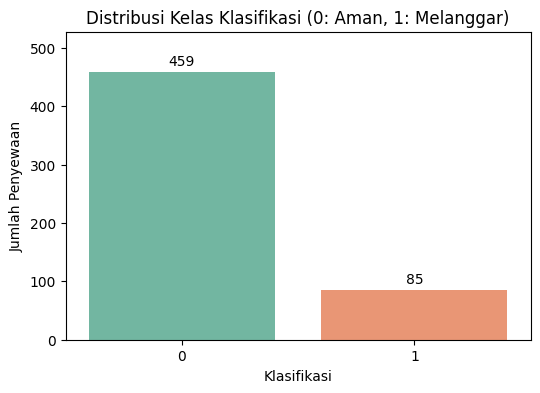

/tmp/ipykernel_1991/1767416320.py:97: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_eda['checkin_hour_num'] = pd.to_datetime(df_eda['waktu_checkin'], errors='coerce').dt.hour.fillna(0)
/tmp/ipykernel_1991/1767416320.py:98: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_eda['checkout_hour_num'] = pd.to_datetime(df_eda['waktu_checkout'], errors='coerce').dt.hour.fillna(0)



[3] Rata-rata Pelanggaran Berdasarkan Seluruh Kategori:

--- Tingkat Pelanggaran Berdasarkan status_pasutri ---
status_pasutri
Belum Menikah    0.164
Menikah          0.145
Name: label, dtype: float64

--- Tingkat Pelanggaran Berdasarkan status_kewarganegaraan ---
status_kewarganegaraan
WNI    0.156
Name: label, dtype: float64

--- Tingkat Pelanggaran Berdasarkan jenis_sewa ---
jenis_sewa
Harian     0.157
Bulanan    0.000
Name: label, dtype: float64

--- Tingkat Pelanggaran Berdasarkan metode_pembayaran ---
metode_pembayaran
Kartu Kredit    0.280
Others          0.158
Cash            0.150
QRIS            0.148
Kartu Debit     0.107
Name: label, dtype: float64

[4] Korelasi Antar Fitur:


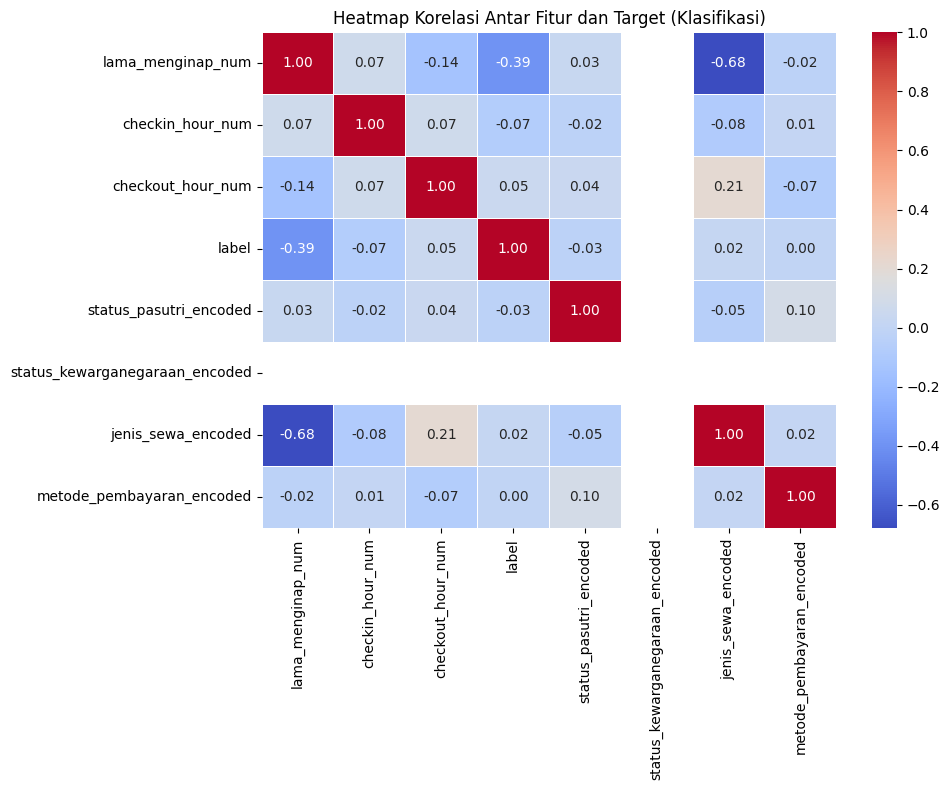


[5] Visualisasi Pola Penyewaan (Dikaitkan dengan Klasifikasi):


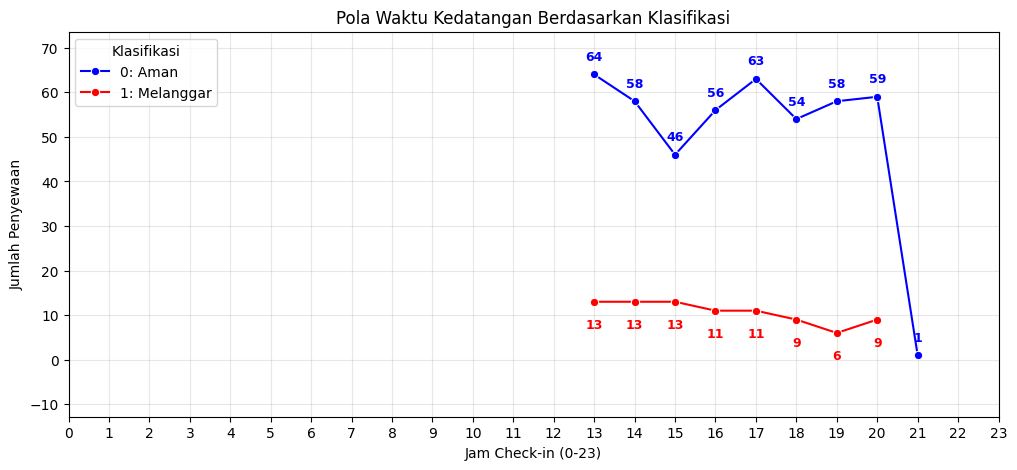

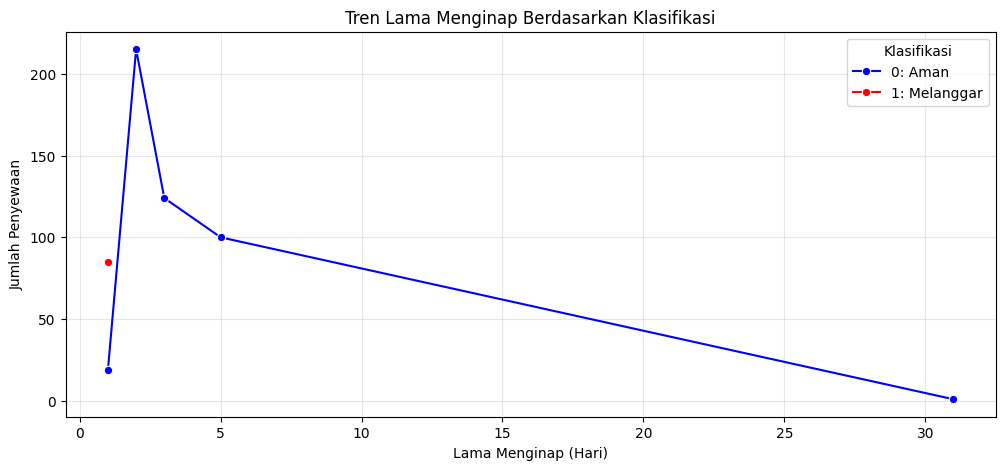

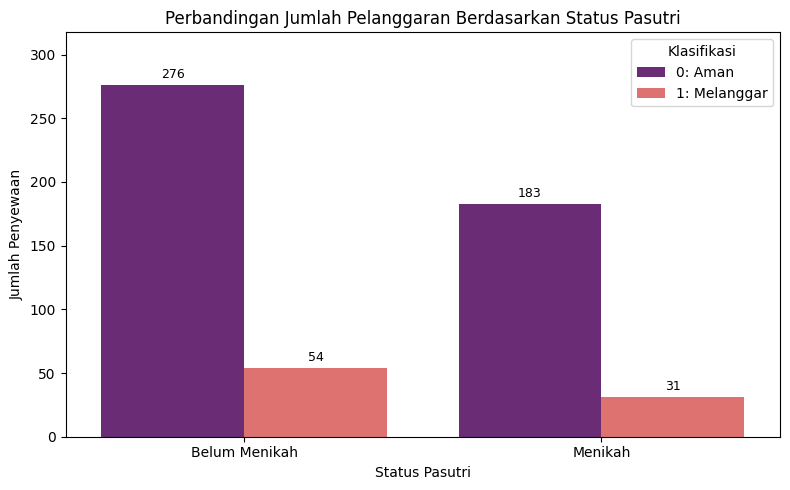

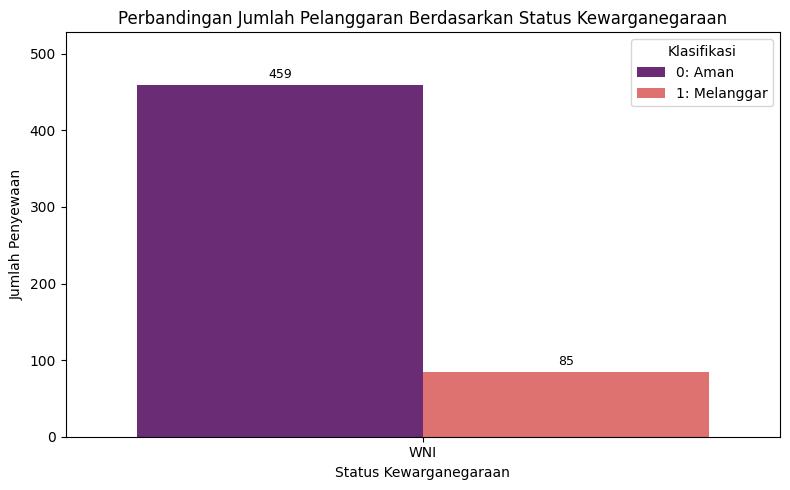

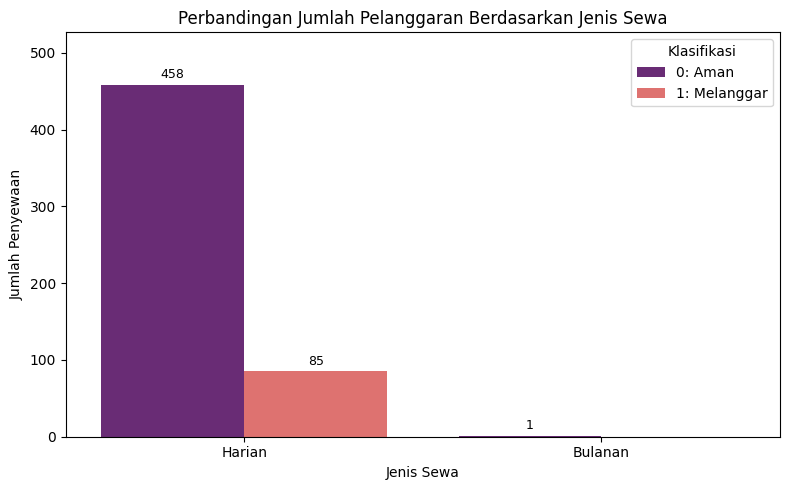

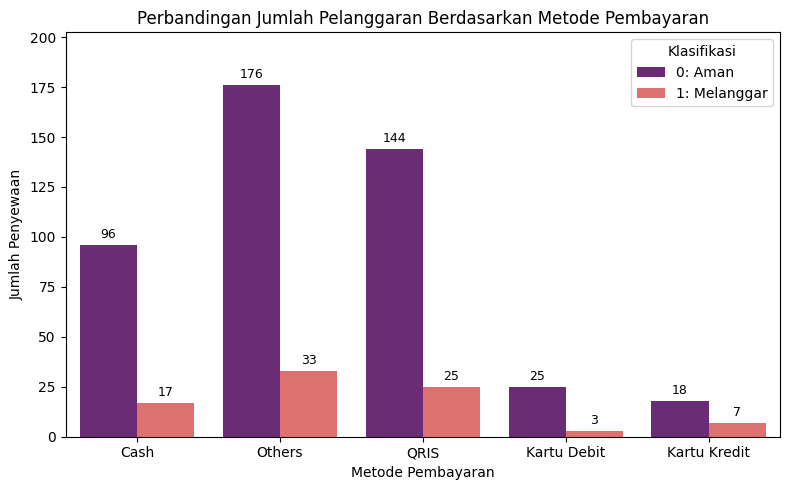


[5b] Visualisasi Metode Pembayaran 'Others' (metode_lain):


/tmp/ipykernel_1991/1767416320.py:205: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


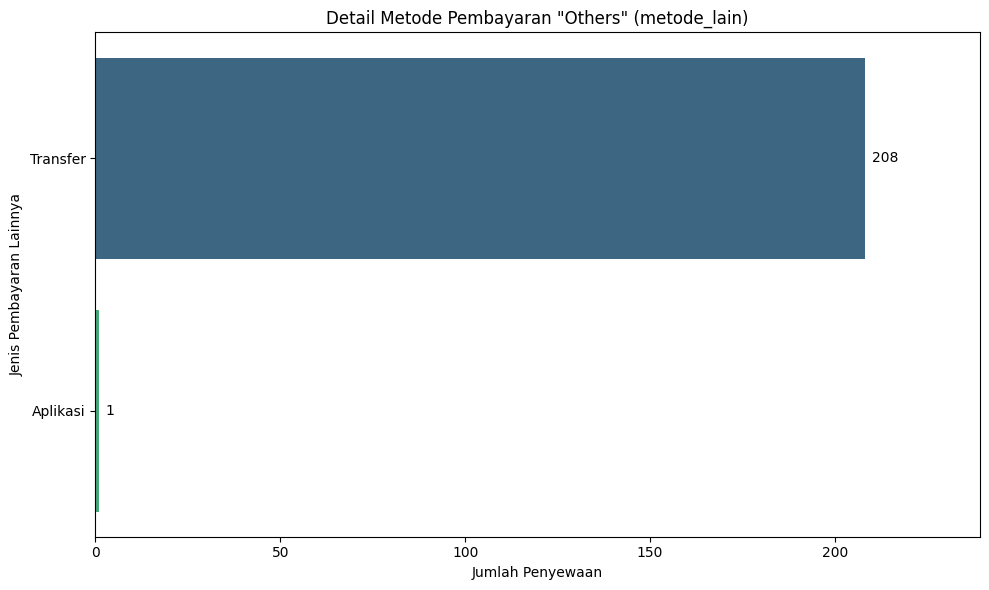

/tmp/ipykernel_1991/1767416320.py:239: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  rentals['waktu_checkout_dt'] = pd.to_datetime(rentals['waktu_checkout'], errors='coerce')
/tmp/ipykernel_1991/1767416320.py:242: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  rentals['waktu_checkin_dt'] = pd.to_datetime(rentals['waktu_checkin'], errors='coerce')



=== Proses Feature Selection ===

-> Fitur yang dipilih (9 terbaik): ['lama_menginap', 'checkin_hour', 'checkout_hour', 'metode_pembayaran', 'status_pasutri', 'jenis_sewa', 'status_kewarganegaraan']

===== Decision Tree =====
Classification Report:
              precision    recall  f1-score   support

           0     1.0000    0.9565    0.9778        92
           1     0.8095    1.0000    0.8947        17

    accuracy                         0.9633       109
   macro avg     0.9048    0.9783    0.9363       109
weighted avg     0.9703    0.9633    0.9648       109

Confusion Matrix (Text):
                Predicted
               0       1
          -----------------
True   0 |     88       4
       1 |      0      17
          -----------------


===== Random Forest =====
Classification Report:
              precision    recall  f1-score   support

           0     1.0000    0.9565    0.9778        92
           1     0.8095    1.0000    0.8947        17

    accuracy            

In [ ]:
# ============================================================
# DATA RIIL (TANPA TUNING) --> jumlah fitur = 9
# ============================================================

import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.pipeline import make_pipeline
from sklearn.feature_selection import SelectKBest, chi2, mutual_info_classif

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier

import matplotlib.pyplot as plt
import seaborn as sns

# ------------------------------------------------------------
# 1. LOAD DATA
# ------------------------------------------------------------
rentals    = pd.read_csv('rentals.csv')
logs       = pd.read_csv('rental_logs.csv')
# units      = pd.read_csv('units.csv')
# users      = pd.read_csv('users.csv')
# violations = pd.read_csv('violations.csv')

rentals.columns = rentals.columns.str.lower()

if 'komentar' not in rentals.columns:
    raise ValueError("Kolom 'komentar' tidak ditemukan di rentals.csv")

print("rentals.csv")
print(rentals.head())
print("logs.csv")
print(logs.head())


# ------------------------------------------------------------
# 2. LABELING
# ------------------------------------------------------------
rentals['komentar'] = rentals['komentar'].astype(str).str.lower().str.strip()
empty_values = ["", "nan", "na", "null", "-", "0", "tidak ada", "none", " "]
rentals['label'] = (~rentals['komentar'].isin(empty_values)).astype(int)


# ============================================================
# EXPLORATORY DATA ANALYSIS (EDA)
# ============================================================
print("\n" + "="*50)
print("=== EXPLORATORY DATA ANALYSIS (EDA) ===")
print("="*50)

df_eda = rentals.copy()

print("\n[1] Statistik Deskriptif:")
print(df_eda.describe(include='all'))

print("\n[2] Distribusi Kelas Target (0: Aman, 1: Melanggar):")
print(df_eda['label'].value_counts())

fig, ax = plt.subplots(figsize=(6, 4))
sns.countplot(data=df_eda, x='label', palette='Set2', ax=ax)
plt.title('Distribusi Kelas Klasifikasi (0: Aman, 1: Melanggar)')
plt.xlabel('Klasifikasi')
plt.ylabel('Jumlah Penyewaan')

y_max = df_eda['label'].value_counts().max()
plt.ylim(0, y_max * 1.15)

for p in ax.patches:
    if p.get_height() > 0:
        ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='baseline', fontsize=10, color='black', xytext=(0, 5),
                    textcoords='offset points')
plt.show()

kolom_dikecualikan = ['id', 'nama', 'nik', 'unit_number', 'tanggal_checkin', 'waktu_checkin',
                      'tanggal_checkout', 'waktu_checkout', 'komentar', 'user_email', 'diedit_oleh', 'created_at', 'metode_lain', 'classification']

semua_kategori = [col for col in df_eda.select_dtypes(include=['object', 'category']).columns if col not in kolom_dikecualikan]

print("\n[3] Rata-rata Pelanggaran Berdasarkan Seluruh Kategori:")
for col in semua_kategori:
    if col in df_eda.columns:
        print(f"\n--- Tingkat Pelanggaran Berdasarkan {col} ---")
        print(df_eda.groupby(col)['label'].mean().sort_values(ascending=False).round(3))

df_eda['lama_menginap_num'] = pd.to_numeric(df_eda['lama_menginap'], errors='coerce').fillna(0)
df_eda['checkin_hour_num'] = pd.to_datetime(df_eda['waktu_checkin'], errors='coerce').dt.hour.fillna(0)
df_eda['checkout_hour_num'] = pd.to_datetime(df_eda['waktu_checkout'], errors='coerce').dt.hour.fillna(0)

le_eda = LabelEncoder()
for c in semua_kategori:
    if c in df_eda.columns:
        df_eda[c + '_encoded'] = le_eda.fit_transform(df_eda[c].astype(str))

print("\n[4] Korelasi Antar Fitur:")
kolom_korelasi = ['lama_menginap_num', 'checkin_hour_num', 'checkout_hour_num', 'label']
kolom_korelasi += [c + '_encoded' for c in semua_kategori if c + '_encoded' in df_eda.columns]

corr_matrix = df_eda[kolom_korelasi].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Heatmap Korelasi Antar Fitur dan Target (Klasifikasi)')
plt.tight_layout()
plt.show()

print("\n[5] Visualisasi Pola Penyewaan (Dikaitkan dengan Klasifikasi):")

custom_line_palette = {0: 'blue', 1: 'red'}
custom_labels = ['0: Aman', '1: Melanggar']

fig, ax1 = plt.subplots(figsize=(12, 5))
waktu_df = df_eda.groupby(['checkin_hour_num', 'label']).size().reset_index(name='jumlah')

sns.lineplot(data=waktu_df, x='checkin_hour_num', y='jumlah', hue='label', marker='o', palette=custom_line_palette, ax=ax1)

plt.title('Pola Waktu Kedatangan Berdasarkan Klasifikasi')
plt.xlabel('Jam Check-in (0-23)')
plt.ylabel('Jumlah Penyewaan')
plt.xticks(range(0, 24))
plt.grid(True, alpha=0.3)

y_max_line = waktu_df['jumlah'].max()
plt.ylim(-y_max_line * 0.20, y_max_line * 1.15)

handles, _ = ax1.get_legend_handles_labels()
plt.legend(handles=handles, labels=custom_labels, title='Klasifikasi')

for l in waktu_df['label'].unique():
    sub = waktu_df[waktu_df['label'] == l]
    warna_teks = custom_line_palette[l]

    for x, y in zip(sub['checkin_hour_num'], sub['jumlah']):
        y_offset = 8 if l == 0 else -12
        va_align = 'bottom' if l == 0 else 'top'
        plt.annotate(f'{int(y)}', (x, y), textcoords="offset points", xytext=(0, y_offset),
                     ha='center', va=va_align, fontsize=9, color=warna_teks, fontweight='bold')
plt.show()

fig, ax2 = plt.subplots(figsize=(12, 5))
lama_df = df_eda.groupby(['lama_menginap_num', 'label']).size().reset_index(name='jumlah')

sns.lineplot(data=lama_df, x='lama_menginap_num', y='jumlah', hue='label', marker='o', palette=custom_line_palette, ax=ax2)

plt.title('Tren Lama Menginap Berdasarkan Klasifikasi')
plt.xlabel('Lama Menginap (Hari)')
plt.ylabel('Jumlah Penyewaan')
plt.grid(True, alpha=0.3)

handles2, _ = ax2.get_legend_handles_labels()
plt.legend(handles=handles2, labels=custom_labels, title='Klasifikasi')
plt.show()

for col in semua_kategori:
    if col in df_eda.columns:
        fig, ax = plt.subplots(figsize=(8, 5))
        sns.countplot(data=df_eda, x=col, hue='label', palette='magma', ax=ax)

        judul_kolom = col.replace('_', ' ').title()
        plt.title(f'Perbandingan Jumlah Pelanggaran Berdasarkan {judul_kolom}')
        plt.xlabel(judul_kolom)
        plt.ylabel('Jumlah Penyewaan')
        plt.xticks(rotation=0)

        handles_bar, _ = ax.get_legend_handles_labels()
        plt.legend(handles=handles_bar, labels=custom_labels, title='Klasifikasi')

        y_max_bar = df_eda.groupby([col, 'label']).size().max()
        plt.ylim(0, y_max_bar * 1.15)

        for p in ax.patches:
            if p.get_height() > 0:
                ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                            ha='center', va='baseline', fontsize=9, color='black', xytext=(0, 5),
                            textcoords='offset points')
        plt.tight_layout()
        plt.show()


print("\n[5b] Visualisasi Metode Pembayaran 'Others' (metode_lain):")

# Memastikan kolom 'metode_lain' berbentuk string dan membersihkan spasi/nilai kosong
df_eda['metode_lain'] = df_eda['metode_lain'].astype(str).str.strip().str.title()
empty_lain = ["", "Nan", "Na", "Null", "-", "0", "None"]

# Filter hanya baris yang memiliki nilai di 'metode_lain'
df_others = df_eda[~df_eda['metode_lain'].isin(empty_lain)]

if not df_others.empty:
    fig, ax = plt.subplots(figsize=(10, 6))

    # Menghitung frekuensi masing-masing metode pembayaran lain
    order_others = df_others['metode_lain'].value_counts().index

    sns.countplot(
        data=df_others,
        y='metode_lain',
        order=order_others,
        palette='viridis',
        ax=ax
    )

    plt.title('Detail Metode Pembayaran "Others" (metode_lain)')
    plt.xlabel('Jumlah Penyewaan')
    plt.ylabel('Jenis Pembayaran Lainnya')

    # Menambahkan anotasi angka di sebelah setiap bar
    for p in ax.patches:
        width = p.get_width()
        if width > 0:
            ax.annotate(f'{int(width)}',
                        (width, p.get_y() + p.get_height() / 2.),
                        ha='left', va='center', fontsize=10, color='black',
                        xytext=(5, 0), textcoords='offset points')

    # Perlebar batas x-axis sedikit agar angka anotasi tidak terpotong
    x_max = df_others['metode_lain'].value_counts().max()
    plt.xlim(0, x_max * 1.15)

    plt.tight_layout()
    plt.show()
else:
    print("Tidak ada data metode pembayaran 'Others' yang valid untuk ditampilkan.")


# ------------------------------------------------------------
# 3. FEATURE ENGINEERING & PREPARATION
# ------------------------------------------------------------
rentals['waktu_checkout_dt'] = pd.to_datetime(rentals['waktu_checkout'], errors='coerce')
rentals['checkout_hour'] = rentals['waktu_checkout_dt'].dt.hour.fillna(0).astype(int)

rentals['waktu_checkin_dt'] = pd.to_datetime(rentals['waktu_checkin'], errors='coerce')
rentals['checkin_hour'] = rentals['waktu_checkin_dt'].dt.hour.fillna(0).astype(int)

rentals['lama_menginap'] = pd.to_numeric(rentals['lama_menginap'], errors='coerce').fillna(0)

cat_cols = ['jenis_sewa', 'metode_pembayaran', 'status_pasutri', 'status_kewarganegaraan']
for c in cat_cols:
    rentals[c] = rentals[c].fillna('Unknown').astype(str)

numeric_cols = ['checkout_hour', 'checkin_hour', 'lama_menginap']
feature_cols = cat_cols + numeric_cols

X = rentals[feature_cols].copy()
y = rentals['label']

# ------------------------------------------------------------
# 4. TRAIN-TEST SPLIT
# ------------------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, stratify=y, test_size=0.2, random_state=42
)

# ------------------------------------------------------------
# 4B. ENCODING MENCEGAH DATA LEAKAGE
# ------------------------------------------------------------
label_encoders = {}

for c in cat_cols:
    le = LabelEncoder()
    X_train[c] = le.fit_transform(X_train[c])

    X_test[c] = X_test[c].map(lambda s: s if s in le.classes_ else 'Unknown')
    if 'Unknown' not in le.classes_:
        le.classes_ = np.append(le.classes_, 'Unknown')

    X_test[c] = le.transform(X_test[c])

    label_encoders[c] = le

# ------------------------------------------------------------
# 5. FEATURE SELECTION
# ------------------------------------------------------------
print("\n=== Proses Feature Selection ===")
chi2_selector = SelectKBest(score_func=chi2, k='all')
chi2_selector.fit(X_train, y_train)

train_df = X_train.copy()
train_df['label'] = y_train
pearson_scores = train_df.corr(method='pearson')['label'].drop('label').abs().values

mi_selector = SelectKBest(score_func=mutual_info_classif, k='all')
mi_selector.fit(X_train, y_train)

fs_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Chi-Square': chi2_selector.scores_,
    'Pearson (Abs)': pearson_scores,
    'Mutual Info': mi_selector.scores_
})

scaler = MinMaxScaler()
fs_df[['Chi2_Norm', 'Pearson_Norm', 'MI_Norm']] = scaler.fit_transform(
    fs_df[['Chi-Square', 'Pearson (Abs)', 'Mutual Info']]
)
fs_df['Total_Score'] = fs_df[['Chi2_Norm', 'Pearson_Norm', 'MI_Norm']].mean(axis=1)
fs_df = fs_df.sort_values(by='Total_Score', ascending=False).reset_index(drop=True)

# Jumlah Fitur
n_select = 9
selected_features = fs_df['Feature'].head(n_select).tolist()
print(f"\n-> Fitur yang dipilih ({n_select} terbaik): {selected_features}")

X_train = X_train[selected_features]
X_test = X_test[selected_features]

# ------------------------------------------------------------
# 6. Fungsi Evaluasi
# ------------------------------------------------------------
def evaluate(name, model):
    y_pred = model.predict(X_test)
    print(f"\n===== {name} =====")
    print("Classification Report:")
    print(classification_report(y_test, y_pred, digits=4))
    cm = confusion_matrix(y_test, y_pred)
    print("Confusion Matrix (Text):")
    print("                Predicted")
    print("               0       1")
    print("          -----------------")
    print(f"True   0 | {cm[0][0]:6d}  {cm[0][1]:6d}")
    print(f"       1 | {cm[1][0]:6d}  {cm[1][1]:6d}")
    print("          -----------------\n")

# ------------------------------------------------------------
# 7. Latih Semua Model (TANPA TUNING)
# ------------------------------------------------------------
models = {}
custom_weight = {0: 1, 1: 4}

# Model menggunakan pengaturan tetap
models["Decision Tree"] = DecisionTreeClassifier(max_depth=6, class_weight=custom_weight, random_state=42)
models["Random Forest"] = RandomForestClassifier(n_estimators=200, max_depth=7, class_weight=custom_weight, random_state=42)
models["KNN"] = make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=5, weights='distance'))
models["SVM RBF"] = make_pipeline(StandardScaler(), SVC(kernel='rbf', probability=True, class_weight=custom_weight, random_state=42))
models["XGBoost"] = XGBClassifier(n_estimators=200, max_depth=5, learning_rate=0.05, scale_pos_weight=4, eval_metric='logloss', random_state=42)

for name, model in models.items():
    model.fit(X_train, y_train)
    evaluate(name, model)

# ------------------------------------------------------------
# 8. Eksport Model Terbaik & Label Encoders
# ------------------------------------------------------------
print("\n=== Proses Export Model ===")

# Gabungkan model dan encoders ke dalam satu dictionary agar rapi
export_package = {
    'model': models["KNN"],
    'label_encoders': label_encoders,
    'selected_features': selected_features # Penting agar tahu urutan kolom masuk saat predict
}

# Menentukan nama file yang sesuai untuk KNN
filename = 'model_knn.pkl'

# Menyimpan package ke dalam file .pkl
joblib.dump(export_package, filename)
print(f"Sukses! Model dan Label Encoders telah disimpan sebagai file: {filename}")

rentals.csv
   id                   nama               nik status_pasutri  \
0   3  Novi Yanti Salsa Dewi  3204065911020004  Belum Menikah   
1   4     Amilia Nur Halimah  3520064903040001  Belum Menikah   
2   5     Achmad Agel Shahab  3525160508900001        Menikah   
3   6            Cries Wandi  1471051210920001  Belum Menikah   
4   7             SELO UTOMO  3171061909880002  Belum Menikah   

  status_kewarganegaraan jenis_sewa unit_number metode_pembayaran metode_lain  \
0                    WNI     Harian     B-20-27              Cash         NaN   
1                    WNI     Harian     A-15-25              Cash         NaN   
2                    WNI     Harian     A-06-24            Others    Aplikasi   
3                    WNI     Harian     D-15-21              QRIS         NaN   
4                    WNI     Harian       A-8-8            Others    Transfer   

  tanggal_checkin waktu_checkin tanggal_checkout waktu_checkout  \
0      2026-05-20      13:08:00       2026-

/tmp/ipykernel_1991/4099437245.py:70: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_eda, x='label', palette='Set2', ax=ax)


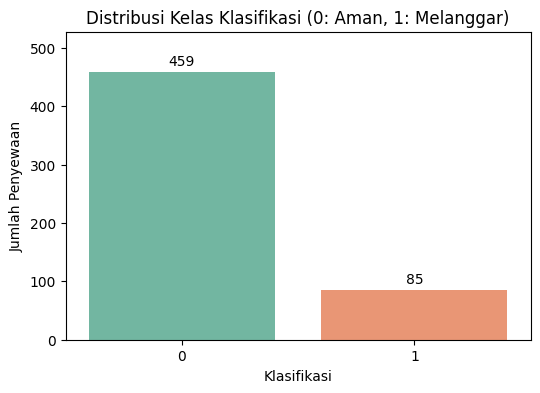


[3] Rata-rata Pelanggaran Berdasarkan Seluruh Kategori:

--- Tingkat Pelanggaran Berdasarkan status_pasutri ---
status_pasutri
Belum Menikah    0.164
Menikah          0.145
Name: label, dtype: float64

--- Tingkat Pelanggaran Berdasarkan status_kewarganegaraan ---
status_kewarganegaraan
WNI    0.156
Name: label, dtype: float64

--- Tingkat Pelanggaran Berdasarkan jenis_sewa ---
jenis_sewa
Harian     0.157
Bulanan    0.000
Name: label, dtype: float64

--- Tingkat Pelanggaran Berdasarkan metode_pembayaran ---
metode_pembayaran
Kartu Kredit    0.280
Others          0.158
Cash            0.150
QRIS            0.148
Kartu Debit     0.107
Name: label, dtype: float64

[4] Korelasi Antar Fitur:


/tmp/ipykernel_1991/4099437245.py:97: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_eda['checkin_hour_num'] = pd.to_datetime(df_eda['waktu_checkin'], errors='coerce').dt.hour.fillna(0)
/tmp/ipykernel_1991/4099437245.py:98: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_eda['checkout_hour_num'] = pd.to_datetime(df_eda['waktu_checkout'], errors='coerce').dt.hour.fillna(0)


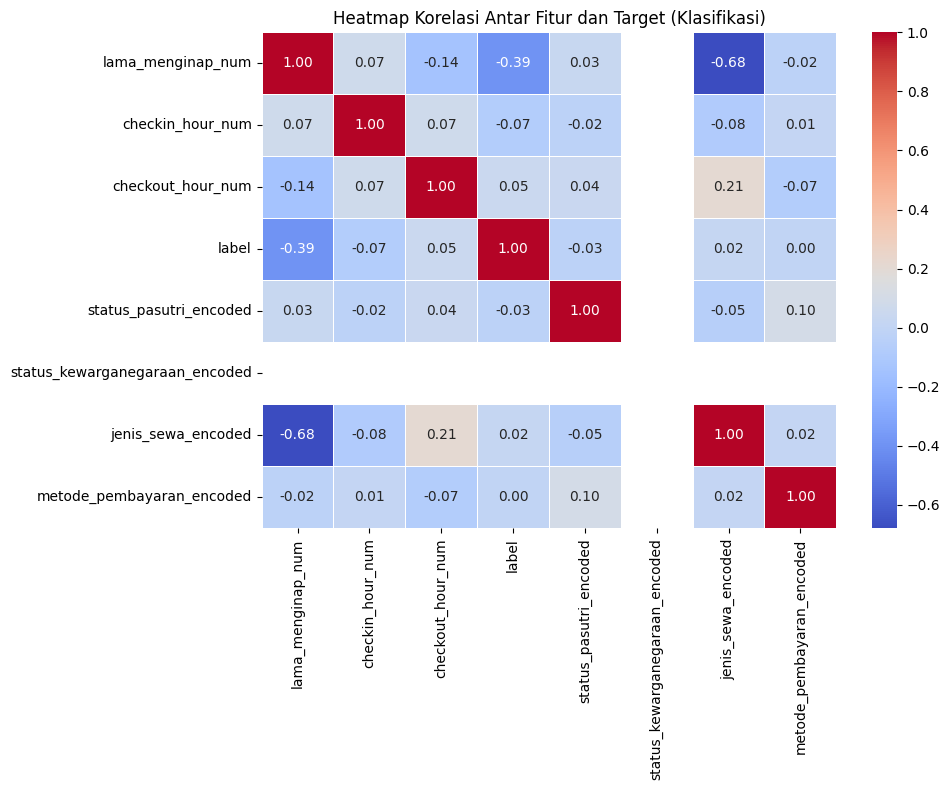


[5] Visualisasi Pola Penyewaan (Dikaitkan dengan Klasifikasi):


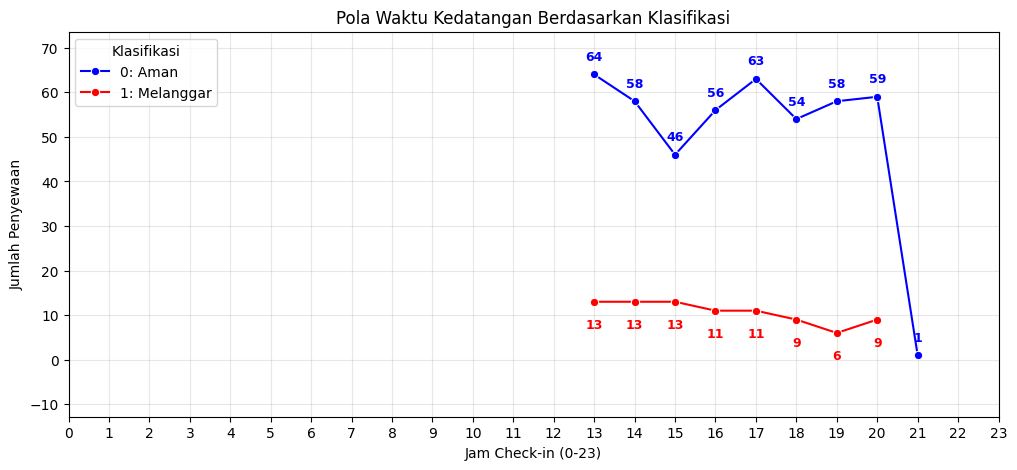

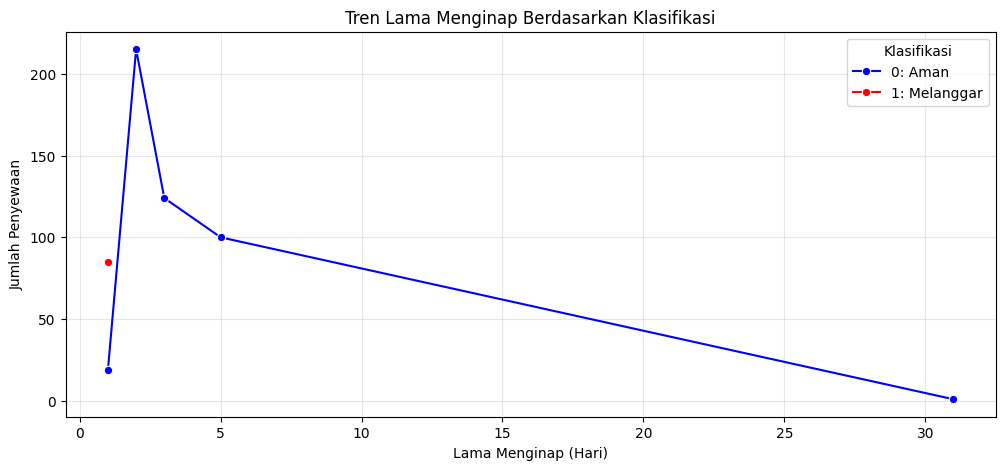

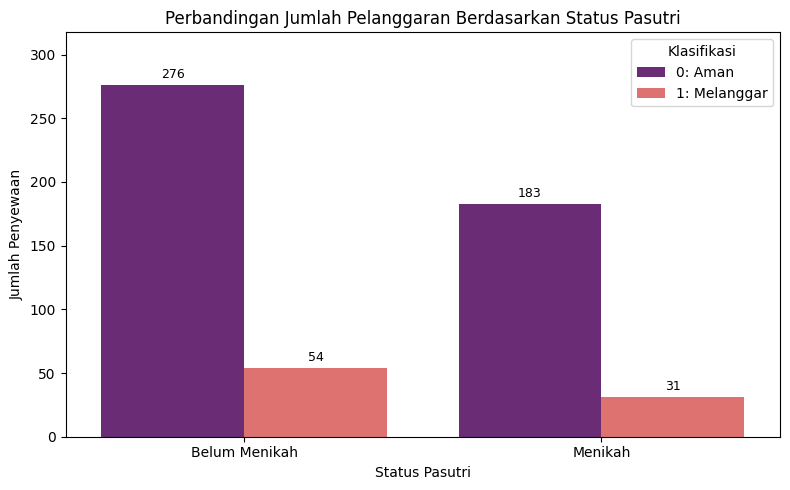

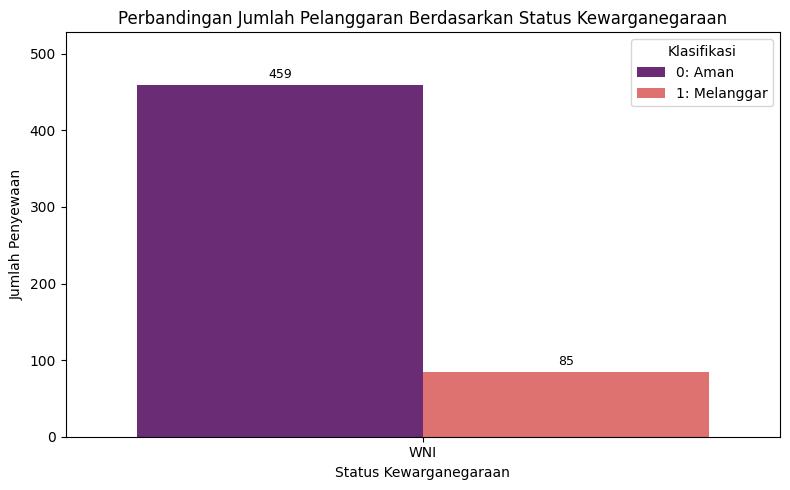

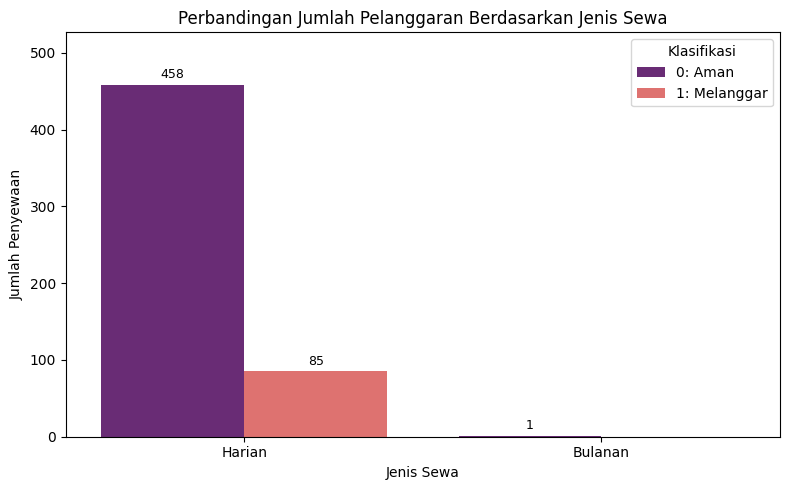

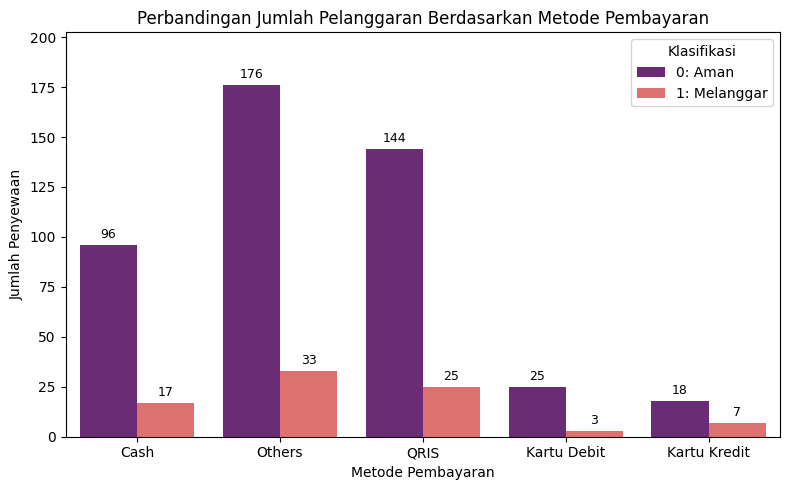


[5b] Visualisasi Metode Pembayaran 'Others' (metode_lain):


/tmp/ipykernel_1991/4099437245.py:205: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


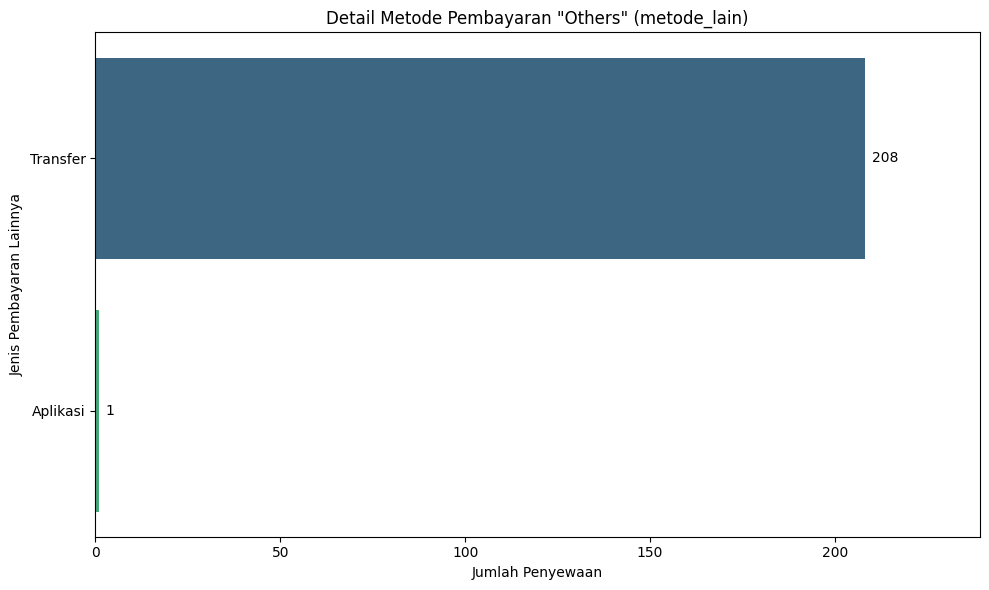

/tmp/ipykernel_1991/4099437245.py:239: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  rentals['waktu_checkout_dt'] = pd.to_datetime(rentals['waktu_checkout'], errors='coerce')
/tmp/ipykernel_1991/4099437245.py:242: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  rentals['waktu_checkin_dt'] = pd.to_datetime(rentals['waktu_checkin'], errors='coerce')



=== Proses Feature Selection ===

-> Fitur yang dipilih (8 terbaik): ['lama_menginap', 'checkout_hour', 'checkin_hour', 'metode_pembayaran', 'status_kewarganegaraan', 'status_pasutri', 'jenis_sewa']

===== Decision Tree =====
Classification Report:
              precision    recall  f1-score   support

           0     1.0000    0.9565    0.9778        92
           1     0.8095    1.0000    0.8947        17

    accuracy                         0.9633       109
   macro avg     0.9048    0.9783    0.9363       109
weighted avg     0.9703    0.9633    0.9648       109

Confusion Matrix (Text):
                Predicted
               0       1
          -----------------
True   0 |     88       4
       1 |      0      17
          -----------------


===== Random Forest =====
Classification Report:
              precision    recall  f1-score   support

           0     1.0000    0.9565    0.9778        92
           1     0.8095    1.0000    0.8947        17

    accuracy            

In [ ]:
# ============================================================
# DATA RIIL (TANPA TUNING) --> jumlah fitur = 8
# ============================================================

import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.pipeline import make_pipeline
from sklearn.feature_selection import SelectKBest, chi2, mutual_info_classif

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier

import matplotlib.pyplot as plt
import seaborn as sns

# ------------------------------------------------------------
# 1. LOAD DATA
# ------------------------------------------------------------
rentals    = pd.read_csv('rentals.csv')
logs       = pd.read_csv('rental_logs.csv')
# units      = pd.read_csv('units.csv')
# users      = pd.read_csv('users.csv')
# violations = pd.read_csv('violations.csv')

rentals.columns = rentals.columns.str.lower()

if 'komentar' not in rentals.columns:
    raise ValueError("Kolom 'komentar' tidak ditemukan di rentals.csv")

print("rentals.csv")
print(rentals.head())
print("logs.csv")
print(logs.head())


# ------------------------------------------------------------
# 2. LABELING
# ------------------------------------------------------------
rentals['komentar'] = rentals['komentar'].astype(str).str.lower().str.strip()
empty_values = ["", "nan", "na", "null", "-", "0", "tidak ada", "none", " "]
rentals['label'] = (~rentals['komentar'].isin(empty_values)).astype(int)


# ============================================================
# EXPLORATORY DATA ANALYSIS (EDA)
# ============================================================
print("\n" + "="*50)
print("=== EXPLORATORY DATA ANALYSIS (EDA) ===")
print("="*50)

df_eda = rentals.copy()

print("\n[1] Statistik Deskriptif:")
print(df_eda.describe(include='all'))

print("\n[2] Distribusi Kelas Target (0: Aman, 1: Melanggar):")
print(df_eda['label'].value_counts())

fig, ax = plt.subplots(figsize=(6, 4))
sns.countplot(data=df_eda, x='label', palette='Set2', ax=ax)
plt.title('Distribusi Kelas Klasifikasi (0: Aman, 1: Melanggar)')
plt.xlabel('Klasifikasi')
plt.ylabel('Jumlah Penyewaan')

y_max = df_eda['label'].value_counts().max()
plt.ylim(0, y_max * 1.15)

for p in ax.patches:
    if p.get_height() > 0:
        ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='baseline', fontsize=10, color='black', xytext=(0, 5),
                    textcoords='offset points')
plt.show()

kolom_dikecualikan = ['id', 'nama', 'nik', 'unit_number', 'tanggal_checkin', 'waktu_checkin',
                      'tanggal_checkout', 'waktu_checkout', 'komentar', 'user_email', 'diedit_oleh', 'created_at', 'metode_lain', 'classification']

semua_kategori = [col for col in df_eda.select_dtypes(include=['object', 'category']).columns if col not in kolom_dikecualikan]

print("\n[3] Rata-rata Pelanggaran Berdasarkan Seluruh Kategori:")
for col in semua_kategori:
    if col in df_eda.columns:
        print(f"\n--- Tingkat Pelanggaran Berdasarkan {col} ---")
        print(df_eda.groupby(col)['label'].mean().sort_values(ascending=False).round(3))

df_eda['lama_menginap_num'] = pd.to_numeric(df_eda['lama_menginap'], errors='coerce').fillna(0)
df_eda['checkin_hour_num'] = pd.to_datetime(df_eda['waktu_checkin'], errors='coerce').dt.hour.fillna(0)
df_eda['checkout_hour_num'] = pd.to_datetime(df_eda['waktu_checkout'], errors='coerce').dt.hour.fillna(0)

le_eda = LabelEncoder()
for c in semua_kategori:
    if c in df_eda.columns:
        df_eda[c + '_encoded'] = le_eda.fit_transform(df_eda[c].astype(str))

print("\n[4] Korelasi Antar Fitur:")
kolom_korelasi = ['lama_menginap_num', 'checkin_hour_num', 'checkout_hour_num', 'label']
kolom_korelasi += [c + '_encoded' for c in semua_kategori if c + '_encoded' in df_eda.columns]

corr_matrix = df_eda[kolom_korelasi].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Heatmap Korelasi Antar Fitur dan Target (Klasifikasi)')
plt.tight_layout()
plt.show()

print("\n[5] Visualisasi Pola Penyewaan (Dikaitkan dengan Klasifikasi):")

custom_line_palette = {0: 'blue', 1: 'red'}
custom_labels = ['0: Aman', '1: Melanggar']

fig, ax1 = plt.subplots(figsize=(12, 5))
waktu_df = df_eda.groupby(['checkin_hour_num', 'label']).size().reset_index(name='jumlah')

sns.lineplot(data=waktu_df, x='checkin_hour_num', y='jumlah', hue='label', marker='o', palette=custom_line_palette, ax=ax1)

plt.title('Pola Waktu Kedatangan Berdasarkan Klasifikasi')
plt.xlabel('Jam Check-in (0-23)')
plt.ylabel('Jumlah Penyewaan')
plt.xticks(range(0, 24))
plt.grid(True, alpha=0.3)

y_max_line = waktu_df['jumlah'].max()
plt.ylim(-y_max_line * 0.20, y_max_line * 1.15)

handles, _ = ax1.get_legend_handles_labels()
plt.legend(handles=handles, labels=custom_labels, title='Klasifikasi')

for l in waktu_df['label'].unique():
    sub = waktu_df[waktu_df['label'] == l]
    warna_teks = custom_line_palette[l]

    for x, y in zip(sub['checkin_hour_num'], sub['jumlah']):
        y_offset = 8 if l == 0 else -12
        va_align = 'bottom' if l == 0 else 'top'
        plt.annotate(f'{int(y)}', (x, y), textcoords="offset points", xytext=(0, y_offset),
                     ha='center', va=va_align, fontsize=9, color=warna_teks, fontweight='bold')
plt.show()

fig, ax2 = plt.subplots(figsize=(12, 5))
lama_df = df_eda.groupby(['lama_menginap_num', 'label']).size().reset_index(name='jumlah')

sns.lineplot(data=lama_df, x='lama_menginap_num', y='jumlah', hue='label', marker='o', palette=custom_line_palette, ax=ax2)

plt.title('Tren Lama Menginap Berdasarkan Klasifikasi')
plt.xlabel('Lama Menginap (Hari)')
plt.ylabel('Jumlah Penyewaan')
plt.grid(True, alpha=0.3)

handles2, _ = ax2.get_legend_handles_labels()
plt.legend(handles=handles2, labels=custom_labels, title='Klasifikasi')
plt.show()

for col in semua_kategori:
    if col in df_eda.columns:
        fig, ax = plt.subplots(figsize=(8, 5))
        sns.countplot(data=df_eda, x=col, hue='label', palette='magma', ax=ax)

        judul_kolom = col.replace('_', ' ').title()
        plt.title(f'Perbandingan Jumlah Pelanggaran Berdasarkan {judul_kolom}')
        plt.xlabel(judul_kolom)
        plt.ylabel('Jumlah Penyewaan')
        plt.xticks(rotation=0)

        handles_bar, _ = ax.get_legend_handles_labels()
        plt.legend(handles=handles_bar, labels=custom_labels, title='Klasifikasi')

        y_max_bar = df_eda.groupby([col, 'label']).size().max()
        plt.ylim(0, y_max_bar * 1.15)

        for p in ax.patches:
            if p.get_height() > 0:
                ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                            ha='center', va='baseline', fontsize=9, color='black', xytext=(0, 5),
                            textcoords='offset points')
        plt.tight_layout()
        plt.show()


print("\n[5b] Visualisasi Metode Pembayaran 'Others' (metode_lain):")

# Memastikan kolom 'metode_lain' berbentuk string dan membersihkan spasi/nilai kosong
df_eda['metode_lain'] = df_eda['metode_lain'].astype(str).str.strip().str.title()
empty_lain = ["", "Nan", "Na", "Null", "-", "0", "None"]

# Filter hanya baris yang memiliki nilai di 'metode_lain'
df_others = df_eda[~df_eda['metode_lain'].isin(empty_lain)]

if not df_others.empty:
    fig, ax = plt.subplots(figsize=(10, 6))

    # Menghitung frekuensi masing-masing metode pembayaran lain
    order_others = df_others['metode_lain'].value_counts().index

    sns.countplot(
        data=df_others,
        y='metode_lain',
        order=order_others,
        palette='viridis',
        ax=ax
    )

    plt.title('Detail Metode Pembayaran "Others" (metode_lain)')
    plt.xlabel('Jumlah Penyewaan')
    plt.ylabel('Jenis Pembayaran Lainnya')

    # Menambahkan anotasi angka di sebelah setiap bar
    for p in ax.patches:
        width = p.get_width()
        if width > 0:
            ax.annotate(f'{int(width)}',
                        (width, p.get_y() + p.get_height() / 2.),
                        ha='left', va='center', fontsize=10, color='black',
                        xytext=(5, 0), textcoords='offset points')

    # Perlebar batas x-axis sedikit agar angka anotasi tidak terpotong
    x_max = df_others['metode_lain'].value_counts().max()
    plt.xlim(0, x_max * 1.15)

    plt.tight_layout()
    plt.show()
else:
    print("Tidak ada data metode pembayaran 'Others' yang valid untuk ditampilkan.")


# ------------------------------------------------------------
# 3. FEATURE ENGINEERING & PREPARATION
# ------------------------------------------------------------
rentals['waktu_checkout_dt'] = pd.to_datetime(rentals['waktu_checkout'], errors='coerce')
rentals['checkout_hour'] = rentals['waktu_checkout_dt'].dt.hour.fillna(0).astype(int)

rentals['waktu_checkin_dt'] = pd.to_datetime(rentals['waktu_checkin'], errors='coerce')
rentals['checkin_hour'] = rentals['waktu_checkin_dt'].dt.hour.fillna(0).astype(int)

rentals['lama_menginap'] = pd.to_numeric(rentals['lama_menginap'], errors='coerce').fillna(0)

cat_cols = ['jenis_sewa', 'metode_pembayaran', 'status_pasutri', 'status_kewarganegaraan']
for c in cat_cols:
    rentals[c] = rentals[c].fillna('Unknown').astype(str)

numeric_cols = ['checkout_hour', 'checkin_hour', 'lama_menginap']
feature_cols = cat_cols + numeric_cols

X = rentals[feature_cols].copy()
y = rentals['label']

# ------------------------------------------------------------
# 4. TRAIN-TEST SPLIT
# ------------------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, stratify=y, test_size=0.2, random_state=42
)

# ------------------------------------------------------------
# 4B. ENCODING MENCEGAH DATA LEAKAGE
# ------------------------------------------------------------
label_encoders = {}

for c in cat_cols:
    le = LabelEncoder()
    X_train[c] = le.fit_transform(X_train[c])

    X_test[c] = X_test[c].map(lambda s: s if s in le.classes_ else 'Unknown')
    if 'Unknown' not in le.classes_:
        le.classes_ = np.append(le.classes_, 'Unknown')

    X_test[c] = le.transform(X_test[c])

    label_encoders[c] = le

# ------------------------------------------------------------
# 5. FEATURE SELECTION
# ------------------------------------------------------------
print("\n=== Proses Feature Selection ===")
chi2_selector = SelectKBest(score_func=chi2, k='all')
chi2_selector.fit(X_train, y_train)

train_df = X_train.copy()
train_df['label'] = y_train
pearson_scores = train_df.corr(method='pearson')['label'].drop('label').abs().values

mi_selector = SelectKBest(score_func=mutual_info_classif, k='all')
mi_selector.fit(X_train, y_train)

fs_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Chi-Square': chi2_selector.scores_,
    'Pearson (Abs)': pearson_scores,
    'Mutual Info': mi_selector.scores_
})

scaler = MinMaxScaler()
fs_df[['Chi2_Norm', 'Pearson_Norm', 'MI_Norm']] = scaler.fit_transform(
    fs_df[['Chi-Square', 'Pearson (Abs)', 'Mutual Info']]
)
fs_df['Total_Score'] = fs_df[['Chi2_Norm', 'Pearson_Norm', 'MI_Norm']].mean(axis=1)
fs_df = fs_df.sort_values(by='Total_Score', ascending=False).reset_index(drop=True)

# Jumlah Fitur
n_select = 8
selected_features = fs_df['Feature'].head(n_select).tolist()
print(f"\n-> Fitur yang dipilih ({n_select} terbaik): {selected_features}")

X_train = X_train[selected_features]
X_test = X_test[selected_features]

# ------------------------------------------------------------
# 6. Fungsi Evaluasi
# ------------------------------------------------------------
def evaluate(name, model):
    y_pred = model.predict(X_test)
    print(f"\n===== {name} =====")
    print("Classification Report:")
    print(classification_report(y_test, y_pred, digits=4))
    cm = confusion_matrix(y_test, y_pred)
    print("Confusion Matrix (Text):")
    print("                Predicted")
    print("               0       1")
    print("          -----------------")
    print(f"True   0 | {cm[0][0]:6d}  {cm[0][1]:6d}")
    print(f"       1 | {cm[1][0]:6d}  {cm[1][1]:6d}")
    print("          -----------------\n")

# ------------------------------------------------------------
# 7. Latih Semua Model (TANPA TUNING)
# ------------------------------------------------------------
models = {}
custom_weight = {0: 1, 1: 4}

# Model menggunakan pengaturan tetap
models["Decision Tree"] = DecisionTreeClassifier(max_depth=6, class_weight=custom_weight, random_state=42)
models["Random Forest"] = RandomForestClassifier(n_estimators=200, max_depth=7, class_weight=custom_weight, random_state=42)
models["KNN"] = make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=5, weights='distance'))
models["SVM RBF"] = make_pipeline(StandardScaler(), SVC(kernel='rbf', probability=True, class_weight=custom_weight, random_state=42))
models["XGBoost"] = XGBClassifier(n_estimators=200, max_depth=5, learning_rate=0.05, scale_pos_weight=4, eval_metric='logloss', random_state=42)

for name, model in models.items():
    model.fit(X_train, y_train)
    evaluate(name, model)

# ------------------------------------------------------------
# 8. Eksport Model Terbaik & Label Encoders
# ------------------------------------------------------------
print("\n=== Proses Export Model ===")

# Gabungkan model dan encoders ke dalam satu dictionary agar rapi
export_package = {
    'model': models["KNN"],
    'label_encoders': label_encoders,
    'selected_features': selected_features # Penting agar tahu urutan kolom masuk saat predict
}

# Menentukan nama file yang sesuai untuk KNN
filename = 'model_knn.pkl'

# Menyimpan package ke dalam file .pkl
joblib.dump(export_package, filename)
print(f"Sukses! Model dan Label Encoders telah disimpan sebagai file: {filename}")

rentals.csv
   id                   nama               nik status_pasutri  \
0   3  Novi Yanti Salsa Dewi  3204065911020004  Belum Menikah   
1   4     Amilia Nur Halimah  3520064903040001  Belum Menikah   
2   5     Achmad Agel Shahab  3525160508900001        Menikah   
3   6            Cries Wandi  1471051210920001  Belum Menikah   
4   7             SELO UTOMO  3171061909880002  Belum Menikah   

  status_kewarganegaraan jenis_sewa unit_number metode_pembayaran metode_lain  \
0                    WNI     Harian     B-20-27              Cash         NaN   
1                    WNI     Harian     A-15-25              Cash         NaN   
2                    WNI     Harian     A-06-24            Others    Aplikasi   
3                    WNI     Harian     D-15-21              QRIS         NaN   
4                    WNI     Harian       A-8-8            Others    Transfer   

  tanggal_checkin waktu_checkin tanggal_checkout waktu_checkout  \
0      2026-05-20      13:08:00       2026-

/tmp/ipykernel_1991/3071461186.py:70: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_eda, x='label', palette='Set2', ax=ax)


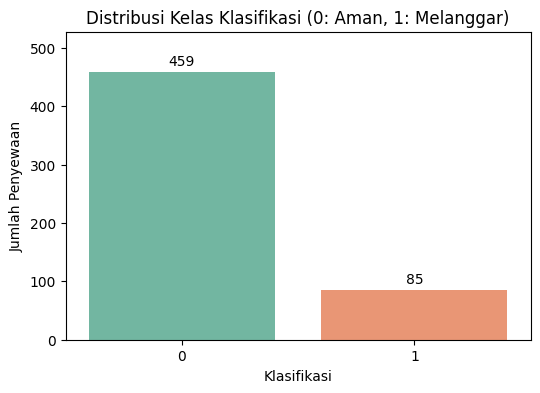


[3] Rata-rata Pelanggaran Berdasarkan Seluruh Kategori:

--- Tingkat Pelanggaran Berdasarkan status_pasutri ---
status_pasutri
Belum Menikah    0.164
Menikah          0.145
Name: label, dtype: float64

--- Tingkat Pelanggaran Berdasarkan status_kewarganegaraan ---
status_kewarganegaraan
WNI    0.156
Name: label, dtype: float64

--- Tingkat Pelanggaran Berdasarkan jenis_sewa ---
jenis_sewa
Harian     0.157
Bulanan    0.000
Name: label, dtype: float64

--- Tingkat Pelanggaran Berdasarkan metode_pembayaran ---
metode_pembayaran
Kartu Kredit    0.280
Others          0.158
Cash            0.150
QRIS            0.148
Kartu Debit     0.107
Name: label, dtype: float64


/tmp/ipykernel_1991/3071461186.py:97: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_eda['checkin_hour_num'] = pd.to_datetime(df_eda['waktu_checkin'], errors='coerce').dt.hour.fillna(0)
/tmp/ipykernel_1991/3071461186.py:98: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_eda['checkout_hour_num'] = pd.to_datetime(df_eda['waktu_checkout'], errors='coerce').dt.hour.fillna(0)



[4] Korelasi Antar Fitur:


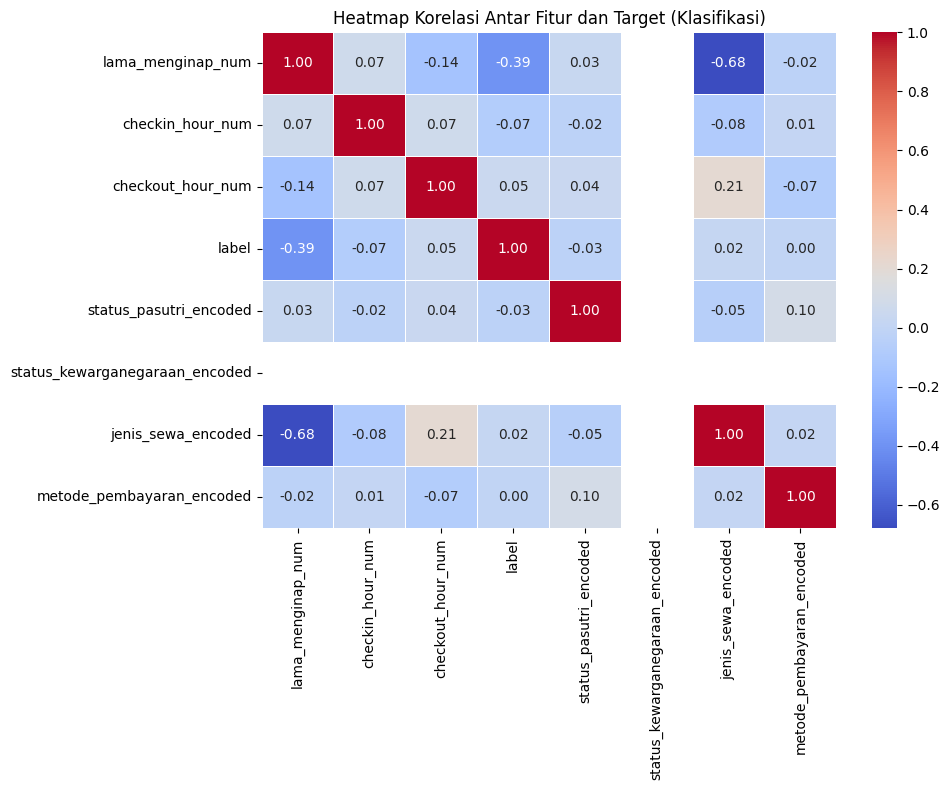


[5] Visualisasi Pola Penyewaan (Dikaitkan dengan Klasifikasi):


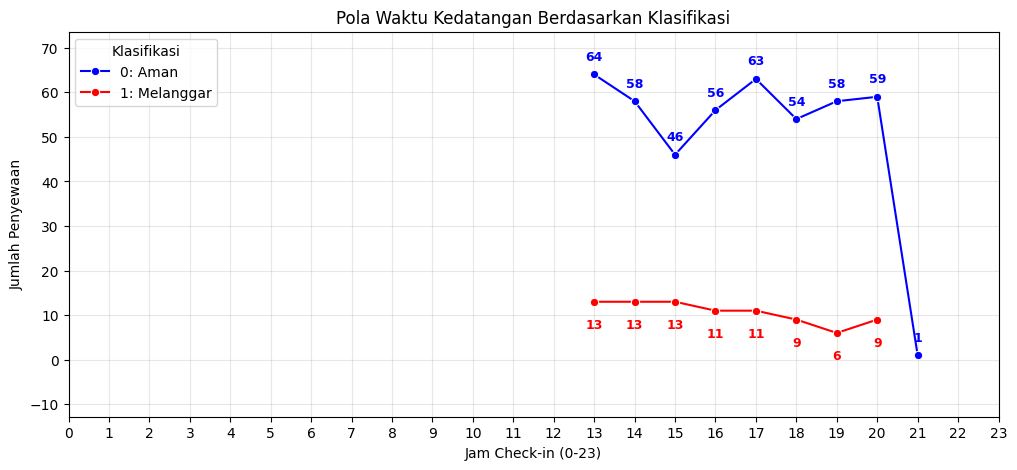

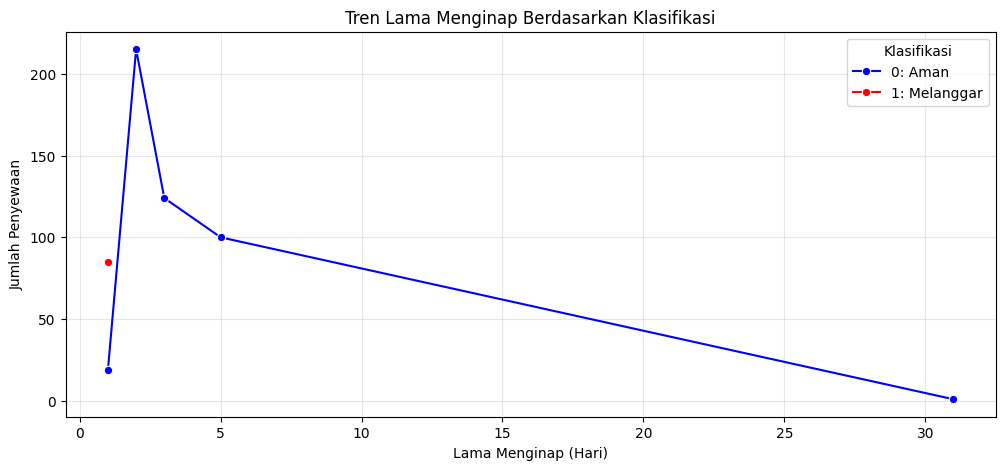

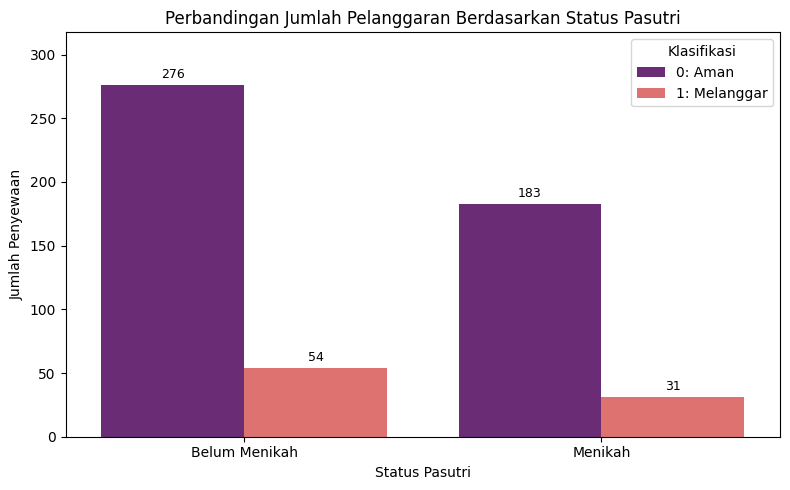

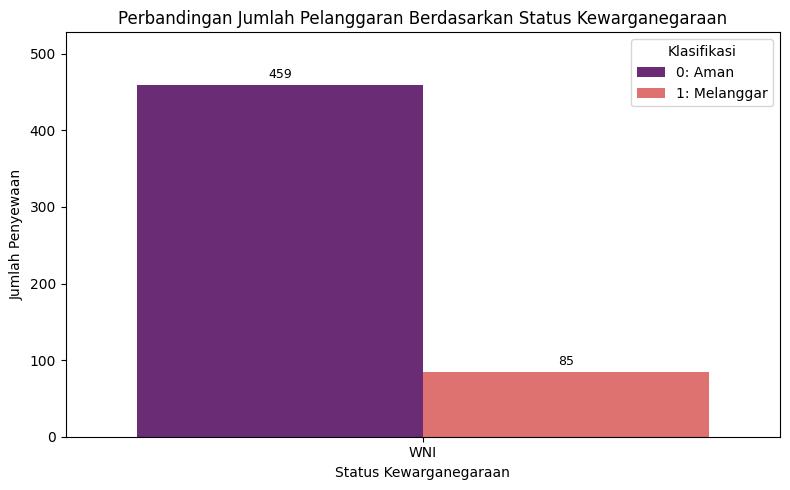

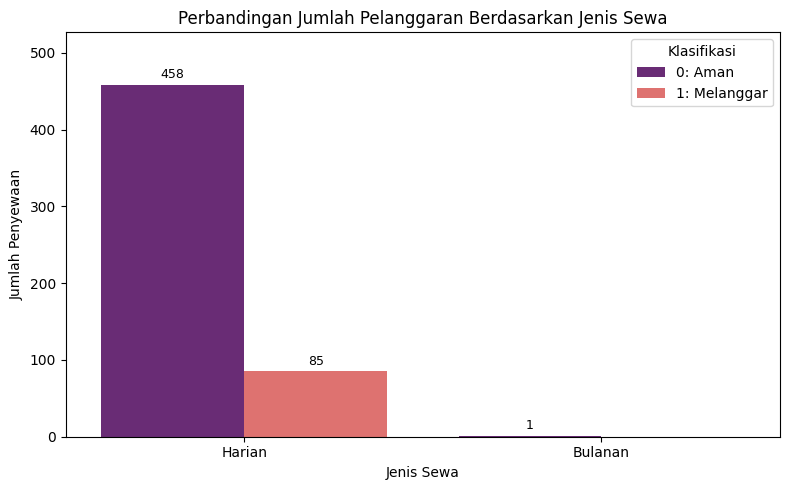

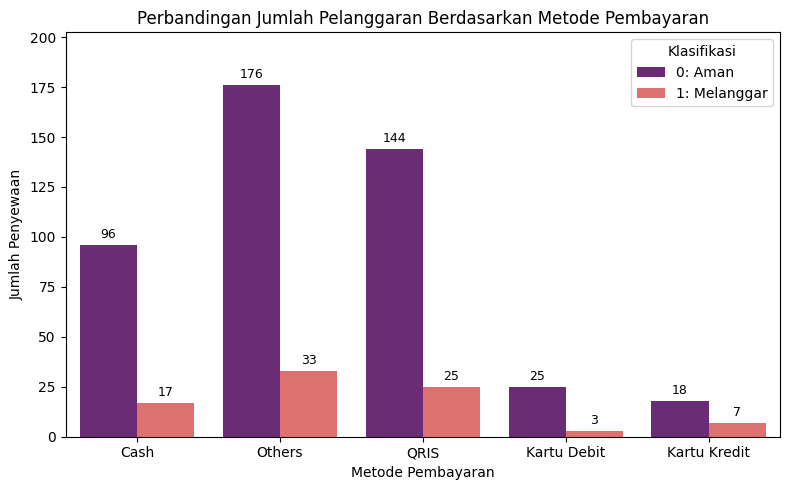


[5b] Visualisasi Metode Pembayaran 'Others' (metode_lain):


/tmp/ipykernel_1991/3071461186.py:205: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


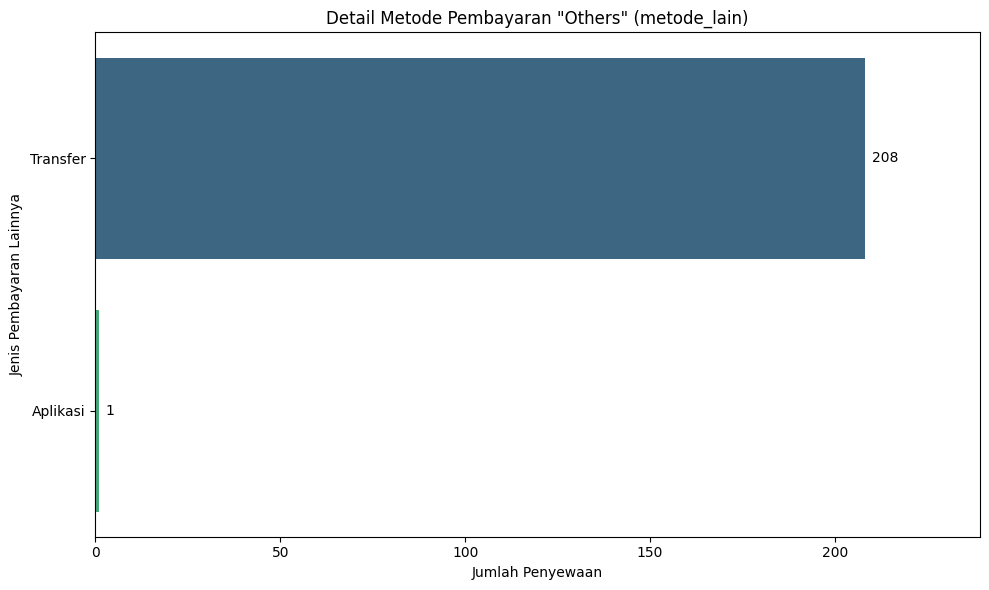

/tmp/ipykernel_1991/3071461186.py:239: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  rentals['waktu_checkout_dt'] = pd.to_datetime(rentals['waktu_checkout'], errors='coerce')
/tmp/ipykernel_1991/3071461186.py:242: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  rentals['waktu_checkin_dt'] = pd.to_datetime(rentals['waktu_checkin'], errors='coerce')



=== Proses Feature Selection ===

-> Fitur yang dipilih (7 terbaik): ['lama_menginap', 'checkout_hour', 'checkin_hour', 'status_kewarganegaraan', 'metode_pembayaran', 'status_pasutri', 'jenis_sewa']

===== Decision Tree =====
Classification Report:
              precision    recall  f1-score   support

           0     1.0000    0.9565    0.9778        92
           1     0.8095    1.0000    0.8947        17

    accuracy                         0.9633       109
   macro avg     0.9048    0.9783    0.9363       109
weighted avg     0.9703    0.9633    0.9648       109

Confusion Matrix (Text):
                Predicted
               0       1
          -----------------
True   0 |     88       4
       1 |      0      17
          -----------------


===== Random Forest =====
Classification Report:
              precision    recall  f1-score   support

           0     1.0000    0.9565    0.9778        92
           1     0.8095    1.0000    0.8947        17

    accuracy            

In [ ]:
# ============================================================
# DATA RIIL (TANPA TUNING) --> jumlah fitur = 7
# ============================================================

import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.pipeline import make_pipeline
from sklearn.feature_selection import SelectKBest, chi2, mutual_info_classif

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier

import matplotlib.pyplot as plt
import seaborn as sns

# ------------------------------------------------------------
# 1. LOAD DATA
# ------------------------------------------------------------
rentals    = pd.read_csv('rentals.csv')
logs       = pd.read_csv('rental_logs.csv')
# units      = pd.read_csv('units.csv')
# users      = pd.read_csv('users.csv')
# violations = pd.read_csv('violations.csv')

rentals.columns = rentals.columns.str.lower()

if 'komentar' not in rentals.columns:
    raise ValueError("Kolom 'komentar' tidak ditemukan di rentals.csv")

print("rentals.csv")
print(rentals.head())
print("logs.csv")
print(logs.head())


# ------------------------------------------------------------
# 2. LABELING
# ------------------------------------------------------------
rentals['komentar'] = rentals['komentar'].astype(str).str.lower().str.strip()
empty_values = ["", "nan", "na", "null", "-", "0", "tidak ada", "none", " "]
rentals['label'] = (~rentals['komentar'].isin(empty_values)).astype(int)


# ============================================================
# EXPLORATORY DATA ANALYSIS (EDA)
# ============================================================
print("\n" + "="*50)
print("=== EXPLORATORY DATA ANALYSIS (EDA) ===")
print("="*50)

df_eda = rentals.copy()

print("\n[1] Statistik Deskriptif:")
print(df_eda.describe(include='all'))

print("\n[2] Distribusi Kelas Target (0: Aman, 1: Melanggar):")
print(df_eda['label'].value_counts())

fig, ax = plt.subplots(figsize=(6, 4))
sns.countplot(data=df_eda, x='label', palette='Set2', ax=ax)
plt.title('Distribusi Kelas Klasifikasi (0: Aman, 1: Melanggar)')
plt.xlabel('Klasifikasi')
plt.ylabel('Jumlah Penyewaan')

y_max = df_eda['label'].value_counts().max()
plt.ylim(0, y_max * 1.15)

for p in ax.patches:
    if p.get_height() > 0:
        ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='baseline', fontsize=10, color='black', xytext=(0, 5),
                    textcoords='offset points')
plt.show()

kolom_dikecualikan = ['id', 'nama', 'nik', 'unit_number', 'tanggal_checkin', 'waktu_checkin',
                      'tanggal_checkout', 'waktu_checkout', 'komentar', 'user_email', 'diedit_oleh', 'created_at', 'metode_lain', 'classification']

semua_kategori = [col for col in df_eda.select_dtypes(include=['object', 'category']).columns if col not in kolom_dikecualikan]

print("\n[3] Rata-rata Pelanggaran Berdasarkan Seluruh Kategori:")
for col in semua_kategori:
    if col in df_eda.columns:
        print(f"\n--- Tingkat Pelanggaran Berdasarkan {col} ---")
        print(df_eda.groupby(col)['label'].mean().sort_values(ascending=False).round(3))

df_eda['lama_menginap_num'] = pd.to_numeric(df_eda['lama_menginap'], errors='coerce').fillna(0)
df_eda['checkin_hour_num'] = pd.to_datetime(df_eda['waktu_checkin'], errors='coerce').dt.hour.fillna(0)
df_eda['checkout_hour_num'] = pd.to_datetime(df_eda['waktu_checkout'], errors='coerce').dt.hour.fillna(0)

le_eda = LabelEncoder()
for c in semua_kategori:
    if c in df_eda.columns:
        df_eda[c + '_encoded'] = le_eda.fit_transform(df_eda[c].astype(str))

print("\n[4] Korelasi Antar Fitur:")
kolom_korelasi = ['lama_menginap_num', 'checkin_hour_num', 'checkout_hour_num', 'label']
kolom_korelasi += [c + '_encoded' for c in semua_kategori if c + '_encoded' in df_eda.columns]

corr_matrix = df_eda[kolom_korelasi].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Heatmap Korelasi Antar Fitur dan Target (Klasifikasi)')
plt.tight_layout()
plt.show()

print("\n[5] Visualisasi Pola Penyewaan (Dikaitkan dengan Klasifikasi):")

custom_line_palette = {0: 'blue', 1: 'red'}
custom_labels = ['0: Aman', '1: Melanggar']

fig, ax1 = plt.subplots(figsize=(12, 5))
waktu_df = df_eda.groupby(['checkin_hour_num', 'label']).size().reset_index(name='jumlah')

sns.lineplot(data=waktu_df, x='checkin_hour_num', y='jumlah', hue='label', marker='o', palette=custom_line_palette, ax=ax1)

plt.title('Pola Waktu Kedatangan Berdasarkan Klasifikasi')
plt.xlabel('Jam Check-in (0-23)')
plt.ylabel('Jumlah Penyewaan')
plt.xticks(range(0, 24))
plt.grid(True, alpha=0.3)

y_max_line = waktu_df['jumlah'].max()
plt.ylim(-y_max_line * 0.20, y_max_line * 1.15)

handles, _ = ax1.get_legend_handles_labels()
plt.legend(handles=handles, labels=custom_labels, title='Klasifikasi')

for l in waktu_df['label'].unique():
    sub = waktu_df[waktu_df['label'] == l]
    warna_teks = custom_line_palette[l]

    for x, y in zip(sub['checkin_hour_num'], sub['jumlah']):
        y_offset = 8 if l == 0 else -12
        va_align = 'bottom' if l == 0 else 'top'
        plt.annotate(f'{int(y)}', (x, y), textcoords="offset points", xytext=(0, y_offset),
                     ha='center', va=va_align, fontsize=9, color=warna_teks, fontweight='bold')
plt.show()

fig, ax2 = plt.subplots(figsize=(12, 5))
lama_df = df_eda.groupby(['lama_menginap_num', 'label']).size().reset_index(name='jumlah')

sns.lineplot(data=lama_df, x='lama_menginap_num', y='jumlah', hue='label', marker='o', palette=custom_line_palette, ax=ax2)

plt.title('Tren Lama Menginap Berdasarkan Klasifikasi')
plt.xlabel('Lama Menginap (Hari)')
plt.ylabel('Jumlah Penyewaan')
plt.grid(True, alpha=0.3)

handles2, _ = ax2.get_legend_handles_labels()
plt.legend(handles=handles2, labels=custom_labels, title='Klasifikasi')
plt.show()

for col in semua_kategori:
    if col in df_eda.columns:
        fig, ax = plt.subplots(figsize=(8, 5))
        sns.countplot(data=df_eda, x=col, hue='label', palette='magma', ax=ax)

        judul_kolom = col.replace('_', ' ').title()
        plt.title(f'Perbandingan Jumlah Pelanggaran Berdasarkan {judul_kolom}')
        plt.xlabel(judul_kolom)
        plt.ylabel('Jumlah Penyewaan')
        plt.xticks(rotation=0)

        handles_bar, _ = ax.get_legend_handles_labels()
        plt.legend(handles=handles_bar, labels=custom_labels, title='Klasifikasi')

        y_max_bar = df_eda.groupby([col, 'label']).size().max()
        plt.ylim(0, y_max_bar * 1.15)

        for p in ax.patches:
            if p.get_height() > 0:
                ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                            ha='center', va='baseline', fontsize=9, color='black', xytext=(0, 5),
                            textcoords='offset points')
        plt.tight_layout()
        plt.show()


print("\n[5b] Visualisasi Metode Pembayaran 'Others' (metode_lain):")

# Memastikan kolom 'metode_lain' berbentuk string dan membersihkan spasi/nilai kosong
df_eda['metode_lain'] = df_eda['metode_lain'].astype(str).str.strip().str.title()
empty_lain = ["", "Nan", "Na", "Null", "-", "0", "None"]

# Filter hanya baris yang memiliki nilai di 'metode_lain'
df_others = df_eda[~df_eda['metode_lain'].isin(empty_lain)]

if not df_others.empty:
    fig, ax = plt.subplots(figsize=(10, 6))

    # Menghitung frekuensi masing-masing metode pembayaran lain
    order_others = df_others['metode_lain'].value_counts().index

    sns.countplot(
        data=df_others,
        y='metode_lain',
        order=order_others,
        palette='viridis',
        ax=ax
    )

    plt.title('Detail Metode Pembayaran "Others" (metode_lain)')
    plt.xlabel('Jumlah Penyewaan')
    plt.ylabel('Jenis Pembayaran Lainnya')

    # Menambahkan anotasi angka di sebelah setiap bar
    for p in ax.patches:
        width = p.get_width()
        if width > 0:
            ax.annotate(f'{int(width)}',
                        (width, p.get_y() + p.get_height() / 2.),
                        ha='left', va='center', fontsize=10, color='black',
                        xytext=(5, 0), textcoords='offset points')

    # Perlebar batas x-axis sedikit agar angka anotasi tidak terpotong
    x_max = df_others['metode_lain'].value_counts().max()
    plt.xlim(0, x_max * 1.15)

    plt.tight_layout()
    plt.show()
else:
    print("Tidak ada data metode pembayaran 'Others' yang valid untuk ditampilkan.")


# ------------------------------------------------------------
# 3. FEATURE ENGINEERING & PREPARATION
# ------------------------------------------------------------
rentals['waktu_checkout_dt'] = pd.to_datetime(rentals['waktu_checkout'], errors='coerce')
rentals['checkout_hour'] = rentals['waktu_checkout_dt'].dt.hour.fillna(0).astype(int)

rentals['waktu_checkin_dt'] = pd.to_datetime(rentals['waktu_checkin'], errors='coerce')
rentals['checkin_hour'] = rentals['waktu_checkin_dt'].dt.hour.fillna(0).astype(int)

rentals['lama_menginap'] = pd.to_numeric(rentals['lama_menginap'], errors='coerce').fillna(0)

cat_cols = ['jenis_sewa', 'metode_pembayaran', 'status_pasutri', 'status_kewarganegaraan']
for c in cat_cols:
    rentals[c] = rentals[c].fillna('Unknown').astype(str)

numeric_cols = ['checkout_hour', 'checkin_hour', 'lama_menginap']
feature_cols = cat_cols + numeric_cols

X = rentals[feature_cols].copy()
y = rentals['label']

# ------------------------------------------------------------
# 4. TRAIN-TEST SPLIT
# ------------------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, stratify=y, test_size=0.2, random_state=42
)

# ------------------------------------------------------------
# 4B. ENCODING MENCEGAH DATA LEAKAGE
# ------------------------------------------------------------
label_encoders = {}

for c in cat_cols:
    le = LabelEncoder()
    X_train[c] = le.fit_transform(X_train[c])

    X_test[c] = X_test[c].map(lambda s: s if s in le.classes_ else 'Unknown')
    if 'Unknown' not in le.classes_:
        le.classes_ = np.append(le.classes_, 'Unknown')

    X_test[c] = le.transform(X_test[c])

    label_encoders[c] = le

# ------------------------------------------------------------
# 5. FEATURE SELECTION
# ------------------------------------------------------------
print("\n=== Proses Feature Selection ===")
chi2_selector = SelectKBest(score_func=chi2, k='all')
chi2_selector.fit(X_train, y_train)

train_df = X_train.copy()
train_df['label'] = y_train
pearson_scores = train_df.corr(method='pearson')['label'].drop('label').abs().values

mi_selector = SelectKBest(score_func=mutual_info_classif, k='all')
mi_selector.fit(X_train, y_train)

fs_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Chi-Square': chi2_selector.scores_,
    'Pearson (Abs)': pearson_scores,
    'Mutual Info': mi_selector.scores_
})

scaler = MinMaxScaler()
fs_df[['Chi2_Norm', 'Pearson_Norm', 'MI_Norm']] = scaler.fit_transform(
    fs_df[['Chi-Square', 'Pearson (Abs)', 'Mutual Info']]
)
fs_df['Total_Score'] = fs_df[['Chi2_Norm', 'Pearson_Norm', 'MI_Norm']].mean(axis=1)
fs_df = fs_df.sort_values(by='Total_Score', ascending=False).reset_index(drop=True)

# Jumlah Fitur
n_select = 7
selected_features = fs_df['Feature'].head(n_select).tolist()
print(f"\n-> Fitur yang dipilih ({n_select} terbaik): {selected_features}")

X_train = X_train[selected_features]
X_test = X_test[selected_features]

# ------------------------------------------------------------
# 6. Fungsi Evaluasi
# ------------------------------------------------------------
def evaluate(name, model):
    y_pred = model.predict(X_test)
    print(f"\n===== {name} =====")
    print("Classification Report:")
    print(classification_report(y_test, y_pred, digits=4))
    cm = confusion_matrix(y_test, y_pred)
    print("Confusion Matrix (Text):")
    print("                Predicted")
    print("               0       1")
    print("          -----------------")
    print(f"True   0 | {cm[0][0]:6d}  {cm[0][1]:6d}")
    print(f"       1 | {cm[1][0]:6d}  {cm[1][1]:6d}")
    print("          -----------------\n")

# ------------------------------------------------------------
# 7. Latih Semua Model (TANPA TUNING)
# ------------------------------------------------------------
models = {}
custom_weight = {0: 1, 1: 4}

# Model menggunakan pengaturan tetap
models["Decision Tree"] = DecisionTreeClassifier(max_depth=6, class_weight=custom_weight, random_state=42)
models["Random Forest"] = RandomForestClassifier(n_estimators=200, max_depth=7, class_weight=custom_weight, random_state=42)
models["KNN"] = make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=5, weights='distance'))
models["SVM RBF"] = make_pipeline(StandardScaler(), SVC(kernel='rbf', probability=True, class_weight=custom_weight, random_state=42))
models["XGBoost"] = XGBClassifier(n_estimators=200, max_depth=5, learning_rate=0.05, scale_pos_weight=4, eval_metric='logloss', random_state=42)

for name, model in models.items():
    model.fit(X_train, y_train)
    evaluate(name, model)

# ------------------------------------------------------------
# 8. Eksport Model Terbaik & Label Encoders
# ------------------------------------------------------------
print("\n=== Proses Export Model ===")

# Gabungkan model dan encoders ke dalam satu dictionary agar rapi
export_package = {
    'model': models["KNN"],
    'label_encoders': label_encoders,
    'selected_features': selected_features # Penting agar tahu urutan kolom masuk saat predict
}

# Menentukan nama file yang sesuai untuk KNN
filename = 'model_knn.pkl'

# Menyimpan package ke dalam file .pkl
joblib.dump(export_package, filename)
print(f"Sukses! Model dan Label Encoders telah disimpan sebagai file: {filename}")

rentals.csv
   id                   nama               nik status_pasutri  \
0   3  Novi Yanti Salsa Dewi  3204065911020004  Belum Menikah   
1   4     Amilia Nur Halimah  3520064903040001  Belum Menikah   
2   5     Achmad Agel Shahab  3525160508900001        Menikah   
3   6            Cries Wandi  1471051210920001  Belum Menikah   
4   7             SELO UTOMO  3171061909880002  Belum Menikah   

  status_kewarganegaraan jenis_sewa unit_number metode_pembayaran metode_lain  \
0                    WNI     Harian     B-20-27              Cash         NaN   
1                    WNI     Harian     A-15-25              Cash         NaN   
2                    WNI     Harian     A-06-24            Others    Aplikasi   
3                    WNI     Harian     D-15-21              QRIS         NaN   
4                    WNI     Harian       A-8-8            Others    Transfer   

  tanggal_checkin waktu_checkin tanggal_checkout waktu_checkout  \
0      2026-05-20      13:08:00       2026-

/tmp/ipykernel_1991/2036310360.py:70: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_eda, x='label', palette='Set2', ax=ax)


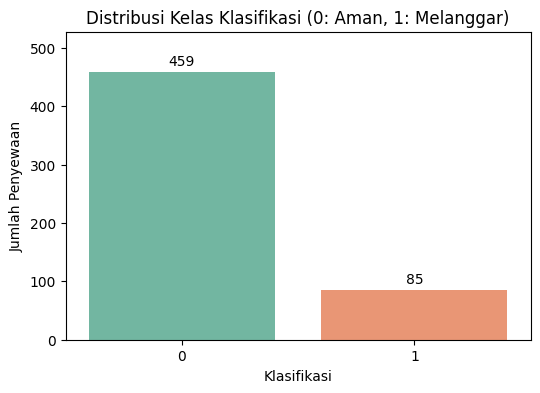


[3] Rata-rata Pelanggaran Berdasarkan Seluruh Kategori:

--- Tingkat Pelanggaran Berdasarkan status_pasutri ---
status_pasutri
Belum Menikah    0.164
Menikah          0.145
Name: label, dtype: float64

--- Tingkat Pelanggaran Berdasarkan status_kewarganegaraan ---
status_kewarganegaraan
WNI    0.156
Name: label, dtype: float64

--- Tingkat Pelanggaran Berdasarkan jenis_sewa ---
jenis_sewa
Harian     0.157
Bulanan    0.000
Name: label, dtype: float64

--- Tingkat Pelanggaran Berdasarkan metode_pembayaran ---
metode_pembayaran
Kartu Kredit    0.280
Others          0.158
Cash            0.150
QRIS            0.148
Kartu Debit     0.107
Name: label, dtype: float64

[4] Korelasi Antar Fitur:


/tmp/ipykernel_1991/2036310360.py:97: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_eda['checkin_hour_num'] = pd.to_datetime(df_eda['waktu_checkin'], errors='coerce').dt.hour.fillna(0)
/tmp/ipykernel_1991/2036310360.py:98: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_eda['checkout_hour_num'] = pd.to_datetime(df_eda['waktu_checkout'], errors='coerce').dt.hour.fillna(0)


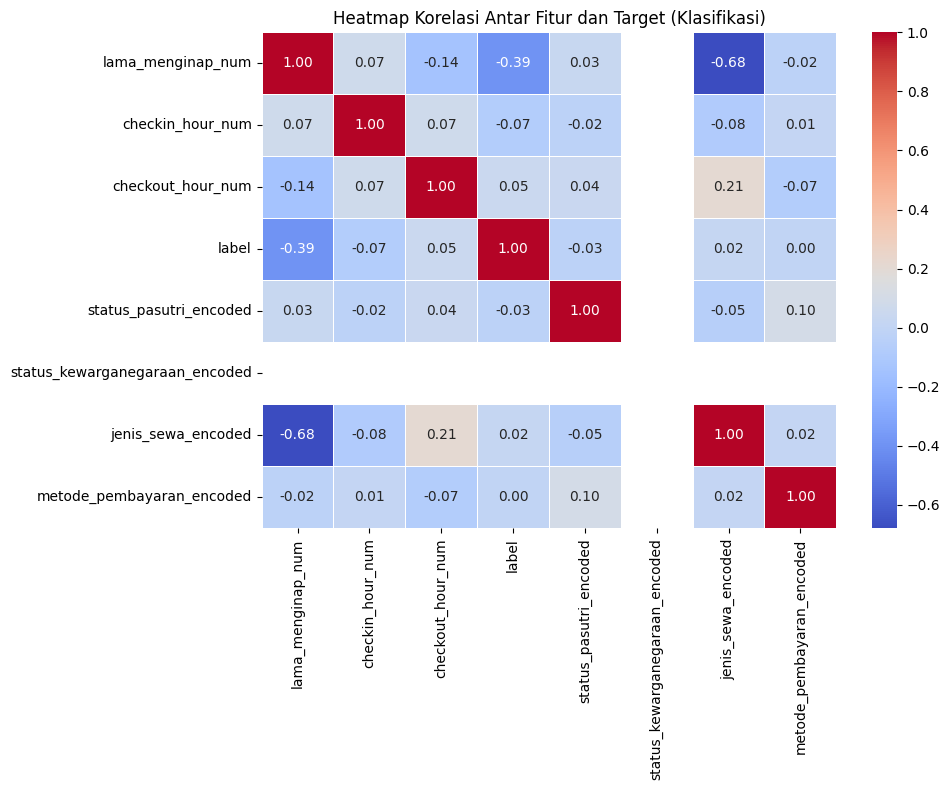


[5] Visualisasi Pola Penyewaan (Dikaitkan dengan Klasifikasi):


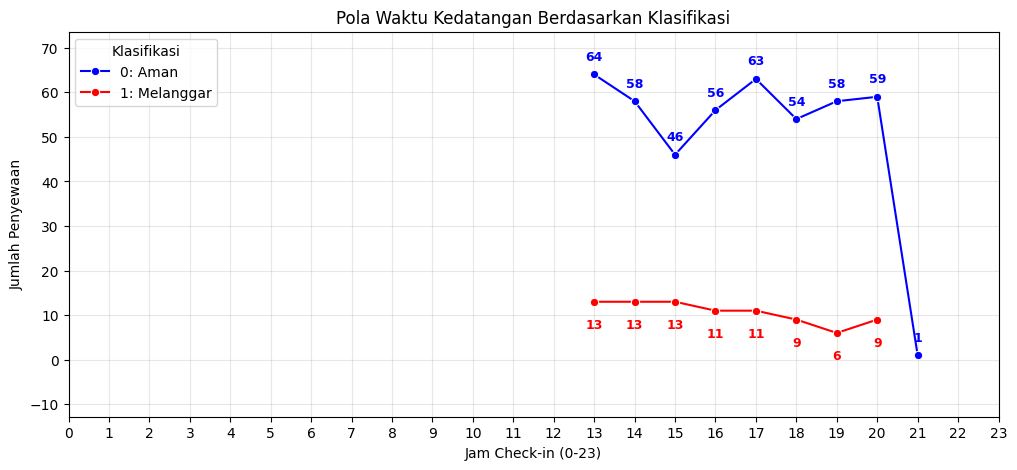

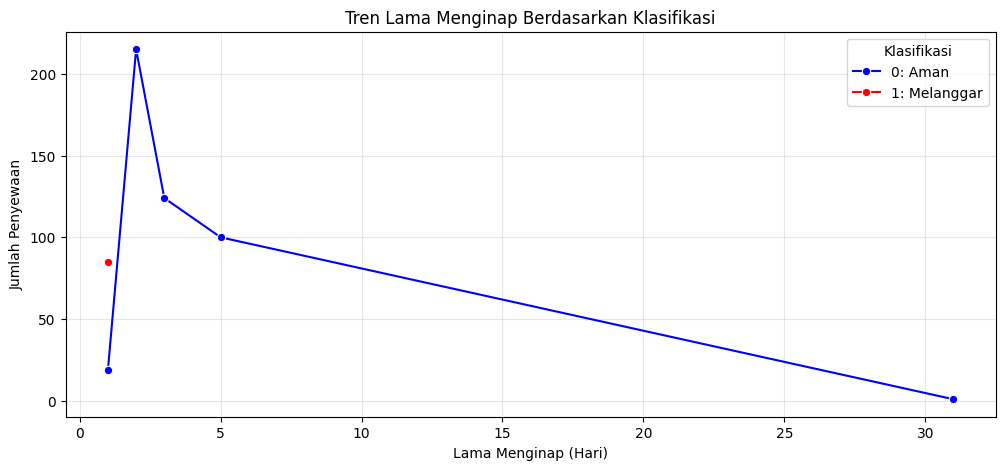

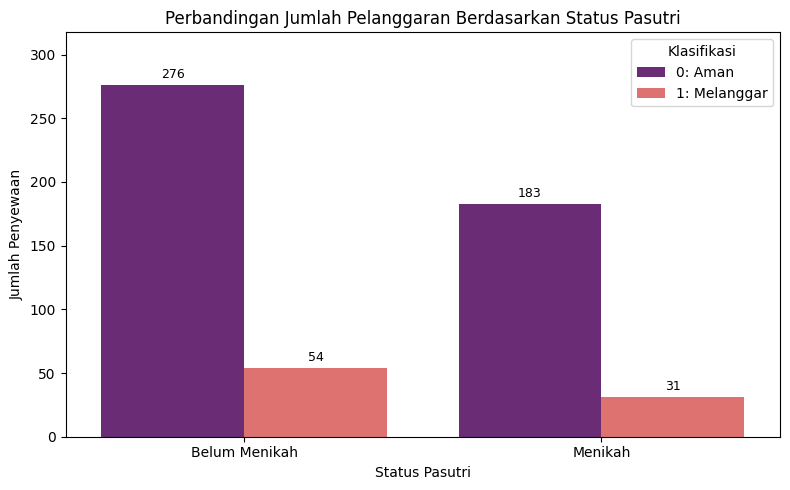

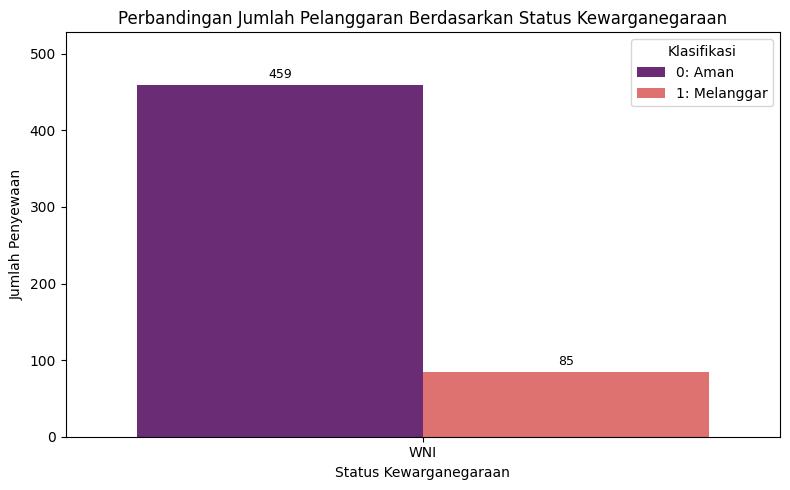

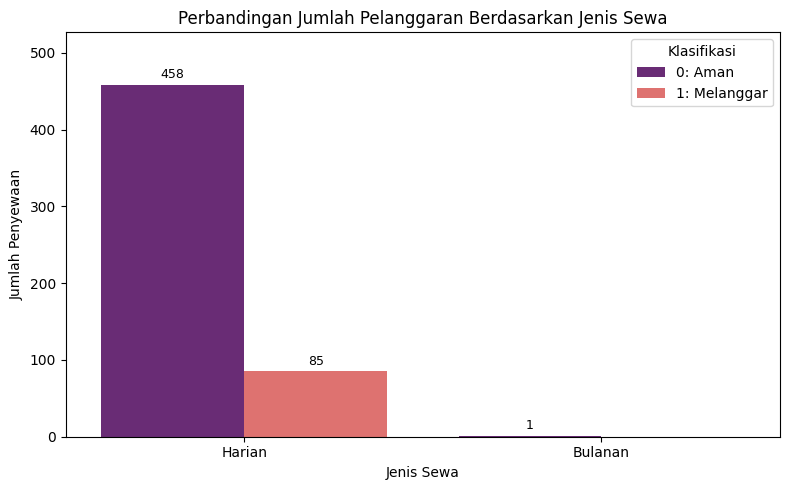

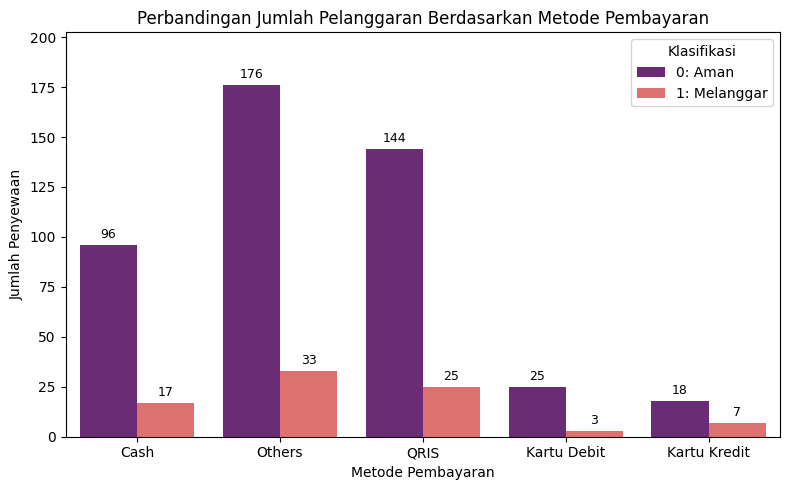


[5b] Visualisasi Metode Pembayaran 'Others' (metode_lain):


/tmp/ipykernel_1991/2036310360.py:205: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


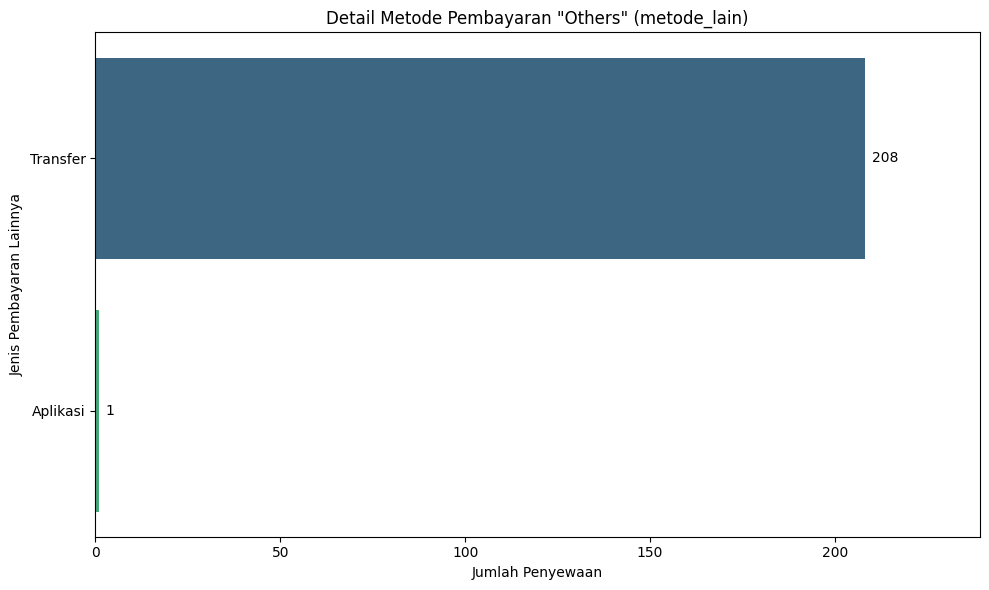

/tmp/ipykernel_1991/2036310360.py:239: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  rentals['waktu_checkout_dt'] = pd.to_datetime(rentals['waktu_checkout'], errors='coerce')
/tmp/ipykernel_1991/2036310360.py:242: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  rentals['waktu_checkin_dt'] = pd.to_datetime(rentals['waktu_checkin'], errors='coerce')



=== Proses Feature Selection ===

-> Fitur yang dipilih (6 terbaik): ['lama_menginap', 'checkout_hour', 'checkin_hour', 'metode_pembayaran', 'jenis_sewa', 'status_pasutri']

===== Decision Tree =====
Classification Report:
              precision    recall  f1-score   support

           0     1.0000    0.9565    0.9778        92
           1     0.8095    1.0000    0.8947        17

    accuracy                         0.9633       109
   macro avg     0.9048    0.9783    0.9363       109
weighted avg     0.9703    0.9633    0.9648       109

Confusion Matrix (Text):
                Predicted
               0       1
          -----------------
True   0 |     88       4
       1 |      0      17
          -----------------


===== Random Forest =====
Classification Report:
              precision    recall  f1-score   support

           0     1.0000    0.9565    0.9778        92
           1     0.8095    1.0000    0.8947        17

    accuracy                         0.9633       

In [ ]:
# ============================================================
# DATA RIIL (TANPA TUNING) --> jumlah fitur = 6
# ============================================================

import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.pipeline import make_pipeline
from sklearn.feature_selection import SelectKBest, chi2, mutual_info_classif

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier

import matplotlib.pyplot as plt
import seaborn as sns

# ------------------------------------------------------------
# 1. LOAD DATA
# ------------------------------------------------------------
rentals    = pd.read_csv('rentals.csv')
logs       = pd.read_csv('rental_logs.csv')
# units      = pd.read_csv('units.csv')
# users      = pd.read_csv('users.csv')
# violations = pd.read_csv('violations.csv')

rentals.columns = rentals.columns.str.lower()

if 'komentar' not in rentals.columns:
    raise ValueError("Kolom 'komentar' tidak ditemukan di rentals.csv")

print("rentals.csv")
print(rentals.head())
print("logs.csv")
print(logs.head())


# ------------------------------------------------------------
# 2. LABELING
# ------------------------------------------------------------
rentals['komentar'] = rentals['komentar'].astype(str).str.lower().str.strip()
empty_values = ["", "nan", "na", "null", "-", "0", "tidak ada", "none", " "]
rentals['label'] = (~rentals['komentar'].isin(empty_values)).astype(int)


# ============================================================
# EXPLORATORY DATA ANALYSIS (EDA)
# ============================================================
print("\n" + "="*50)
print("=== EXPLORATORY DATA ANALYSIS (EDA) ===")
print("="*50)

df_eda = rentals.copy()

print("\n[1] Statistik Deskriptif:")
print(df_eda.describe(include='all'))

print("\n[2] Distribusi Kelas Target (0: Aman, 1: Melanggar):")
print(df_eda['label'].value_counts())

fig, ax = plt.subplots(figsize=(6, 4))
sns.countplot(data=df_eda, x='label', palette='Set2', ax=ax)
plt.title('Distribusi Kelas Klasifikasi (0: Aman, 1: Melanggar)')
plt.xlabel('Klasifikasi')
plt.ylabel('Jumlah Penyewaan')

y_max = df_eda['label'].value_counts().max()
plt.ylim(0, y_max * 1.15)

for p in ax.patches:
    if p.get_height() > 0:
        ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='baseline', fontsize=10, color='black', xytext=(0, 5),
                    textcoords='offset points')
plt.show()

kolom_dikecualikan = ['id', 'nama', 'nik', 'unit_number', 'tanggal_checkin', 'waktu_checkin',
                      'tanggal_checkout', 'waktu_checkout', 'komentar', 'user_email', 'diedit_oleh', 'created_at', 'metode_lain', 'classification']

semua_kategori = [col for col in df_eda.select_dtypes(include=['object', 'category']).columns if col not in kolom_dikecualikan]

print("\n[3] Rata-rata Pelanggaran Berdasarkan Seluruh Kategori:")
for col in semua_kategori:
    if col in df_eda.columns:
        print(f"\n--- Tingkat Pelanggaran Berdasarkan {col} ---")
        print(df_eda.groupby(col)['label'].mean().sort_values(ascending=False).round(3))

df_eda['lama_menginap_num'] = pd.to_numeric(df_eda['lama_menginap'], errors='coerce').fillna(0)
df_eda['checkin_hour_num'] = pd.to_datetime(df_eda['waktu_checkin'], errors='coerce').dt.hour.fillna(0)
df_eda['checkout_hour_num'] = pd.to_datetime(df_eda['waktu_checkout'], errors='coerce').dt.hour.fillna(0)

le_eda = LabelEncoder()
for c in semua_kategori:
    if c in df_eda.columns:
        df_eda[c + '_encoded'] = le_eda.fit_transform(df_eda[c].astype(str))

print("\n[4] Korelasi Antar Fitur:")
kolom_korelasi = ['lama_menginap_num', 'checkin_hour_num', 'checkout_hour_num', 'label']
kolom_korelasi += [c + '_encoded' for c in semua_kategori if c + '_encoded' in df_eda.columns]

corr_matrix = df_eda[kolom_korelasi].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Heatmap Korelasi Antar Fitur dan Target (Klasifikasi)')
plt.tight_layout()
plt.show()

print("\n[5] Visualisasi Pola Penyewaan (Dikaitkan dengan Klasifikasi):")

custom_line_palette = {0: 'blue', 1: 'red'}
custom_labels = ['0: Aman', '1: Melanggar']

fig, ax1 = plt.subplots(figsize=(12, 5))
waktu_df = df_eda.groupby(['checkin_hour_num', 'label']).size().reset_index(name='jumlah')

sns.lineplot(data=waktu_df, x='checkin_hour_num', y='jumlah', hue='label', marker='o', palette=custom_line_palette, ax=ax1)

plt.title('Pola Waktu Kedatangan Berdasarkan Klasifikasi')
plt.xlabel('Jam Check-in (0-23)')
plt.ylabel('Jumlah Penyewaan')
plt.xticks(range(0, 24))
plt.grid(True, alpha=0.3)

y_max_line = waktu_df['jumlah'].max()
plt.ylim(-y_max_line * 0.20, y_max_line * 1.15)

handles, _ = ax1.get_legend_handles_labels()
plt.legend(handles=handles, labels=custom_labels, title='Klasifikasi')

for l in waktu_df['label'].unique():
    sub = waktu_df[waktu_df['label'] == l]
    warna_teks = custom_line_palette[l]

    for x, y in zip(sub['checkin_hour_num'], sub['jumlah']):
        y_offset = 8 if l == 0 else -12
        va_align = 'bottom' if l == 0 else 'top'
        plt.annotate(f'{int(y)}', (x, y), textcoords="offset points", xytext=(0, y_offset),
                     ha='center', va=va_align, fontsize=9, color=warna_teks, fontweight='bold')
plt.show()

fig, ax2 = plt.subplots(figsize=(12, 5))
lama_df = df_eda.groupby(['lama_menginap_num', 'label']).size().reset_index(name='jumlah')

sns.lineplot(data=lama_df, x='lama_menginap_num', y='jumlah', hue='label', marker='o', palette=custom_line_palette, ax=ax2)

plt.title('Tren Lama Menginap Berdasarkan Klasifikasi')
plt.xlabel('Lama Menginap (Hari)')
plt.ylabel('Jumlah Penyewaan')
plt.grid(True, alpha=0.3)

handles2, _ = ax2.get_legend_handles_labels()
plt.legend(handles=handles2, labels=custom_labels, title='Klasifikasi')
plt.show()

for col in semua_kategori:
    if col in df_eda.columns:
        fig, ax = plt.subplots(figsize=(8, 5))
        sns.countplot(data=df_eda, x=col, hue='label', palette='magma', ax=ax)

        judul_kolom = col.replace('_', ' ').title()
        plt.title(f'Perbandingan Jumlah Pelanggaran Berdasarkan {judul_kolom}')
        plt.xlabel(judul_kolom)
        plt.ylabel('Jumlah Penyewaan')
        plt.xticks(rotation=0)

        handles_bar, _ = ax.get_legend_handles_labels()
        plt.legend(handles=handles_bar, labels=custom_labels, title='Klasifikasi')

        y_max_bar = df_eda.groupby([col, 'label']).size().max()
        plt.ylim(0, y_max_bar * 1.15)

        for p in ax.patches:
            if p.get_height() > 0:
                ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                            ha='center', va='baseline', fontsize=9, color='black', xytext=(0, 5),
                            textcoords='offset points')
        plt.tight_layout()
        plt.show()


print("\n[5b] Visualisasi Metode Pembayaran 'Others' (metode_lain):")

# Memastikan kolom 'metode_lain' berbentuk string dan membersihkan spasi/nilai kosong
df_eda['metode_lain'] = df_eda['metode_lain'].astype(str).str.strip().str.title()
empty_lain = ["", "Nan", "Na", "Null", "-", "0", "None"]

# Filter hanya baris yang memiliki nilai di 'metode_lain'
df_others = df_eda[~df_eda['metode_lain'].isin(empty_lain)]

if not df_others.empty:
    fig, ax = plt.subplots(figsize=(10, 6))

    # Menghitung frekuensi masing-masing metode pembayaran lain
    order_others = df_others['metode_lain'].value_counts().index

    sns.countplot(
        data=df_others,
        y='metode_lain',
        order=order_others,
        palette='viridis',
        ax=ax
    )

    plt.title('Detail Metode Pembayaran "Others" (metode_lain)')
    plt.xlabel('Jumlah Penyewaan')
    plt.ylabel('Jenis Pembayaran Lainnya')

    # Menambahkan anotasi angka di sebelah setiap bar
    for p in ax.patches:
        width = p.get_width()
        if width > 0:
            ax.annotate(f'{int(width)}',
                        (width, p.get_y() + p.get_height() / 2.),
                        ha='left', va='center', fontsize=10, color='black',
                        xytext=(5, 0), textcoords='offset points')

    # Perlebar batas x-axis sedikit agar angka anotasi tidak terpotong
    x_max = df_others['metode_lain'].value_counts().max()
    plt.xlim(0, x_max * 1.15)

    plt.tight_layout()
    plt.show()
else:
    print("Tidak ada data metode pembayaran 'Others' yang valid untuk ditampilkan.")


# ------------------------------------------------------------
# 3. FEATURE ENGINEERING & PREPARATION
# ------------------------------------------------------------
rentals['waktu_checkout_dt'] = pd.to_datetime(rentals['waktu_checkout'], errors='coerce')
rentals['checkout_hour'] = rentals['waktu_checkout_dt'].dt.hour.fillna(0).astype(int)

rentals['waktu_checkin_dt'] = pd.to_datetime(rentals['waktu_checkin'], errors='coerce')
rentals['checkin_hour'] = rentals['waktu_checkin_dt'].dt.hour.fillna(0).astype(int)

rentals['lama_menginap'] = pd.to_numeric(rentals['lama_menginap'], errors='coerce').fillna(0)

cat_cols = ['jenis_sewa', 'metode_pembayaran', 'status_pasutri', 'status_kewarganegaraan']
for c in cat_cols:
    rentals[c] = rentals[c].fillna('Unknown').astype(str)

numeric_cols = ['checkout_hour', 'checkin_hour', 'lama_menginap']
feature_cols = cat_cols + numeric_cols

X = rentals[feature_cols].copy()
y = rentals['label']

# ------------------------------------------------------------
# 4. TRAIN-TEST SPLIT
# ------------------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, stratify=y, test_size=0.2, random_state=42
)

# ------------------------------------------------------------
# 4B. ENCODING MENCEGAH DATA LEAKAGE
# ------------------------------------------------------------
label_encoders = {}

for c in cat_cols:
    le = LabelEncoder()
    X_train[c] = le.fit_transform(X_train[c])

    X_test[c] = X_test[c].map(lambda s: s if s in le.classes_ else 'Unknown')
    if 'Unknown' not in le.classes_:
        le.classes_ = np.append(le.classes_, 'Unknown')

    X_test[c] = le.transform(X_test[c])

    label_encoders[c] = le

# ------------------------------------------------------------
# 5. FEATURE SELECTION
# ------------------------------------------------------------
print("\n=== Proses Feature Selection ===")
chi2_selector = SelectKBest(score_func=chi2, k='all')
chi2_selector.fit(X_train, y_train)

train_df = X_train.copy()
train_df['label'] = y_train
pearson_scores = train_df.corr(method='pearson')['label'].drop('label').abs().values

mi_selector = SelectKBest(score_func=mutual_info_classif, k='all')
mi_selector.fit(X_train, y_train)

fs_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Chi-Square': chi2_selector.scores_,
    'Pearson (Abs)': pearson_scores,
    'Mutual Info': mi_selector.scores_
})

scaler = MinMaxScaler()
fs_df[['Chi2_Norm', 'Pearson_Norm', 'MI_Norm']] = scaler.fit_transform(
    fs_df[['Chi-Square', 'Pearson (Abs)', 'Mutual Info']]
)
fs_df['Total_Score'] = fs_df[['Chi2_Norm', 'Pearson_Norm', 'MI_Norm']].mean(axis=1)
fs_df = fs_df.sort_values(by='Total_Score', ascending=False).reset_index(drop=True)

# Jumlah Fitur
n_select = 6
selected_features = fs_df['Feature'].head(n_select).tolist()
print(f"\n-> Fitur yang dipilih ({n_select} terbaik): {selected_features}")

X_train = X_train[selected_features]
X_test = X_test[selected_features]

# ------------------------------------------------------------
# 6. Fungsi Evaluasi
# ------------------------------------------------------------
def evaluate(name, model):
    y_pred = model.predict(X_test)
    print(f"\n===== {name} =====")
    print("Classification Report:")
    print(classification_report(y_test, y_pred, digits=4))
    cm = confusion_matrix(y_test, y_pred)
    print("Confusion Matrix (Text):")
    print("                Predicted")
    print("               0       1")
    print("          -----------------")
    print(f"True   0 | {cm[0][0]:6d}  {cm[0][1]:6d}")
    print(f"       1 | {cm[1][0]:6d}  {cm[1][1]:6d}")
    print("          -----------------\n")

# ------------------------------------------------------------
# 7. Latih Semua Model (TANPA TUNING)
# ------------------------------------------------------------
models = {}
custom_weight = {0: 1, 1: 4}

# Model menggunakan pengaturan tetap
models["Decision Tree"] = DecisionTreeClassifier(max_depth=6, class_weight=custom_weight, random_state=42)
models["Random Forest"] = RandomForestClassifier(n_estimators=200, max_depth=7, class_weight=custom_weight, random_state=42)
models["KNN"] = make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=5, weights='distance'))
models["SVM RBF"] = make_pipeline(StandardScaler(), SVC(kernel='rbf', probability=True, class_weight=custom_weight, random_state=42))
models["XGBoost"] = XGBClassifier(n_estimators=200, max_depth=5, learning_rate=0.05, scale_pos_weight=4, eval_metric='logloss', random_state=42)

for name, model in models.items():
    model.fit(X_train, y_train)
    evaluate(name, model)

# ------------------------------------------------------------
# 8. Eksport Model Terbaik & Label Encoders
# ------------------------------------------------------------
print("\n=== Proses Export Model ===")

# Gabungkan model dan encoders ke dalam satu dictionary agar rapi
export_package = {
    'model': models["KNN"],
    'label_encoders': label_encoders,
    'selected_features': selected_features # Penting agar tahu urutan kolom masuk saat predict
}

# Menentukan nama file yang sesuai untuk KNN
filename = 'model_knn.pkl'

# Menyimpan package ke dalam file .pkl
joblib.dump(export_package, filename)
print(f"Sukses! Model dan Label Encoders telah disimpan sebagai file: {filename}")

rentals.csv
   id                   nama               nik status_pasutri  \
0   3  Novi Yanti Salsa Dewi  3204065911020004  Belum Menikah   
1   4     Amilia Nur Halimah  3520064903040001  Belum Menikah   
2   5     Achmad Agel Shahab  3525160508900001        Menikah   
3   6            Cries Wandi  1471051210920001  Belum Menikah   
4   7             SELO UTOMO  3171061909880002  Belum Menikah   

  status_kewarganegaraan jenis_sewa unit_number metode_pembayaran metode_lain  \
0                    WNI     Harian     B-20-27              Cash         NaN   
1                    WNI     Harian     A-15-25              Cash         NaN   
2                    WNI     Harian     A-06-24            Others    Aplikasi   
3                    WNI     Harian     D-15-21              QRIS         NaN   
4                    WNI     Harian       A-8-8            Others    Transfer   

  tanggal_checkin waktu_checkin tanggal_checkout waktu_checkout  \
0      2026-05-20      13:08:00       2026-

/tmp/ipykernel_1991/2187553676.py:70: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_eda, x='label', palette='Set2', ax=ax)


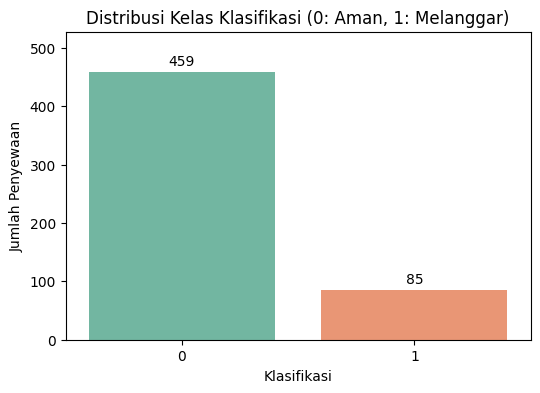


[3] Rata-rata Pelanggaran Berdasarkan Seluruh Kategori:

--- Tingkat Pelanggaran Berdasarkan status_pasutri ---
status_pasutri
Belum Menikah    0.164
Menikah          0.145
Name: label, dtype: float64

--- Tingkat Pelanggaran Berdasarkan status_kewarganegaraan ---
status_kewarganegaraan
WNI    0.156
Name: label, dtype: float64

--- Tingkat Pelanggaran Berdasarkan jenis_sewa ---
jenis_sewa
Harian     0.157
Bulanan    0.000
Name: label, dtype: float64

--- Tingkat Pelanggaran Berdasarkan metode_pembayaran ---
metode_pembayaran
Kartu Kredit    0.280
Others          0.158
Cash            0.150
QRIS            0.148
Kartu Debit     0.107
Name: label, dtype: float64

[4] Korelasi Antar Fitur:


/tmp/ipykernel_1991/2187553676.py:97: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_eda['checkin_hour_num'] = pd.to_datetime(df_eda['waktu_checkin'], errors='coerce').dt.hour.fillna(0)
/tmp/ipykernel_1991/2187553676.py:98: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_eda['checkout_hour_num'] = pd.to_datetime(df_eda['waktu_checkout'], errors='coerce').dt.hour.fillna(0)


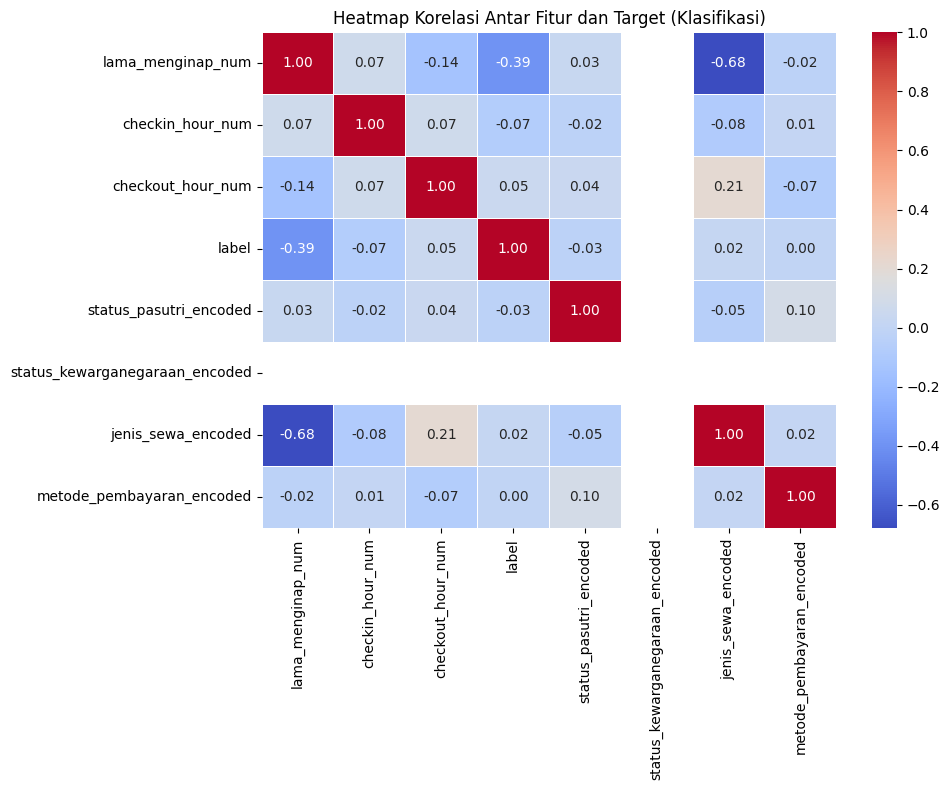


[5] Visualisasi Pola Penyewaan (Dikaitkan dengan Klasifikasi):


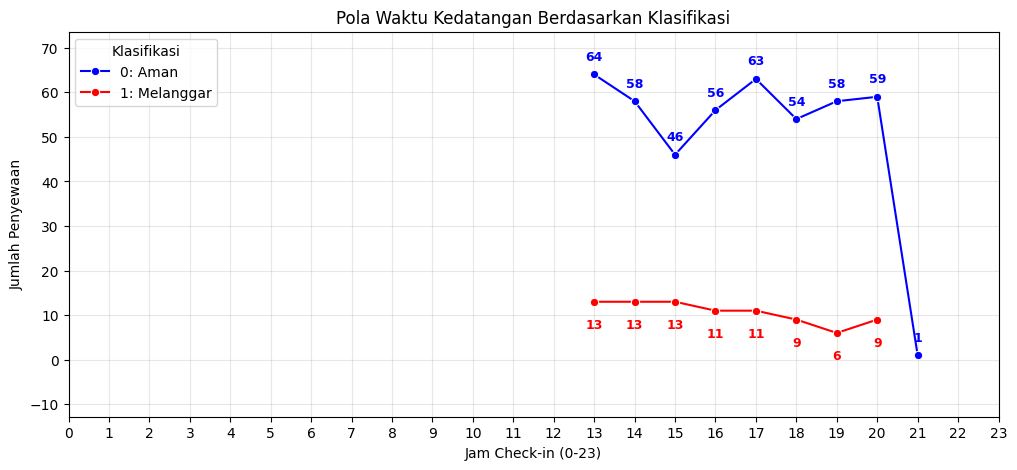

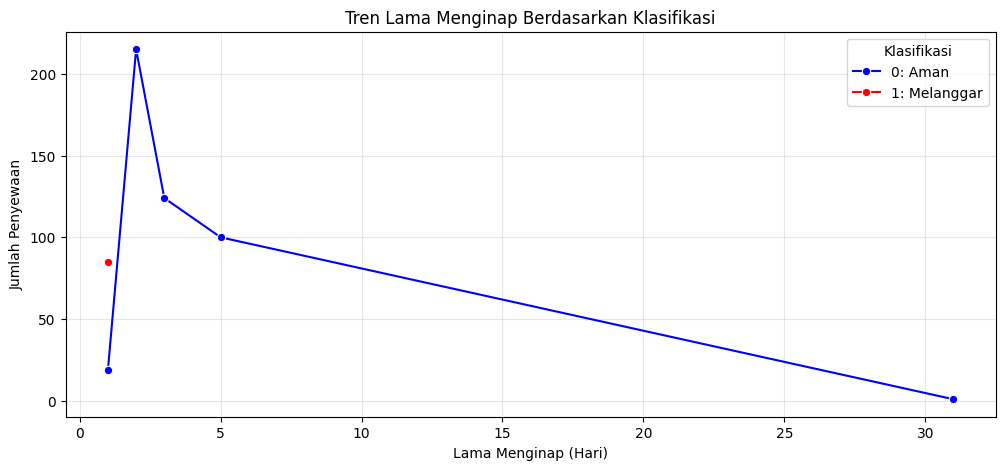

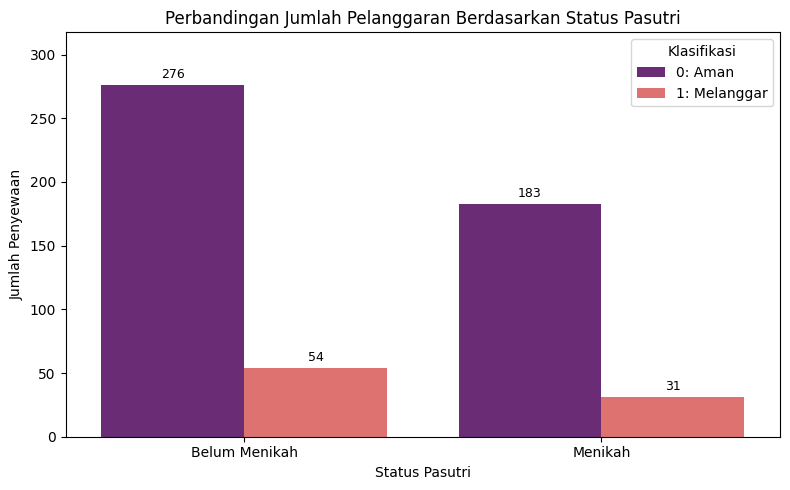

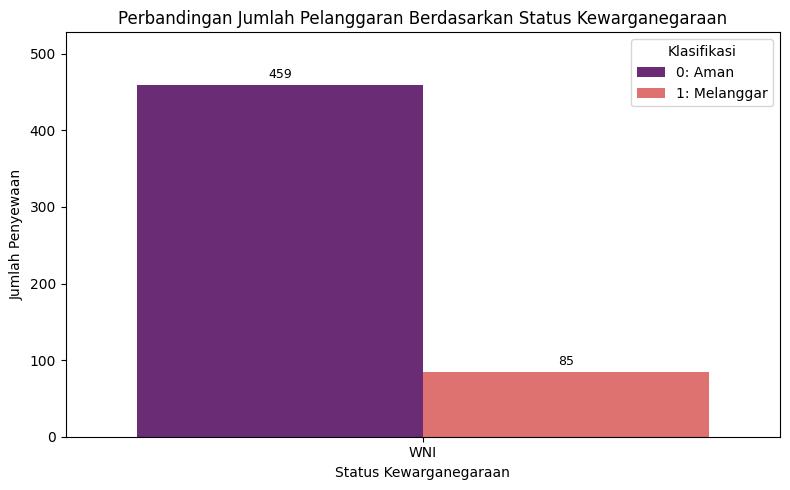

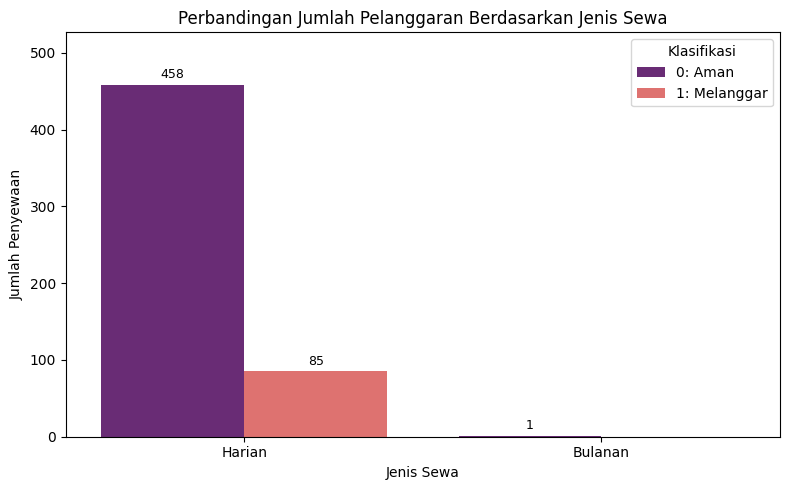

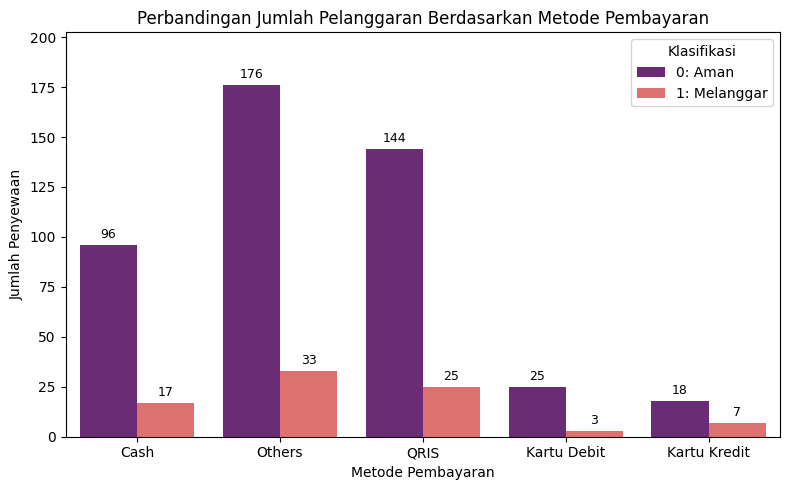


[5b] Visualisasi Metode Pembayaran 'Others' (metode_lain):


/tmp/ipykernel_1991/2187553676.py:205: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


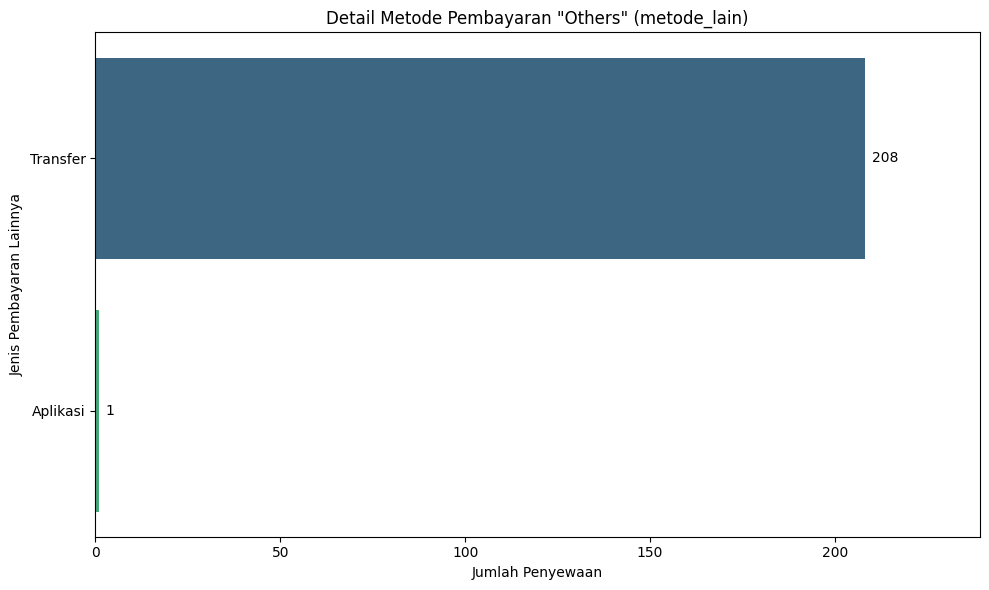

/tmp/ipykernel_1991/2187553676.py:239: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  rentals['waktu_checkout_dt'] = pd.to_datetime(rentals['waktu_checkout'], errors='coerce')
/tmp/ipykernel_1991/2187553676.py:242: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  rentals['waktu_checkin_dt'] = pd.to_datetime(rentals['waktu_checkin'], errors='coerce')



=== Proses Feature Selection ===

-> Fitur yang dipilih (5 terbaik): ['lama_menginap', 'metode_pembayaran', 'checkout_hour', 'checkin_hour', 'status_pasutri']

===== Decision Tree =====
Classification Report:
              precision    recall  f1-score   support

           0     1.0000    0.9565    0.9778        92
           1     0.8095    1.0000    0.8947        17

    accuracy                         0.9633       109
   macro avg     0.9048    0.9783    0.9363       109
weighted avg     0.9703    0.9633    0.9648       109

Confusion Matrix (Text):
                Predicted
               0       1
          -----------------
True   0 |     88       4
       1 |      0      17
          -----------------


===== Random Forest =====
Classification Report:
              precision    recall  f1-score   support

           0     1.0000    0.9565    0.9778        92
           1     0.8095    1.0000    0.8947        17

    accuracy                         0.9633       109
   macro a

In [ ]:
# ============================================================
# DATA RIIL (TANPA TUNING) --> jumlah fitur = 5
# ============================================================

import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.pipeline import make_pipeline
from sklearn.feature_selection import SelectKBest, chi2, mutual_info_classif

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier

import matplotlib.pyplot as plt
import seaborn as sns

# ------------------------------------------------------------
# 1. LOAD DATA
# ------------------------------------------------------------
rentals    = pd.read_csv('rentals.csv')
logs       = pd.read_csv('rental_logs.csv')
# units      = pd.read_csv('units.csv')
# users      = pd.read_csv('users.csv')
# violations = pd.read_csv('violations.csv')

rentals.columns = rentals.columns.str.lower()

if 'komentar' not in rentals.columns:
    raise ValueError("Kolom 'komentar' tidak ditemukan di rentals.csv")

print("rentals.csv")
print(rentals.head())
print("logs.csv")
print(logs.head())


# ------------------------------------------------------------
# 2. LABELING
# ------------------------------------------------------------
rentals['komentar'] = rentals['komentar'].astype(str).str.lower().str.strip()
empty_values = ["", "nan", "na", "null", "-", "0", "tidak ada", "none", " "]
rentals['label'] = (~rentals['komentar'].isin(empty_values)).astype(int)


# ============================================================
# EXPLORATORY DATA ANALYSIS (EDA)
# ============================================================
print("\n" + "="*50)
print("=== EXPLORATORY DATA ANALYSIS (EDA) ===")
print("="*50)

df_eda = rentals.copy()

print("\n[1] Statistik Deskriptif:")
print(df_eda.describe(include='all'))

print("\n[2] Distribusi Kelas Target (0: Aman, 1: Melanggar):")
print(df_eda['label'].value_counts())

fig, ax = plt.subplots(figsize=(6, 4))
sns.countplot(data=df_eda, x='label', palette='Set2', ax=ax)
plt.title('Distribusi Kelas Klasifikasi (0: Aman, 1: Melanggar)')
plt.xlabel('Klasifikasi')
plt.ylabel('Jumlah Penyewaan')

y_max = df_eda['label'].value_counts().max()
plt.ylim(0, y_max * 1.15)

for p in ax.patches:
    if p.get_height() > 0:
        ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='baseline', fontsize=10, color='black', xytext=(0, 5),
                    textcoords='offset points')
plt.show()

kolom_dikecualikan = ['id', 'nama', 'nik', 'unit_number', 'tanggal_checkin', 'waktu_checkin',
                      'tanggal_checkout', 'waktu_checkout', 'komentar', 'user_email', 'diedit_oleh', 'created_at', 'metode_lain', 'classification']

semua_kategori = [col for col in df_eda.select_dtypes(include=['object', 'category']).columns if col not in kolom_dikecualikan]

print("\n[3] Rata-rata Pelanggaran Berdasarkan Seluruh Kategori:")
for col in semua_kategori:
    if col in df_eda.columns:
        print(f"\n--- Tingkat Pelanggaran Berdasarkan {col} ---")
        print(df_eda.groupby(col)['label'].mean().sort_values(ascending=False).round(3))

df_eda['lama_menginap_num'] = pd.to_numeric(df_eda['lama_menginap'], errors='coerce').fillna(0)
df_eda['checkin_hour_num'] = pd.to_datetime(df_eda['waktu_checkin'], errors='coerce').dt.hour.fillna(0)
df_eda['checkout_hour_num'] = pd.to_datetime(df_eda['waktu_checkout'], errors='coerce').dt.hour.fillna(0)

le_eda = LabelEncoder()
for c in semua_kategori:
    if c in df_eda.columns:
        df_eda[c + '_encoded'] = le_eda.fit_transform(df_eda[c].astype(str))

print("\n[4] Korelasi Antar Fitur:")
kolom_korelasi = ['lama_menginap_num', 'checkin_hour_num', 'checkout_hour_num', 'label']
kolom_korelasi += [c + '_encoded' for c in semua_kategori if c + '_encoded' in df_eda.columns]

corr_matrix = df_eda[kolom_korelasi].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Heatmap Korelasi Antar Fitur dan Target (Klasifikasi)')
plt.tight_layout()
plt.show()

print("\n[5] Visualisasi Pola Penyewaan (Dikaitkan dengan Klasifikasi):")

custom_line_palette = {0: 'blue', 1: 'red'}
custom_labels = ['0: Aman', '1: Melanggar']

fig, ax1 = plt.subplots(figsize=(12, 5))
waktu_df = df_eda.groupby(['checkin_hour_num', 'label']).size().reset_index(name='jumlah')

sns.lineplot(data=waktu_df, x='checkin_hour_num', y='jumlah', hue='label', marker='o', palette=custom_line_palette, ax=ax1)

plt.title('Pola Waktu Kedatangan Berdasarkan Klasifikasi')
plt.xlabel('Jam Check-in (0-23)')
plt.ylabel('Jumlah Penyewaan')
plt.xticks(range(0, 24))
plt.grid(True, alpha=0.3)

y_max_line = waktu_df['jumlah'].max()
plt.ylim(-y_max_line * 0.20, y_max_line * 1.15)

handles, _ = ax1.get_legend_handles_labels()
plt.legend(handles=handles, labels=custom_labels, title='Klasifikasi')

for l in waktu_df['label'].unique():
    sub = waktu_df[waktu_df['label'] == l]
    warna_teks = custom_line_palette[l]

    for x, y in zip(sub['checkin_hour_num'], sub['jumlah']):
        y_offset = 8 if l == 0 else -12
        va_align = 'bottom' if l == 0 else 'top'
        plt.annotate(f'{int(y)}', (x, y), textcoords="offset points", xytext=(0, y_offset),
                     ha='center', va=va_align, fontsize=9, color=warna_teks, fontweight='bold')
plt.show()

fig, ax2 = plt.subplots(figsize=(12, 5))
lama_df = df_eda.groupby(['lama_menginap_num', 'label']).size().reset_index(name='jumlah')

sns.lineplot(data=lama_df, x='lama_menginap_num', y='jumlah', hue='label', marker='o', palette=custom_line_palette, ax=ax2)

plt.title('Tren Lama Menginap Berdasarkan Klasifikasi')
plt.xlabel('Lama Menginap (Hari)')
plt.ylabel('Jumlah Penyewaan')
plt.grid(True, alpha=0.3)

handles2, _ = ax2.get_legend_handles_labels()
plt.legend(handles=handles2, labels=custom_labels, title='Klasifikasi')
plt.show()

for col in semua_kategori:
    if col in df_eda.columns:
        fig, ax = plt.subplots(figsize=(8, 5))
        sns.countplot(data=df_eda, x=col, hue='label', palette='magma', ax=ax)

        judul_kolom = col.replace('_', ' ').title()
        plt.title(f'Perbandingan Jumlah Pelanggaran Berdasarkan {judul_kolom}')
        plt.xlabel(judul_kolom)
        plt.ylabel('Jumlah Penyewaan')
        plt.xticks(rotation=0)

        handles_bar, _ = ax.get_legend_handles_labels()
        plt.legend(handles=handles_bar, labels=custom_labels, title='Klasifikasi')

        y_max_bar = df_eda.groupby([col, 'label']).size().max()
        plt.ylim(0, y_max_bar * 1.15)

        for p in ax.patches:
            if p.get_height() > 0:
                ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                            ha='center', va='baseline', fontsize=9, color='black', xytext=(0, 5),
                            textcoords='offset points')
        plt.tight_layout()
        plt.show()


print("\n[5b] Visualisasi Metode Pembayaran 'Others' (metode_lain):")

# Memastikan kolom 'metode_lain' berbentuk string dan membersihkan spasi/nilai kosong
df_eda['metode_lain'] = df_eda['metode_lain'].astype(str).str.strip().str.title()
empty_lain = ["", "Nan", "Na", "Null", "-", "0", "None"]

# Filter hanya baris yang memiliki nilai di 'metode_lain'
df_others = df_eda[~df_eda['metode_lain'].isin(empty_lain)]

if not df_others.empty:
    fig, ax = plt.subplots(figsize=(10, 6))

    # Menghitung frekuensi masing-masing metode pembayaran lain
    order_others = df_others['metode_lain'].value_counts().index

    sns.countplot(
        data=df_others,
        y='metode_lain',
        order=order_others,
        palette='viridis',
        ax=ax
    )

    plt.title('Detail Metode Pembayaran "Others" (metode_lain)')
    plt.xlabel('Jumlah Penyewaan')
    plt.ylabel('Jenis Pembayaran Lainnya')

    # Menambahkan anotasi angka di sebelah setiap bar
    for p in ax.patches:
        width = p.get_width()
        if width > 0:
            ax.annotate(f'{int(width)}',
                        (width, p.get_y() + p.get_height() / 2.),
                        ha='left', va='center', fontsize=10, color='black',
                        xytext=(5, 0), textcoords='offset points')

    # Perlebar batas x-axis sedikit agar angka anotasi tidak terpotong
    x_max = df_others['metode_lain'].value_counts().max()
    plt.xlim(0, x_max * 1.15)

    plt.tight_layout()
    plt.show()
else:
    print("Tidak ada data metode pembayaran 'Others' yang valid untuk ditampilkan.")


# ------------------------------------------------------------
# 3. FEATURE ENGINEERING & PREPARATION
# ------------------------------------------------------------
rentals['waktu_checkout_dt'] = pd.to_datetime(rentals['waktu_checkout'], errors='coerce')
rentals['checkout_hour'] = rentals['waktu_checkout_dt'].dt.hour.fillna(0).astype(int)

rentals['waktu_checkin_dt'] = pd.to_datetime(rentals['waktu_checkin'], errors='coerce')
rentals['checkin_hour'] = rentals['waktu_checkin_dt'].dt.hour.fillna(0).astype(int)

rentals['lama_menginap'] = pd.to_numeric(rentals['lama_menginap'], errors='coerce').fillna(0)

cat_cols = ['jenis_sewa', 'metode_pembayaran', 'status_pasutri', 'status_kewarganegaraan']
for c in cat_cols:
    rentals[c] = rentals[c].fillna('Unknown').astype(str)

numeric_cols = ['checkout_hour', 'checkin_hour', 'lama_menginap']
feature_cols = cat_cols + numeric_cols

X = rentals[feature_cols].copy()
y = rentals['label']

# ------------------------------------------------------------
# 4. TRAIN-TEST SPLIT
# ------------------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, stratify=y, test_size=0.2, random_state=42
)

# ------------------------------------------------------------
# 4B. ENCODING MENCEGAH DATA LEAKAGE
# ------------------------------------------------------------
label_encoders = {}

for c in cat_cols:
    le = LabelEncoder()
    X_train[c] = le.fit_transform(X_train[c])

    X_test[c] = X_test[c].map(lambda s: s if s in le.classes_ else 'Unknown')
    if 'Unknown' not in le.classes_:
        le.classes_ = np.append(le.classes_, 'Unknown')

    X_test[c] = le.transform(X_test[c])

    label_encoders[c] = le

# ------------------------------------------------------------
# 5. FEATURE SELECTION
# ------------------------------------------------------------
print("\n=== Proses Feature Selection ===")
chi2_selector = SelectKBest(score_func=chi2, k='all')
chi2_selector.fit(X_train, y_train)

train_df = X_train.copy()
train_df['label'] = y_train
pearson_scores = train_df.corr(method='pearson')['label'].drop('label').abs().values

mi_selector = SelectKBest(score_func=mutual_info_classif, k='all')
mi_selector.fit(X_train, y_train)

fs_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Chi-Square': chi2_selector.scores_,
    'Pearson (Abs)': pearson_scores,
    'Mutual Info': mi_selector.scores_
})

scaler = MinMaxScaler()
fs_df[['Chi2_Norm', 'Pearson_Norm', 'MI_Norm']] = scaler.fit_transform(
    fs_df[['Chi-Square', 'Pearson (Abs)', 'Mutual Info']]
)
fs_df['Total_Score'] = fs_df[['Chi2_Norm', 'Pearson_Norm', 'MI_Norm']].mean(axis=1)
fs_df = fs_df.sort_values(by='Total_Score', ascending=False).reset_index(drop=True)

# Jumlah Fitur
n_select = 5
selected_features = fs_df['Feature'].head(n_select).tolist()
print(f"\n-> Fitur yang dipilih ({n_select} terbaik): {selected_features}")

X_train = X_train[selected_features]
X_test = X_test[selected_features]

# ------------------------------------------------------------
# 6. Fungsi Evaluasi
# ------------------------------------------------------------
def evaluate(name, model):
    y_pred = model.predict(X_test)
    print(f"\n===== {name} =====")
    print("Classification Report:")
    print(classification_report(y_test, y_pred, digits=4))
    cm = confusion_matrix(y_test, y_pred)
    print("Confusion Matrix (Text):")
    print("                Predicted")
    print("               0       1")
    print("          -----------------")
    print(f"True   0 | {cm[0][0]:6d}  {cm[0][1]:6d}")
    print(f"       1 | {cm[1][0]:6d}  {cm[1][1]:6d}")
    print("          -----------------\n")

# ------------------------------------------------------------
# 7. Latih Semua Model (TANPA TUNING)
# ------------------------------------------------------------
models = {}
custom_weight = {0: 1, 1: 4}

# Model menggunakan pengaturan tetap
models["Decision Tree"] = DecisionTreeClassifier(max_depth=6, class_weight=custom_weight, random_state=42)
models["Random Forest"] = RandomForestClassifier(n_estimators=200, max_depth=7, class_weight=custom_weight, random_state=42)
models["KNN"] = make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=5, weights='distance'))
models["SVM RBF"] = make_pipeline(StandardScaler(), SVC(kernel='rbf', probability=True, class_weight=custom_weight, random_state=42))
models["XGBoost"] = XGBClassifier(n_estimators=200, max_depth=5, learning_rate=0.05, scale_pos_weight=4, eval_metric='logloss', random_state=42)

for name, model in models.items():
    model.fit(X_train, y_train)
    evaluate(name, model)

# ------------------------------------------------------------
# 8. Eksport Model Terbaik & Label Encoders
# ------------------------------------------------------------
print("\n=== Proses Export Model ===")

# Gabungkan model dan encoders ke dalam satu dictionary agar rapi
export_package = {
    'model': models["KNN"],
    'label_encoders': label_encoders,
    'selected_features': selected_features # Penting agar tahu urutan kolom masuk saat predict
}

# Menentukan nama file yang sesuai untuk KNN
filename = 'model_knn.pkl'

# Menyimpan package ke dalam file .pkl
joblib.dump(export_package, filename)
print(f"Sukses! Model dan Label Encoders telah disimpan sebagai file: {filename}")

rentals.csv
   id                   nama               nik status_pasutri  \
0   3  Novi Yanti Salsa Dewi  3204065911020004  Belum Menikah   
1   4     Amilia Nur Halimah  3520064903040001  Belum Menikah   
2   5     Achmad Agel Shahab  3525160508900001        Menikah   
3   6            Cries Wandi  1471051210920001  Belum Menikah   
4   7             SELO UTOMO  3171061909880002  Belum Menikah   

  status_kewarganegaraan jenis_sewa unit_number metode_pembayaran metode_lain  \
0                    WNI     Harian     B-20-27              Cash         NaN   
1                    WNI     Harian     A-15-25              Cash         NaN   
2                    WNI     Harian     A-06-24            Others    Aplikasi   
3                    WNI     Harian     D-15-21              QRIS         NaN   
4                    WNI     Harian       A-8-8            Others    Transfer   

  tanggal_checkin waktu_checkin tanggal_checkout waktu_checkout  \
0      2026-05-20      13:08:00       2026-

/tmp/ipykernel_1991/491046311.py:70: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_eda, x='label', palette='Set2', ax=ax)


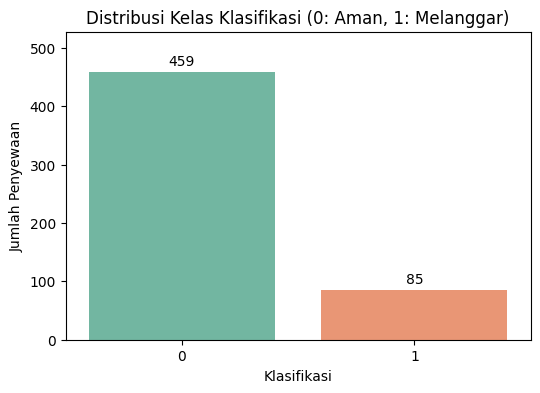


[3] Rata-rata Pelanggaran Berdasarkan Seluruh Kategori:

--- Tingkat Pelanggaran Berdasarkan status_pasutri ---
status_pasutri
Belum Menikah    0.164
Menikah          0.145
Name: label, dtype: float64

--- Tingkat Pelanggaran Berdasarkan status_kewarganegaraan ---
status_kewarganegaraan
WNI    0.156
Name: label, dtype: float64

--- Tingkat Pelanggaran Berdasarkan jenis_sewa ---
jenis_sewa
Harian     0.157
Bulanan    0.000
Name: label, dtype: float64

--- Tingkat Pelanggaran Berdasarkan metode_pembayaran ---
metode_pembayaran
Kartu Kredit    0.280
Others          0.158
Cash            0.150
QRIS            0.148
Kartu Debit     0.107
Name: label, dtype: float64

[4] Korelasi Antar Fitur:


/tmp/ipykernel_1991/491046311.py:97: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_eda['checkin_hour_num'] = pd.to_datetime(df_eda['waktu_checkin'], errors='coerce').dt.hour.fillna(0)
/tmp/ipykernel_1991/491046311.py:98: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_eda['checkout_hour_num'] = pd.to_datetime(df_eda['waktu_checkout'], errors='coerce').dt.hour.fillna(0)


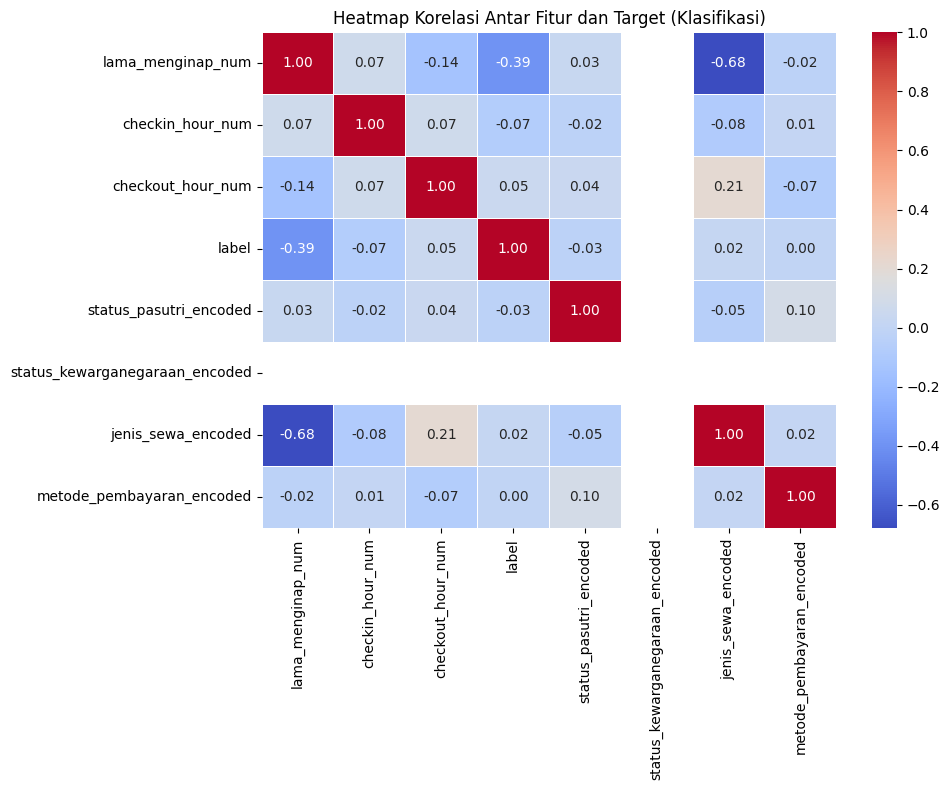


[5] Visualisasi Pola Penyewaan (Dikaitkan dengan Klasifikasi):


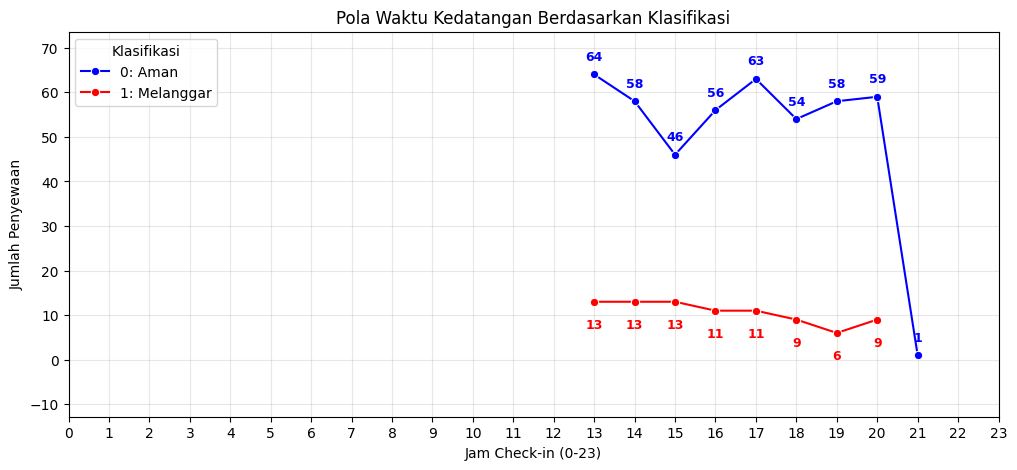

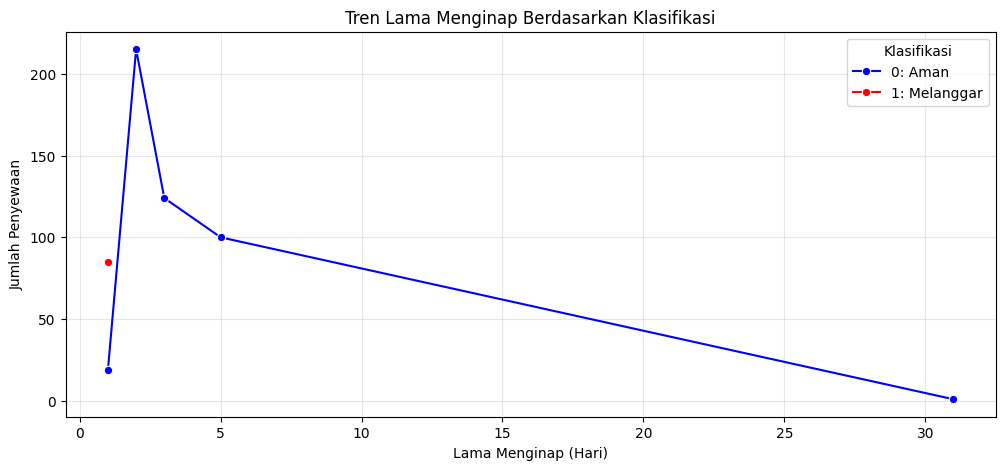

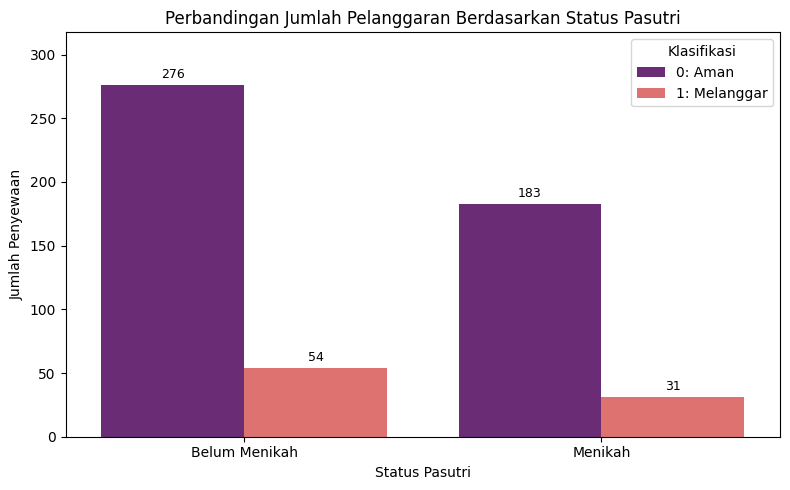

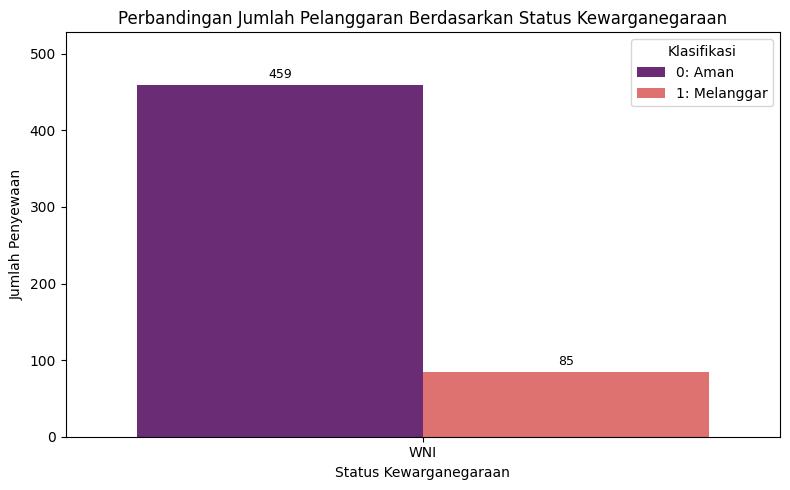

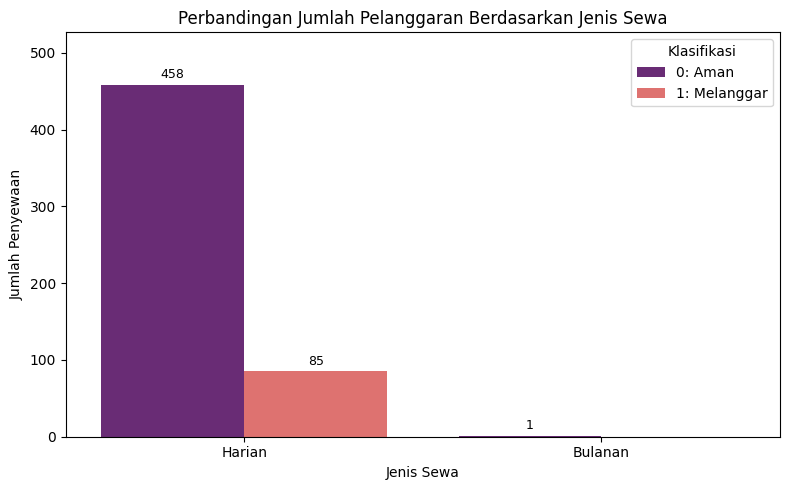

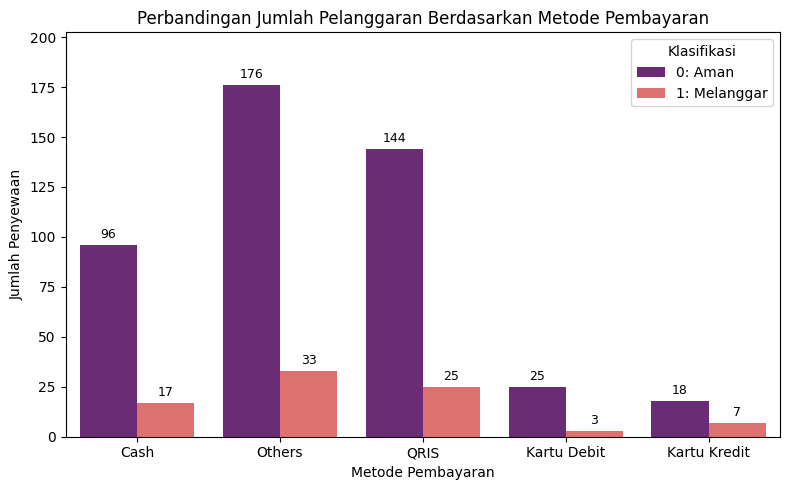


[5b] Visualisasi Metode Pembayaran 'Others' (metode_lain):


/tmp/ipykernel_1991/491046311.py:205: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


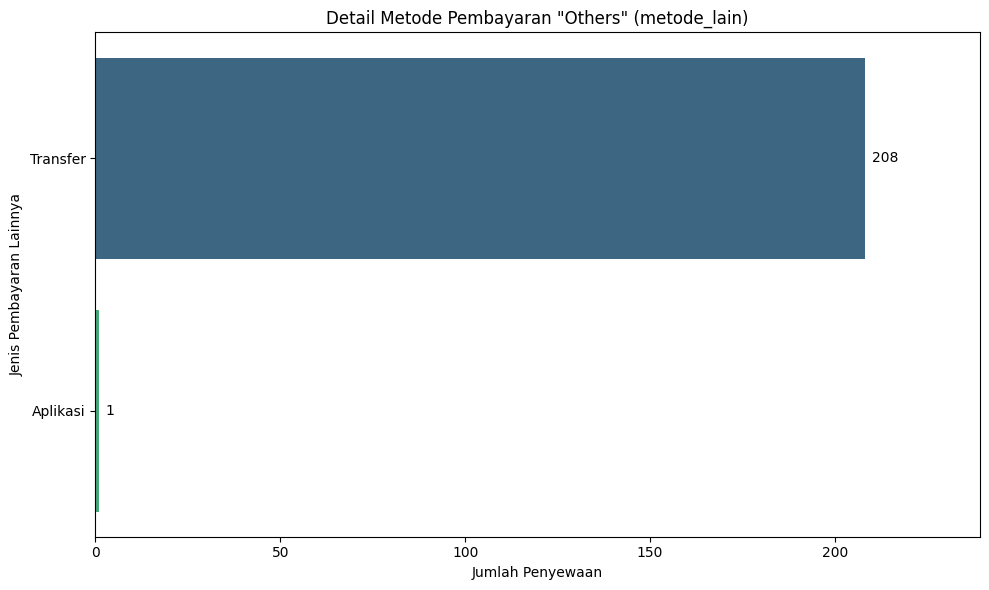

/tmp/ipykernel_1991/491046311.py:239: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  rentals['waktu_checkout_dt'] = pd.to_datetime(rentals['waktu_checkout'], errors='coerce')
/tmp/ipykernel_1991/491046311.py:242: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  rentals['waktu_checkin_dt'] = pd.to_datetime(rentals['waktu_checkin'], errors='coerce')



=== Proses Feature Selection ===

-> Fitur yang dipilih (4 terbaik): ['lama_menginap', 'checkout_hour', 'checkin_hour', 'metode_pembayaran']

===== Decision Tree =====
Classification Report:
              precision    recall  f1-score   support

           0     1.0000    0.9565    0.9778        92
           1     0.8095    1.0000    0.8947        17

    accuracy                         0.9633       109
   macro avg     0.9048    0.9783    0.9363       109
weighted avg     0.9703    0.9633    0.9648       109

Confusion Matrix (Text):
                Predicted
               0       1
          -----------------
True   0 |     88       4
       1 |      0      17
          -----------------


===== Random Forest =====
Classification Report:
              precision    recall  f1-score   support

           0     1.0000    0.9565    0.9778        92
           1     0.8095    1.0000    0.8947        17

    accuracy                         0.9633       109
   macro avg     0.9048    0

In [ ]:
# ============================================================
# DATA RIIL (TANPA TUNING) --> jumlah fitur = 4
# ============================================================

import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.pipeline import make_pipeline
from sklearn.feature_selection import SelectKBest, chi2, mutual_info_classif

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier

import matplotlib.pyplot as plt
import seaborn as sns

# ------------------------------------------------------------
# 1. LOAD DATA
# ------------------------------------------------------------
rentals    = pd.read_csv('rentals.csv')
logs       = pd.read_csv('rental_logs.csv')
# units      = pd.read_csv('units.csv')
# users      = pd.read_csv('users.csv')
# violations = pd.read_csv('violations.csv')

rentals.columns = rentals.columns.str.lower()

if 'komentar' not in rentals.columns:
    raise ValueError("Kolom 'komentar' tidak ditemukan di rentals.csv")

print("rentals.csv")
print(rentals.head())
print("logs.csv")
print(logs.head())


# ------------------------------------------------------------
# 2. LABELING
# ------------------------------------------------------------
rentals['komentar'] = rentals['komentar'].astype(str).str.lower().str.strip()
empty_values = ["", "nan", "na", "null", "-", "0", "tidak ada", "none", " "]
rentals['label'] = (~rentals['komentar'].isin(empty_values)).astype(int)


# ============================================================
# EXPLORATORY DATA ANALYSIS (EDA)
# ============================================================
print("\n" + "="*50)
print("=== EXPLORATORY DATA ANALYSIS (EDA) ===")
print("="*50)

df_eda = rentals.copy()

print("\n[1] Statistik Deskriptif:")
print(df_eda.describe(include='all'))

print("\n[2] Distribusi Kelas Target (0: Aman, 1: Melanggar):")
print(df_eda['label'].value_counts())

fig, ax = plt.subplots(figsize=(6, 4))
sns.countplot(data=df_eda, x='label', palette='Set2', ax=ax)
plt.title('Distribusi Kelas Klasifikasi (0: Aman, 1: Melanggar)')
plt.xlabel('Klasifikasi')
plt.ylabel('Jumlah Penyewaan')

y_max = df_eda['label'].value_counts().max()
plt.ylim(0, y_max * 1.15)

for p in ax.patches:
    if p.get_height() > 0:
        ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='baseline', fontsize=10, color='black', xytext=(0, 5),
                    textcoords='offset points')
plt.show()

kolom_dikecualikan = ['id', 'nama', 'nik', 'unit_number', 'tanggal_checkin', 'waktu_checkin',
                      'tanggal_checkout', 'waktu_checkout', 'komentar', 'user_email', 'diedit_oleh', 'created_at', 'metode_lain', 'classification']

semua_kategori = [col for col in df_eda.select_dtypes(include=['object', 'category']).columns if col not in kolom_dikecualikan]

print("\n[3] Rata-rata Pelanggaran Berdasarkan Seluruh Kategori:")
for col in semua_kategori:
    if col in df_eda.columns:
        print(f"\n--- Tingkat Pelanggaran Berdasarkan {col} ---")
        print(df_eda.groupby(col)['label'].mean().sort_values(ascending=False).round(3))

df_eda['lama_menginap_num'] = pd.to_numeric(df_eda['lama_menginap'], errors='coerce').fillna(0)
df_eda['checkin_hour_num'] = pd.to_datetime(df_eda['waktu_checkin'], errors='coerce').dt.hour.fillna(0)
df_eda['checkout_hour_num'] = pd.to_datetime(df_eda['waktu_checkout'], errors='coerce').dt.hour.fillna(0)

le_eda = LabelEncoder()
for c in semua_kategori:
    if c in df_eda.columns:
        df_eda[c + '_encoded'] = le_eda.fit_transform(df_eda[c].astype(str))

print("\n[4] Korelasi Antar Fitur:")
kolom_korelasi = ['lama_menginap_num', 'checkin_hour_num', 'checkout_hour_num', 'label']
kolom_korelasi += [c + '_encoded' for c in semua_kategori if c + '_encoded' in df_eda.columns]

corr_matrix = df_eda[kolom_korelasi].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Heatmap Korelasi Antar Fitur dan Target (Klasifikasi)')
plt.tight_layout()
plt.show()

print("\n[5] Visualisasi Pola Penyewaan (Dikaitkan dengan Klasifikasi):")

custom_line_palette = {0: 'blue', 1: 'red'}
custom_labels = ['0: Aman', '1: Melanggar']

fig, ax1 = plt.subplots(figsize=(12, 5))
waktu_df = df_eda.groupby(['checkin_hour_num', 'label']).size().reset_index(name='jumlah')

sns.lineplot(data=waktu_df, x='checkin_hour_num', y='jumlah', hue='label', marker='o', palette=custom_line_palette, ax=ax1)

plt.title('Pola Waktu Kedatangan Berdasarkan Klasifikasi')
plt.xlabel('Jam Check-in (0-23)')
plt.ylabel('Jumlah Penyewaan')
plt.xticks(range(0, 24))
plt.grid(True, alpha=0.3)

y_max_line = waktu_df['jumlah'].max()
plt.ylim(-y_max_line * 0.20, y_max_line * 1.15)

handles, _ = ax1.get_legend_handles_labels()
plt.legend(handles=handles, labels=custom_labels, title='Klasifikasi')

for l in waktu_df['label'].unique():
    sub = waktu_df[waktu_df['label'] == l]
    warna_teks = custom_line_palette[l]

    for x, y in zip(sub['checkin_hour_num'], sub['jumlah']):
        y_offset = 8 if l == 0 else -12
        va_align = 'bottom' if l == 0 else 'top'
        plt.annotate(f'{int(y)}', (x, y), textcoords="offset points", xytext=(0, y_offset),
                     ha='center', va=va_align, fontsize=9, color=warna_teks, fontweight='bold')
plt.show()

fig, ax2 = plt.subplots(figsize=(12, 5))
lama_df = df_eda.groupby(['lama_menginap_num', 'label']).size().reset_index(name='jumlah')

sns.lineplot(data=lama_df, x='lama_menginap_num', y='jumlah', hue='label', marker='o', palette=custom_line_palette, ax=ax2)

plt.title('Tren Lama Menginap Berdasarkan Klasifikasi')
plt.xlabel('Lama Menginap (Hari)')
plt.ylabel('Jumlah Penyewaan')
plt.grid(True, alpha=0.3)

handles2, _ = ax2.get_legend_handles_labels()
plt.legend(handles=handles2, labels=custom_labels, title='Klasifikasi')
plt.show()

for col in semua_kategori:
    if col in df_eda.columns:
        fig, ax = plt.subplots(figsize=(8, 5))
        sns.countplot(data=df_eda, x=col, hue='label', palette='magma', ax=ax)

        judul_kolom = col.replace('_', ' ').title()
        plt.title(f'Perbandingan Jumlah Pelanggaran Berdasarkan {judul_kolom}')
        plt.xlabel(judul_kolom)
        plt.ylabel('Jumlah Penyewaan')
        plt.xticks(rotation=0)

        handles_bar, _ = ax.get_legend_handles_labels()
        plt.legend(handles=handles_bar, labels=custom_labels, title='Klasifikasi')

        y_max_bar = df_eda.groupby([col, 'label']).size().max()
        plt.ylim(0, y_max_bar * 1.15)

        for p in ax.patches:
            if p.get_height() > 0:
                ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                            ha='center', va='baseline', fontsize=9, color='black', xytext=(0, 5),
                            textcoords='offset points')
        plt.tight_layout()
        plt.show()


print("\n[5b] Visualisasi Metode Pembayaran 'Others' (metode_lain):")

# Memastikan kolom 'metode_lain' berbentuk string dan membersihkan spasi/nilai kosong
df_eda['metode_lain'] = df_eda['metode_lain'].astype(str).str.strip().str.title()
empty_lain = ["", "Nan", "Na", "Null", "-", "0", "None"]

# Filter hanya baris yang memiliki nilai di 'metode_lain'
df_others = df_eda[~df_eda['metode_lain'].isin(empty_lain)]

if not df_others.empty:
    fig, ax = plt.subplots(figsize=(10, 6))

    # Menghitung frekuensi masing-masing metode pembayaran lain
    order_others = df_others['metode_lain'].value_counts().index

    sns.countplot(
        data=df_others,
        y='metode_lain',
        order=order_others,
        palette='viridis',
        ax=ax
    )

    plt.title('Detail Metode Pembayaran "Others" (metode_lain)')
    plt.xlabel('Jumlah Penyewaan')
    plt.ylabel('Jenis Pembayaran Lainnya')

    # Menambahkan anotasi angka di sebelah setiap bar
    for p in ax.patches:
        width = p.get_width()
        if width > 0:
            ax.annotate(f'{int(width)}',
                        (width, p.get_y() + p.get_height() / 2.),
                        ha='left', va='center', fontsize=10, color='black',
                        xytext=(5, 0), textcoords='offset points')

    # Perlebar batas x-axis sedikit agar angka anotasi tidak terpotong
    x_max = df_others['metode_lain'].value_counts().max()
    plt.xlim(0, x_max * 1.15)

    plt.tight_layout()
    plt.show()
else:
    print("Tidak ada data metode pembayaran 'Others' yang valid untuk ditampilkan.")


# ------------------------------------------------------------
# 3. FEATURE ENGINEERING & PREPARATION
# ------------------------------------------------------------
rentals['waktu_checkout_dt'] = pd.to_datetime(rentals['waktu_checkout'], errors='coerce')
rentals['checkout_hour'] = rentals['waktu_checkout_dt'].dt.hour.fillna(0).astype(int)

rentals['waktu_checkin_dt'] = pd.to_datetime(rentals['waktu_checkin'], errors='coerce')
rentals['checkin_hour'] = rentals['waktu_checkin_dt'].dt.hour.fillna(0).astype(int)

rentals['lama_menginap'] = pd.to_numeric(rentals['lama_menginap'], errors='coerce').fillna(0)

cat_cols = ['jenis_sewa', 'metode_pembayaran', 'status_pasutri', 'status_kewarganegaraan']
for c in cat_cols:
    rentals[c] = rentals[c].fillna('Unknown').astype(str)

numeric_cols = ['checkout_hour', 'checkin_hour', 'lama_menginap']
feature_cols = cat_cols + numeric_cols

X = rentals[feature_cols].copy()
y = rentals['label']

# ------------------------------------------------------------
# 4. TRAIN-TEST SPLIT
# ------------------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, stratify=y, test_size=0.2, random_state=42
)

# ------------------------------------------------------------
# 4B. ENCODING MENCEGAH DATA LEAKAGE
# ------------------------------------------------------------
label_encoders = {}

for c in cat_cols:
    le = LabelEncoder()
    X_train[c] = le.fit_transform(X_train[c])

    X_test[c] = X_test[c].map(lambda s: s if s in le.classes_ else 'Unknown')
    if 'Unknown' not in le.classes_:
        le.classes_ = np.append(le.classes_, 'Unknown')

    X_test[c] = le.transform(X_test[c])

    label_encoders[c] = le

# ------------------------------------------------------------
# 5. FEATURE SELECTION
# ------------------------------------------------------------
print("\n=== Proses Feature Selection ===")
chi2_selector = SelectKBest(score_func=chi2, k='all')
chi2_selector.fit(X_train, y_train)

train_df = X_train.copy()
train_df['label'] = y_train
pearson_scores = train_df.corr(method='pearson')['label'].drop('label').abs().values

mi_selector = SelectKBest(score_func=mutual_info_classif, k='all')
mi_selector.fit(X_train, y_train)

fs_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Chi-Square': chi2_selector.scores_,
    'Pearson (Abs)': pearson_scores,
    'Mutual Info': mi_selector.scores_
})

scaler = MinMaxScaler()
fs_df[['Chi2_Norm', 'Pearson_Norm', 'MI_Norm']] = scaler.fit_transform(
    fs_df[['Chi-Square', 'Pearson (Abs)', 'Mutual Info']]
)
fs_df['Total_Score'] = fs_df[['Chi2_Norm', 'Pearson_Norm', 'MI_Norm']].mean(axis=1)
fs_df = fs_df.sort_values(by='Total_Score', ascending=False).reset_index(drop=True)

# Jumlah Fitur
n_select = 4
selected_features = fs_df['Feature'].head(n_select).tolist()
print(f"\n-> Fitur yang dipilih ({n_select} terbaik): {selected_features}")

X_train = X_train[selected_features]
X_test = X_test[selected_features]

# ------------------------------------------------------------
# 6. Fungsi Evaluasi
# ------------------------------------------------------------
def evaluate(name, model):
    y_pred = model.predict(X_test)
    print(f"\n===== {name} =====")
    print("Classification Report:")
    print(classification_report(y_test, y_pred, digits=4))
    cm = confusion_matrix(y_test, y_pred)
    print("Confusion Matrix (Text):")
    print("                Predicted")
    print("               0       1")
    print("          -----------------")
    print(f"True   0 | {cm[0][0]:6d}  {cm[0][1]:6d}")
    print(f"       1 | {cm[1][0]:6d}  {cm[1][1]:6d}")
    print("          -----------------\n")

# ------------------------------------------------------------
# 7. Latih Semua Model (TANPA TUNING)
# ------------------------------------------------------------
models = {}
custom_weight = {0: 1, 1: 4}

# Model menggunakan pengaturan tetap
models["Decision Tree"] = DecisionTreeClassifier(max_depth=6, class_weight=custom_weight, random_state=42)
models["Random Forest"] = RandomForestClassifier(n_estimators=200, max_depth=7, class_weight=custom_weight, random_state=42)
models["KNN"] = make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=5, weights='distance'))
models["SVM RBF"] = make_pipeline(StandardScaler(), SVC(kernel='rbf', probability=True, class_weight=custom_weight, random_state=42))
models["XGBoost"] = XGBClassifier(n_estimators=200, max_depth=5, learning_rate=0.05, scale_pos_weight=4, eval_metric='logloss', random_state=42)

for name, model in models.items():
    model.fit(X_train, y_train)
    evaluate(name, model)

# ------------------------------------------------------------
# 8. Eksport Model Terbaik & Label Encoders
# ------------------------------------------------------------
print("\n=== Proses Export Model ===")

# Gabungkan model dan encoders ke dalam satu dictionary agar rapi
export_package = {
    'model': models["KNN"],
    'label_encoders': label_encoders,
    'selected_features': selected_features # Penting agar tahu urutan kolom masuk saat predict
}

# Menentukan nama file yang sesuai untuk KNN
filename = 'model_knn.pkl'

# Menyimpan package ke dalam file .pkl
joblib.dump(export_package, filename)
print(f"Sukses! Model dan Label Encoders telah disimpan sebagai file: {filename}")

rentals.csv
   id                   nama               nik status_pasutri  \
0   3  Novi Yanti Salsa Dewi  3204065911020004  Belum Menikah   
1   4     Amilia Nur Halimah  3520064903040001  Belum Menikah   
2   5     Achmad Agel Shahab  3525160508900001        Menikah   
3   6            Cries Wandi  1471051210920001  Belum Menikah   
4   7             SELO UTOMO  3171061909880002  Belum Menikah   

  status_kewarganegaraan jenis_sewa unit_number metode_pembayaran metode_lain  \
0                    WNI     Harian     B-20-27              Cash         NaN   
1                    WNI     Harian     A-15-25              Cash         NaN   
2                    WNI     Harian     A-06-24            Others    Aplikasi   
3                    WNI     Harian     D-15-21              QRIS         NaN   
4                    WNI     Harian       A-8-8            Others    Transfer   

  tanggal_checkin waktu_checkin tanggal_checkout waktu_checkout  \
0      2026-05-20      13:08:00       2026-

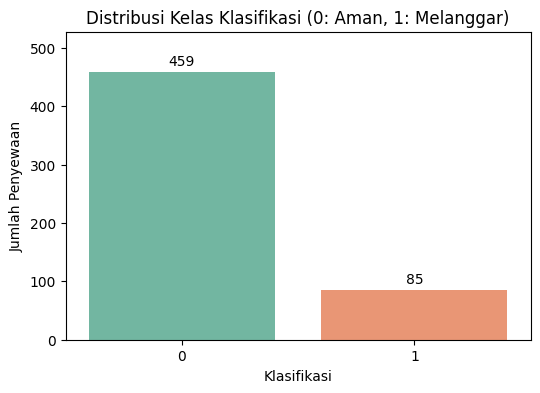


[3] Rata-rata Pelanggaran Berdasarkan Seluruh Kategori:

--- Tingkat Pelanggaran Berdasarkan status_pasutri ---
status_pasutri
Belum Menikah    0.164
Menikah          0.145
Name: label, dtype: float64

--- Tingkat Pelanggaran Berdasarkan status_kewarganegaraan ---
status_kewarganegaraan
WNI    0.156
Name: label, dtype: float64

--- Tingkat Pelanggaran Berdasarkan jenis_sewa ---
jenis_sewa
Harian     0.157
Bulanan    0.000
Name: label, dtype: float64

--- Tingkat Pelanggaran Berdasarkan metode_pembayaran ---
metode_pembayaran
Kartu Kredit    0.280
Others          0.158
Cash            0.150
QRIS            0.148
Kartu Debit     0.107
Name: label, dtype: float64

[4] Korelasi Antar Fitur:


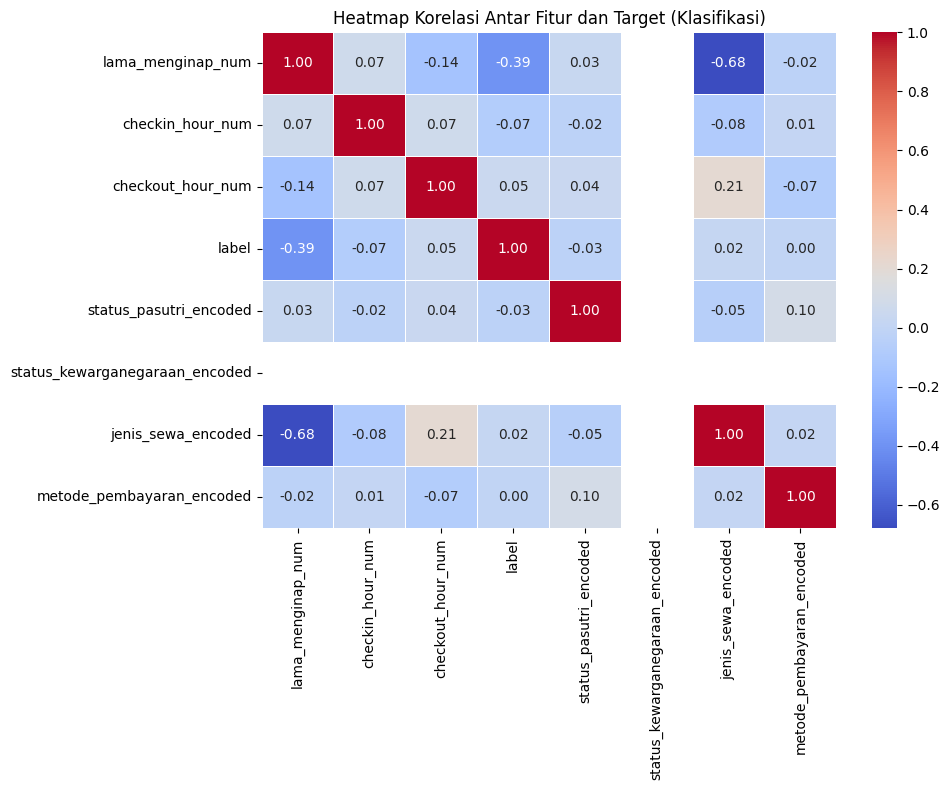


[5] Visualisasi Pola Penyewaan (Dikaitkan dengan Klasifikasi):


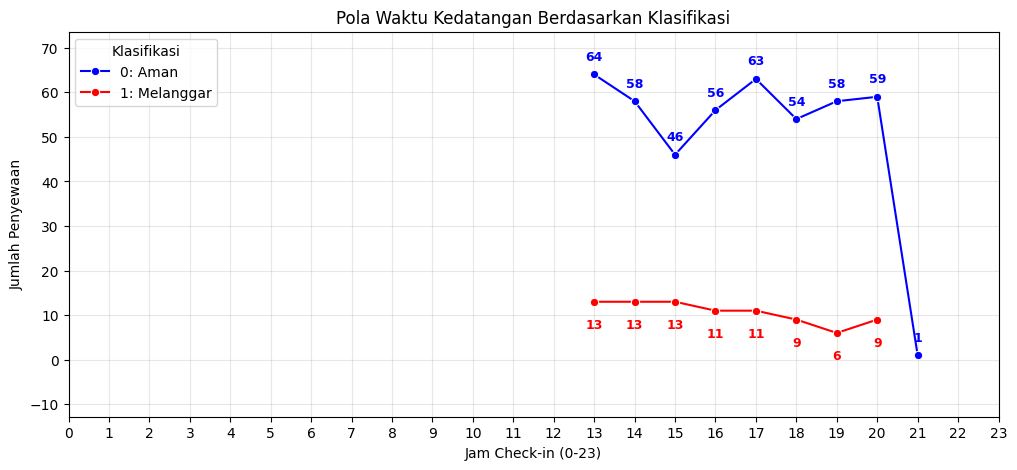

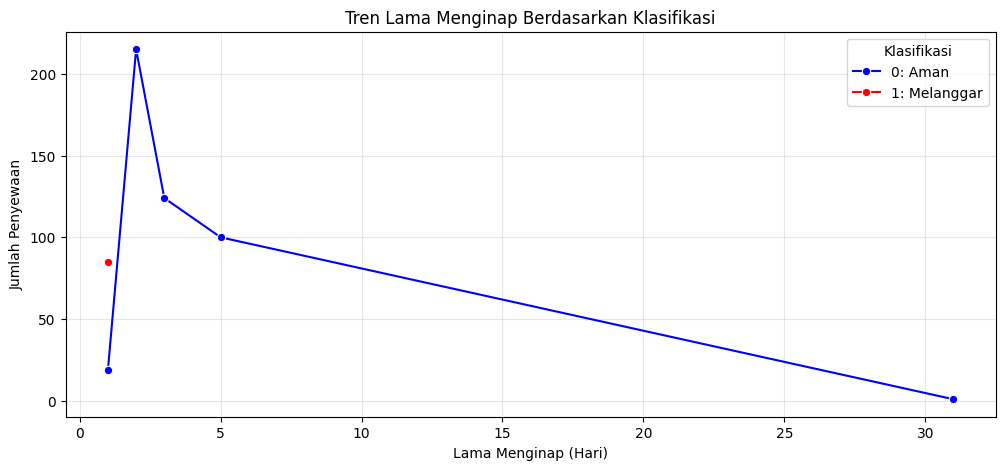

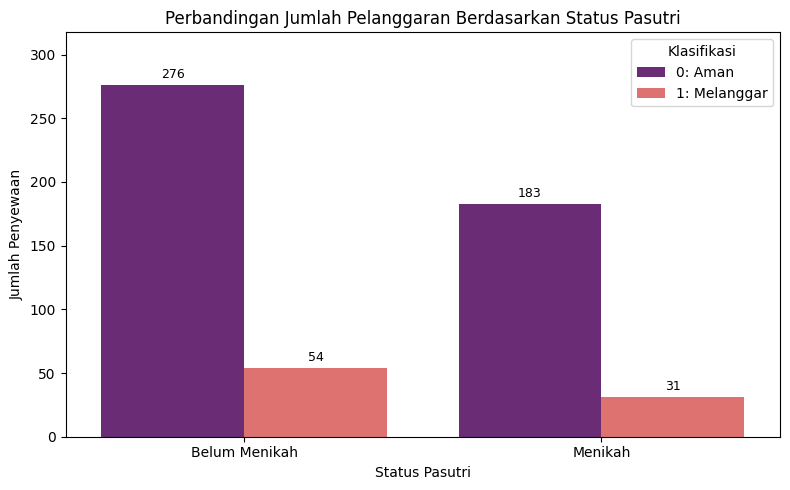

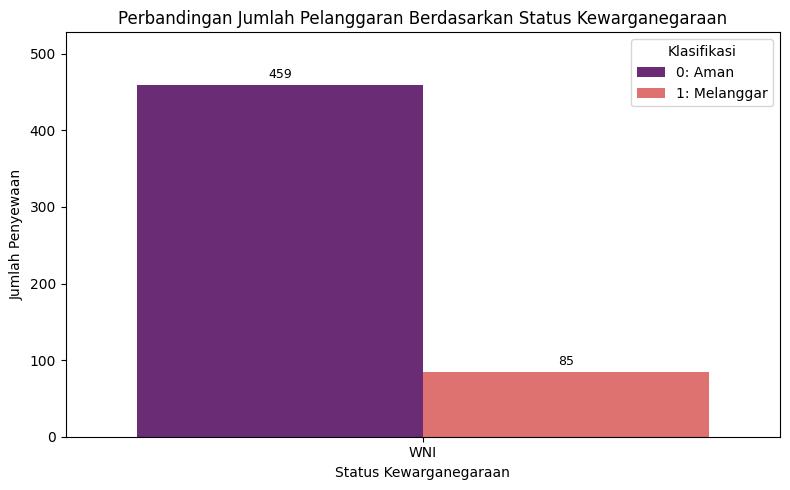

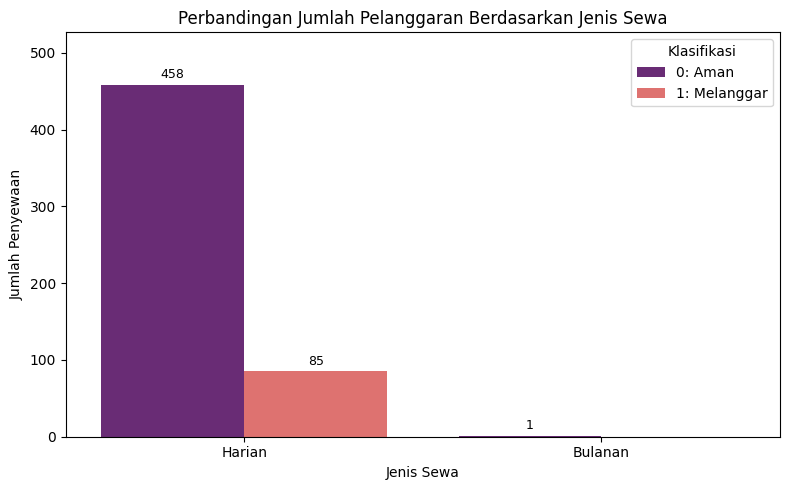

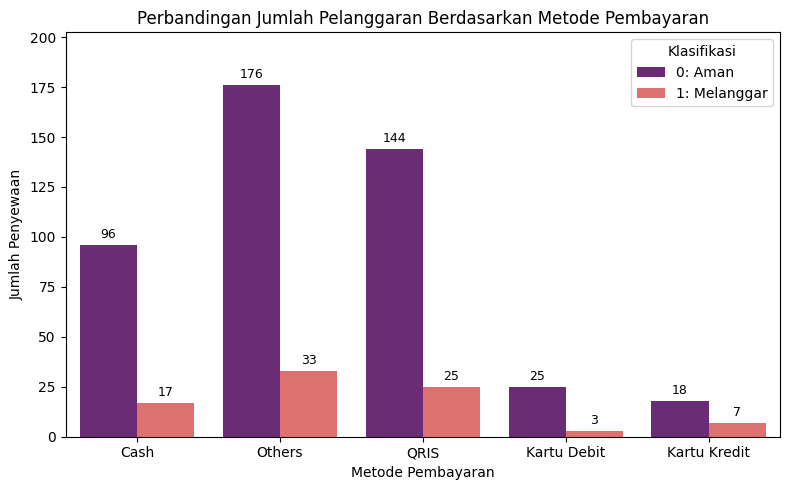


[5b] Visualisasi Metode Pembayaran 'Others' (metode_lain):


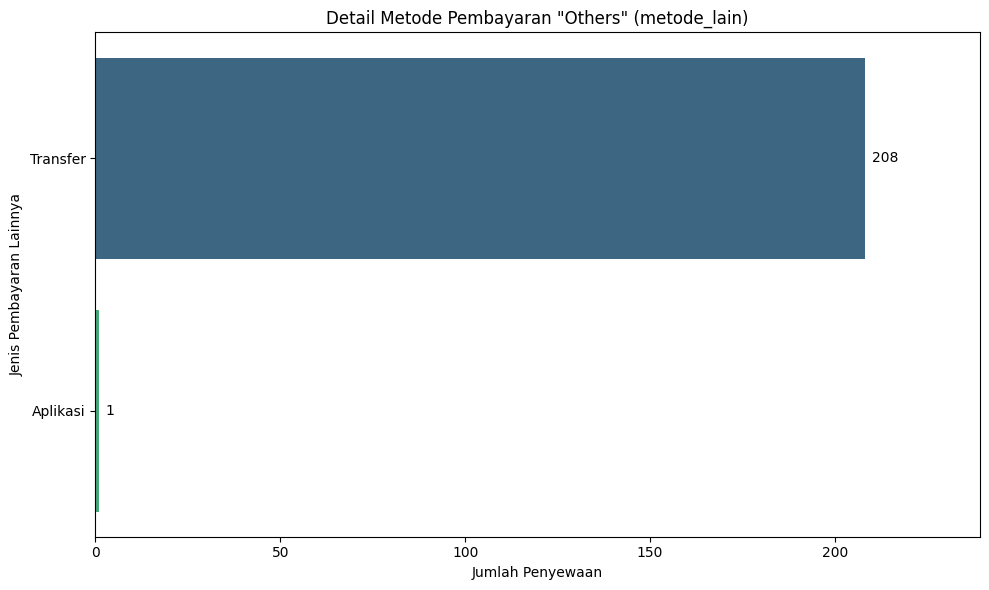


=== Proses Feature Selection ===

-> Fitur yang dipilih (3 terbaik): ['lama_menginap', 'checkout_hour', 'checkin_hour']

===== Decision Tree =====
Classification Report:
              precision    recall  f1-score   support

           0     1.0000    0.9565    0.9778        92
           1     0.8095    1.0000    0.8947        17

    accuracy                         0.9633       109
   macro avg     0.9048    0.9783    0.9363       109
weighted avg     0.9703    0.9633    0.9648       109

Confusion Matrix (Text):
                Predicted
               0       1
          -----------------
True   0 |     88       4
       1 |      0      17
          -----------------


===== Random Forest =====
Classification Report:
              precision    recall  f1-score   support

           0     0.9888    0.9565    0.9724        92
           1     0.8000    0.9412    0.8649        17

    accuracy                         0.9541       109
   macro avg     0.8944    0.9488    0.9186      

In [17]:
# ============================================================
# DATA RIIL (TANPA TUNING) --> jumlah fitur = 3
# ============================================================

import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.pipeline import make_pipeline
from sklearn.feature_selection import SelectKBest, chi2, mutual_info_classif

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier

import matplotlib.pyplot as plt
import seaborn as sns

# ------------------------------------------------------------
# 1. LOAD DATA
# ------------------------------------------------------------
rentals    = pd.read_csv('rentals.csv')
logs       = pd.read_csv('rental_logs.csv')
# units      = pd.read_csv('units.csv')
# users      = pd.read_csv('users.csv')
# violations = pd.read_csv('violations.csv')

rentals.columns = rentals.columns.str.lower()

if 'komentar' not in rentals.columns:
    raise ValueError("Kolom 'komentar' tidak ditemukan di rentals.csv")

print("rentals.csv")
print(rentals.head())
print("logs.csv")
print(logs.head())


# ------------------------------------------------------------
# 2. LABELING
# ------------------------------------------------------------
rentals['komentar'] = rentals['komentar'].astype(str).str.lower().str.strip()
empty_values = ["", "nan", "na", "null", "-", "0", "tidak ada", "none", " "]
rentals['label'] = (~rentals['komentar'].isin(empty_values)).astype(int)


# ============================================================
# EXPLORATORY DATA ANALYSIS (EDA)
# ============================================================
print("\n" + "="*50)
print("=== EXPLORATORY DATA ANALYSIS (EDA) ===")
print("="*50)

df_eda = rentals.copy()

print("\n[1] Statistik Deskriptif:")
print(df_eda.describe(include='all'))

print("\n[2] Distribusi Kelas Target (0: Aman, 1: Melanggar):")
print(df_eda['label'].value_counts())

fig, ax = plt.subplots(figsize=(6, 4))
sns.countplot(data=df_eda, x='label', palette='Set2', ax=ax)
plt.title('Distribusi Kelas Klasifikasi (0: Aman, 1: Melanggar)')
plt.xlabel('Klasifikasi')
plt.ylabel('Jumlah Penyewaan')

y_max = df_eda['label'].value_counts().max()
plt.ylim(0, y_max * 1.15)

for p in ax.patches:
    if p.get_height() > 0:
        ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='baseline', fontsize=10, color='black', xytext=(0, 5),
                    textcoords='offset points')
plt.show()

kolom_dikecualikan = ['id', 'nama', 'nik', 'unit_number', 'tanggal_checkin', 'waktu_checkin',
                      'tanggal_checkout', 'waktu_checkout', 'komentar', 'user_email', 'diedit_oleh', 'created_at', 'metode_lain', 'classification']

semua_kategori = [col for col in df_eda.select_dtypes(include=['object', 'category']).columns if col not in kolom_dikecualikan]

print("\n[3] Rata-rata Pelanggaran Berdasarkan Seluruh Kategori:")
for col in semua_kategori:
    if col in df_eda.columns:
        print(f"\n--- Tingkat Pelanggaran Berdasarkan {col} ---")
        print(df_eda.groupby(col)['label'].mean().sort_values(ascending=False).round(3))

df_eda['lama_menginap_num'] = pd.to_numeric(df_eda['lama_menginap'], errors='coerce').fillna(0)
df_eda['checkin_hour_num'] = pd.to_datetime(df_eda['waktu_checkin'], errors='coerce').dt.hour.fillna(0)
df_eda['checkout_hour_num'] = pd.to_datetime(df_eda['waktu_checkout'], errors='coerce').dt.hour.fillna(0)

le_eda = LabelEncoder()
for c in semua_kategori:
    if c in df_eda.columns:
        df_eda[c + '_encoded'] = le_eda.fit_transform(df_eda[c].astype(str))

print("\n[4] Korelasi Antar Fitur:")
kolom_korelasi = ['lama_menginap_num', 'checkin_hour_num', 'checkout_hour_num', 'label']
kolom_korelasi += [c + '_encoded' for c in semua_kategori if c + '_encoded' in df_eda.columns]

corr_matrix = df_eda[kolom_korelasi].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Heatmap Korelasi Antar Fitur dan Target (Klasifikasi)')
plt.tight_layout()
plt.show()

print("\n[5] Visualisasi Pola Penyewaan (Dikaitkan dengan Klasifikasi):")

custom_line_palette = {0: 'blue', 1: 'red'}
custom_labels = ['0: Aman', '1: Melanggar']

fig, ax1 = plt.subplots(figsize=(12, 5))
waktu_df = df_eda.groupby(['checkin_hour_num', 'label']).size().reset_index(name='jumlah')

sns.lineplot(data=waktu_df, x='checkin_hour_num', y='jumlah', hue='label', marker='o', palette=custom_line_palette, ax=ax1)

plt.title('Pola Waktu Kedatangan Berdasarkan Klasifikasi')
plt.xlabel('Jam Check-in (0-23)')
plt.ylabel('Jumlah Penyewaan')
plt.xticks(range(0, 24))
plt.grid(True, alpha=0.3)

y_max_line = waktu_df['jumlah'].max()
plt.ylim(-y_max_line * 0.20, y_max_line * 1.15)

handles, _ = ax1.get_legend_handles_labels()
plt.legend(handles=handles, labels=custom_labels, title='Klasifikasi')

for l in waktu_df['label'].unique():
    sub = waktu_df[waktu_df['label'] == l]
    warna_teks = custom_line_palette[l]

    for x, y in zip(sub['checkin_hour_num'], sub['jumlah']):
        y_offset = 8 if l == 0 else -12
        va_align = 'bottom' if l == 0 else 'top'
        plt.annotate(f'{int(y)}', (x, y), textcoords="offset points", xytext=(0, y_offset),
                     ha='center', va=va_align, fontsize=9, color=warna_teks, fontweight='bold')
plt.show()

fig, ax2 = plt.subplots(figsize=(12, 5))
lama_df = df_eda.groupby(['lama_menginap_num', 'label']).size().reset_index(name='jumlah')

sns.lineplot(data=lama_df, x='lama_menginap_num', y='jumlah', hue='label', marker='o', palette=custom_line_palette, ax=ax2)

plt.title('Tren Lama Menginap Berdasarkan Klasifikasi')
plt.xlabel('Lama Menginap (Hari)')
plt.ylabel('Jumlah Penyewaan')
plt.grid(True, alpha=0.3)

handles2, _ = ax2.get_legend_handles_labels()
plt.legend(handles=handles2, labels=custom_labels, title='Klasifikasi')
plt.show()

for col in semua_kategori:
    if col in df_eda.columns:
        fig, ax = plt.subplots(figsize=(8, 5))
        sns.countplot(data=df_eda, x=col, hue='label', palette='magma', ax=ax)

        judul_kolom = col.replace('_', ' ').title()
        plt.title(f'Perbandingan Jumlah Pelanggaran Berdasarkan {judul_kolom}')
        plt.xlabel(judul_kolom)
        plt.ylabel('Jumlah Penyewaan')
        plt.xticks(rotation=0)

        handles_bar, _ = ax.get_legend_handles_labels()
        plt.legend(handles=handles_bar, labels=custom_labels, title='Klasifikasi')

        y_max_bar = df_eda.groupby([col, 'label']).size().max()
        plt.ylim(0, y_max_bar * 1.15)

        for p in ax.patches:
            if p.get_height() > 0:
                ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                            ha='center', va='baseline', fontsize=9, color='black', xytext=(0, 5),
                            textcoords='offset points')
        plt.tight_layout()
        plt.show()


print("\n[5b] Visualisasi Metode Pembayaran 'Others' (metode_lain):")

# Memastikan kolom 'metode_lain' berbentuk string dan membersihkan spasi/nilai kosong
df_eda['metode_lain'] = df_eda['metode_lain'].astype(str).str.strip().str.title()
empty_lain = ["", "Nan", "Na", "Null", "-", "0", "None"]

# Filter hanya baris yang memiliki nilai di 'metode_lain'
df_others = df_eda[~df_eda['metode_lain'].isin(empty_lain)]

if not df_others.empty:
    fig, ax = plt.subplots(figsize=(10, 6))

    # Menghitung frekuensi masing-masing metode pembayaran lain
    order_others = df_others['metode_lain'].value_counts().index

    sns.countplot(
        data=df_others,
        y='metode_lain',
        order=order_others,
        palette='viridis',
        ax=ax
    )

    plt.title('Detail Metode Pembayaran "Others" (metode_lain)')
    plt.xlabel('Jumlah Penyewaan')
    plt.ylabel('Jenis Pembayaran Lainnya')

    # Menambahkan anotasi angka di sebelah setiap bar
    for p in ax.patches:
        width = p.get_width()
        if width > 0:
            ax.annotate(f'{int(width)}',
                        (width, p.get_y() + p.get_height() / 2.),
                        ha='left', va='center', fontsize=10, color='black',
                        xytext=(5, 0), textcoords='offset points')

    # Perlebar batas x-axis sedikit agar angka anotasi tidak terpotong
    x_max = df_others['metode_lain'].value_counts().max()
    plt.xlim(0, x_max * 1.15)

    plt.tight_layout()
    plt.show()
else:
    print("Tidak ada data metode pembayaran 'Others' yang valid untuk ditampilkan.")


# ------------------------------------------------------------
# 3. FEATURE ENGINEERING & PREPARATION
# ------------------------------------------------------------
rentals['waktu_checkout_dt'] = pd.to_datetime(rentals['waktu_checkout'], errors='coerce')
rentals['checkout_hour'] = rentals['waktu_checkout_dt'].dt.hour.fillna(0).astype(int)

rentals['waktu_checkin_dt'] = pd.to_datetime(rentals['waktu_checkin'], errors='coerce')
rentals['checkin_hour'] = rentals['waktu_checkin_dt'].dt.hour.fillna(0).astype(int)

rentals['lama_menginap'] = pd.to_numeric(rentals['lama_menginap'], errors='coerce').fillna(0)

cat_cols = ['jenis_sewa', 'metode_pembayaran', 'status_pasutri', 'status_kewarganegaraan']
for c in cat_cols:
    rentals[c] = rentals[c].fillna('Unknown').astype(str)

numeric_cols = ['checkout_hour', 'checkin_hour', 'lama_menginap']
feature_cols = cat_cols + numeric_cols

X = rentals[feature_cols].copy()
y = rentals['label']

# ------------------------------------------------------------
# 4. TRAIN-TEST SPLIT
# ------------------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, stratify=y, test_size=0.2, random_state=42
)

# ------------------------------------------------------------
# 4B. ENCODING MENCEGAH DATA LEAKAGE
# ------------------------------------------------------------
label_encoders = {}

for c in cat_cols:
    le = LabelEncoder()
    X_train[c] = le.fit_transform(X_train[c])

    X_test[c] = X_test[c].map(lambda s: s if s in le.classes_ else 'Unknown')
    if 'Unknown' not in le.classes_:
        le.classes_ = np.append(le.classes_, 'Unknown')

    X_test[c] = le.transform(X_test[c])

    label_encoders[c] = le

# ------------------------------------------------------------
# 5. FEATURE SELECTION
# ------------------------------------------------------------
print("\n=== Proses Feature Selection ===")
chi2_selector = SelectKBest(score_func=chi2, k='all')
chi2_selector.fit(X_train, y_train)

train_df = X_train.copy()
train_df['label'] = y_train
pearson_scores = train_df.corr(method='pearson')['label'].drop('label').abs().values

mi_selector = SelectKBest(score_func=mutual_info_classif, k='all')
mi_selector.fit(X_train, y_train)

fs_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Chi-Square': chi2_selector.scores_,
    'Pearson (Abs)': pearson_scores,
    'Mutual Info': mi_selector.scores_
})

scaler = MinMaxScaler()
fs_df[['Chi2_Norm', 'Pearson_Norm', 'MI_Norm']] = scaler.fit_transform(
    fs_df[['Chi-Square', 'Pearson (Abs)', 'Mutual Info']]
)
fs_df['Total_Score'] = fs_df[['Chi2_Norm', 'Pearson_Norm', 'MI_Norm']].mean(axis=1)
fs_df = fs_df.sort_values(by='Total_Score', ascending=False).reset_index(drop=True)

# Jumlah Fitur
n_select = 3
selected_features = fs_df['Feature'].head(n_select).tolist()
print(f"\n-> Fitur yang dipilih ({n_select} terbaik): {selected_features}")

X_train = X_train[selected_features]
X_test = X_test[selected_features]

# ------------------------------------------------------------
# 6. Fungsi Evaluasi
# ------------------------------------------------------------
def evaluate(name, model):
    y_pred = model.predict(X_test)
    print(f"\n===== {name} =====")
    print("Classification Report:")
    print(classification_report(y_test, y_pred, digits=4))

    cm = confusion_matrix(y_test, y_pred)

    # --------------------------------------------------------
    # Confusion Matrix (Text Base)
    # --------------------------------------------------------
    print("Confusion Matrix (Text):")
    print("                Predicted")
    print("               0       1")
    print("          -----------------")
    print(f"True   0 | {cm[0][0]:6d}  {cm[0][1]:6d}")
    print(f"       1 | {cm[1][0]:6d}  {cm[1][1]:6d}")
    print("          -----------------\n")

    # # --------------------------------------------------------
    # # Confusion Matrix (Gambar / Visualisasi)
    # # --------------------------------------------------------
    # plt.figure(figsize=(5, 4))
    # sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
    #             xticklabels=['0 (Aman)', '1 (Melanggar)'],
    #             yticklabels=['0 (Aman)', '1 (Melanggar)'])

    # plt.title(f'Confusion Matrix - {name}')
    # plt.xlabel('Predicted Label')
    # plt.ylabel('True Label')
    # plt.tight_layout()
    # plt.show()

# ------------------------------------------------------------
# 7. Latih Semua Model (TANPA TUNING)
# ------------------------------------------------------------
models = {}
custom_weight = {0: 1, 1: 4}

# Model menggunakan pengaturan tetap
models["Decision Tree"] = DecisionTreeClassifier(max_depth=6, class_weight=custom_weight, random_state=42)
models["Random Forest"] = RandomForestClassifier(n_estimators=200, max_depth=7, class_weight=custom_weight, random_state=42)
models["KNN"] = make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=5, weights='distance'))
models["SVM RBF"] = make_pipeline(StandardScaler(), SVC(kernel='rbf', probability=True, class_weight=custom_weight, random_state=42))
models["XGBoost"] = XGBClassifier(n_estimators=200, max_depth=5, learning_rate=0.05, scale_pos_weight=4, eval_metric='logloss', random_state=42)

for name, model in models.items():
    model.fit(X_train, y_train)
    evaluate(name, model)

# ------------------------------------------------------------
# 8. Eksport Model Terbaik & Label Encoders
# ------------------------------------------------------------
print("\n=== Proses Export Model ===")

# Gabungkan model dan encoders ke dalam satu dictionary agar rapi
export_package = {
    'model': models["KNN"],
    'label_encoders': label_encoders,
    'selected_features': selected_features # Penting agar tahu urutan kolom masuk saat predict
}

# Menentukan nama file yang sesuai untuk KNN
filename = 'model_knn.pkl'

# Menyimpan package ke dalam file .pkl
joblib.dump(export_package, filename)
print(f"Sukses! Model dan Label Encoders telah disimpan sebagai file: {filename}")

renatls.csv
   id                   nama               nik status_pasutri  \
0   3  Novi Yanti Salsa Dewi  3204065911020004  Belum Menikah   
1   4     Amilia Nur Halimah  3520064903040001  Belum Menikah   
2   5     Achmad Agel Shahab  3525160508900001        Menikah   
3   6            Cries Wandi  1471051210920001  Belum Menikah   
4   7             SELO UTOMO  3171061909880002  Belum Menikah   

  status_kewarganegaraan jenis_sewa unit_number metode_pembayaran metode_lain  \
0                    WNI     Harian     B-20-27              Cash         NaN   
1                    WNI     Harian     A-15-25              Cash         NaN   
2                    WNI     Harian     A-06-24            Others    Aplikasi   
3                    WNI     Harian     D-15-21              QRIS         NaN   
4                    WNI     Harian       A-8-8            Others    Transfer   

  tanggal_checkin waktu_checkin tanggal_checkout waktu_checkout  \
0      2026-05-20      13:08:00       2026-

/tmp/ipykernel_4832/252262949.py:68: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_eda, x='label', palette='Set2', ax=ax)


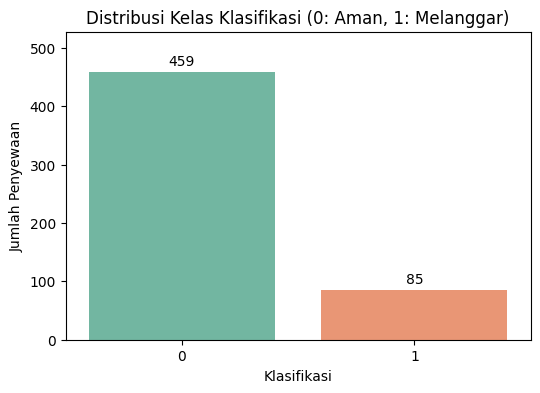


[3] Rata-rata Pelanggaran Berdasarkan Seluruh Kategori:

--- Tingkat Pelanggaran Berdasarkan status_pasutri ---
status_pasutri
Belum Menikah    0.164
Menikah          0.145
Name: label, dtype: float64

--- Tingkat Pelanggaran Berdasarkan status_kewarganegaraan ---
status_kewarganegaraan
WNI    0.156
Name: label, dtype: float64

--- Tingkat Pelanggaran Berdasarkan jenis_sewa ---
jenis_sewa
Harian     0.157
Bulanan    0.000
Name: label, dtype: float64

--- Tingkat Pelanggaran Berdasarkan metode_pembayaran ---
metode_pembayaran
Kartu Kredit    0.280
Others          0.158
Cash            0.150
QRIS            0.148
Kartu Debit     0.107
Name: label, dtype: float64

[4] Korelasi Antar Fitur:


/tmp/ipykernel_4832/252262949.py:95: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_eda['checkin_hour_num'] = pd.to_datetime(df_eda['waktu_checkin'], errors='coerce').dt.hour.fillna(0)
/tmp/ipykernel_4832/252262949.py:96: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_eda['checkout_hour_num'] = pd.to_datetime(df_eda['waktu_checkout'], errors='coerce').dt.hour.fillna(0)


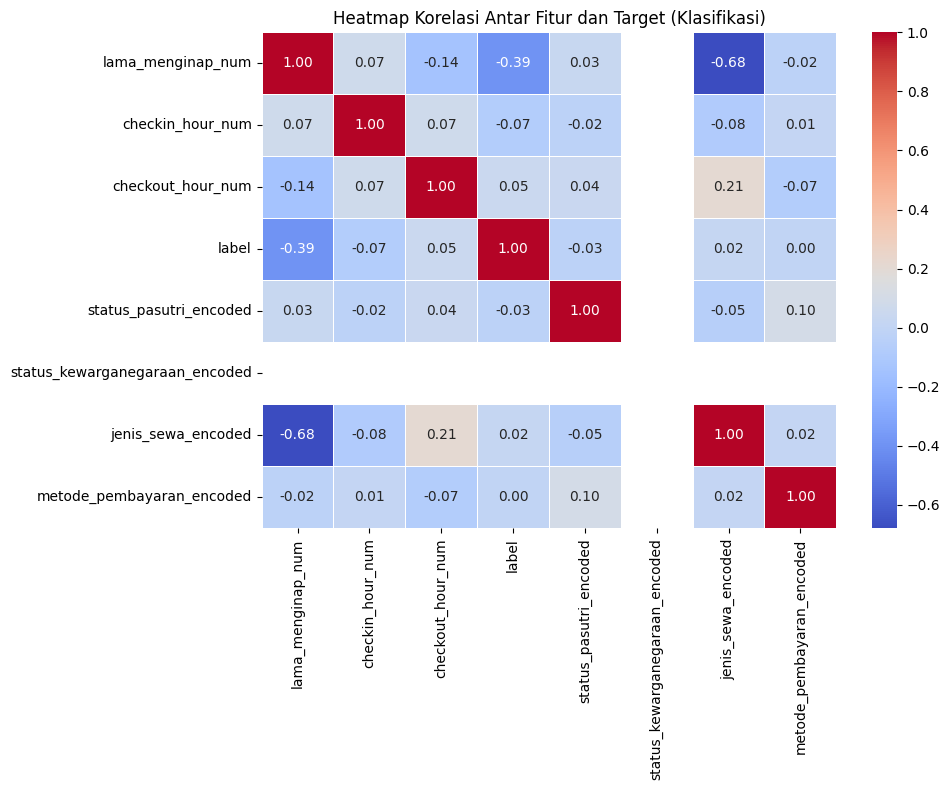


[5] Visualisasi Pola Penyewaan (Dikaitkan dengan Klasifikasi):


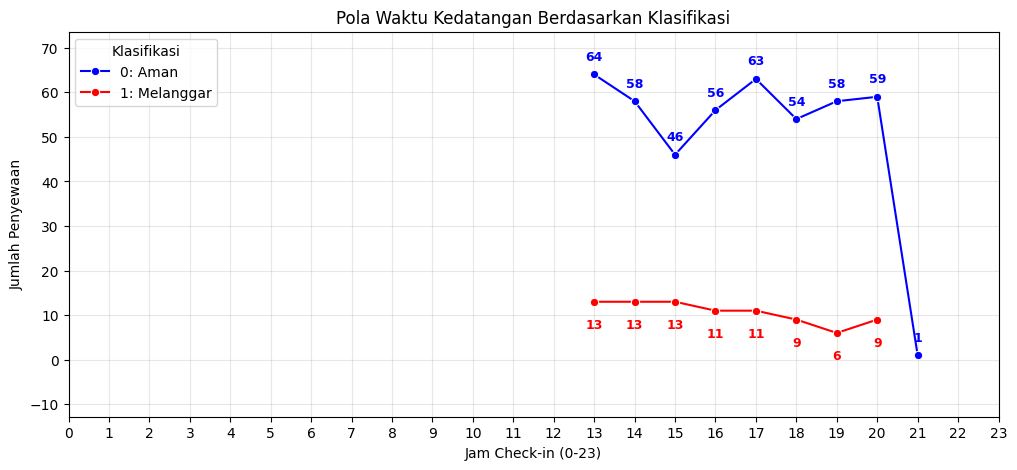

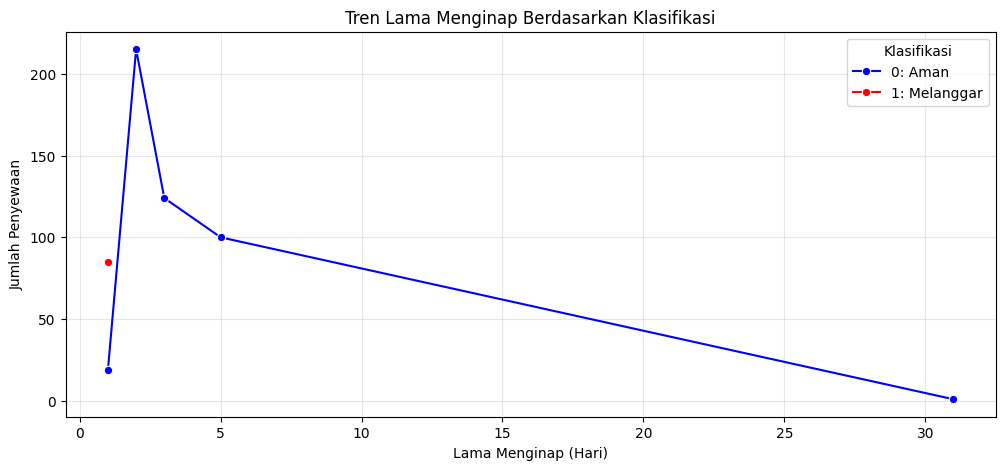

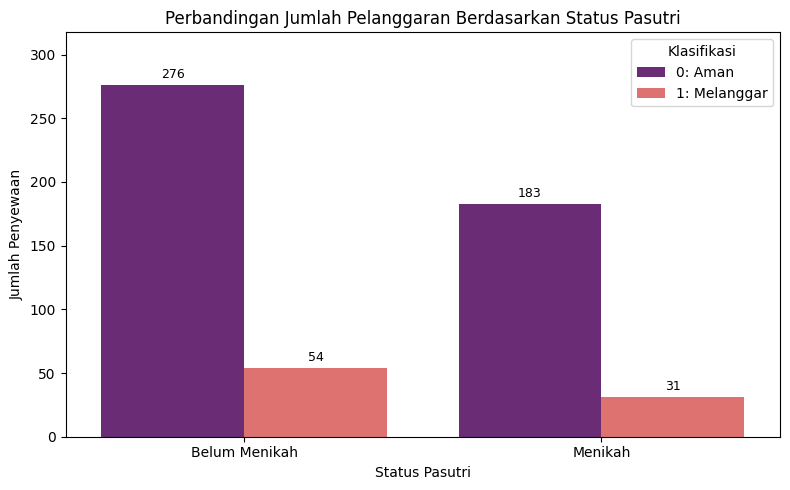

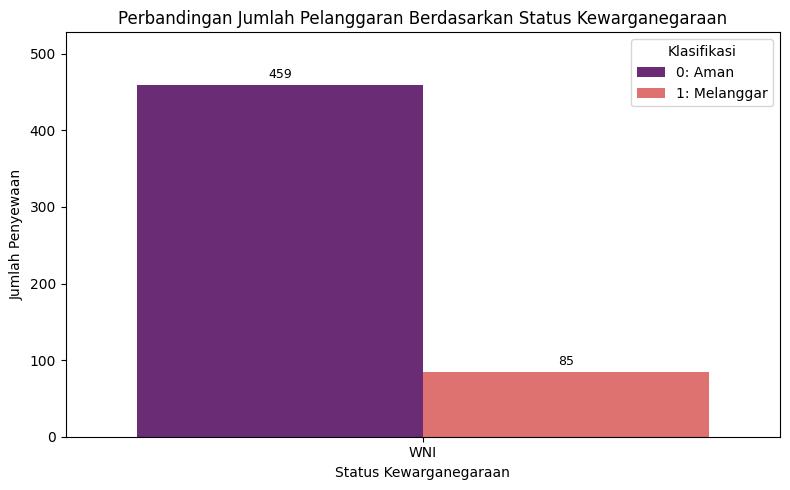

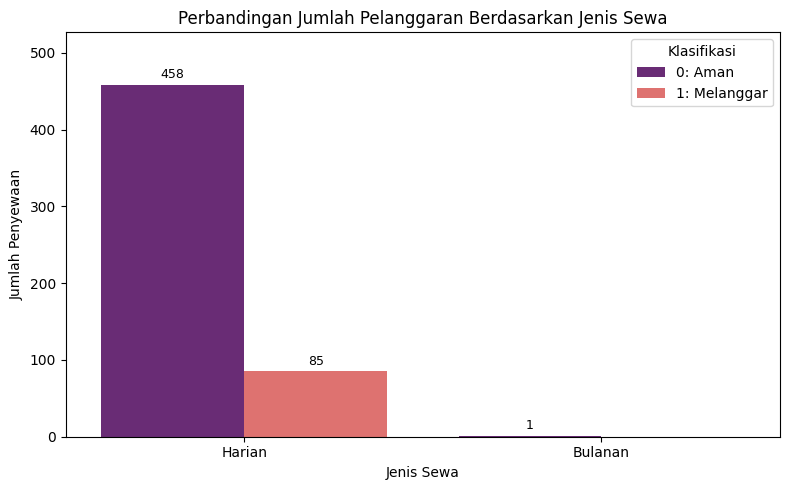

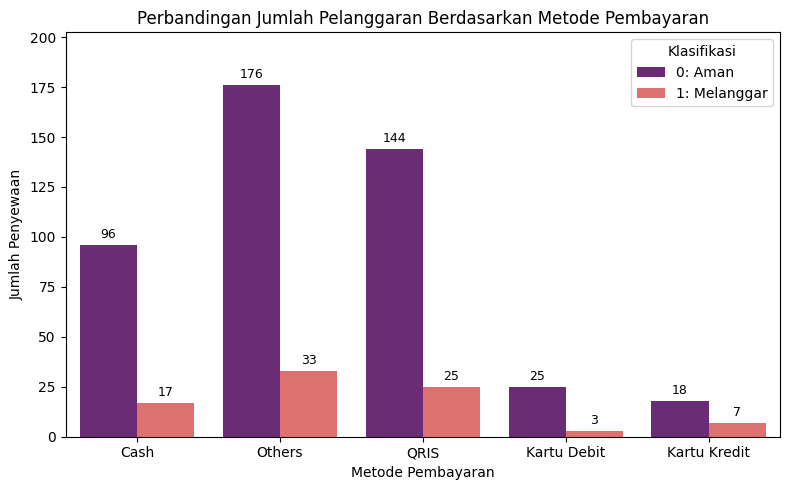


[5b] Visualisasi Metode Pembayaran 'Others' (metode_lain):


/tmp/ipykernel_4832/252262949.py:203: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


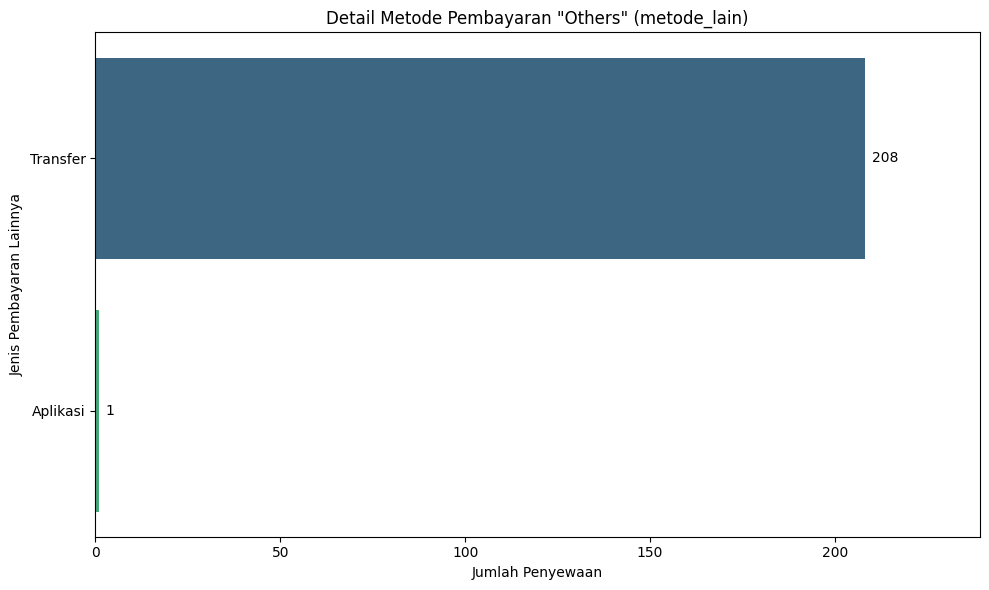

/tmp/ipykernel_4832/252262949.py:238: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  rentals['waktu_checkout_dt'] = pd.to_datetime(rentals['waktu_checkout'], errors='coerce')
/tmp/ipykernel_4832/252262949.py:242: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  rentals['waktu_checkin_dt'] = pd.to_datetime(rentals['waktu_checkin'], errors='coerce')



=== Proses Feature Selection ===

-> Fitur yang dipilih (4 terbaik): ['lama_menginap', 'checkout_hour', 'checkin_hour', 'metode_pembayaran']

Memulai proses Hyperparameter Tuning untuk semua model. Ini mungkin memakan waktu...

>> Tuning Decision Tree...
>> Tuning Random Forest...
>> Tuning KNN...
>> Tuning SVM...
>> Tuning XGBoost...

===== Decision Tree (Tuned) =====
Classification Report:
              precision    recall  f1-score   support

           0     1.0000    0.9565    0.9778        92
           1     0.8095    1.0000    0.8947        17

    accuracy                         0.9633       109
   macro avg     0.9048    0.9783    0.9363       109
weighted avg     0.9703    0.9633    0.9648       109

Confusion Matrix (Text):
                Predicted
               0       1
          -----------------
True   0 |     88       4
       1 |      0      17
          -----------------


===== Random Forest (Tuned) =====
Classification Report:
              precision    recall 

In [ ]:
# ============================================================
# DATA RIIL + Tunning --> jumlah fitur = 4
# ============================================================

import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.pipeline import make_pipeline
from sklearn.feature_selection import SelectKBest, chi2, mutual_info_classif

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier

# ------------------------------------------------------------
# 1. LOAD DATA
# ------------------------------------------------------------
rentals   = pd.read_csv('rentals.csv')
logs      = pd.read_csv('rental_logs.csv')
# units     = pd.read_csv('units.csv')
# users     = pd.read_csv('users.csv')
# violations= pd.read_csv('violations.csv')

rentals.columns = rentals.columns.str.lower()

if 'komentar' not in rentals.columns:
    raise ValueError("Kolom 'komentar' tidak ditemukan di rentals.csv")

print("renatls.csv")
print(rentals.head())
print("logs.csv")
print(logs.head())


# ------------------------------------------------------------
# 2. LABELING
# ------------------------------------------------------------
rentals['komentar'] = rentals['komentar'].astype(str).str.lower().str.strip()
empty_values = ["", "nan", "na", "null", "-", "0", "tidak ada", "none", " "]
rentals['label'] = (~rentals['komentar'].isin(empty_values)).astype(int)



# ============================================================
# EXPLORATORY DATA ANALYSIS (EDA)
# ============================================================
print("\n" + "="*50)
print("=== EXPLORATORY DATA ANALYSIS (EDA) ===")
print("="*50)

df_eda = rentals.copy()

print("\n[1] Statistik Deskriptif:")
print(df_eda.describe(include='all'))

print("\n[2] Distribusi Kelas Target (0: Aman, 1: Melanggar):")
print(df_eda['label'].value_counts())

fig, ax = plt.subplots(figsize=(6, 4))
sns.countplot(data=df_eda, x='label', palette='Set2', ax=ax)
plt.title('Distribusi Kelas Klasifikasi (0: Aman, 1: Melanggar)')
plt.xlabel('Klasifikasi')
plt.ylabel('Jumlah Penyewaan')

y_max = df_eda['label'].value_counts().max()
plt.ylim(0, y_max * 1.15)

for p in ax.patches:
    if p.get_height() > 0:
        ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='baseline', fontsize=10, color='black', xytext=(0, 5),
                    textcoords='offset points')
plt.show()

kolom_dikecualikan = ['id', 'nama', 'nik', 'unit_number', 'tanggal_checkin', 'waktu_checkin',
                      'tanggal_checkout', 'waktu_checkout', 'komentar', 'user_email', 'diedit_oleh', 'created_at', 'metode_lain', 'classification']

semua_kategori = [col for col in df_eda.select_dtypes(include=['object', 'category']).columns if col not in kolom_dikecualikan]

print("\n[3] Rata-rata Pelanggaran Berdasarkan Seluruh Kategori:")
for col in semua_kategori:
    if col in df_eda.columns:
        print(f"\n--- Tingkat Pelanggaran Berdasarkan {col} ---")
        print(df_eda.groupby(col)['label'].mean().sort_values(ascending=False).round(3))

df_eda['lama_menginap_num'] = pd.to_numeric(df_eda['lama_menginap'], errors='coerce').fillna(0)
df_eda['checkin_hour_num'] = pd.to_datetime(df_eda['waktu_checkin'], errors='coerce').dt.hour.fillna(0)
df_eda['checkout_hour_num'] = pd.to_datetime(df_eda['waktu_checkout'], errors='coerce').dt.hour.fillna(0)

le_eda = LabelEncoder()
for c in semua_kategori:
    if c in df_eda.columns:
        df_eda[c + '_encoded'] = le_eda.fit_transform(df_eda[c].astype(str))

print("\n[4] Korelasi Antar Fitur:")
kolom_korelasi = ['lama_menginap_num', 'checkin_hour_num', 'checkout_hour_num', 'label']
kolom_korelasi += [c + '_encoded' for c in semua_kategori if c + '_encoded' in df_eda.columns]

corr_matrix = df_eda[kolom_korelasi].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Heatmap Korelasi Antar Fitur dan Target (Klasifikasi)')
plt.tight_layout()
plt.show()

print("\n[5] Visualisasi Pola Penyewaan (Dikaitkan dengan Klasifikasi):")

custom_line_palette = {0: 'blue', 1: 'red'}
custom_labels = ['0: Aman', '1: Melanggar']

fig, ax1 = plt.subplots(figsize=(12, 5))
waktu_df = df_eda.groupby(['checkin_hour_num', 'label']).size().reset_index(name='jumlah')

sns.lineplot(data=waktu_df, x='checkin_hour_num', y='jumlah', hue='label', marker='o', palette=custom_line_palette, ax=ax1)

plt.title('Pola Waktu Kedatangan Berdasarkan Klasifikasi')
plt.xlabel('Jam Check-in (0-23)')
plt.ylabel('Jumlah Penyewaan')
plt.xticks(range(0, 24))
plt.grid(True, alpha=0.3)

y_max_line = waktu_df['jumlah'].max()
plt.ylim(-y_max_line * 0.20, y_max_line * 1.15)

handles, _ = ax1.get_legend_handles_labels()
plt.legend(handles=handles, labels=custom_labels, title='Klasifikasi')

for l in waktu_df['label'].unique():
    sub = waktu_df[waktu_df['label'] == l]
    warna_teks = custom_line_palette[l]

    for x, y in zip(sub['checkin_hour_num'], sub['jumlah']):
        y_offset = 8 if l == 0 else -12
        va_align = 'bottom' if l == 0 else 'top'
        plt.annotate(f'{int(y)}', (x, y), textcoords="offset points", xytext=(0, y_offset),
                     ha='center', va=va_align, fontsize=9, color=warna_teks, fontweight='bold')
plt.show()

fig, ax2 = plt.subplots(figsize=(12, 5))
lama_df = df_eda.groupby(['lama_menginap_num', 'label']).size().reset_index(name='jumlah')

sns.lineplot(data=lama_df, x='lama_menginap_num', y='jumlah', hue='label', marker='o', palette=custom_line_palette, ax=ax2)

plt.title('Tren Lama Menginap Berdasarkan Klasifikasi')
plt.xlabel('Lama Menginap (Hari)')
plt.ylabel('Jumlah Penyewaan')
plt.grid(True, alpha=0.3)

handles2, _ = ax2.get_legend_handles_labels()
plt.legend(handles=handles2, labels=custom_labels, title='Klasifikasi')
plt.show()

for col in semua_kategori:
    if col in df_eda.columns:
        fig, ax = plt.subplots(figsize=(8, 5))
        sns.countplot(data=df_eda, x=col, hue='label', palette='magma', ax=ax)

        judul_kolom = col.replace('_', ' ').title()
        plt.title(f'Perbandingan Jumlah Pelanggaran Berdasarkan {judul_kolom}')
        plt.xlabel(judul_kolom)
        plt.ylabel('Jumlah Penyewaan')
        plt.xticks(rotation=0)

        handles_bar, _ = ax.get_legend_handles_labels()
        plt.legend(handles=handles_bar, labels=custom_labels, title='Klasifikasi')

        y_max_bar = df_eda.groupby([col, 'label']).size().max()
        plt.ylim(0, y_max_bar * 1.15)

        for p in ax.patches:
            if p.get_height() > 0:
                ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                            ha='center', va='baseline', fontsize=9, color='black', xytext=(0, 5),
                            textcoords='offset points')
        plt.tight_layout()
        plt.show()


print("\n[5b] Visualisasi Metode Pembayaran 'Others' (metode_lain):")

# Memastikan kolom 'metode_lain' berbentuk string dan membersihkan spasi/nilai kosong
df_eda['metode_lain'] = df_eda['metode_lain'].astype(str).str.strip().str.title()
empty_lain = ["", "Nan", "Na", "Null", "-", "0", "None"]

# Filter hanya baris yang memiliki nilai di 'metode_lain'
df_others = df_eda[~df_eda['metode_lain'].isin(empty_lain)]

if not df_others.empty:
    fig, ax = plt.subplots(figsize=(10, 6))

    # Menghitung frekuensi masing-masing metode pembayaran lain
    order_others = df_others['metode_lain'].value_counts().index

    sns.countplot(
        data=df_others,
        y='metode_lain',
        order=order_others,
        palette='viridis',
        ax=ax
    )

    plt.title('Detail Metode Pembayaran "Others" (metode_lain)')
    plt.xlabel('Jumlah Penyewaan')
    plt.ylabel('Jenis Pembayaran Lainnya')

    # Menambahkan anotasi angka di sebelah setiap bar
    for p in ax.patches:
        width = p.get_width()
        if width > 0:
            ax.annotate(f'{int(width)}',
                        (width, p.get_y() + p.get_height() / 2.),
                        ha='left', va='center', fontsize=10, color='black',
                        xytext=(5, 0), textcoords='offset points')

    # Perlebar batas x-axis sedikit agar angka anotasi tidak terpotong
    x_max = df_others['metode_lain'].value_counts().max()
    plt.xlim(0, x_max * 1.15)

    plt.tight_layout()
    plt.show()
else:
    print("Tidak ada data metode pembayaran 'Others' yang valid untuk ditampilkan.")


# ------------------------------------------------------------
# 3. FEATURE ENGINEERING & PREPARATION
# ------------------------------------------------------------
# Parse waktu checkout
rentals['waktu_checkout_dt'] = pd.to_datetime(rentals['waktu_checkout'], errors='coerce')
rentals['checkout_hour'] = rentals['waktu_checkout_dt'].dt.hour.fillna(0).astype(int)

# Parse waktu checkin
rentals['waktu_checkin_dt'] = pd.to_datetime(rentals['waktu_checkin'], errors='coerce')
rentals['checkin_hour'] = rentals['waktu_checkin_dt'].dt.hour.fillna(0).astype(int)

# Pastikan lama_menginap berupa angka
rentals['lama_menginap'] = pd.to_numeric(rentals['lama_menginap'], errors='coerce').fillna(0)

# Isi data kosong untuk kolom kategorikal sebelum split
cat_cols = ['jenis_sewa', 'metode_pembayaran', 'status_pasutri', 'status_kewarganegaraan']
for c in cat_cols:
    rentals[c] = rentals[c].fillna('Unknown').astype(str)

numeric_cols = ['checkout_hour', 'checkin_hour', 'lama_menginap']
feature_cols = cat_cols + numeric_cols

X = rentals[feature_cols].copy()
y = rentals['label']

# ------------------------------------------------------------
# 4. TRAIN-TEST SPLIT
# ------------------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, stratify=y, test_size=0.2, random_state=42
)

# ------------------------------------------------------------
# 4B. ENCODING MENCEGAH DATA LEAKAGE
# ------------------------------------------------------------
# Simpan semua LabelEncoder ke dalam dictionary agar bisa di-export
label_encoders = {}

for c in cat_cols:
    le = LabelEncoder()
    # Fit & Transform pada data latih
    X_train[c] = le.fit_transform(X_train[c])

    # Tangani unseen labels pada data uji (ubah jadi 'Unknown' jika tidak pernah dilihat di X_train untuk mencegah error saat deployment
    X_test[c] = X_test[c].map(lambda s: s if s in le.classes_ else 'Unknown')
    if 'Unknown' not in le.classes_:
        le.classes_ = np.append(le.classes_, 'Unknown')

    X_test[c] = le.transform(X_test[c])

    # Simpan object le
    label_encoders[c] = le

# ------------------------------------------------------------
# 5. FEATURE SELECTION
# ------------------------------------------------------------
print("\n=== Proses Feature Selection ===")
chi2_selector = SelectKBest(score_func=chi2, k='all')
chi2_selector.fit(X_train, y_train)

train_df = X_train.copy()
train_df['label'] = y_train
pearson_scores = train_df.corr(method='pearson')['label'].drop('label').abs().values

mi_selector = SelectKBest(score_func=mutual_info_classif, k='all')
mi_selector.fit(X_train, y_train)

fs_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Chi-Square': chi2_selector.scores_,
    'Pearson (Abs)': pearson_scores,
    'Mutual Info': mi_selector.scores_
})

scaler = MinMaxScaler()
fs_df[['Chi2_Norm', 'Pearson_Norm', 'MI_Norm']] = scaler.fit_transform(
    fs_df[['Chi-Square', 'Pearson (Abs)', 'Mutual Info']]
)
fs_df['Total_Score'] = fs_df[['Chi2_Norm', 'Pearson_Norm', 'MI_Norm']].mean(axis=1)
fs_df = fs_df.sort_values(by='Total_Score', ascending=False).reset_index(drop=True)

# Pilih Jumlah Fitur
n_select = 4
selected_features = fs_df['Feature'].head(n_select).tolist()
print(f"\n-> Fitur yang dipilih ({n_select} terbaik): {selected_features}")

X_train = X_train[selected_features]
X_test = X_test[selected_features]

# ------------------------------------------------------------
# 6. Fungsi Evaluasi
# ------------------------------------------------------------
def evaluate(name, model):
    y_pred = model.predict(X_test)
    print(f"\n===== {name} =====")
    print("Classification Report:")
    print(classification_report(y_test, y_pred, digits=4))
    cm = confusion_matrix(y_test, y_pred)
    print("Confusion Matrix (Text):")
    print("                Predicted")
    print("               0       1")
    print("          -----------------")
    print(f"True   0 | {cm[0][0]:6d}  {cm[0][1]:6d}")
    print(f"       1 | {cm[1][0]:6d}  {cm[1][1]:6d}")
    print("          -----------------\n")

# ------------------------------------------------------------
# 7. Latih Semua Model & Hyperparameter Tuning
# ------------------------------------------------------------
models = {}
custom_weight = {0: 1, 1: 4}

# --- A. Definisikan Model Dasar ---
dt_base = DecisionTreeClassifier(class_weight=custom_weight, random_state=42)
rf_base = RandomForestClassifier(class_weight=custom_weight, random_state=42)
knn_base = make_pipeline(StandardScaler(), KNeighborsClassifier())
svm_base = make_pipeline(StandardScaler(), SVC(kernel='rbf', probability=True, class_weight=custom_weight, random_state=42))
xgb_base = XGBClassifier(scale_pos_weight=4, eval_metric='logloss', random_state=42)

print("\nMemulai proses Hyperparameter Tuning untuk semua model. Ini mungkin memakan waktu...\n")

# --- B. Proses Tuning Setiap Model ---

# 1. Decision Tree
print(">> Tuning Decision Tree...")
dt_param_grid = {'max_depth': [3, 5, 7, 10, None], 'min_samples_split': [2, 5, 10]}
dt_random = RandomizedSearchCV(dt_base, dt_param_grid, n_iter=10, cv=3, random_state=42, n_jobs=-1, scoring='f1_macro')
dt_random.fit(X_train, y_train)
models["Decision Tree (Tuned)"] = dt_random.best_estimator_

# 2. Random Forest
print(">> Tuning Random Forest...")
rf_param_grid = {'n_estimators': [100, 200, 300], 'max_depth': [5, 7, 10, None], 'min_samples_split': [2, 5, 10], 'min_samples_leaf': [1, 2, 4]}
rf_random = RandomizedSearchCV(rf_base, rf_param_grid, n_iter=10, cv=3, random_state=42, n_jobs=-1, scoring='f1_macro')
rf_random.fit(X_train, y_train)
models["Random Forest (Tuned)"] = rf_random.best_estimator_

# 3. KNN (Karena menggunakan pipeline, parameter ditambahkan prefix 'kneighborsclassifier__')
print(">> Tuning KNN...")
knn_param_grid = {'kneighborsclassifier__n_neighbors': [3, 5, 7, 9, 11], 'kneighborsclassifier__weights': ['uniform', 'distance']}
knn_random = RandomizedSearchCV(knn_base, knn_param_grid, n_iter=10, cv=3, random_state=42, n_jobs=-1, scoring='f1_macro')
knn_random.fit(X_train, y_train)
models["KNN (Tuned)"] = knn_random.best_estimator_

# 4. SVM (Karena menggunakan pipeline, parameter ditambahkan prefix 'svc__')
print(">> Tuning SVM...")
svm_param_grid = {'svc__C': [0.1, 1, 10], 'svc__gamma': ['scale', 'auto', 0.1, 0.01]}
svm_random = RandomizedSearchCV(svm_base, svm_param_grid, n_iter=10, cv=3, random_state=42, n_jobs=-1, scoring='f1_macro')
svm_random.fit(X_train, y_train)
models["SVM RBF (Tuned)"] = svm_random.best_estimator_

# 5. XGBoost
print(">> Tuning XGBoost...")
xgb_param_grid = {'learning_rate': [0.01, 0.05, 0.1, 0.2], 'max_depth': [3, 5, 7], 'n_estimators': [100, 200, 300]}
xgb_random = RandomizedSearchCV(xgb_base, xgb_param_grid, n_iter=10, cv=3, random_state=42, n_jobs=-1, scoring='f1_macro')
xgb_random.fit(X_train, y_train)
models["XGBoost (Tuned)"] = xgb_random.best_estimator_

# --- C. Evaluasi Semua Model yang Sudah Di-Tune ---
# Karena setiap .best_estimator_ sudah di-fit oleh RandomizedSearchCV pada seluruh X_train,
# kita bisa langsung memanggil fungsi evaluate tanpa perlu melakukan model.fit() lagi.
for name, model in models.items():
    evaluate(name, model)

# ------------------------------------------------------------
# 8. Eksport Model Terbaik & Label Encoders
# ------------------------------------------------------------
print("\n=== Proses Export Model ===")

# Gabungkan model dan encoders ke dalam satu dictionary agar rapi
export_package = {
    'model': models["KNN (Tuned)"], # Mengubah dari Random Forest ke KNN
    'label_encoders': label_encoders,
    'selected_features': selected_features # Penting agar tahu urutan kolom masuk saat predict
}

# Menentukan nama file yang sesuai untuk KNN
filename = 'model_knn.pkl'

# Menyimpan package ke dalam file .pkl
joblib.dump(export_package, filename)
print(f"Sukses! Model dan Label Encoders telah disimpan sebagai file: {filename}")

renatls.csv
   id                   nama               nik status_pasutri  \
0   3  Novi Yanti Salsa Dewi  3204065911020004  Belum Menikah   
1   4     Amilia Nur Halimah  3520064903040001  Belum Menikah   
2   5     Achmad Agel Shahab  3525160508900001        Menikah   
3   6            Cries Wandi  1471051210920001  Belum Menikah   
4   7             SELO UTOMO  3171061909880002  Belum Menikah   

  status_kewarganegaraan jenis_sewa unit_number metode_pembayaran metode_lain  \
0                    WNI     Harian     B-20-27              Cash         NaN   
1                    WNI     Harian     A-15-25              Cash         NaN   
2                    WNI     Harian     A-06-24            Others    Aplikasi   
3                    WNI     Harian     D-15-21              QRIS         NaN   
4                    WNI     Harian       A-8-8            Others    Transfer   

  tanggal_checkin waktu_checkin tanggal_checkout waktu_checkout  \
0      2026-05-20      13:08:00       2026-

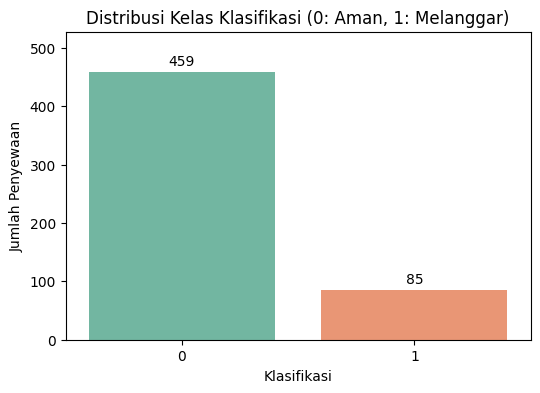


[3] Rata-rata Pelanggaran Berdasarkan Seluruh Kategori:

--- Tingkat Pelanggaran Berdasarkan status_pasutri ---
status_pasutri
Belum Menikah    0.164
Menikah          0.145
Name: label, dtype: float64

--- Tingkat Pelanggaran Berdasarkan status_kewarganegaraan ---
status_kewarganegaraan
WNI    0.156
Name: label, dtype: float64

--- Tingkat Pelanggaran Berdasarkan jenis_sewa ---
jenis_sewa
Harian     0.157
Bulanan    0.000
Name: label, dtype: float64

--- Tingkat Pelanggaran Berdasarkan metode_pembayaran ---
metode_pembayaran
Kartu Kredit    0.280
Others          0.158
Cash            0.150
QRIS            0.148
Kartu Debit     0.107
Name: label, dtype: float64

[4] Korelasi Antar Fitur:


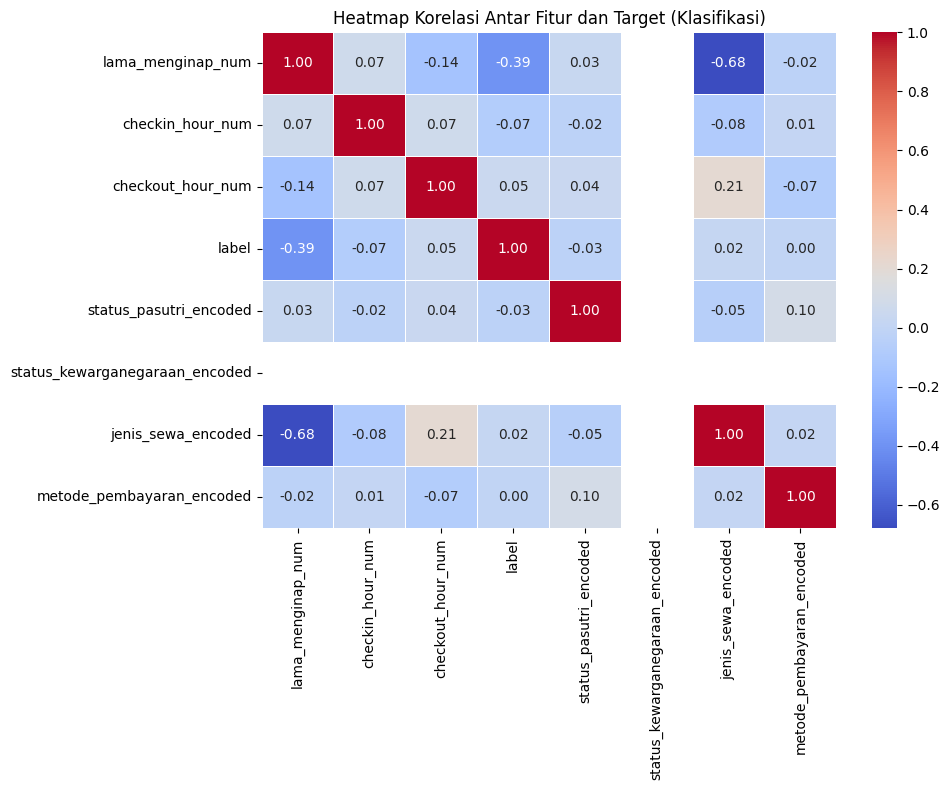


[5] Visualisasi Pola Penyewaan (Dikaitkan dengan Klasifikasi):


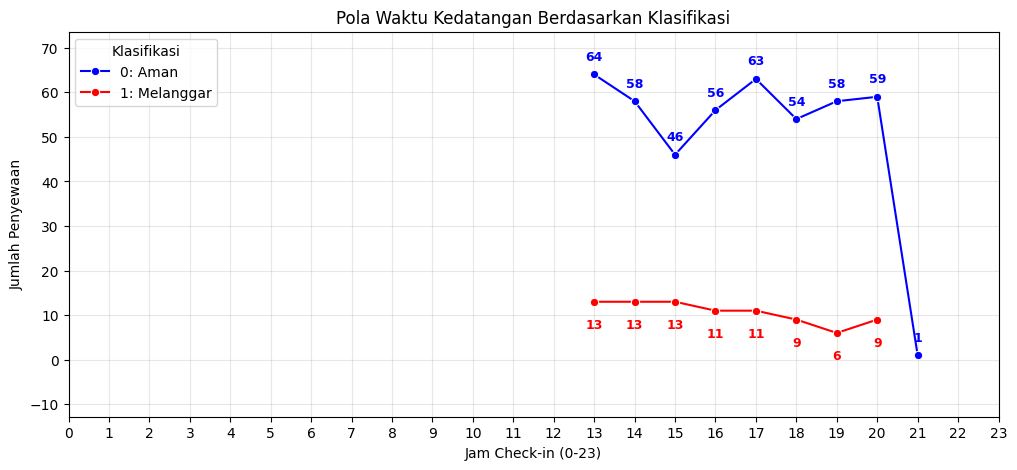

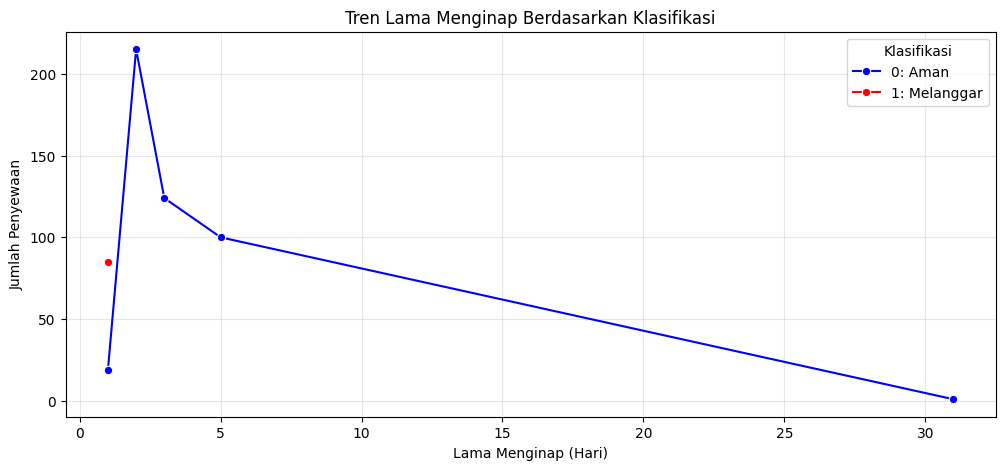

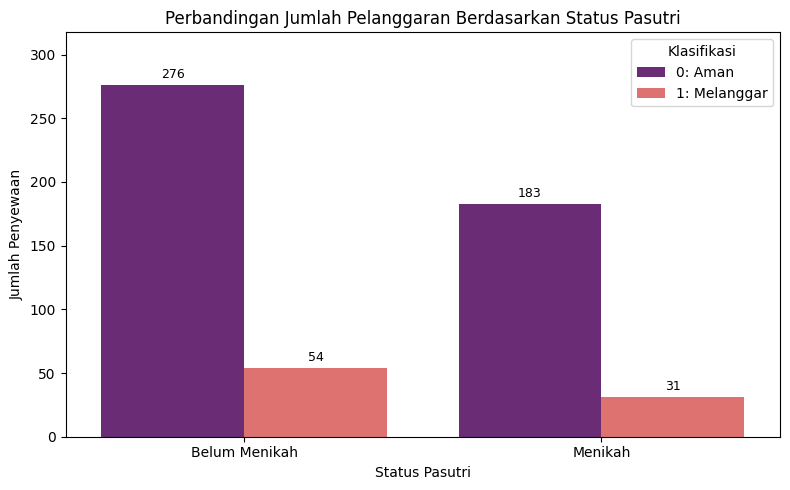

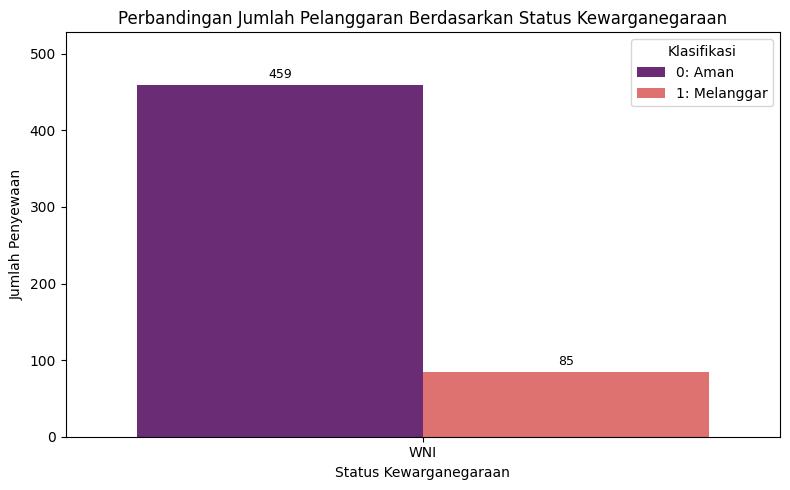

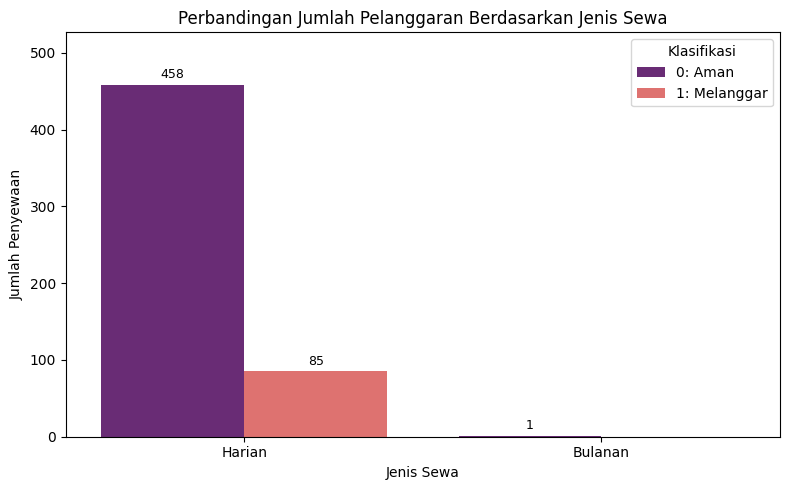

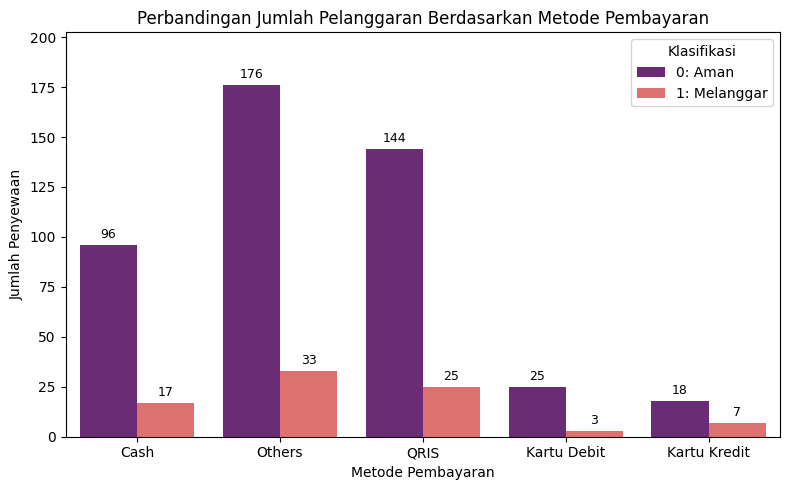


[5b] Visualisasi Metode Pembayaran 'Others' (metode_lain):


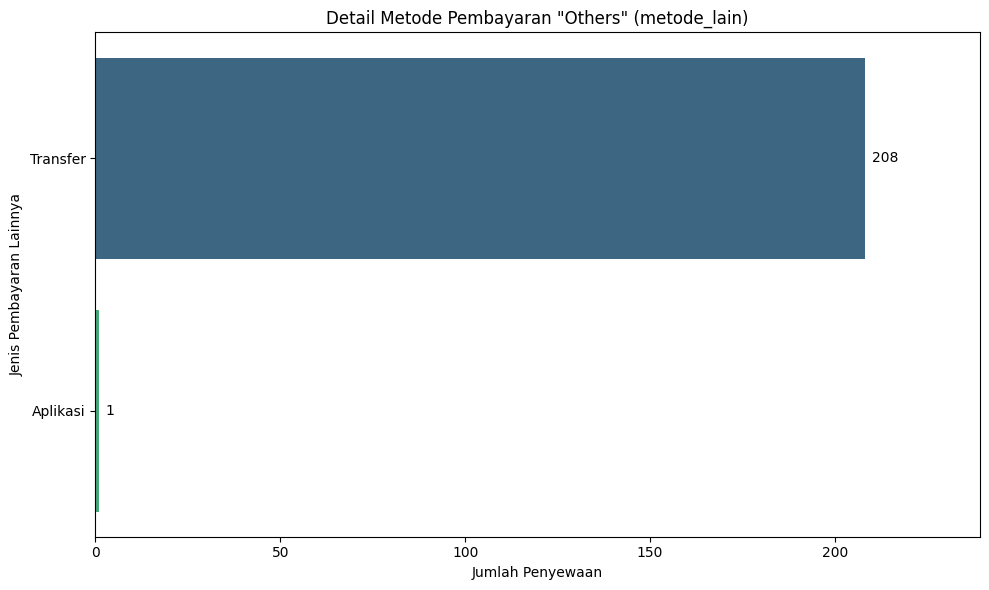


=== Proses Feature Selection ===

-> Fitur yang dipilih (3 terbaik): ['lama_menginap', 'checkout_hour', 'checkin_hour']

Memulai proses Hyperparameter Tuning untuk semua model. Ini mungkin memakan waktu...

>> Tuning Decision Tree...
>> Tuning Random Forest...
>> Tuning KNN...
>> Tuning SVM...
>> Tuning XGBoost...

===== Decision Tree (Tuned) =====
Classification Report:
              precision    recall  f1-score   support

           0     1.0000    0.9565    0.9778        92
           1     0.8095    1.0000    0.8947        17

    accuracy                         0.9633       109
   macro avg     0.9048    0.9783    0.9363       109
weighted avg     0.9703    0.9633    0.9648       109

Confusion Matrix (Text):
                Predicted
               0       1
          -----------------
True   0 |     88       4
       1 |      0      17
          -----------------


===== Random Forest (Tuned) =====
Classification Report:
              precision    recall  f1-score   support



In [18]:
# ============================================================
# DATA RIIL + Tunning --> jumlah fitur = 3
# ============================================================

import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.pipeline import make_pipeline
from sklearn.feature_selection import SelectKBest, chi2, mutual_info_classif

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier

# ------------------------------------------------------------
# 1. LOAD DATA
# ------------------------------------------------------------
rentals   = pd.read_csv('rentals.csv')
logs      = pd.read_csv('rental_logs.csv')
# units     = pd.read_csv('units.csv')
# users     = pd.read_csv('users.csv')
# violations= pd.read_csv('violations.csv')

rentals.columns = rentals.columns.str.lower()

if 'komentar' not in rentals.columns:
    raise ValueError("Kolom 'komentar' tidak ditemukan di rentals.csv")

print("renatls.csv")
print(rentals.head())
print("logs.csv")
print(logs.head())


# ------------------------------------------------------------
# 2. LABELING
# ------------------------------------------------------------
rentals['komentar'] = rentals['komentar'].astype(str).str.lower().str.strip()
empty_values = ["", "nan", "na", "null", "-", "0", "tidak ada", "none", " "]
rentals['label'] = (~rentals['komentar'].isin(empty_values)).astype(int)



# ============================================================
# EXPLORATORY DATA ANALYSIS (EDA)
# ============================================================
print("\n" + "="*50)
print("=== EXPLORATORY DATA ANALYSIS (EDA) ===")
print("="*50)

df_eda = rentals.copy()

print("\n[1] Statistik Deskriptif:")
print(df_eda.describe(include='all'))

print("\n[2] Distribusi Kelas Target (0: Aman, 1: Melanggar):")
print(df_eda['label'].value_counts())

fig, ax = plt.subplots(figsize=(6, 4))
sns.countplot(data=df_eda, x='label', palette='Set2', ax=ax)
plt.title('Distribusi Kelas Klasifikasi (0: Aman, 1: Melanggar)')
plt.xlabel('Klasifikasi')
plt.ylabel('Jumlah Penyewaan')

y_max = df_eda['label'].value_counts().max()
plt.ylim(0, y_max * 1.15)

for p in ax.patches:
    if p.get_height() > 0:
        ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='baseline', fontsize=10, color='black', xytext=(0, 5),
                    textcoords='offset points')
plt.show()

kolom_dikecualikan = ['id', 'nama', 'nik', 'unit_number', 'tanggal_checkin', 'waktu_checkin',
                      'tanggal_checkout', 'waktu_checkout', 'komentar', 'user_email', 'diedit_oleh', 'created_at', 'metode_lain', 'classification']

semua_kategori = [col for col in df_eda.select_dtypes(include=['object', 'category']).columns if col not in kolom_dikecualikan]

print("\n[3] Rata-rata Pelanggaran Berdasarkan Seluruh Kategori:")
for col in semua_kategori:
    if col in df_eda.columns:
        print(f"\n--- Tingkat Pelanggaran Berdasarkan {col} ---")
        print(df_eda.groupby(col)['label'].mean().sort_values(ascending=False).round(3))

df_eda['lama_menginap_num'] = pd.to_numeric(df_eda['lama_menginap'], errors='coerce').fillna(0)
df_eda['checkin_hour_num'] = pd.to_datetime(df_eda['waktu_checkin'], errors='coerce').dt.hour.fillna(0)
df_eda['checkout_hour_num'] = pd.to_datetime(df_eda['waktu_checkout'], errors='coerce').dt.hour.fillna(0)

le_eda = LabelEncoder()
for c in semua_kategori:
    if c in df_eda.columns:
        df_eda[c + '_encoded'] = le_eda.fit_transform(df_eda[c].astype(str))

print("\n[4] Korelasi Antar Fitur:")
kolom_korelasi = ['lama_menginap_num', 'checkin_hour_num', 'checkout_hour_num', 'label']
kolom_korelasi += [c + '_encoded' for c in semua_kategori if c + '_encoded' in df_eda.columns]

corr_matrix = df_eda[kolom_korelasi].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Heatmap Korelasi Antar Fitur dan Target (Klasifikasi)')
plt.tight_layout()
plt.show()

print("\n[5] Visualisasi Pola Penyewaan (Dikaitkan dengan Klasifikasi):")

custom_line_palette = {0: 'blue', 1: 'red'}
custom_labels = ['0: Aman', '1: Melanggar']

fig, ax1 = plt.subplots(figsize=(12, 5))
waktu_df = df_eda.groupby(['checkin_hour_num', 'label']).size().reset_index(name='jumlah')

sns.lineplot(data=waktu_df, x='checkin_hour_num', y='jumlah', hue='label', marker='o', palette=custom_line_palette, ax=ax1)

plt.title('Pola Waktu Kedatangan Berdasarkan Klasifikasi')
plt.xlabel('Jam Check-in (0-23)')
plt.ylabel('Jumlah Penyewaan')
plt.xticks(range(0, 24))
plt.grid(True, alpha=0.3)

y_max_line = waktu_df['jumlah'].max()
plt.ylim(-y_max_line * 0.20, y_max_line * 1.15)

handles, _ = ax1.get_legend_handles_labels()
plt.legend(handles=handles, labels=custom_labels, title='Klasifikasi')

for l in waktu_df['label'].unique():
    sub = waktu_df[waktu_df['label'] == l]
    warna_teks = custom_line_palette[l]

    for x, y in zip(sub['checkin_hour_num'], sub['jumlah']):
        y_offset = 8 if l == 0 else -12
        va_align = 'bottom' if l == 0 else 'top'
        plt.annotate(f'{int(y)}', (x, y), textcoords="offset points", xytext=(0, y_offset),
                     ha='center', va=va_align, fontsize=9, color=warna_teks, fontweight='bold')
plt.show()

fig, ax2 = plt.subplots(figsize=(12, 5))
lama_df = df_eda.groupby(['lama_menginap_num', 'label']).size().reset_index(name='jumlah')

sns.lineplot(data=lama_df, x='lama_menginap_num', y='jumlah', hue='label', marker='o', palette=custom_line_palette, ax=ax2)

plt.title('Tren Lama Menginap Berdasarkan Klasifikasi')
plt.xlabel('Lama Menginap (Hari)')
plt.ylabel('Jumlah Penyewaan')
plt.grid(True, alpha=0.3)

handles2, _ = ax2.get_legend_handles_labels()
plt.legend(handles=handles2, labels=custom_labels, title='Klasifikasi')
plt.show()

for col in semua_kategori:
    if col in df_eda.columns:
        fig, ax = plt.subplots(figsize=(8, 5))
        sns.countplot(data=df_eda, x=col, hue='label', palette='magma', ax=ax)

        judul_kolom = col.replace('_', ' ').title()
        plt.title(f'Perbandingan Jumlah Pelanggaran Berdasarkan {judul_kolom}')
        plt.xlabel(judul_kolom)
        plt.ylabel('Jumlah Penyewaan')
        plt.xticks(rotation=0)

        handles_bar, _ = ax.get_legend_handles_labels()
        plt.legend(handles=handles_bar, labels=custom_labels, title='Klasifikasi')

        y_max_bar = df_eda.groupby([col, 'label']).size().max()
        plt.ylim(0, y_max_bar * 1.15)

        for p in ax.patches:
            if p.get_height() > 0:
                ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                            ha='center', va='baseline', fontsize=9, color='black', xytext=(0, 5),
                            textcoords='offset points')
        plt.tight_layout()
        plt.show()


print("\n[5b] Visualisasi Metode Pembayaran 'Others' (metode_lain):")

# Memastikan kolom 'metode_lain' berbentuk string dan membersihkan spasi/nilai kosong
df_eda['metode_lain'] = df_eda['metode_lain'].astype(str).str.strip().str.title()
empty_lain = ["", "Nan", "Na", "Null", "-", "0", "None"]

# Filter hanya baris yang memiliki nilai di 'metode_lain'
df_others = df_eda[~df_eda['metode_lain'].isin(empty_lain)]

if not df_others.empty:
    fig, ax = plt.subplots(figsize=(10, 6))

    # Menghitung frekuensi masing-masing metode pembayaran lain
    order_others = df_others['metode_lain'].value_counts().index

    sns.countplot(
        data=df_others,
        y='metode_lain',
        order=order_others,
        palette='viridis',
        ax=ax
    )

    plt.title('Detail Metode Pembayaran "Others" (metode_lain)')
    plt.xlabel('Jumlah Penyewaan')
    plt.ylabel('Jenis Pembayaran Lainnya')

    # Menambahkan anotasi angka di sebelah setiap bar
    for p in ax.patches:
        width = p.get_width()
        if width > 0:
            ax.annotate(f'{int(width)}',
                        (width, p.get_y() + p.get_height() / 2.),
                        ha='left', va='center', fontsize=10, color='black',
                        xytext=(5, 0), textcoords='offset points')

    # Perlebar batas x-axis sedikit agar angka anotasi tidak terpotong
    x_max = df_others['metode_lain'].value_counts().max()
    plt.xlim(0, x_max * 1.15)

    plt.tight_layout()
    plt.show()
else:
    print("Tidak ada data metode pembayaran 'Others' yang valid untuk ditampilkan.")


# ------------------------------------------------------------
# 3. FEATURE ENGINEERING & PREPARATION
# ------------------------------------------------------------
# Parse waktu checkout
rentals['waktu_checkout_dt'] = pd.to_datetime(rentals['waktu_checkout'], errors='coerce')
rentals['checkout_hour'] = rentals['waktu_checkout_dt'].dt.hour.fillna(0).astype(int)

# Parse waktu checkin
rentals['waktu_checkin_dt'] = pd.to_datetime(rentals['waktu_checkin'], errors='coerce')
rentals['checkin_hour'] = rentals['waktu_checkin_dt'].dt.hour.fillna(0).astype(int)

# Pastikan lama_menginap berupa angka
rentals['lama_menginap'] = pd.to_numeric(rentals['lama_menginap'], errors='coerce').fillna(0)

# Isi data kosong untuk kolom kategorikal sebelum split
cat_cols = ['jenis_sewa', 'metode_pembayaran', 'status_pasutri', 'status_kewarganegaraan']
for c in cat_cols:
    rentals[c] = rentals[c].fillna('Unknown').astype(str)

numeric_cols = ['checkout_hour', 'checkin_hour', 'lama_menginap']
feature_cols = cat_cols + numeric_cols

X = rentals[feature_cols].copy()
y = rentals['label']

# ------------------------------------------------------------
# 4. TRAIN-TEST SPLIT
# ------------------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, stratify=y, test_size=0.2, random_state=42
)

# ------------------------------------------------------------
# 4B. ENCODING MENCEGAH DATA LEAKAGE
# ------------------------------------------------------------
# Simpan semua LabelEncoder ke dalam dictionary agar bisa di-export
label_encoders = {}

for c in cat_cols:
    le = LabelEncoder()
    # Fit & Transform pada data latih
    X_train[c] = le.fit_transform(X_train[c])

    # Tangani unseen labels pada data uji (ubah jadi 'Unknown' jika tidak pernah dilihat di X_train untuk mencegah error saat deployment
    X_test[c] = X_test[c].map(lambda s: s if s in le.classes_ else 'Unknown')
    if 'Unknown' not in le.classes_:
        le.classes_ = np.append(le.classes_, 'Unknown')

    X_test[c] = le.transform(X_test[c])

    # Simpan object le
    label_encoders[c] = le

# ------------------------------------------------------------
# 5. FEATURE SELECTION
# ------------------------------------------------------------
print("\n=== Proses Feature Selection ===")
chi2_selector = SelectKBest(score_func=chi2, k='all')
chi2_selector.fit(X_train, y_train)

train_df = X_train.copy()
train_df['label'] = y_train
pearson_scores = train_df.corr(method='pearson')['label'].drop('label').abs().values

mi_selector = SelectKBest(score_func=mutual_info_classif, k='all')
mi_selector.fit(X_train, y_train)

fs_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Chi-Square': chi2_selector.scores_,
    'Pearson (Abs)': pearson_scores,
    'Mutual Info': mi_selector.scores_
})

scaler = MinMaxScaler()
fs_df[['Chi2_Norm', 'Pearson_Norm', 'MI_Norm']] = scaler.fit_transform(
    fs_df[['Chi-Square', 'Pearson (Abs)', 'Mutual Info']]
)
fs_df['Total_Score'] = fs_df[['Chi2_Norm', 'Pearson_Norm', 'MI_Norm']].mean(axis=1)
fs_df = fs_df.sort_values(by='Total_Score', ascending=False).reset_index(drop=True)

# Pilih Jumlah Fitur
n_select = 3
selected_features = fs_df['Feature'].head(n_select).tolist()
print(f"\n-> Fitur yang dipilih ({n_select} terbaik): {selected_features}")

X_train = X_train[selected_features]
X_test = X_test[selected_features]

# ------------------------------------------------------------
# 6. Fungsi Evaluasi
# ------------------------------------------------------------
def evaluate(name, model):
    y_pred = model.predict(X_test)
    print(f"\n===== {name} =====")
    print("Classification Report:")
    print(classification_report(y_test, y_pred, digits=4))

    cm = confusion_matrix(y_test, y_pred)

    # --------------------------------------------------------
    # Confusion Matrix (Text Base)
    # --------------------------------------------------------
    print("Confusion Matrix (Text):")
    print("                Predicted")
    print("               0       1")
    print("          -----------------")
    print(f"True   0 | {cm[0][0]:6d}  {cm[0][1]:6d}")
    print(f"       1 | {cm[1][0]:6d}  {cm[1][1]:6d}")
    print("          -----------------\n")

    # --------------------------------------------------------
    # Confusion Matrix (Gambar / Visualisasi)
    # --------------------------------------------------------
    # plt.figure(figsize=(5, 4))
    # sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
    #             xticklabels=['0 (Aman)', '1 (Melanggar)'],
    #             yticklabels=['0 (Aman)', '1 (Melanggar)'])

    # plt.title(f'Confusion Matrix - {name}')
    # plt.xlabel('Predicted Label')
    # plt.ylabel('True Label')
    # plt.tight_layout()
    # plt.show()


# ------------------------------------------------------------
# 7. Latih Semua Model & Hyperparameter Tuning
# ------------------------------------------------------------
models = {}
custom_weight = {0: 1, 1: 4}

# --- A. Definisikan Model Dasar ---
dt_base = DecisionTreeClassifier(class_weight=custom_weight, random_state=42)
rf_base = RandomForestClassifier(class_weight=custom_weight, random_state=42)
knn_base = make_pipeline(StandardScaler(), KNeighborsClassifier())
svm_base = make_pipeline(StandardScaler(), SVC(kernel='rbf', probability=True, class_weight=custom_weight, random_state=42))
xgb_base = XGBClassifier(scale_pos_weight=4, eval_metric='logloss', random_state=42)

print("\nMemulai proses Hyperparameter Tuning untuk semua model. Ini mungkin memakan waktu...\n")

# --- B. Proses Tuning Setiap Model ---

# 1. Decision Tree
print(">> Tuning Decision Tree...")
dt_param_grid = {'max_depth': [3, 5, 7, 10, None], 'min_samples_split': [2, 5, 10]}
dt_random = RandomizedSearchCV(dt_base, dt_param_grid, n_iter=10, cv=3, random_state=42, n_jobs=-1, scoring='f1_macro')
dt_random.fit(X_train, y_train)
models["Decision Tree (Tuned)"] = dt_random.best_estimator_

# 2. Random Forest
print(">> Tuning Random Forest...")
rf_param_grid = {'n_estimators': [100, 200, 300], 'max_depth': [5, 7, 10, None], 'min_samples_split': [2, 5, 10], 'min_samples_leaf': [1, 2, 4]}
rf_random = RandomizedSearchCV(rf_base, rf_param_grid, n_iter=10, cv=3, random_state=42, n_jobs=-1, scoring='f1_macro')
rf_random.fit(X_train, y_train)
models["Random Forest (Tuned)"] = rf_random.best_estimator_

# 3. KNN (Karena menggunakan pipeline, parameter ditambahkan prefix 'kneighborsclassifier__')
print(">> Tuning KNN...")
knn_param_grid = {'kneighborsclassifier__n_neighbors': [3, 5, 7, 9, 11], 'kneighborsclassifier__weights': ['uniform', 'distance']}
knn_random = RandomizedSearchCV(knn_base, knn_param_grid, n_iter=10, cv=3, random_state=42, n_jobs=-1, scoring='f1_macro')
knn_random.fit(X_train, y_train)
models["KNN (Tuned)"] = knn_random.best_estimator_

# 4. SVM (Karena menggunakan pipeline, parameter ditambahkan prefix 'svc__')
print(">> Tuning SVM...")
svm_param_grid = {'svc__C': [0.1, 1, 10], 'svc__gamma': ['scale', 'auto', 0.1, 0.01]}
svm_random = RandomizedSearchCV(svm_base, svm_param_grid, n_iter=10, cv=3, random_state=42, n_jobs=-1, scoring='f1_macro')
svm_random.fit(X_train, y_train)
models["SVM RBF (Tuned)"] = svm_random.best_estimator_

# 5. XGBoost
print(">> Tuning XGBoost...")
xgb_param_grid = {'learning_rate': [0.01, 0.05, 0.1, 0.2], 'max_depth': [3, 5, 7], 'n_estimators': [100, 200, 300]}
xgb_random = RandomizedSearchCV(xgb_base, xgb_param_grid, n_iter=10, cv=3, random_state=42, n_jobs=-1, scoring='f1_macro')
xgb_random.fit(X_train, y_train)
models["XGBoost (Tuned)"] = xgb_random.best_estimator_

# --- C. Evaluasi Semua Model yang Sudah Di-Tune ---
# Karena setiap .best_estimator_ sudah di-fit oleh RandomizedSearchCV pada seluruh X_train,
# kita bisa langsung memanggil fungsi evaluate tanpa perlu melakukan model.fit() lagi.
for name, model in models.items():
    evaluate(name, model)

# ------------------------------------------------------------
# 8. Eksport Model Terbaik & Label Encoders
# ------------------------------------------------------------
print("\n=== Proses Export Model ===")

# Gabungkan model dan encoders ke dalam satu dictionary agar rapi
export_package = {
    'model': models["KNN (Tuned)"], # Mengubah dari Random Forest ke KNN
    'label_encoders': label_encoders,
    'selected_features': selected_features # Penting agar tahu urutan kolom masuk saat predict
}

# Menentukan nama file yang sesuai untuk KNN
filename = 'model_knn.pkl'

# Menyimpan package ke dalam file .pkl
joblib.dump(export_package, filename)
print(f"Sukses! Model dan Label Encoders telah disimpan sebagai file: {filename}")